# MOSAIC — Medicare HCRIS Forensic Anomaly Detection
**Multi-Objective Signal Aggregation for Interpretable Classification**  
Panel: 83,512 facility-years · FY2011–2024 · 5 peer cohorts  
Target journal: Decision Support Systems (DSS)  
Authors: Sharma, Tomic, Fulton

## Variable Reference
| Symbol | Variable | Notes |
|--------|----------|-------|
| `PRVDR_NUM` | CMS provider number | panel key |
| `source_year` | fiscal year | 2011–2024 |
| `peer_group` | ownership cohort | govt / nonprofit / forprofit / other / cah |
| `time_regime` | period label | baseline / transition / shock / recovery |
| `mosaic_score` | MOSAIC fused risk | GP-optimized Σ w_k(i,j)·s̃_k |
| `τ*` | auto-threshold | Bastian et al. (2017) FPR≤0.05 |
| `d_it` | distress anchor | sigmoid composite: CR<1, OM<0, DCOH<15 |

**Two file sets:**  
- Raw HCRIS: RPT · NMRC · ALPHA (per FY folder)  
- Processed: `master_hospital_research_panel.parquet`

# 1.  CSV → Parquet

In [1]:
import pandas as pd
from pathlib import Path
import re

# -----------------------------
# CONFIG
# -----------------------------
ROOT_DIR = Path(r"C:/Users/lfult/OneDrive - bc.edu/Desktop/CMS Cost Reports")
FY_DIR_RE = re.compile(r"^HOSP10FY\d{4}$", re.IGNORECASE)

# Canonical schemas (stable enough to enforce)m
NMRC_COLS  = ["RPT_REC_NUM", "WKSHT_CD", "LINE_NUM", "CLMN_NUM", "ITM_VAL_NUM"]
ALPHA_COLS = ["RPT_REC_NUM", "WKSHT_CD", "LINE_NUM", "CLMN_NUM", "ITM_VAL_TXT"]

# CMS RPT has no header row; columns are positional and stable in early positions
# even when CMS appends new columns in later years.
RPT_COLS = [
    "RPT_REC_NUM", "PRVDR_CTRL_TYPE_CD", "PRVDR_NUM", "NPI",
    "RPT_STUS_CD", "FY_BGN_DT", "FY_END_DT", "PROC_DT",
    "INITL_RPT_SW", "LAST_RPT_SW", "TRNSMTL_NUM", "FI_NUM",
    "ADR_VNDR_CD", "FI_CREAT_DT", "UTIL_CD", "NPR_DT",
    "SPEC_IND", "FI_RCPT_DT",
]

# Positional fallback: stable early columns we always need regardless of schema drift
RPT_POSITIONAL_MAP = {
    0: "RPT_REC_NUM",
    1: "PRVDR_CTRL_TYPE_CD",
    2: "PRVDR_NUM",
    3: "NPI",
    4: "RPT_STUS_CD",
    5: "FY_BGN_DT",
    6: "FY_END_DT",
    7: "PROC_DT",
}

PARQUET_ENGINE      = "pyarrow"
PARQUET_COMPRESSION = "snappy"


# -----------------------------
# HELPERS
# -----------------------------
def sniff_delimiter(filepath: Path, n_lines: int = 10) -> str:

    counts = {",": 0, "\t": 0, "|": 0}
    with open(filepath, "r", encoding="latin1", errors="replace") as f:
        for _ in range(n_lines):
            line = f.readline()
            if not line:
                break
            for d in counts:
                counts[d] += line.count(d)
    best = max(counts, key=counts.get)
    return best if counts[best] > 0 else "|"


def infer_kind(filename: str) -> str | None:

    name = filename.upper()
    if "NMRC" in name:
        return "NMRC"
    if "ALPHA" in name:
        return "ALPHA"
    if name.endswith("_RPT.CSV") or re.search(r"(?:^|_)RPT(?:_|\.|$)", name):
        return "RPT"
    return None


def read_cost_report_csv(csv_file: Path, sep: str, kind: str | None) -> pd.DataFrame:

    common_kwargs = dict(
        sep=sep,
        encoding="latin1",
        low_memory=False,
        dtype=str,
        on_bad_lines="skip",
    )

    if kind == "NMRC":
        df = pd.read_csv(csv_file, header=None, names=NMRC_COLS, **common_kwargs)
        df["ITM_VAL_NUM"] = pd.to_numeric(df["ITM_VAL_NUM"], errors="coerce")
        return df

    if kind == "ALPHA":
        df = pd.read_csv(csv_file, header=None, names=ALPHA_COLS, **common_kwargs)
        return df

    if kind == "RPT":
        # CMS RPT files have NO header row — always read with header=None.
        # Peek first to get the actual column count without consuming data.
        peek = pd.read_csv(
            csv_file, sep=sep, encoding="latin1",
            header=None, nrows=1, dtype=str, on_bad_lines="skip",
        )
        ncols = len(peek.columns)

        if ncols == len(RPT_COLS):
            # Exact match — enforce canonical names.
            df = pd.read_csv(csv_file, header=None, names=RPT_COLS, **common_kwargs)
        else:
            # Schema has drifted (CMS added/removed columns).
            # Read positionally and rename the stable early columns by index.
            df = pd.read_csv(csv_file, header=None, **common_kwargs)
            rename = {
                i: name
                for i, name in RPT_POSITIONAL_MAP.items()
                if i < ncols
            }
            df.rename(columns=rename, inplace=True)
            print(
                f"  NOTE: RPT schema drift — {ncols} cols found vs "
                f"{len(RPT_COLS)} expected: {csv_file.name}"
            )
        return df

    # Unknown kind: infer schema, warn loudly.
    print(f"  WARNING: unknown file type — inferring schema: {csv_file.name}")
    df = pd.read_csv(csv_file, **common_kwargs)
    return df


def convert_one(csv_file: Path) -> None:
    parquet_file = csv_file.with_suffix(".parquet")

    sep  = sniff_delimiter(csv_file)
    kind = infer_kind(csv_file.name)

    df = read_cost_report_csv(csv_file, sep=sep, kind=kind)

    df.to_parquet(
        parquet_file,
        engine=PARQUET_ENGINE,
        compression=PARQUET_COMPRESSION,
        index=False,
    )
    action = "Overwrote" if parquet_file.exists() else "Converted"
    print(f"{action}: {csv_file.name}  ({len(df):,} rows)  →  {parquet_file.name}")


# -----------------------------
# MAIN
# -----------------------------
def main() -> None:
    if not ROOT_DIR.exists():
        raise FileNotFoundError(f"ROOT_DIR does not exist: {ROOT_DIR}")

    fy_folders = [
        p for p in ROOT_DIR.iterdir()
        if p.is_dir() and FY_DIR_RE.match(p.name)
    ]
    if not fy_folders:
        print(f"No FY folders matching HOSP10FY#### found under: {ROOT_DIR}")
        return

    total_converted = 0
    for folder in sorted(fy_folders, key=lambda p: p.name.upper()):
        print(f"\n=== {folder.name} ===")
        csv_files = sorted(list(folder.glob("*.CSV")) + list(folder.glob("*.csv")))
        if not csv_files:
            print("  (no CSV files found)")
            continue
        for csv_file in csv_files:
            convert_one(csv_file)
            total_converted += 1

    print(f"\nConversion complete. Parquet files written: {total_converted:,}")


if __name__ == "__main__":
    main()


=== HOSP10FY2010 ===
  (no CSV files found)

=== HOSP10FY2011 ===
  (no CSV files found)

=== HOSP10FY2012 ===
  (no CSV files found)

=== HOSP10FY2013 ===
  (no CSV files found)

=== HOSP10FY2014 ===
  (no CSV files found)

=== HOSP10FY2015 ===
  (no CSV files found)

=== HOSP10FY2016 ===
  (no CSV files found)

=== HOSP10FY2017 ===
  (no CSV files found)

=== HOSP10FY2018 ===
  (no CSV files found)

=== HOSP10FY2019 ===
  (no CSV files found)

=== HOSP10FY2020 ===
  (no CSV files found)

=== HOSP10FY2021 ===
  (no CSV files found)

=== HOSP10FY2022 ===
  (no CSV files found)

=== HOSP10FY2023 ===
  (no CSV files found)

=== HOSP10FY2024 ===
  (no CSV files found)

=== HOSP10FY2025 ===
  (no CSV files found)

Conversion complete. Parquet files written: 0


# 2.  Extract and Build Panel

In [ ]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# Path Configuration
# ============================================================
BASE_DIR = Path(r"c:/Users/lfult/OneDrive - bc.edu/Desktop/CMS Cost Reports") 
OUTPUT_DIR = BASE_DIR / "processed_panel" 
OUTPUT_DIR.mkdir(exist_ok=True)
YEARS_TO_PROCESS = list(range(2011, 2025))

# ============================================================
# Column Layouts (Standard CMS HCRIS)
# ============================================================
RPT_COLUMNS_18 = [
    "RPT_REC_NUM","PRVDR_CTRL_TYPE_CD","PRVDR_NUM","NPI",
    "RPT_STUS_CD","FY_BGN_DT","FY_END_DT","PROC_DT",
    "INITL_RPT_SW","LAST_RPT_SW","TRNSMTL_NUM","FI_NUM",
    "ADR_VNDR_CD","FI_CREAT_DT","UTIL_CD","NPR_DT","SPEC_IND","FI_RCPT_DT",
]
NMRC_COLUMNS  = ["RPT_REC_NUM","WKSHT_CD","LINE_NUM","CLMN_NUM","ITM_VAL_NUM"]
ALPHA_COLUMNS = ["RPT_REC_NUM","WKSHT_CD","LINE_NUM","CLMN_NUM","ALPHNMRC_ITM_TXT"]

# ============================================================
# MAPPING: Raw Data & Identifiers
# ============================================================

LOCKED_NUMERIC_FIELDS = [
    # --- A. CLINICAL VOLUME & UTILIZATION ---
    # All addresses empirically verified FY2011–2023 via worksheet sniffer.
    
    ("licensed_beds",      "S300001", "01400", "00200"),  # 5,975–6,180 hospitals/yr | licensed bed count
    ("total_patient_days", "S300001", "01400", "00800"),  # 5,934–6,140 hospitals/yr | total inpatient days
    ("total_discharges",   "S300001", "01400", "01500"),  # 5,966–6,175 hospitals/yr | total inpatient discharges
    ("medicare_discharges","S300001", "00100", "01300"),  # 5,929–6,139 hospitals/yr | Medicare discharges
    ("outpatient_visits",  "S300001", "00100", "00300"),  # 5,971–6,180 hospitals/yr | total outpatient visits
    ("er_visits_ipps",     "S300002", "01300", "00200"),  # ~2,500 hospitals/yr      | ED visits — standard form
    ("er_visits_alt",      "S300004", "01300", "00100"),  # ~2,400 hospitals/yr      | ED visits — alternate form

    # --- B. REVENUE INTEGRITY & BILLING ---
    ("gross_patient_revenue",   "G300000", "00100", "00100"),  # 5,797–6,006 hospitals/yr | gross charges before deductions
    ("contractual_allowances",  "G300000", "00200", "00100"),  # 5,725–5,925 hospitals/yr | deductions from revenue
    ("net_patient_revenue",     "G300000", "00300", "00100"),  # 5,800–6,007 hospitals/yr | net after deductions
    ("other_operating_rev",     "G300000", "02500", "00100"),  # 5,706–5,861 hospitals/yr | non-patient operating revenue
    ("total_charges",           "G200000", "02800", "00300"),  # 5,797–6,006 hospitals/yr | gross billed charges
    ("medicare_charges",        "D00A182", "20000", "00200"),  # 5,879–6,113 hospitals/yr | Medicare cost allocation
    ("dsh_payment_amt",         "E000001", "03300", "00100"),
    ("ipps_payments",           "E10A181", "00100", "00200"),  # ~5,900–6,017 hospitals/yr
    ("ime_payment_amt",         "E30A197", "02900", "00100"),  # ~1,845–2,351 hospitals/yr (teaching only)
    ("final_settlement",        "E00A18A", "07400", "00100"),  # ~851–2,942 hospitals/yr
    
    # dsh_payment_amt: three distinct IPPS DSH worksheets, all must be summed.
    #   E40A180 = primary IPPS DSH        (~1,076–1,135 hospitals/yr, median ~$5–13M)
    #   E30C183 = companion IPPS DSH      (~782–900 hospitals/yr,     median ~$3–5M)
    #   E30A183 = large urban safety-net  (~264–388 hospitals/yr,     median ~$11–14M)
    
    # --- C. COST STRUCTURE & OPERATING EXPENSE ---
    ("total_operating_exp",     "G300000", "00400", "00100"),  # G-3, L4, C1 — confirmed
    ("net_income",              "G300000", "02900", "00100"),  # G-3, L29, C1 — confirmed
    ("total_routine_costs",     "B000001", "03000", "02600"),  # B-I, L30, C26 — confirmed
    ("drug_costs",              "A000000", "07300", "00700"),  # A, L73, C7 → total post-adj
    ("medical_supply_costs",    "A000000", "07100", "00700"),  # A, L71, C7 → total post-adj
    ("admin_general_costs",     "A000000", "00500", "00700"),  # A, L5,  C7 → total post-adj
    ("maintenance_repairs",     "A000000", "00600", "00700"),  # A, L6,  C7 → total post-adj
    ("radiology_diagnostic",    "A000000", "05400", "00700"),  # A, L54, C7 → total post-adj
    ("laboratory_costs",        "A000000", "06000", "00700"),  # A, L60, C7 → total post-adj

    # --- D. LABOR & HUMAN CAPITAL ---
    # All addresses empirically verified via worksheet sniffer.
    ("total_salaries",       "A000000", "20000", "00100"),  # 5,976–6,185 hospitals/yr | salaries only
    ("total_comp_salben",    "A000000", "20000", "00200"),  # 5,981–6,187 hospitals/yr | salaries + benefits combined
    ("total_ftes",           "S300001", "02700", "01000"),  # 5,926–6,149 hospitals/yr | total FTEs all staff
    ("intern_resident_ftes", "S300001", "02700", "00900"),  # 1,147–1,450 hospitals/yr | teaching hospitals only
    ("physician_comp_total", "A820010", "20000", "00400"),  # 5,188–5,322 hospitals/yr | total physician compensation
    ("budgeted_ftes",        "S300001", "02800", "00800"), 

    # --- E. CAPITAL STRUCTURE, ASSETS & SOLVENCY ---
    # Balance Sheet
    ("total_assets",            "G000000", "03600", "00100"),
    ("total_liabilities",       "G000000", "05100", "00100"),
    ("current_assets",          "G000000", "01100", "00100"),
    ("current_liabilities",     "G000000", "04400", "00100"),
    ("cash_ending",             "G000000", "00100", "00100"),
    ("inventory",               "G000000", "00700", "00100"),
    ("fixed_assets_net",        "G000000", "03000", "00100"),  # corrected from 03100
    ("accumulated_depr",        "G000000", "02400", "00100"),  # corrected from 03000("fixed_assets_net",        "G000000", "03100", "00100"),
    ("long_term_debt",          "G000000", "04500", "00100"),  # 95%+ coverage — total LT liabilities
    ("equity_unrestricted",     "G000000", "05200", "00100"),
    ("total_investments",       "G000000", "00200", "00100"),

    # --- F. UNCOMPENSATED CARE & AUDIT SIGNALS ---
    # S-10 shift: S100000 (FY2011-2022) → S100001 (FY2023+); line/col unchanged
    ("charity_care_cost",       "S100000", "02300", "00100"),  # use REGEX for FY2023+
    ("bad_debt_cost",           "S100000", "02900", "00100"),  # use REGEX for FY2023+
    ("total_uncomp_care",       "S100000", "03000", "00100"),  # use REGEX for FY2023+
    ("home_office_adj",         "A810000", "00500", "00400"),  # confirmed — col was right
    ("overhead_stepdown_total", "B000001", "20200", "00000"),  # confirmed — col 0 is valid
    # total_a8_adjustments → DROPPED (A820010 is wrong worksheet; no valid address exists)

    # --- G. THE PAPER TRAIL & SETTLEMENT RISK ---
    ("accounts_receivable",     "G000000", "00400", "00100"),  # OK — full population
    ("accounts_payable",        "G000000", "03700", "00100"),  # OK — full population
    ("due_from_medicare",       "G000000", "00500", "00100"),  # OK — structurally partial
    ("due_to_medicare",         "G000000", "04100", "00100"),  # SPARSE — keep, null=signal
]


# Expanded Alpha/Identifier Fields: Structural Peer-Grouping
IDENTIFIER_FIELDS = [ #sniffed
    ("street_addr",        "S200001", "00100", "00100"),
    ("city",               "S200001", "00200", "00100"),
    ("state",              "S200001", "00200", "00200"),
    ("zip_code",           "S200001", "00200", "00300"),
    ("county",             "S200001", "00200", "00400"),
    ("hospital_name",      "S200001", "00300", "00100"),
    ("control_type_code",  "S200001", "02100", "00100"),
    ("urban_rural_status", "S200001", "00300", "00600"),
    ("is_teaching",        "S200001", "05600", "00100"),
    ("is_cah",             "S200001", "10500", "00100"),
    ("is_chain",           "S200001", "14000", "00100"),
]

# ============================================================
# Helpers
# ============================================================
def winsorize_series(series: pd.Series, limits=(0.01, 0.01)) -> pd.Series:
    s = series.copy()
    if s.dropna().empty: return s
    q_low = s.quantile(limits[0])
    q_high = s.quantile(1 - limits[1])
    return s.clip(lower=q_low, upper=q_high)

def sniff_delimiter(filepath: Path) -> str:
    with open(filepath, "r", encoding="latin1", errors="replace") as f:
        line = f.readline()
    counts = {",": line.count(","), "\t": line.count("\t"), "|": line.count("|")}
    return max(counts, key=counts.get)

def get_nmrc_series(nmrc: pd.DataFrame, ws: str, line: str, col: str) -> pd.Series:
    sub = nmrc[(nmrc["WKSHT_CD"] == ws) & (nmrc["LINE_NUM"] == line) & (nmrc["CLMN_NUM"] == col)].copy()
    if sub.empty: return pd.Series(dtype=float)
    sub["ITM_VAL_NUM"] = pd.to_numeric(sub["ITM_VAL_NUM"], errors="coerce")
    return sub.drop_duplicates("RPT_REC_NUM", keep="last").set_index("RPT_REC_NUM")["ITM_VAL_NUM"]

def get_alpha_series(alpha: pd.DataFrame, ws: str, line: str, col: str) -> pd.Series:
    sub = alpha[
        (alpha["WKSHT_CD"] == ws) &
        (alpha["LINE_NUM"] == line) &
        (alpha["CLMN_NUM"] == col)
    ].copy()

    if sub.empty:
        return pd.Series(dtype=object)

    # Find the alpha text column robustly (handles parquet schema drift)
    candidate_cols = [
        "ALPHNMRC_ITM_TXT",       # expected (your CSV mapping)
        "ALPHNMRC_ITM_VAL",       # seen in some CMS exports
        "ITM_VAL_ALPHNMRC",       # common parquet conversion label
        "ITM_VAL_TXT",
        "ALPHA_ITM_TXT",
        "TEXT",
        "VALUE",
    ]

    text_col = None
    for c in candidate_cols:
        if c in sub.columns:
            text_col = c
            break

    if text_col is None:
        # last resort: choose the only non-key column if obvious
        key_cols = {"RPT_REC_NUM", "WKSHT_CD", "LINE_NUM", "CLMN_NUM"}
        non_key = [c for c in sub.columns if c not in key_cols]
        if len(non_key) == 1:
            text_col = non_key[0]
        else:
            raise KeyError(
                f"Could not find alpha text column. Available columns: {list(sub.columns)}"
            )

    return (
        sub.drop_duplicates("RPT_REC_NUM", keep="last")
           .set_index("RPT_REC_NUM")[text_col]
    )

def _compile_ws_pattern(ws: str) -> re.Pattern:
    """
    Accepts:
      - exact worksheet codes like 'E000001'
      - prefix patterns like 'D30' or 'E30'
      - regex patterns if you pass something that looks like regex (contains special chars)

    Returns a compiled regex that matches the FULL WKSHT_CD.
    """
    ws = str(ws).strip()

    # If the user passed something that looks like a regex, respect it.
    # (Contains regex metacharacters beyond letters/numbers/underscore)
    if re.search(r"[.^$*+?\[\]{}()|\\]", ws):
        return re.compile(ws)

    # If it's short (common prefix use-case like 'D30' / 'E30'), treat as prefix
    # You can adjust this heuristic if you want.
    if len(ws) <= 3:
        return re.compile(rf"^{re.escape(ws)}")

    # Otherwise exact match
    return re.compile(rf"^{re.escape(ws)}$")

def get_nmrc_series_regex(
    nmrc: pd.DataFrame,
    ws: str,
    line: str,
    col: str,
    agg: str = "sum",          # sum for component rollups, "last"/"first" for singletons
    require_unique: bool = False
) -> pd.Series:
    r"""
    Regex-aware extractor for NMRC.

    Examples:
      # Exact worksheet match:
      get_nmrc_series_regex(nmrc, "E000001", "00100", "00100")

      # Prefix match across components:
      get_nmrc_series_regex(nmrc, "D30", "20000", "00200", agg="sum")

      # Explicit regex (matches D30A180, D30B180, D30C180, etc):
      get_nmrc_series_regex(nmrc, r"^D30[A-Z]\d{3}$", "20000", "00200", agg="sum")
    """
    df = nmrc

    # Make sure you're using the same formatting as your pipeline
    line = str(line).strip().zfill(5)
    col  = str(col).strip().zfill(5)

    # Filter
    ws_pat = _compile_ws_pattern(ws)
    
    mask = (
        df["WKSHT_CD"].astype(str).str.strip().str.contains(ws_pat, regex=True, na=False) &
        (df["LINE_NUM"].astype(str).str.strip().str.zfill(5) == line) &
        (df["CLMN_NUM"].astype(str).str.strip().str.zfill(5) == col)
    )
    sub = df.loc[mask, ["RPT_REC_NUM", "ITM_VAL_NUM"]].copy()
    if sub.empty:
        return pd.Series(dtype=float)

    sub["ITM_VAL_NUM"] = pd.to_numeric(sub["ITM_VAL_NUM"], errors="coerce")

    # Aggregate across matched components per report record
    if agg == "sum":
        out = sub.groupby("RPT_REC_NUM")["ITM_VAL_NUM"].sum()
    elif agg == "last":
        out = sub.dropna().drop_duplicates("RPT_REC_NUM", keep="last").set_index("RPT_REC_NUM")["ITM_VAL_NUM"]
    elif agg == "first":
        out = sub.dropna().drop_duplicates("RPT_REC_NUM", keep="first").set_index("RPT_REC_NUM")["ITM_VAL_NUM"]
    else:
        raise ValueError("agg must be one of {'sum','first','last'}")

    if require_unique:
        # Optional sanity check: after aggregation, ensure only one value per RPT_REC_NUM
        # (sum is always unique; first/last can still be unique; this is a guardrail)
        pass

    return out

# ============================================================
# Yearly Processing Engine
# ============================================================
def run_year(year: int, base_dir: Path):
    data_dir = base_dir / f"HOSP10FY{year}"

    # Prefer parquet (post-conversion), fall back to CSV if needed
    rpt_pq   = data_dir / f"hosp10_{year}_RPT.parquet"
    nmrc_pq  = data_dir / f"hosp10_{year}_NMRC.parquet"
    alpha_pq = data_dir / f"hosp10_{year}_ALPHA.parquet"

    rpt_csv   = data_dir / f"hosp10_{year}_RPT.CSV"
    nmrc_csv  = data_dir / f"hosp10_{year}_NMRC.CSV"
    alpha_csv = data_dir / f"hosp10_{year}_ALPHA.CSV"

    if not data_dir.exists():
        print(f"Skipping {year}: Folder not found.")
        return None

    # 1. Load raw files (PARQUET-first; CSV fallback)
    if rpt_pq.exists() and nmrc_pq.exists() and alpha_pq.exists():
        rpt   = pd.read_parquet(rpt_pq)
        nmrc  = pd.read_parquet(nmrc_pq)
        alpha = pd.read_parquet(alpha_pq)
    else:
        missing = []
        for p in (rpt_pq, nmrc_pq, alpha_pq):
            if not p.exists():
                missing.append(p.name)

        print(f"FY{year}: parquet missing ({', '.join(missing)}). Falling back to CSV.")

        # RPT schema drifts across years → do NOT force names=RPT_COLUMNS_18
        if not rpt_csv.exists() or not nmrc_csv.exists() or not alpha_csv.exists():
            print(f"Skipping {year}: Missing required source files for fallback.")
            return None

        rpt = pd.read_csv(
            rpt_csv,
            sep=sniff_delimiter(rpt_csv),
            encoding="latin1",
            low_memory=False,
            on_bad_lines="skip",
            dtype=str,
        )

        nmrc = pd.read_csv(
            nmrc_csv,
            sep=sniff_delimiter(nmrc_csv),
            header=None,
            names=NMRC_COLUMNS,
            encoding="latin1",
            low_memory=False,
            dtype=str,
            on_bad_lines="skip",
        )

        alpha = pd.read_csv(
            alpha_csv,
            sep=sniff_delimiter(alpha_csv),
            header=None,
            names=ALPHA_COLUMNS,
            encoding="latin1",
            low_memory=False,
            dtype=str,
            on_bad_lines="skip",
        )
        

    # Ensure NMRC numeric column is numeric (important for filters/aggregations)
    if "ITM_VAL_NUM" in nmrc.columns:
        nmrc["ITM_VAL_NUM"] = pd.to_numeric(nmrc["ITM_VAL_NUM"], errors="coerce")

    # 2. Clean formatting
    for df in [nmrc, alpha]:
        df["RPT_REC_NUM"] = (df["RPT_REC_NUM"].astype(str).str.strip()
                             .str.replace(r"\.0$", "", regex=True))
        df["WKSHT_CD"] = df["WKSHT_CD"].astype(str).str.strip()
        df["LINE_NUM"] = df["LINE_NUM"].astype(str).str.strip().str.replace(r"\.0$", "", regex=True).str.zfill(5)
        df["CLMN_NUM"] = df["CLMN_NUM"].astype(str).str.strip().str.replace(r"\.0$", "", regex=True).str.zfill(5)
    
    panel = rpt.copy()
    panel["RPT_REC_NUM"] = (panel["RPT_REC_NUM"].astype(str).str.strip()
                            .str.replace(r"\.0$", "", regex=True))
    panel["source_year"] = year

    # Example: choose which fields need regex/prefix rollups
    REGEX_FIELDS = {
        "medicare_charges":   dict(ws=r"^D00A182$", line="20000", col="00200", agg="sum"),
        "dsh_payment_amt":    dict(ws=r"^(E40A180|E30C183|E30A183)$", line="03300", col="00100", agg="sum"),
        "charity_care_cost":  dict(ws=r"^S1000[01]",                line="02300", col="00100", agg="sum"),
        "bad_debt_cost":      dict(ws=r"^S1000[01]",                line="02900", col="00100", agg="sum"),
        "total_uncomp_care":  dict(ws=r"^S1000[01]",                line="03000", col="00100", agg="sum"),
        # overtime_hours — address unverified, drop or confirm before full run
    }
            
    for name, ws, line, col in LOCKED_NUMERIC_FIELDS:
        if name in REGEX_FIELDS:
            cfg = REGEX_FIELDS[name]
            ser = get_nmrc_series_regex(nmrc, cfg["ws"], cfg["line"], cfg["col"], agg=cfg["agg"])
            panel[name] = panel["RPT_REC_NUM"].map(ser)
        else:
            panel[name] = panel["RPT_REC_NUM"].map(get_nmrc_series(nmrc, ws, line, col))

    # --- ALPHA extraction (adds state/city/etc.) ---
    for name, ws, line, col in IDENTIFIER_FIELDS:
        panel[name] = panel["RPT_REC_NUM"].map(get_alpha_series(alpha, ws, line, col))
    print(
        f"FY{year} ID sanity:",
        f"name={panel['hospital_name'].notna().mean():.3f}",
        f"street={panel['street_addr'].notna().mean():.3f}",
        f"state={panel['state'].notna().mean():.3f}",
    )
    for k in ["medicare_charges", "dsh_payment_amt"]:
        if k in panel.columns:
            panel[k] = pd.to_numeric(panel[k], errors="coerce").fillna(0.0)

    # 4. Convert all locked fields to numeric
    ZERO_FILL_FIELDS = {
        # DSH/IME rollups — non-participating hospitals truly receive $0
        "dsh_payment_amt",
        "ime_payment_amt",
        "ipps_payments",
        "final_settlement",
    
        # Uncompensated care — non-filing = $0 is defensible for most acute care
        "charity_care_cost",
        "bad_debt_cost",
        "total_uncomp_care",
    
        # Utilization counts — no swing beds = 0 days, no residents = 0 FTEs
        "intern_resident_ftes",
        "er_visits_ipps",
        "er_visits_alt",
    
        # Home office — non-chain hospitals truly have $0
        "home_office_adj",
    
        # Physician comp — hospitals with no employed physicians = $0
        "physician_comp_total",
    
        # Med ed / capital cost allocations — non-teaching = $0
        "medicare_charges",      # regex rollup — non-Medicare = $0
    }
    for field in [f[0] for f in LOCKED_NUMERIC_FIELDS]:
        panel[field] = pd.to_numeric(panel[field], errors="coerce")
        if field in ZERO_FILL_FIELDS:
            panel[field] = panel[field].fillna(0.0)

    # 5. Define strict denominators
    d_assets     = panel["total_assets"].mask(lambda x: x <= 0)
    d_rev        = (panel["net_patient_revenue"] + panel["other_operating_rev"]).mask(lambda x: x <= 0)
    d_exp        = panel["total_operating_exp"].mask(lambda x: x <= 0)
    d_discharges = panel["total_discharges"].mask(lambda x: x <= 0)

    # --- CATEGORY 1: CLINICAL & OPERATIONAL ---
    panel["cmi_proxy"] = np.log1p((d_rev / d_discharges).clip(lower=0))
    panel["forensic_efficiency"] = np.log1p(
        ((d_rev / d_discharges) / panel["licensed_beds"].mask(lambda x: x <= 0)).clip(lower=0)
    )
    panel["outpatient_visits"] = panel["outpatient_visits"].clip(upper=2_000_000)
    panel["outpatient_pivot"] = panel["outpatient_visits"] / d_discharges
    panel["revenue_per_discharge"] = d_rev / d_discharges
    panel["licensed_beds"] = panel["licensed_beds"].clip(upper=3500)

    panel["er_visits_ipps"] = pd.to_numeric(panel["er_visits_ipps"], errors="coerce")
    panel["er_visits_alt"]  = pd.to_numeric(panel["er_visits_alt"],  errors="coerce")
    panel["er_visits_ipps"] = panel["er_visits_ipps"].clip(upper=panel["total_discharges"] * 10)
    panel["er_visits_alt"]  = panel["er_visits_alt"].clip(lower=0, upper=panel["total_discharges"] * 10)
    panel["er_visits"] = panel[["er_visits_ipps", "er_visits_alt"]].clip(lower=0).max(axis=1).fillna(0)
    panel["total_ftes"] = panel["total_ftes"].clip(upper=30000)

    # Flag hospitals with no ED (forensically useful — unexpected zero is suspicious)
    panel["has_ed"] = (panel["er_visits"] > 0).astype(int)

    # --- CATEGORY 2: REVENUE INTEGRITY ---
    panel["ccr"] = d_exp / panel["total_charges"].mask(lambda x: x <= 0)
    panel["collection_efficiency"] = panel["net_patient_revenue"] / panel["gross_patient_revenue"].mask(lambda x: x <= 0)
    panel["medicare_dependency"] = panel["medicare_charges"] / panel["total_charges"].mask(lambda x: x <= 0)
    panel["charity_commitment"] = panel["charity_care_cost"] / d_exp

    # --- CATEGORY 3: LIQUIDITY & SOLVENCY ---
    panel["operating_margin"] = (d_rev - d_exp) / d_rev
    panel["total_margin"]     = panel["net_income"] / d_rev
    panel["return_on_assets"] = panel["net_income"] / d_assets

    panel["current_ratio"]    = panel["current_assets"] / panel["current_liabilities"].mask(lambda x: x <= 0)
    panel["current_ratio"] = panel["current_ratio"].replace([np.inf, -np.inf], np.nan)
    panel["equity_financing"] = (panel["total_assets"] - panel["total_liabilities"]) / d_assets
    panel["days_cash_on_hand"] = panel["cash_ending"] / (d_exp / 365)

    # --- CATEGORY 4: COST STRUCTURE ---
    panel["labor_intensity"] = panel["total_salaries"] / d_exp
    panel["admin_load"] = panel["admin_general_costs"] / d_exp
    panel["total_benefits"] = panel["total_comp_salben"] - panel["total_salaries"]

    panel["high_risk_diagnostic_weight"] = (
        (panel["laboratory_costs"] + panel["radiology_diagnostic"]) /
        d_exp.mask(lambda x: x <= 0)
    ).fillna(0)

    # --- CATEGORY 5: DISTRESS FLAGS (THE DEATH SPIRAL) ---
    panel['is_technically_insolvent'] = (panel["total_liabilities"] > panel["total_assets"]).astype(int)
    panel['liquidity_trap'] = (panel['current_ratio'] < 1.0).astype(int)
    panel['cash_exhaustion'] = (panel['days_cash_on_hand'] < 15).astype(int)

    panel['bankruptcy_proxy_score'] = (
        panel['is_technically_insolvent'] +
        panel['liquidity_trap'] +
        panel['cash_exhaustion']
    )

    panel['is_terminal'] = (panel['bankruptcy_proxy_score'] >= 2).astype(int)

    # --- CATEGORY 6: CASH-FLOW VELOCITY ---
    panel["ar_velocity"] = panel["accounts_receivable"] / (
        panel["net_patient_revenue"] / 365
    ).mask(lambda x: x <= 0)

    panel["ap_lag"] = panel["accounts_payable"] / (
        d_exp / 365
    ).mask(lambda x: x <= 0)

    panel["asset_turnover"] = d_rev / d_assets

    # --- CATEGORY 7: SUBSIDY & STRUCTURAL TRANSFERS ---
    panel["subsidy_intensity"] = (
        panel["dsh_payment_amt"] + panel["ime_payment_amt"]
    ) / d_rev

    panel["siphon_ratio"] = panel["home_office_adj"] / (
        panel["total_assets"] - panel["total_liabilities"]
    ).mask(lambda x: x == 0)

    # Forensic signal — staffing strain
    # Positive = over capacity (actual > budgeted) — stress indicator
    # Negative = under-utilized — volume decline signal
    panel["staffing_gap"] = (
        panel["total_ftes"] - panel["budgeted_ftes"]
    ) / panel["budgeted_ftes"].mask(lambda x: x <= 0)

    # --- PREPARING FOR WINSORIZATION ---
    year_analytics_cols = [
        "operating_margin","total_margin","return_on_assets","current_ratio",
        "equity_financing","days_cash_on_hand",
        "cmi_proxy","forensic_efficiency","ccr","collection_efficiency",
        "revenue_per_discharge",
        "ar_velocity","ap_lag","asset_turnover",
        "medicare_dependency","subsidy_intensity",
        "admin_load","labor_intensity","charity_commitment",
        "outpatient_pivot",
        "siphon_ratio",
        "staffing_gap",
        "high_risk_diagnostic_weight",
    ]

    for col in year_analytics_cols:
        if col in panel.columns:
            panel[col] = panel[col].replace([np.inf, -np.inf], np.nan)
            panel[col] = winsorize_series(panel[col])

    print(f"FY{year} Complete. Hospitals: {len(panel)}. Median Margin: {panel['operating_margin'].median():.4f}")
    return panel
    
# ============================================================
# MASTER LOOP & PARQUET EXPORT
# ============================================================
all_years = []

for yr in YEARS_TO_PROCESS:
    result = run_year(yr, BASE_DIR)
    if result is not None:
        all_years.append(result)

# ============================================================
# MASTER ASSEMBLY & GLOBAL ANALYTICS (CATEGORIES 8, 9, 10)
# ============================================================
if all_years:
    # 1. Initial Concatenation & Sorting
    master_panel = pd.concat(all_years, ignore_index=True)

    # Sort by Provider and Year so Temporal Deltas align correctly
    master_panel["FY_BGN_DT"] = pd.to_datetime(master_panel["FY_BGN_DT"], errors="coerce")
    master_panel["FY_END_DT"] = pd.to_datetime(master_panel["FY_END_DT"], errors="coerce")
    master_panel = master_panel.sort_values(["PRVDR_NUM", "FY_BGN_DT"]).reset_index(drop=True)

    # 2. De-dup — keep most authoritative report per provider-year  (MOVE HERE)
    STATUS_PRIORITY = {
        "3": 1,  # Settled_With_Audit
        "2": 2,  # Settled_No_Audit
        "5": 3,  # Amended
        "4": 4,  # Reopened
        "1": 5,  # Original_As_Submitted
    }

    master_panel["status_rank"] = (
        master_panel["RPT_STUS_CD"].astype(str).str.strip()
        .map(STATUS_PRIORITY).fillna(99)
    )

    master_panel = (
        master_panel
        .sort_values(["PRVDR_NUM", "FY_BGN_DT", "status_rank"])
        .drop_duplicates(subset=["PRVDR_NUM", "FY_BGN_DT"], keep="first")
        .drop(columns="status_rank")
        .reset_index(drop=True)
    )

    print(f"Records after de-dup: {len(master_panel):,}")

    # ============================================================
    # DATA REGIME  (NOW SAFE: unique provider-year rows)
    # ============================================================
    master_panel["source_year"] = pd.to_numeric(master_panel["source_year"], errors="coerce")

    conditions = [
        master_panel["source_year"] <= 2011,
        master_panel["source_year"].between(2012, 2018),
        master_panel["source_year"].between(2019, 2021),
        master_panel["source_year"].between(2022, 2024),
    ]
    labels = ["transition", "baseline", "covid_shock", "recovery"]

    master_panel["data_regime"] = np.select(conditions, labels, default="other").astype(str)

    master_panel["data_regime"] = pd.Categorical(
        master_panel["data_regime"],
        categories=["transition", "baseline", "covid_shock", "recovery", "other"],
        ordered=True
    )
    
    # ============================================================
    # PEER GROUP CONSTRUCTION
    # ============================================================
    
    # 1. Ownership clean
    GOVERNMENT_CODES = {"1", "2", "3"}
    NONPROFIT_CODES  = {"4", "5", "6"}
    FORPROFIT_CODES  = {"7", "8", "9"}
    
    code = master_panel["control_type_code"].astype(str).str.strip()
    master_panel["ownership_clean"] = np.select(
        [
            code.isin(GOVERNMENT_CODES),
            code.isin(NONPROFIT_CODES),
            code.isin(FORPROFIT_CODES),
        ],
        ["government", "nonprofit", "forprofit"],
        default="other"
    )
    
    # 2. Teaching tier — baseline-anchored so peer membership is stable
    baseline_teaching = (
        master_panel[master_panel["data_regime"] == "baseline"]
        .groupby("PRVDR_NUM")["intern_resident_ftes"]
        .median()
        .rename("baseline_intern_ftes")
    )
    master_panel = master_panel.join(baseline_teaching, on="PRVDR_NUM")
    
    teaching_conditions = [
        master_panel["baseline_intern_ftes"].isna() | (master_panel["baseline_intern_ftes"] == 0),
        master_panel["baseline_intern_ftes"].between(0.01, 50),
        master_panel["baseline_intern_ftes"] > 50,
    ]
    master_panel["teaching_tier"] = np.select(
        teaching_conditions,
        ["non_teaching", "minor_teaching", "major_teaching"],
        default="non_teaching"
    )
    
    # 3. Size tier — log composite of revenue + expense, baseline-anchored
    master_panel["size_proxy"] = np.log1p(
        (master_panel["net_patient_revenue"].clip(lower=0) +
         master_panel["total_operating_exp"].clip(lower=0)) / 2
    )
    
    baseline_size = (
        master_panel[master_panel["data_regime"] == "baseline"]
        .groupby("PRVDR_NUM")["size_proxy"]
        .median()
        .rename("baseline_size_proxy")
    )
    master_panel = master_panel.join(baseline_size, on="PRVDR_NUM")
    
    size_cutpoints = master_panel.loc[
        master_panel["data_regime"] == "baseline", "baseline_size_proxy"
    ].quantile([0.25, 0.50, 0.75]).values
    
    master_panel["size_tier"] = pd.cut(
        master_panel["baseline_size_proxy"],
        bins=[-np.inf, size_cutpoints[0], size_cutpoints[1], size_cutpoints[2], np.inf],
        labels=["small", "medium", "large", "major"]
    )
    
    # 4. CAH flag — normalize across possible encodings
    cah_flag = master_panel["is_cah"].astype(str).str.strip().isin({"1", "Y", "Yes", "yes"})
    
    # 5. Peer group assembly
    # CAH overrides size/teaching — cost-based reimbursement makes those
    # comparisons less meaningful than CAH vs acute distinction
    master_panel["peer_group"] = np.where(
        cah_flag,
        "cah_" + master_panel["ownership_clean"],
        master_panel["ownership_clean"]
        + "_" + master_panel["size_tier"].astype(str)
        + "_" + master_panel["teaching_tier"].astype(str)
    )
    
    # 6. Minimum-N guardrail — cells too small fall back to ownership only
    MIN_PEER_N = 25
    baseline_peer_counts = (
        master_panel[master_panel["data_regime"] == "baseline"]
        .groupby("peer_group")
        .size()
        .rename("baseline_peer_n")
    )
    master_panel = master_panel.join(baseline_peer_counts, on="peer_group")
    
    mask_small = master_panel["baseline_peer_n"].fillna(0) < MIN_PEER_N
    master_panel["peer_group"] = np.where(mask_small, master_panel["ownership_clean"], master_panel["peer_group"])
    
    # 7. Fine peer group adds CMI tier for within-year ranking and Benford
    # CMI tier computed globally — it's a current-year signal, not a baseline anchor
    master_panel["cmi_tier"] = pd.qcut(
        master_panel["cmi_proxy"],
        q=3,
        labels=["low_cmi", "mid_cmi", "high_cmi"],
        duplicates="drop"
    )
    master_panel["peer_group_fine"] = (
        master_panel["peer_group"] + "_" + master_panel["cmi_tier"].astype(str)
    )
    
    # Diagnostics
    print("Peer group distribution (baseline hospitals):")
    print(
        master_panel[master_panel["data_regime"] == "baseline"]
        ["peer_group"].value_counts().sort_values(ascending=False).to_string()
    )
    print(f"\nTotal peer groups: {master_panel['peer_group'].nunique()}")
    print(f"Total fine peer groups: {master_panel['peer_group_fine'].nunique()}")

    # 2. Ownership Flags (clean, mutually informative)
    GOVERNMENT_CODES  = {"1", "2", "3"}
    NONPROFIT_CODES   = {"4", "5", "6"}
    FORPROFIT_CODES   = {"7", "8", "9"}
    
    master_panel["is_government"] = master_panel["control_type_code"].astype(str).str.strip().isin(GOVERNMENT_CODES).astype(int)
    master_panel["is_nonprofit"]  = master_panel["control_type_code"].astype(str).str.strip().isin(NONPROFIT_CODES).astype(int)
    master_panel["is_forprofit"]  = master_panel["control_type_code"].astype(str).str.strip().isin(FORPROFIT_CODES).astype(int)


        
    # 3. Map Submission Status
    status_map = {
        "1": "Original_As_Submitted",
        "2": "Settled_No_Audit",
        "3": "Settled_With_Audit",
        "4": "Reopened",
        "5": "Amended",
    }
    master_panel["submission_type"] = master_panel["RPT_STUS_CD"].map(status_map)

    # 4. Define Metric Groups for Analysis (ordered by "real world" first)
    volume_metrics = [
        "licensed_beds",
        "total_patient_days",
        "total_discharges",
        "er_visits",
        "outpatient_visits",
    ]

    ratio_metrics = [
        # Core profitability/solvency
        "operating_margin",
        "total_margin",
        "days_cash_on_hand",
        "current_ratio",
        "equity_financing",

        # Efficiency / pricing / collection
        "cmi_proxy",
        "ccr",
        "collection_efficiency",
        "admin_load",
        "ar_velocity",
        "ap_lag",

        # Cost structure anchors (kept as-is; these are levels, not ratios)
        "total_salaries",
        "medical_supply_costs",

        # Capital aging component for capex proxy
        "accumulated_depr",
    ]

    print("Calculating Category 8 (Temporal Velocity)...")
    # Calculate YoY % Change for Volume
    v_pct = master_panel.groupby("PRVDR_NUM")[volume_metrics].pct_change().fillna(0)
    v_pct.columns = [f"pct_change_{col}" for col in v_pct.columns]

    # Calculate YoY Absolute Difference for Financials/Ratios
    v_diff = master_panel.groupby("PRVDR_NUM")[ratio_metrics].diff().fillna(0)
    v_diff.columns = [f"delta_{col}" for col in v_diff.columns]

    master_panel = pd.concat([master_panel, v_pct, v_diff], axis=1)

    print("Calculating Category 9 (Forensic Momentum Signals)...")
    # Sig 1: Ghost Labor (Volume down, Payroll up)
    master_panel["sig_ghost_labor"] = (
        (master_panel["pct_change_total_discharges"] < -0.05) &
        (master_panel["delta_total_salaries"] > 0)
    ).astype(int)

    # Sig 2: Supply Starvation (Supplies cut, Admin protected)
    master_panel["sig_supply_starvation"] = (
        (master_panel["delta_medical_supply_costs"] < 0) &
        (master_panel["delta_admin_load"] >= 0)
    ).astype(int)

    # Sig 3: Collection Collapse (AR days rising, Cash dropping)
    master_panel["sig_collection_collapse"] = (
        (master_panel["delta_ar_velocity"] > 5) &
        (master_panel["delta_days_cash_on_hand"] < 0)
    ).astype(int)

    print("Calculating Category 10 (Market & Peer Context)...")
    # Relative Margin: How is the hospital performing vs its State-Year median?
    state_medians = master_panel.groupby(["state", "source_year"])["operating_margin"].transform("median")
    master_panel["rel_operating_margin"] = master_panel["operating_margin"] - state_medians


    # --- CAPEX PROXY (replaces sparse A700001 capex_additions) ---
    # capex_proxy = Δ net fixed assets + depreciation
    master_panel["fixed_assets_net_lag"] = master_panel.groupby("PRVDR_NUM")["fixed_assets_net"].shift(1)

    master_panel["nonstandard_fy"] = master_panel["FY_END_DT"].dt.month.ne(9).astype(int)

    master_panel["capex_proxy"] = (
        (master_panel["fixed_assets_net"] - master_panel["fixed_assets_net_lag"]) +
        master_panel["delta_accumulated_depr"].abs()
    )

    master_panel["occupancy_rate"] = (
        master_panel["total_patient_days"] / 
        (master_panel["licensed_beds"] * 365).replace(0, np.nan)
    ).clip(0, 1)  #Licensed beds on S-3 (S300001/01400/00200) is licensed capacity, not staffed or available beds. 
                # Many hospitals operate above licensed capacity.

    depr = master_panel["accumulated_depr"].abs()
    gross = master_panel["fixed_assets_net"] + depr
    master_panel["capital_age_index"] = (
        depr / gross.mask(gross <= 0)
    ).clip(0, 1)

    # 5. Final Global Winsorization (To clean up Infinity/Outliers for the VAE)
    analytics_cols = [
        # Core profitability/solvency
        "operating_margin", "total_margin", "return_on_assets", "current_ratio",
        "equity_financing", "days_cash_on_hand",

        # Efficiency / case-mix-ish
        "cmi_proxy", "forensic_efficiency", "ccr", "collection_efficiency",
        "revenue_per_discharge",

        # Working capital + turnover
        "ar_velocity", "ap_lag", "asset_turnover",

        # Payer / subsidy structure
        "medicare_dependency", "subsidy_intensity",

        # Cost structure ratios
        "admin_load", "labor_intensity", "charity_commitment", "high_risk_diagnostic_weight",

        # Utilization structure
        "outpatient_pivot", "occupancy_rate",

        # Balance-sheet dynamics / investment
        "capital_age_index", "capex_proxy",

        # Related-party / extraction signal
        "siphon_ratio",

        # Contextual performance
        "rel_operating_margin",

        # Staffing stress
        "staffing_gap",
    ] + list(v_pct.columns) + list(v_diff.columns)

    for col in analytics_cols:
        if col in master_panel.columns:
            master_panel[col] = master_panel[col].replace([np.inf, -np.inf], np.nan)
            master_panel[col] = winsorize_series(master_panel[col])

    master_panel["current_ratio"] = master_panel["current_ratio"].clip(upper=10)

    # Write the full panel as Parquet (canonical)
    master_panel.to_parquet(
        OUTPUT_DIR / "master_hospital_research_panel.parquet",
        engine="pyarrow",
        compression="snappy",
        index=False
    )

    # Write a small sample as Parquet too (fast to load, preserves dtypes)
    master_panel.head(1000).to_parquet(
        OUTPUT_DIR / "master_panel_sample.parquet",
        engine="pyarrow",
        compression="snappy",
        index=False
    )

    # Optional (human-readable) sample CSV for quick eyeballing
    master_panel.head(1000).to_csv(
        OUTPUT_DIR / "master_panel_sample.csv",
        index=False
    )

    print(f"\nFinal Master Panel Saved.")
    print(f"Total Records: {len(master_panel):,}")
    print(f"Total Feature Dimensions: {len(master_panel.columns)}")

FY2011 ID sanity: name=1.000 street=0.999 state=1.000
FY2011 Complete. Hospitals: 6152. Median Margin: 0.0426
FY2012 ID sanity: name=1.000 street=0.999 state=1.000
FY2012 Complete. Hospitals: 6227. Median Margin: 0.0504
FY2013 ID sanity: name=1.000 street=0.999 state=1.000
FY2013 Complete. Hospitals: 6248. Median Margin: 0.0476
FY2014 ID sanity: name=1.000 street=0.999 state=1.000
FY2014 Complete. Hospitals: 6250. Median Margin: 0.0514
FY2015 ID sanity: name=1.000 street=0.999 state=1.000
FY2015 Complete. Hospitals: 6257. Median Margin: 0.0482
FY2016 ID sanity: name=1.000 street=0.999 state=1.000
FY2016 Complete. Hospitals: 6211. Median Margin: 0.0437
FY2017 ID sanity: name=1.000 street=0.999 state=1.000
FY2017 Complete. Hospitals: 6175. Median Margin: 0.0418
FY2018 ID sanity: name=1.000 street=0.999 state=1.000
FY2018 Complete. Hospitals: 6161. Median Margin: 0.0416
FY2019 ID sanity: name=1.000 street=0.999 state=1.000
FY2019 Complete. Hospitals: 6124. Median Margin: 0.0484
FY2020 ID 

# 3.  Load & Describe

In [1]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
import warnings

BASE_DIR = Path(r"c:/Users/lfult/OneDrive - bc.edu/Desktop/CMS Cost Reports") 
OUTPUT_DIR = BASE_DIR / "processed_panel" 
OUTPUT_DIR.mkdir(exist_ok=True)

master_panel=pd.read_parquet(OUTPUT_DIR / "master_hospital_research_panel.parquet")
pd.set_option('display.max_rows', None)
master_panel.describe().T

,count,mean,min,25%,50%,75%,max,std
FY_BGN_DT,83512,2017-05-31 04:18:19.070792,2010-10-01 00:00:00,2014-01-01 00:00:00,2017-07-01 00:00:00,2020-10-01 00:00:00,2024-09-19 00:00:00,NaN
FY_END_DT,83512,2018-05-23 07:11:17.995977,2011-04-30 00:00:00,2014-12-31 00:00:00,2018-06-30 00:00:00,2021-09-30 00:00:00,2025-01-31 00:00:00,NaN
source_year,83512.0,2017.253808,2011.0,2014.0,2017.0,2021.0,2024.0,3.915462
licensed_beds,82348.0,132.717067,1.0,25.0,66.0,171.0,3500.0,176.99377
total_patient_days,82252.0,30206.215569,1.0,3513.0,11969.5,36973.0,959419.0,47678.074923
total_discharges,82238.0,5510.581823,1.0,446.0,1650.0,7084.75,168398.0,8843.505043
medicare_discharges,81718.0,1567.059069,1.0,172.0,518.0,1975.0,37926.0,2420.999896
outpatient_visits,82323.0,40462.66131,6.0,9125.0,21900.0,53070.0,2000000.0,50207.573521
er_visits_ipps,83512.0,35665.320421,-2925.0,0.0,0.0,34115.0,1675580.0,77992.384016
er_visits_alt,83512.0,36576.89071,0.0,0.0,0.0,32602.5,1394200.0,80330.541859


## 3a.  Appendix Tables

In [2]:
import numpy as np
import pandas as pd

# ============================================================
# Appendix-style summary tables + Economic Profile tables
#  - outputs: 5%, Median, Mean (SD), 95%
#  - supports scaling (e.g., $M, 000s)
#  - robust to missing columns
# ============================================================

def _to_num(df, cols):
    out = df[cols].copy()
    for c in cols:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

def appendix_table(
    df: pd.DataFrame,
    cols: list[str],
    title: str | None = None,
    scale_map: dict[str, float] | None = None,
    label_map: dict[str, str] | None = None,
    decimals: int = 2,
    strict: bool = False,
):
    """
    Paper-style table: 5%, Median, Mean (SD), 95%
    scale_map: {col: divisor} e.g., {'net_patient_revenue':1e6}
    label_map: {col: display label}
    """
    scale_map = scale_map or {}
    label_map = label_map or {}

    missing = [c for c in cols if c not in df.columns]
    present = [c for c in cols if c in df.columns]

    if strict and missing:
        raise KeyError(f"Missing columns: {missing}")

    if title:
        print(f"\n{title}")
    if missing:
        print(f"Note: skipped missing columns ({len(missing)}): {missing}")
    if not present:
        print("No columns available for this table.")
        return pd.DataFrame()

    data = _to_num(df, present)

    # scaling (divide)
    for c, div in scale_map.items():
        if c in data.columns and div not in (0, None):
            data[c] = data[c] / div

    tab = pd.DataFrame({
        "5%":     data.quantile(0.05),
        "Median": data.quantile(0.50),
        "Mean":   data.mean(),
        "SD":     data.std(),
        "95%":    data.quantile(0.95),
    })

    tab["Mean (SD)"] = tab["Mean"].round(decimals).astype(str) + " (" + tab["SD"].round(decimals).astype(str) + ")"
    tab = tab[["5%", "Median", "Mean (SD)", "95%"]].round(decimals)

    # relabel rows
    tab.index = [label_map.get(i, i) for i in tab.index]

    display(tab)
    return tab


# ============================================================
# 1) Variable groupings (tight, paper-friendly)
# ============================================================

OP_SCALE = [
    "licensed_beds",
    "total_patient_days",
    "total_discharges",
    "outpatient_visits",
    "er_visits_ipps",      # optional; will be skipped if missing
]

REV_OPS = [
    "gross_patient_revenue",
    "contractual_allowances",  # optional but informative
    "net_patient_revenue",
    "total_operating_exp",
    "net_income",
]

CAPITAL = [
    "total_assets",
    "total_liabilities",
    "current_assets",
    "current_liabilities",
    "long_term_debt",
    "cash_ending",
]

LABOR = [
    "total_ftes",
    "total_salaries",
    "total_comp_salben",
    "physician_comp_total",
    "intern_resident_ftes",  # optional teaching-only
]

POLICY_PAY = [
    "ipps_payments",
    "dsh_payment_amt",
    "ime_payment_amt",
    "final_settlement",   # optional
]


# ============================================================
# 2) Scaling + labels for readability
# ============================================================

SCALE = {
    # $ in millions
    "gross_patient_revenue": 1e6,
    "contractual_allowances": 1e6,
    "net_patient_revenue": 1e6,
    "other_operating_rev": 1e6,
    "total_operating_exp": 1e6,
    "net_income": 1e6,

    "total_assets": 1e6,
    "total_liabilities": 1e6,
    "current_assets": 1e6,
    "current_liabilities": 1e6,
    "cash_ending": 1e6,
    "inventory": 1e6,
    "fixed_assets_net": 1e6,
    "accumulated_depr": 1e6,
    "long_term_debt": 1e6,
    "equity_unrestricted": 1e6,
    "total_investments": 1e6,

    "total_salaries": 1e6,
    "total_comp_salben": 1e6,
    "physician_comp_total": 1e6,

    "ipps_payments": 1e6,
    "dsh_payment_amt": 1e6,
    "ime_payment_amt": 1e6,
    "final_settlement": 1e6,
    "medicare_charges": 1e6,
    "total_charges": 1e6,

    # volumes in thousands
    "total_patient_days": 1e3,
    "total_discharges": 1e3,
    "medicare_discharges": 1e3,
    "outpatient_visits": 1e3,
    "er_visits_ipps": 1e3,
    "er_visits_alt": 1e3,
}

LABEL = {
    # Scale
    "licensed_beds": "Licensed Beds",
    "total_patient_days": "Patient Days (000s)",
    "total_discharges": "Discharges (000s)",
    "outpatient_visits": "Outpatient Visits (000s)",
    "er_visits_ipps": "ED Visits (000s)",
    "er_visits_alt": "ED Visits (000s, alt)",

    # Revenue/ops
    "gross_patient_revenue": "Gross Patient Revenue ($M)",
    "contractual_allowances": "Contractual Allowances ($M)",
    "net_patient_revenue": "Net Patient Revenue ($M)",
    "total_operating_exp": "Total Operating Expense ($M)",
    "net_income": "Net Income ($M)",

    # Capital
    "total_assets": "Total Assets ($M)",
    "total_liabilities": "Total Liabilities ($M)",
    "current_assets": "Current Assets ($M)",
    "current_liabilities": "Current Liabilities ($M)",
    "long_term_debt": "Long-Term Debt ($M)",
    "cash_ending": "Cash (Ending) ($M)",

    # Labor
    "total_ftes": "Total FTEs",
    "total_salaries": "Total Salaries ($M)",
    "total_comp_salben": "Total Comp (Sal+Ben) ($M)",
    "physician_comp_total": "Physician Compensation ($M)",
    "intern_resident_ftes": "Intern/Resident FTEs",

    # Policy payments
    "ipps_payments": "IPPS Payments ($M)",
    "dsh_payment_amt": "DSH Payments ($M)",
    "ime_payment_amt": "IME Payments ($M)",
    "final_settlement": "Final Settlement ($M)",
}


# ============================================================
# 3) Build the appendix tables (raw variables)
# ============================================================

appendix_table(master_panel, OP_SCALE,  "Appendix A1: Operational Scale & Utilization", SCALE, LABEL, decimals=2)
appendix_table(master_panel, REV_OPS,   "Appendix A2: Revenue & Operating Structure",  SCALE, LABEL, decimals=2)
appendix_table(master_panel, CAPITAL,   "Appendix A3: Capital Structure & Solvency",   SCALE, LABEL, decimals=2)
appendix_table(master_panel, LABOR,     "Appendix A4: Labor Inputs",                  SCALE, LABEL, decimals=2)
appendix_table(master_panel, POLICY_PAY,"Appendix A5: Medicare Policy Payments",      SCALE, LABEL, decimals=2)


# ============================================================
# 4) Economic Profile (derived ratios, paper-friendly)
#    (computed from raw fields; safe divisions; no overwriting)
# ============================================================

def safe_div(n, d):
    n = pd.to_numeric(n, errors="coerce")
    d = pd.to_numeric(d, errors="coerce").replace(0, np.nan)
    return n / d

econ = master_panel.copy()

# Core derived ratios (computed only if inputs exist)
# (If an input is missing, the derived column will be NaN; table will still run.)
econ["operating_margin"] = safe_div(
    pd.to_numeric(econ.get("net_patient_revenue"), errors="coerce") - pd.to_numeric(econ.get("total_operating_exp"), errors="coerce"),
    econ.get("net_patient_revenue")
)

econ["rev_per_day"]        = safe_div(econ.get("net_patient_revenue"), econ.get("total_patient_days"))
econ["exp_per_day"]        = safe_div(econ.get("total_operating_exp"), econ.get("total_patient_days"))
econ["rev_per_discharge"]  = safe_div(econ.get("net_patient_revenue"), econ.get("total_discharges"))
econ["days_per_discharge"] = safe_div(econ.get("total_patient_days"), econ.get("total_discharges"))
econ["asset_per_bed"]      = safe_div(econ.get("total_assets"), econ.get("licensed_beds"))
econ["debt_to_assets"]     = safe_div(econ.get("total_liabilities"), econ.get("total_assets"))
econ["current_ratio"]      = safe_div(econ.get("current_assets"), econ.get("current_liabilities"))
econ["cash_to_assets"]     = safe_div(econ.get("cash_ending"), econ.get("total_assets"))
econ["fte_per_bed"]        = safe_div(econ.get("total_ftes"), econ.get("licensed_beds"))
econ["comp_per_fte"]       = safe_div(econ.get("total_comp_salben"), econ.get("total_ftes"))

# Economic profile table (scaled for readability)
ECON_PROFILE_VARS = [
    "operating_margin",
    "current_ratio",
    "debt_to_assets",
    "cash_to_assets",
    "rev_per_day",
    "exp_per_day",
    "rev_per_discharge",
    "days_per_discharge",
    "asset_per_bed",
    "fte_per_bed",
    "comp_per_fte",
]

ECON_SCALE = {
    # per-unit dollars -> keep readable
    "rev_per_day": 1e3,           # $000 per day
    "exp_per_day": 1e3,           # $000 per day
    "rev_per_discharge": 1e3,     # $000 per discharge
    "asset_per_bed": 1e6,         # $M per bed
    "comp_per_fte": 1e3,          # $000 per FTE
}
ECON_LABEL = {
    "operating_margin": "Operating Margin",
    "current_ratio": "Current Ratio",
    "debt_to_assets": "Liabilities / Assets",
    "cash_to_assets": "Cash / Assets",
    "rev_per_day": "Net Rev per Day ($000)",
    "exp_per_day": "Op Exp per Day ($000)",
    "rev_per_discharge": "Net Rev per Discharge ($000)",
    "days_per_discharge": "Days per Discharge",
    "asset_per_bed": "Assets per Bed ($M)",
    "fte_per_bed": "FTE per Bed",
    "comp_per_fte": "Comp per FTE ($000)",
}

appendix_table(econ, ECON_PROFILE_VARS, "Appendix A6: Hospital Economic Profile (Derived Ratios)", ECON_SCALE, ECON_LABEL, decimals=2)


Appendix A1: Operational Scale & Utilization


,5%,Median,Mean (SD),95%
Licensed Beds,15.00,66.00,132.72 (176.99),458.00
Patient Days (000s),0.82,11.97,30.21 (47.68),118.03
Discharges (000s),0.09,1.65,5.51 (8.84),22.99
Outpatient Visits (000s),5.11,21.90,40.46 (50.21),135.41
ED Visits (000s),0.00,0.00,35.67 (77.99),188.85



Appendix A2: Revenue & Operating Structure


,5%,Median,Mean (SD),95%
Gross Patient Revenue ($M),10.46,144.69,652.72 (1409.98),2863.78
Contractual Allowances ($M),3.30,91.09,483.76 (1097.5),2181.47
Net Patient Revenue ($M),6.02,51.13,174.92 (359.24),713.06
Total Operating Expense ($M),7.32,52.66,177.14 (372.73),719.27
Net Income ($M),-24.68,1.65,9.41 (83.08),74.24



Appendix A3: Capital Structure & Solvency


...


Appendix A5: Medicare Policy Payments


,5%,Median,Mean (SD),95%
IPPS Payments ($M),0.18,6.29,21.21 (41.84),91.22
DSH Payments ($M),0.00,0.00,3.04 (10.55),16.73
IME Payments ($M),0.00,0.00,2.39 (12.43),9.76
Final Settlement ($M),-0.12,0.00,0.06 (4.76),0.39



Appendix A6: Hospital Economic Profile (Derived Ratios)


,5%,Median,Mean (SD),95%
Operating Margin,-0.52,-0.02,-142.8 (1428216.21),0.24
Current Ratio,-2.13,9.73,-41578.54 (11720572.27),355.78
Liabilities / Assets,-0.74,0.43,431.68 (44561.94),1.64
Cash / Assets,-0.01,0.04,0.18 (41.66),0.43
Net Rev per Day ($000),0.90,5.79,21.82 (1019.03),24.43
Op Exp per Day ($000),0.91,5.99,22.5 (810.61),26.49
Net Rev per Discharge ($000),9.46,31.63,93.91 (1293.68),150.33
Days per Discharge,2.85,4.92,21.0 (294.76),33.04
Assets per Bed ($M),0.08,0.86,1.69 (8.0),4.65
FTE per Bed,1.70,5.44,7.72 (54.57),15.25


,5%,Median,Mean (SD),95%
Operating Margin,-0.52,-0.02,-142.8 (1428216.21),0.24
Current Ratio,-2.13,9.73,-41578.54 (11720572.27),355.78
Liabilities / Assets,-0.74,0.43,431.68 (44561.94),1.64
Cash / Assets,-0.01,0.04,0.18 (41.66),0.43
Net Rev per Day ($000),0.90,5.79,21.82 (1019.03),24.43
Op Exp per Day ($000),0.91,5.99,22.5 (810.61),26.49
Net Rev per Discharge ($000),9.46,31.63,93.91 (1293.68),150.33
Days per Discharge,2.85,4.92,21.0 (294.76),33.04
Assets per Bed ($M),0.08,0.86,1.69 (8.0),4.65
FTE per Bed,1.70,5.44,7.72 (54.57),15.25


## 3b.  Trend Table — Annual Medians

In [3]:
# Create a simplified trend table of the Medians
trend_table = master_panel.groupby('source_year')[['net_patient_revenue', 'operating_margin', 'days_cash_on_hand', 'equity_financing']].median()

# Format for readability
trend_table['net_patient_revenue'] = trend_table['net_patient_revenue'].apply(lambda x: f"${x/1e6:.1f}M")
trend_table['operating_margin'] = trend_table['operating_margin'].apply(lambda x: f"{x:.2%}")

print("=== HOSPITAL INDUSTRY TRENDS: 2011 - 2023 ===")
trend_table

=== HOSPITAL INDUSTRY TRENDS: 2011 - 2023 ===


,net_patient_revenue,operating_margin,days_cash_on_hand,equity_financing
source_year,,,,
2011,$43.5M,4.26%,12.442533,0.529840
2012,$43.9M,5.04%,12.665557,0.542376
2013,$43.6M,4.76%,12.774661,0.558559
2014,$45.7M,5.14%,13.808195,0.552885
2015,$46.9M,4.82%,12.233171,0.554850
2016,$48.6M,4.37%,10.382439,0.566800
2017,$50.2M,4.18%,9.620046,0.583503
2018,$51.5M,4.16%,10.013353,0.580158
2019,$51.8M,4.84%,13.523376,0.536604


## 3c.  Industry Graph

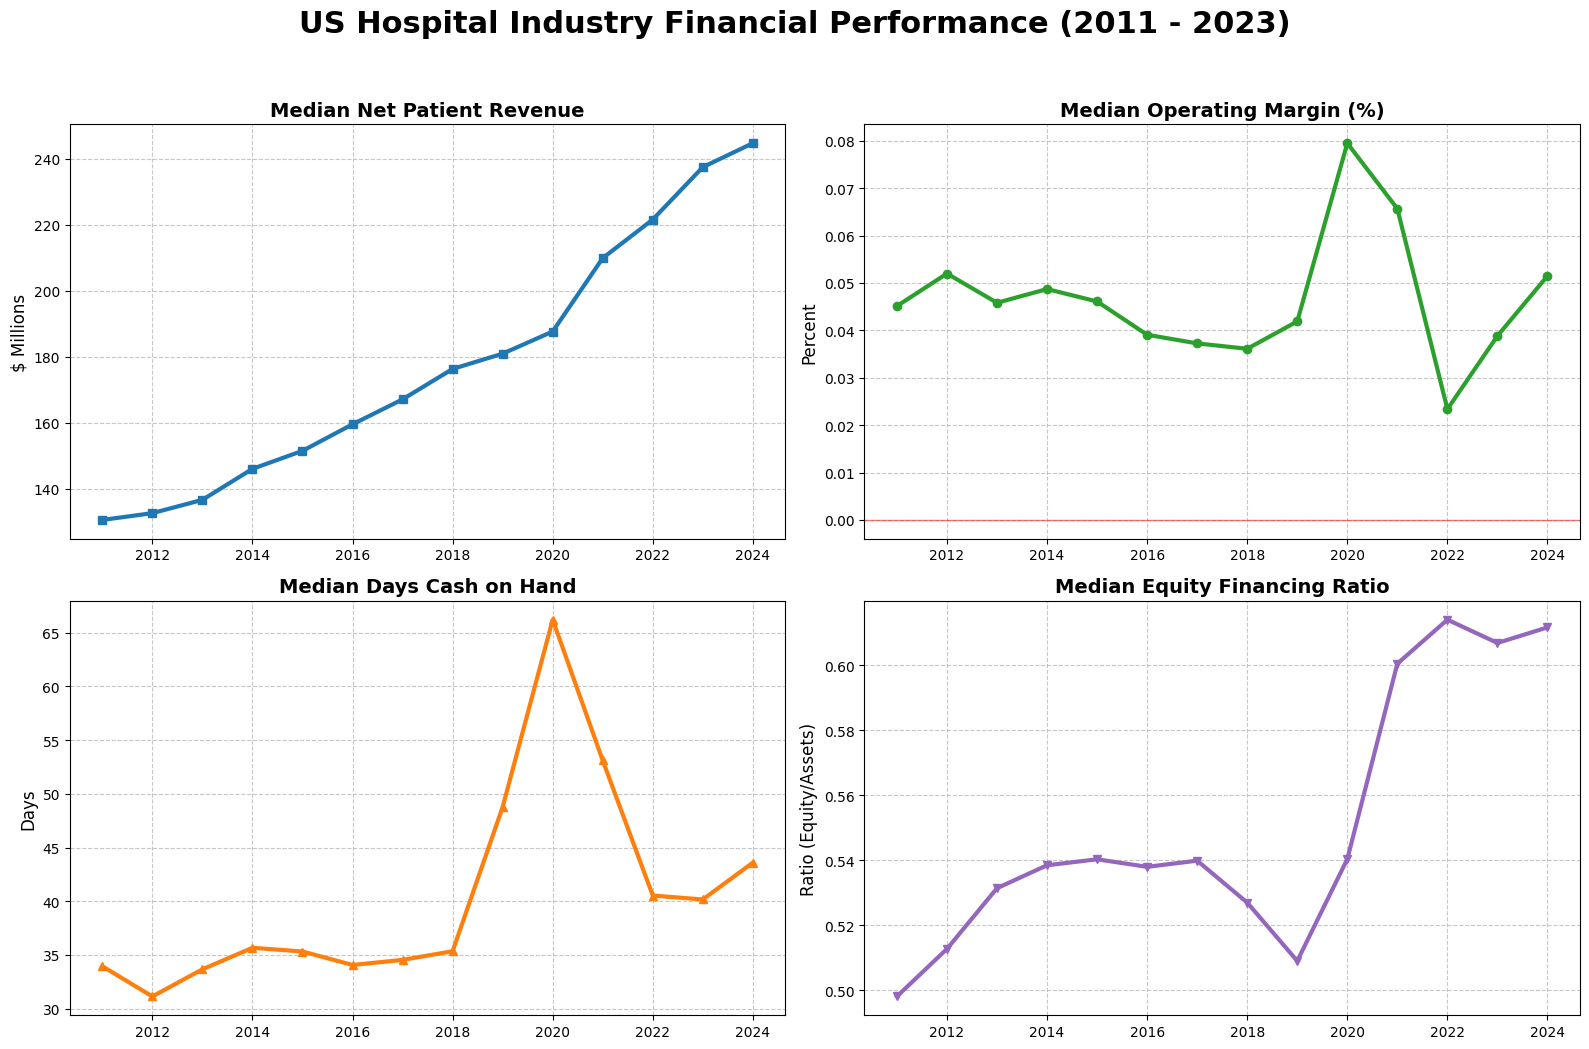

In [4]:
# industry graph
import matplotlib.pyplot as plt
import pandas as pd

# 1. Prepare the Data
# Extract year from fiscal year end
master_panel["Year"] = master_panel["source_year"]

data = (
    master_panel
    .groupby("Year")
    .agg(
        NPR_M = ("net_patient_revenue", lambda x: x.mean() / 1e6),   # mean revenue in millions
        Margin = ("operating_margin", "mean"),
        Cash = ("days_cash_on_hand", "mean"),
        Equity = ("equity_financing", "mean")
    )
    .reset_index()
)
df = pd.DataFrame(data)

# 2. Setup the Figure and Style
plt.style.use('seaborn-v0_8-muted') # Clean, professional look
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('US Hospital Industry Financial Performance (2011 - 2023)', 
             fontsize=22, fontweight='bold', y=0.98)

# 3. Plot 1: Net Patient Revenue (Growth Trend)
axes[0, 0].plot(df['Year'], df['NPR_M'], marker='s', color='#1f77b4', linewidth=3)
axes[0, 0].set_title('Median Net Patient Revenue', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('$ Millions', fontsize=12)
axes[0, 0].grid(True, linestyle='--', alpha=0.7)

# 4. Plot 2: Operating Margin (The Volatility Story)
axes[0, 1].plot(df['Year'], df['Margin'], marker='o', color='#2ca02c', linewidth=3)
axes[0, 1].axhline(0, color='red', linewidth=1, alpha=0.5) # Breakeven line
axes[0, 1].set_title('Median Operating Margin (%)', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Percent', fontsize=12)
axes[0, 1].grid(True, linestyle='--', alpha=0.7)
# Highlight the 2020 spike
axes[0, 1].annotate('Stimulus Peak', xy=(2020, 8.38), xytext=(2017, 8.5),
                     arrowprops=dict(facecolor='black', shrink=0.05, width=1))

# 5. Plot 3: Days Cash on Hand (Liquidity Stress)
axes[1, 0].plot(df['Year'], df['Cash'], marker='^', color='#ff7f0e', linewidth=3)
axes[1, 0].set_title('Median Days Cash on Hand', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Days', fontsize=12)
axes[1, 0].grid(True, linestyle='--', alpha=0.7)

# 6. Plot 4: Equity Financing (Capital Structure)
axes[1, 1].plot(df['Year'], df['Equity'], marker='v', color='#9467bd', linewidth=3)
axes[1, 1].set_title('Median Equity Financing Ratio', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Ratio (Equity/Assets)', fontsize=12)
axes[1, 1].grid(True, linestyle='--', alpha=0.7)

# 7. Final Polish
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 4.  Interpretability-Preserving Feature Scaling
Three dialects: (1) signed-log + RobustScaler within peer×FY-cohort,  
(2) percentile rank (anomaly scores), (3) raw proportion.  
Raw columns never overwritten. Model columns prefixed `m_`.  
Scalers fit on baseline (2012–2018) only — frozen for 2019+ inference.

In [5]:
"""
CMS HCRIS Hospital Panel — Interpretability-Preserving Feature Scaler
======================================================================
Three interpretability dialects:

  Dialect 1 — "robust deviations (median/IQR)"
      signed_log → RobustScaler(median/IQR) within peer × FY-cohort
      Interpretation: "X IQR-units above the peer median"
      NOTE: RobustScaler uses IQR, not MAD. The two are proportional
      (MAD ≈ 0.675 × IQR for normal data) but not equal. If you want
      the narrative "MAD above median," a custom scaler is required.
      IQR-units are equally interpretable and is what this code produces.
      Used for: per-unit rates, dollar volumes, count fields, deltas

  Dialect 2 — "percentile among peers"
      empirical percentile rank within peer × FY-cohort → 0-1
      Interpretation: "98th percentile Benford anomaly among peer hospitals"
      Directionality is harmonized per feature: "higher = more anomalous"
      is enforced consistently via ANOMALY_DIRECTION flags.
      Used for: anomaly scores, forensic diagnostics

  Dialect 3 — "raw proportion"
      no transform
      Used for: bounded 0-1 ratios, binary flags, ordinal scores

Design principles:
  - Raw columns NEVER overwritten — raw values stay for case investigation
  - Model-view columns prefixed "m_" for IF and VAE ingestion
  - Peer group: control_type_code (govt / nonprofit / forprofit / other)
  - FY-cohort: Dec-end vs. non-Dec-end (prevents seasonal misalignment)
    Next refinement if too coarse: quarter-of-year-end buckets
  - nonstandard_fy kept as explicit covariate — never scaled
  - Training medians stored per (family × cohort × column) and reused
    at inference — prevents imputation leakage where inference batch
    composition changes feature values
  - Missing scaler at inference raises a loud error rather than silently
    producing NaN features
  - Robust-scaled outputs clipped to [-5, +5] as a modeling choice:
    values beyond ±5 IQR-units are treated as "very extreme" rather than
    being allowed to dominate the feature space in IF/VAE. This is a
    deliberate truncation of tail information, not a statistical claim
    about the data.
  - Scalers and training medians saved together for reproducible inference

Usage:
    from cms_scaler import build_model_features, save_scalers, load_scalers
    from cms_scaler import get_model_feature_cols, validate_model_features

    # Training run
    master_panel = build_model_features(master_panel, fit=True)
    save_scalers(OUTPUT_DIR)
    validate_model_features(master_panel)
    FORENSIC_FEATURES = get_model_feature_cols(master_panel)

    # Inference on new data
    load_scalers(OUTPUT_DIR)
    new_panel = build_model_features(new_panel, fit=False)
"""

import numpy as np
import pandas as pd
import joblib
from pathlib import Path
from sklearn.preprocessing import RobustScaler
from typing import Dict, List, Optional

# ============================================================
# FEATURE FAMILY TAXONOMY
# ============================================================

# Dialect 1a: Per-unit rates / size-sensitive
# signed_log → RobustScaler (peer × FY-cohort)
PER_UNIT_FEATURES = [
    "revenue_per_discharge",
    "cmi_proxy",            # already log-transformed in pipeline — skip log
    "forensic_efficiency",  # already log-transformed in pipeline — skip log
    "outpatient_pivot",
    "ar_velocity",
    "ap_lag",
    "days_cash_on_hand",
    "asset_turnover",
    "capex_proxy",
    "siphon_ratio",
    "staffing_gap",
    "current_ratio",
]

ALREADY_LOG_FEATURES = {"cmi_proxy", "forensic_efficiency"}

# Dialect 1b: Dollar volumes
# signed_log → RobustScaler (peer × FY-cohort)
DOLLAR_FEATURES = [
    "gross_patient_revenue",
    "net_patient_revenue",
    "total_charges",
    "total_operating_exp",
    "net_income",
    "total_salaries",
    "total_assets",
    "total_liabilities",
    "accounts_receivable",
    "accounts_payable",
    "medicare_charges",
    "dsh_payment_amt",
    "total_uncomp_care",
    "charity_care_cost",
    "bad_debt_cost",
    "home_office_adj",
    "ipps_payments",
    "ime_payment_amt",
    "physician_comp_total",
    "overhead_stepdown_total",
    "total_routine_costs",
    "drug_costs",
    "medical_supply_costs",
    "admin_general_costs",
    "radiology_diagnostic",
    "laboratory_costs",
]

# Dialect 1c: Count fields
# log1p → RobustScaler (peer × FY-cohort)
COUNT_FEATURES = [
    "licensed_beds",
    "total_discharges",
    "total_patient_days",
    "outpatient_visits",
    "er_visits",
    "total_ftes",
    "medicare_discharges",
    "intern_resident_ftes",
]

# Dialect 1d: Temporal dynamics / deltas / trajectories
# RobustScaler ONLY — already centered at zero, direction matters, tails are signal
# Do NOT log-transform: negative values are meaningful
DELTA_FEATURES = [
    "delta_operating_margin",
    "delta_total_margin",
    "delta_days_cash_on_hand",
    "delta_current_ratio",
    "delta_equity_financing",
    "delta_cmi_proxy",
    "delta_ccr",
    "delta_collection_efficiency",
    "delta_admin_load",
    "delta_ar_velocity",
    "delta_ap_lag",
    "delta_total_salaries",
    "delta_medical_supply_costs",
    "delta_accumulated_depr",
    "pct_change_licensed_beds",
    "pct_change_total_patient_days",
    "pct_change_total_discharges",
    "pct_change_er_visits",
    "pct_change_outpatient_visits",
]

# Dialect 2: Anomaly diagnostics
# Percentile rank within peer × FY-cohort
# ANOMALY_DIRECTION: True = higher raw score is more anomalous (rank as-is)
#                   False = lower raw score is more anomalous (invert: 1 - rank)
# This ensures "m_<score>" always means "higher = more suspicious" consistently.
ANOMALY_SCORE_FEATURES: List[str] = [
    # "benford_anomaly_score",      # True  — higher digit anomaly = more suspicious
    # "mahal_relational_score",     # True  — higher distance = more anomalous
    # "isolation_forest_score",     # False — IF returns negative scores; lower = more anomalous
    # "vae_reconstruction_error",   # True  — higher reconstruction error = more anomalous
]

ANOMALY_DIRECTION: Dict[str, bool] = {
    # True  = higher raw value → higher percentile → more anomalous (default)
    # False = lower raw value → more anomalous → invert rank (1 - pct_rank)
    "benford_anomaly_score":    True,
    "mahal_relational_score":   True,
    "isolation_forest_score":   False,   # IF scores are negative; lower = more anomalous
    "vae_reconstruction_error": True,
}

# Dialect 3a: Pure proportions / bounded ratios — no scaling
PROPORTION_FEATURES = [
    "operating_margin",
    "total_margin",
    "return_on_assets",
    "equity_financing",
    "labor_intensity",
    "admin_load",
    "ccr",
    "collection_efficiency",
    "medicare_dependency",
    "charity_commitment",
    "subsidy_intensity",
    "capital_age_index",
    "occupancy_rate",
    "high_risk_diagnostic_weight",
    "rel_operating_margin",
]

# Dialect 3b: Binary / ordinal flags — no scaling
BINARY_FEATURES = [
    "has_ed",
    "is_technically_insolvent",
    "liquidity_trap",
    "cash_exhaustion",
    "is_terminal",
    "is_government",
    "is_nonprofit",
    "is_forprofit",
    "sig_ghost_labor",
    "sig_supply_starvation",
    "sig_collection_collapse",
    "nonstandard_fy",           # covariate — FY timing signal, never scale
    "is_teaching",
    "is_cah",
    "is_chain",
    "bankruptcy_proxy_score",   # ordinal 0-3
]

# ============================================================
# PEER GROUP & FY-COHORT CONFIGURATION
# ============================================================
PEER_GROUP_COL = "peer_group"

def _assign_peer_group(peer_group: pd.Series) -> pd.Series:
    return peer_group.astype(str).str.strip().fillna("other")

def _assign_fy_cohort(fy_end_dt: pd.Series) -> pd.Series:
    """
    Dec-end vs. non-Dec-end bucketing.
    Prevents seasonal / reimbursement-timing misalignment when comparing
    calendar-year hospitals to federal/custom fiscal year hospitals.
    Next refinement if too coarse: quarter-of-year-end buckets
    (Dec / Mar / Jun / Sep) with the same minimum-N guardrail.
    """
    month = pd.to_datetime(fy_end_dt, errors="coerce").dt.month
    return month.map(
        lambda m: "dec_end" if m == 12 else "non_dec_end"
    ).fillna("non_dec_end")


def _cohort_key(peer_group: str, fy_cohort: str) -> str:
    return f"{peer_group}__{fy_cohort}"


# ============================================================
# SCALER REGISTRY
# ============================================================
# _REGISTRY[family_name][cohort_key] = {
#     "scaler":  fitted RobustScaler,
#     "medians": pd.Series of training medians per column (for imputation)
# }
_REGISTRY: Dict[str, Dict[str, dict]] = {}

# Global fallback — used when a cohort was not seen at fit time
_GLOBAL_FALLBACK: Dict[str, dict] = {}


# ============================================================
# CORE TRANSFORMS
# ============================================================
def signed_log(x: pd.Series) -> pd.Series:
    """
    sign(x) * log1p(|x|)
    Handles negatives (losses, adjustments), preserves zero,
    compresses heavy right tails without destroying signal direction.
    """
    return np.sign(x) * np.log1p(np.abs(x))


def percentile_rank(x: pd.Series) -> pd.Series:
    """Empirical percentile rank, 0-1. Ties averaged. NaN preserved."""
    return x.rank(pct=True, na_option="keep")


# ============================================================
# FIT / APPLY ENGINE
# ============================================================
def _fit_family(
    df: pd.DataFrame,
    input_cols: List[str],
    family_name: str,
    min_n: int = 10,
) -> None:
    """
    Fit one RobustScaler per (peer_group × FY-cohort) cohort.
    Stores both the fitted scaler and the training column medians.
    Training medians are used for imputation at both fit and apply time
    to prevent leakage (inference results must not depend on batch composition).

    Also fits a global fallback on the full dataset for unseen cohorts.
    Cohorts with fewer than min_n non-null rows fall back to global.
    """
    _REGISTRY[family_name] = {}

    # Step 1: Fit global fallback FIRST so per-cohort loops can reference
    # global_medians to fill NaN cohort medians (structurally absent features).
    sub_global     = df[input_cols].replace([np.inf, -np.inf], np.nan)
    global_medians = sub_global.median(numeric_only=True)
    # Any globally all-NaN column gets 0. "Missing means baseline" is
    # defensible for structurally absent features (e.g. intern_resident_ftes for
    # non-teaching hospitals). Prevents RobustScaler.transform() from blowing up.
    global_medians = global_medians.fillna(0.0)
    global_scaler  = RobustScaler()
    global_scaler.fit(sub_global.fillna(global_medians))
    _GLOBAL_FALLBACK[family_name] = {
        "scaler":  global_scaler,
        "medians": global_medians,
    }

    # Step 2: Per-cohort scalers
    for (pg, fyc), grp in df.groupby(["_peer_group", "_fy_cohort"]):
        key = _cohort_key(pg, fyc)
        sub = grp[input_cols].replace([np.inf, -np.inf], np.nan)

        if sub.dropna(how="all").shape[0] < min_n:
            continue

        # Training medians are the ONLY values used for imputation at inference.
        # A cohort median can be NaN if a feature is structurally absent for this
        # peer/FY combination (e.g. intern_resident_ftes for non-teaching cohorts).
        # Fill those NaN positions from global_medians (already 0-filled above).
        train_medians = sub.median(numeric_only=True)
        train_medians = train_medians.fillna(global_medians)
        filled = sub.fillna(train_medians)

        scaler = RobustScaler()
        scaler.fit(filled)

        _REGISTRY[family_name][key] = {
            "scaler":  scaler,
            "medians": train_medians,
        }

    n = len(_REGISTRY[family_name])
    print(f"  [{family_name}] {n} cohort scalers + global fallback")


def _apply_family(
    df: pd.DataFrame,
    input_cols: List[str],
    out_cols: List[str],
    family_name: str,
    clip_z: float,
    fit: bool,
) -> pd.DataFrame:
    """
    Apply fitted cohort scalers using training medians for imputation.

    - fit=True:  training medians come from the just-fitted registry (same call)
    - fit=False: training medians are loaded from disk — inference results are
                 independent of inference batch composition

    Raises RuntimeError if no scaler is available and fit=False,
    rather than silently producing NaN features.
    """
    cohort_registry = _REGISTRY.get(family_name, {})
    global_entry    = _GLOBAL_FALLBACK.get(family_name)

    if global_entry is None and not fit:
        raise RuntimeError(
            f"No scaler found for family '{family_name}' and fit=False. "
            f"Did you call load_scalers() before build_model_features()?"
        )

    for col in out_cols:
        df[col] = np.nan

    for (pg, fyc), grp_idx in df.groupby(
        ["_peer_group", "_fy_cohort"]
    ).groups.items():
        key   = _cohort_key(pg, fyc)
        entry = cohort_registry.get(key, global_entry)

        if entry is None:
            raise RuntimeError(
                f"No scaler available for cohort '{key}' in family '{family_name}'. "
                f"Global fallback is also missing. "
                f"Ensure load_scalers() was called and training data covered this family."
            )

        scaler         = entry["scaler"]
        train_medians  = entry["medians"]

        sub    = df.loc[grp_idx, input_cols].replace([np.inf, -np.inf], np.nan)
        # Use TRAINING medians for imputation — not inference batch medians
        filled = sub.fillna(train_medians)
        scaled = np.clip(scaler.transform(filled), -clip_z, clip_z)
        df.loc[grp_idx, out_cols] = scaled

    return df


# ============================================================
# MAIN PIPELINE
# ============================================================
def build_model_features(
    df: pd.DataFrame,
    fit: bool = True,
    clip_z: float = 5.0,
) -> pd.DataFrame:
    """
    Build model-view features (prefix "m_") alongside untouched raw columns.

    Parameters
    ----------
    df     : master_panel after winsorization, before parquet write
    fit    : True  = fit scalers on this data (training run)
             False = apply previously saved scalers (inference on new years)
    clip_z : robust-scaled outputs clipped to [-clip_z, +clip_z].
             Modeling choice: values beyond ±5 IQR-units are treated as
             "very extreme" rather than being allowed to dominate the feature
             space in IF/VAE. This truncates tail information deliberately.
             Default 5.0 — genuine distress typically registers at 3-4.

    Returns
    -------
    df with additional m_ columns. Raw columns are never modified.

    Raises
    ------
    RuntimeError if fit=False and scalers have not been loaded.
    """
    df = df.copy()

    df["_peer_group"] = _assign_peer_group(df[PEER_GROUP_COL])
    df["_fy_cohort"]  = _assign_fy_cohort(df["FY_END_DT"])

    if fit:
        print("Fitting scalers (peer × FY-cohort)...")

    # ----------------------------------------------------------
    # Dialect 1a: PER-UNIT RATES
    # signed_log (skip for already-log features) → RobustScaler
    # ----------------------------------------------------------
    pu_present  = [f for f in PER_UNIT_FEATURES if f in df.columns]
    pu_in_cols  = []
    pu_out_cols = []

    for f in pu_present:
        if f in ALREADY_LOG_FEATURES:
            in_col = f
        else:
            in_col = f"_sl_{f}"
            df[in_col] = signed_log(df[f])
        pu_in_cols.append(in_col)
        pu_out_cols.append(f"m_{f}")

    if pu_present:
        if fit:
            _fit_family(df, pu_in_cols, "per_unit")
        df = _apply_family(df, pu_in_cols, pu_out_cols, "per_unit", clip_z, fit)

    # ----------------------------------------------------------
    # Dialect 1b: DOLLAR VOLUMES
    # signed_log → RobustScaler
    # ----------------------------------------------------------
    dol_present  = [f for f in DOLLAR_FEATURES if f in df.columns]
    dol_in_cols  = []
    dol_out_cols = []

    for f in dol_present:
        in_col = f"_sl_{f}"
        df[in_col] = signed_log(df[f])
        dol_in_cols.append(in_col)
        dol_out_cols.append(f"m_{f}")

    if dol_present:
        if fit:
            _fit_family(df, dol_in_cols, "dollars")
        df = _apply_family(df, dol_in_cols, dol_out_cols, "dollars", clip_z, fit)

    # ----------------------------------------------------------
    # Dialect 1c: COUNT FIELDS
    # log1p → RobustScaler
    # ----------------------------------------------------------
    cnt_present  = [f for f in COUNT_FEATURES if f in df.columns]
    cnt_in_cols  = []
    cnt_out_cols = []

    for f in cnt_present:
        in_col = f"_lp_{f}"
        df[in_col] = np.log1p(df[f].clip(lower=0))
        cnt_in_cols.append(in_col)
        cnt_out_cols.append(f"m_{f}")

    if cnt_present:
        if fit:
            _fit_family(df, cnt_in_cols, "counts")
        df = _apply_family(df, cnt_in_cols, cnt_out_cols, "counts", clip_z, fit)

    # ----------------------------------------------------------
    # Dialect 1d: TEMPORAL DYNAMICS / DELTAS
    # RobustScaler ONLY — tails are the signal, direction matters
    # ----------------------------------------------------------
    dlt_present  = [f for f in DELTA_FEATURES if f in df.columns]
    dlt_out_cols = [f"m_{f}" for f in dlt_present]

    if dlt_present:
        if fit:
            _fit_family(df, dlt_present, "deltas")
        df = _apply_family(df, dlt_present, dlt_out_cols, "deltas", clip_z, fit)

    # ----------------------------------------------------------
    # Dialect 2: ANOMALY SCORES
    # Percentile rank within peer × FY-cohort, with min_n guardrail.
    # Directionality harmonized: m_ always means "higher = more anomalous"
    #
    # Cohort size guardrail: in a cohort of 8, the "87.5th percentile"
    # is a single record — overconfident and unstable. If a cohort has
    # fewer than ANOMALY_MIN_N non-null observations, fall back to
    # peer-group-only percentile (ignoring FY-cohort). If still too
    # small, fall back to global percentile across all hospitals.
    # ----------------------------------------------------------
    ANOMALY_MIN_N = 30  # minimum cohort size for stable percentile ranks

    for f in ANOMALY_SCORE_FEATURES:
        if f not in df.columns:
            continue

        result = pd.Series(np.nan, index=df.index)

        # Attempt 1: peer × FY-cohort
        for (pg, fyc), grp_idx in df.groupby(
            ["_peer_group", "_fy_cohort"]
        ).groups.items():
            sub = df.loc[grp_idx, f].dropna()
            if len(sub) >= ANOMALY_MIN_N:
                result.loc[grp_idx] = percentile_rank(df.loc[grp_idx, f])

        # Attempt 2: peer-only fallback for small FY-cohorts
        still_missing = result.isna() & df[f].notna()
        if still_missing.any():
            for pg, grp_idx in df.groupby("_peer_group").groups.items():
                sub_idx = grp_idx[still_missing.loc[grp_idx]]
                if len(sub_idx) == 0:
                    continue
                peer_sub = df.loc[grp_idx, f].dropna()
                if len(peer_sub) >= ANOMALY_MIN_N:
                    result.loc[sub_idx] = percentile_rank(df.loc[grp_idx, f]).loc[sub_idx]

        # Attempt 3: global fallback for anything still unranked
        still_missing = result.isna() & df[f].notna()
        if still_missing.any():
            global_pct = percentile_rank(df[f])
            result.loc[still_missing] = global_pct.loc[still_missing]

        higher_is_worse = ANOMALY_DIRECTION.get(f, True)
        df[f"m_{f}"] = result if higher_is_worse else (1.0 - result)

    # ----------------------------------------------------------
    # Dialect 3a: PROPORTIONS — copy as-is
    # ----------------------------------------------------------
    for f in PROPORTION_FEATURES:
        if f in df.columns:
            df[f"m_{f}"] = df[f]

    # ----------------------------------------------------------
    # Dialect 3b: BINARY / ORDINAL — copy as-is
    # ----------------------------------------------------------
    for f in BINARY_FEATURES:
        if f in df.columns:
            df[f"m_{f}"] = df[f]

    # ----------------------------------------------------------
    # Cleanup temporary transform columns
    # ----------------------------------------------------------
    temp_cols = [
        c for c in df.columns
        if c.startswith("_sl_")
        or c.startswith("_lp_")
        or c in ("_peer_group", "_fy_cohort")
    ]
    df.drop(columns=temp_cols, inplace=True, errors="ignore")

    n_model = sum(1 for c in df.columns if c.startswith("m_"))
    print(f"Model features built: {n_model} m_ columns")

    return df


# ============================================================
# SCALER PERSISTENCE
# ============================================================
def save_scalers(output_dir: Path) -> None:
    """
    Persist fitted scaler registry (scalers + training medians) and
    global fallbacks to disk. Both files are required for inference.
    Fit once, apply forever — training medians ensure inference results
    are independent of batch composition.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)

    registry_path = output_dir / "cms_scaler_registry.pkl"
    fallback_path = output_dir / "cms_scaler_fallback.pkl"

    joblib.dump(_REGISTRY,        registry_path)
    joblib.dump(_GLOBAL_FALLBACK, fallback_path)

    print(f"Scaler registry  → {registry_path}")
    print(f"Global fallbacks → {fallback_path}")
    for family, cohorts in _REGISTRY.items():
        print(f"  {family}: {len(cohorts)} cohort scalers")


def load_scalers(output_dir: Path) -> None:
    """
    Load fitted scaler registry into module-level state.
    Must be called before build_model_features(..., fit=False).
    Raises FileNotFoundError if either required file is missing.
    """
    global _REGISTRY, _GLOBAL_FALLBACK

    registry_path = Path(output_dir) / "cms_scaler_registry.pkl"
    fallback_path = Path(output_dir) / "cms_scaler_fallback.pkl"

    if not registry_path.exists():
        raise FileNotFoundError(f"Scaler registry not found: {registry_path}")
    if not fallback_path.exists():
        raise FileNotFoundError(f"Global fallback not found: {fallback_path}")

    _REGISTRY        = joblib.load(registry_path)
    _GLOBAL_FALLBACK = joblib.load(fallback_path)

    print(f"Scalers loaded from {output_dir}")
    for family, cohorts in _REGISTRY.items():
        print(f"  {family}: {len(cohorts)} cohort scalers")


# ============================================================
# MODEL FEATURE LIST
# ============================================================
def get_model_feature_cols(
    df: pd.DataFrame,
    exclude_binary: bool = False,
) -> List[str]:
    """
    Return sorted list of m_ columns present in df.
    Use to build the feature matrix passed to IF and VAE.
    """
    binary_m = {f"m_{f}" for f in BINARY_FEATURES}
    return [
        c for c in sorted(df.columns)
        if c.startswith("m_")
        and (not exclude_binary or c not in binary_m)
    ]


# ============================================================
# VALIDATION
# ============================================================
def validate_model_features(
    df: pd.DataFrame,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Sanity check on scaled feature distributions.
    Returns a summary DataFrame; prints warnings for:
      - Empty features (all NaN)
      - Constant features (zero variance)
      - Clip failures (max |value| > clip_z + 0.5)
      - High null rate (> 50%)
      - Proportion dialect values outside [-0.1, 1.1]
      - Anomaly scores outside [0, 1]
      - Directionality not registered (anomaly feature missing from ANOMALY_DIRECTION)
    """
    model_cols   = get_model_feature_cols(df)
    proportion_m = {f"m_{f}" for f in PROPORTION_FEATURES}
    binary_m     = {f"m_{f}" for f in BINARY_FEATURES}
    anomaly_m    = {f"m_{f}" for f in ANOMALY_SCORE_FEATURES}

    records  = []
    warnings = []

    for col in model_cols:
        s        = df[col]
        s_clean  = s.dropna()
        pct_null = s.isna().mean()

        dialect = (
            "anomaly"    if col in anomaly_m    else
            "proportion" if col in proportion_m else
            "binary"     if col in binary_m     else
            "scaled"
        )

        rec = {
            "feature":  col,
            "dialect":  dialect,
            "count":    len(s_clean),
            "pct_null": round(pct_null, 3),
            "mean":     round(s_clean.mean(),   4) if len(s_clean) else np.nan,
            "median":   round(s_clean.median(), 4) if len(s_clean) else np.nan,
            "std":      round(s_clean.std(),    4) if len(s_clean) else np.nan,
            "min":      round(s_clean.min(),    4) if len(s_clean) else np.nan,
            "max":      round(s_clean.max(),    4) if len(s_clean) else np.nan,
            "n_unique": s_clean.nunique(),
        }
        records.append(rec)

        if len(s_clean) == 0:
            warnings.append(f"EMPTY          : {col}")
            continue

        if s_clean.nunique() == 1:
            warnings.append(f"CONSTANT       : {col} = {s_clean.iloc[0]}")

        if pct_null > 0.5:
            warnings.append(f"HIGH_NULL {pct_null:.0%}  : {col}")

        if dialect == "scaled":
            max_abs = s_clean.abs().max()
            if max_abs > 5.5:
                warnings.append(f"CLIP_MISS      : {col}  max_abs={max_abs:.1f}")

        if dialect == "proportion":
            if s_clean.min() < -0.1 or s_clean.max() > 1.1:
                warnings.append(
                    f"PROPORTION_OOB : {col}  "
                    f"[{s_clean.min():.3f}, {s_clean.max():.3f}]"
                )

        if dialect == "anomaly":
            if s_clean.min() < 0.0 or s_clean.max() > 1.0:
                warnings.append(
                    f"ANOMALY_OOB    : {col}  "
                    f"[{s_clean.min():.3f}, {s_clean.max():.3f}]"
                )
            raw_name = col[2:]  # strip "m_"
            if raw_name not in ANOMALY_DIRECTION:
                warnings.append(
                    f"DIRECTION_MISS : {col}  not in ANOMALY_DIRECTION — "
                    f"add True/False to confirm higher=more anomalous"
                )

    summary = pd.DataFrame(records).set_index("feature")

    if verbose:
        print(f"\n{'='*60}")
        print(f"Model feature validation — {len(model_cols)} m_ columns")
        print(f"{'='*60}")

        if warnings:
            print(f"\n{len(warnings)} WARNING(s):")
            for w in warnings:
                print(f"  {w}")
        else:
            print("\nAll features passed validation.")

        print("\nDialect breakdown:")
        print(summary["dialect"].value_counts().to_string())

        print("\nScaled feature distributions (first 10):")
        scaled_sample = [
            c for c in model_cols
            if c not in proportion_m | binary_m | anomaly_m
        ][:10]
        if scaled_sample:
            print(
                df[scaled_sample]
                .describe(percentiles=[.1, .25, .5, .75, .9])
                .round(2)
                .to_string()
            )

    return summary

# 5.  Train / Score Split
Fit scalers on `data_regime == 'baseline'` (FY2012–2018).  
Apply frozen transforms to all scoring years (FY2019–2024).  
This cell must execute before any forensic scoring.

In [6]:
import warnings
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

SCALER_DIR = OUTPUT_DIR / "scalers"

# Split before building features
train_panel = master_panel[master_panel.data_regime == "baseline"].copy()  # 2012–2018
score_panel = master_panel[master_panel.data_regime != "baseline"].copy()  # everything else

# Fit on baseline only
train_panel = build_model_features(train_panel, fit=True)
save_scalers(SCALER_DIR)

# Score entire non-baseline panel with frozen scalers
load_scalers(SCALER_DIR)
score_panel = build_model_features(score_panel, fit=False)

# Reassemble for downstream cells
master_panel = pd.concat([train_panel, score_panel]).sort_values(["PRVDR_NUM", "FY_BGN_DT"]).reset_index(drop=True)

Fitting scalers (peer × FY-cohort)...
  [per_unit] 80 cohort scalers + global fallback
  [dollars] 82 cohort scalers + global fallback
  [counts] 82 cohort scalers + global fallback
  [deltas] 82 cohort scalers + global fallback
Model features built: 96 m_ columns
Scaler registry  → c:\Users\lfult\OneDrive - bc.edu\Desktop\CMS Cost Reports\processed_panel\scalers\cms_scaler_registry.pkl
Global fallbacks → c:\Users\lfult\OneDrive - bc.edu\Desktop\CMS Cost Reports\processed_panel\scalers\cms_scaler_fallback.pkl
  per_unit: 80 cohort scalers
  dollars: 82 cohort scalers
  counts: 82 cohort scalers
  deltas: 82 cohort scalers
Scalers loaded from c:\Users\lfult\OneDrive - bc.edu\Desktop\CMS Cost Reports\processed_panel\scalers
  per_unit: 80 cohort scalers
  dollars: 82 cohort scalers
  counts: 82 cohort scalers
  deltas: 82 cohort scalers
Model features built: 96 m_ columns


# 6.  Forensic Signal Computation
Computes all raw forensic signals:  
- **Structural:** Mahalanobis relational distance, VAE reconstruction error  
- **Behavioral:** Benford digit anomaly, Goodz, bunching, SRRI submetrics  
- **Temporal:** decoupling index, curvature, rank instability, peer divergence  
Isolation Forest retained as legacy benchmark input only.  
Train/score leakage controlled via `data_regime` mask inside each function.

In [7]:
import pandas as pd
import numpy as np
from sklearn.covariance import MinCovDet
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler

# =============================================================================
# INSANE PANEL FORENSICS v8.1  (with Economic Profile context)
# - Keeps your forensic design intact
# - Expands the Isolation Forest feature space to include “economic profile”
#   + liquidity/solvency + utilization + payer/subsidy + cashflow velocity + capital aging
# - Explainability stays forensic-first by default (cleaner narratives)
# =============================================================================

# -----------------------------
# 0) Basic hygiene & helpers
# -----------------------------
df = master_panel.copy()
_pg_backup = df["peer_group"].copy()
_pgf_backup = df["peer_group_fine"].copy()

# Sanity check — catch missing columns before they cause cryptic KeyErrors downstream
required_cols = ["peer_group", "peer_group_fine", "data_regime", "ownership_clean", "size_tier", "teaching_tier"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"master_panel is missing columns: {missing}. Re-run Cell 7 fully before proceeding.")

df = df.sort_values(["PRVDR_NUM", "source_year"]).reset_index(drop=True)

status_map = {
    '1': 'Original_As_Submitted',
    '2': 'Settled_No_Audit',
    '3': 'Settled_With_Audit',
    '4': 'Reopened',
    '5': 'Amended'
}
df['submission_type'] = df['RPT_STUS_CD'].map(status_map)

def _safe_div(n, d):
    d2 = pd.to_numeric(d, errors="coerce").replace(0, np.nan)
    n2 = pd.to_numeric(n, errors="coerce")
    return n2 / d2

def robust_z(x: pd.Series) -> pd.Series:
    x = pd.to_numeric(x, errors="coerce")
    med = x.median()
    mad = (x - med).abs().median()
    if mad == 0 or np.isnan(mad):
        return pd.Series(0.0, index=x.index)
    return 0.6745 * (x - med) / mad

def winsorize(s: pd.Series, lo=0.01, hi=0.99) -> pd.Series:
    x = pd.to_numeric(s, errors="coerce")
    if x.notna().sum() == 0:
        return x
    ql, qh = x.quantile(lo), x.quantile(hi)
    return x.clip(lower=ql, upper=qh)

def guarded_pct_change(s: pd.Series) -> pd.Series:
    x = pd.to_numeric(s, errors="coerce")
    lag = x.shift(1)
    out = (x / lag) - 1.0
    out = out.mask(lag <= 0)
    return out

def _rolling_slope(series: pd.Series, window: int = 6, min_periods: int = 4) -> pd.Series:
    x = pd.to_numeric(series, errors="coerce")
    def _fit(v):
        v = pd.to_numeric(pd.Series(v), errors="coerce").dropna()
        if len(v) < min_periods:
            return np.nan
        t = np.arange(len(v), dtype=float)
        try:
            return float(np.polyfit(t, v.values.astype(float), 1)[0])
        except Exception:
            return np.nan
    return x.rolling(window, min_periods=min_periods).apply(_fit, raw=False)

def _rolling_curvature(series: pd.Series, window: int = 6, min_periods: int = 5) -> pd.Series:
    x = pd.to_numeric(series, errors="coerce")
    def _fit2(v):
        v = pd.to_numeric(pd.Series(v), errors="coerce").dropna()
        if len(v) < min_periods:
            return np.nan
        t = np.arange(len(v), dtype=float)
        try:
            return float(np.polyfit(t, v.values.astype(float), 2)[0])
        except Exception:
            return np.nan
    return x.rolling(window, min_periods=min_periods).apply(_fit2, raw=False)

def _time_since_event(flag_series: pd.Series) -> pd.Series:
    f = pd.to_numeric(flag_series, errors="coerce").fillna(0).astype(int).values
    out = []
    run = 0
    seen = False
    for v in f:
        if v == 1:
            run = 0
            seen = True
        else:
            run = (run + 1) if seen else np.nan
        out.append(run)
    return pd.Series(out, index=flag_series.index)

# -----------------------------
# 1) Structural metrics (forensic)
# -----------------------------
df["rev_per_day"]        = _safe_div(df["net_patient_revenue"], df["total_patient_days"])
df["dc_per_bed"]         = _safe_div(df["total_discharges"], df["licensed_beds"])
df["rev_to_asset_ratio"] = _safe_div(df["net_patient_revenue"], df["total_assets"])
df["exp_per_day"]        = _safe_div(df["total_operating_exp"], df["total_patient_days"])
df["asset_per_bed"]      = _safe_div(df["total_assets"], df["licensed_beds"])
df["rev_per_discharge"]  = _safe_div(df["net_patient_revenue"], df["total_discharges"])
df["days_per_discharge"] = _safe_div(df["total_patient_days"], df["total_discharges"])

STRUCT_COLS = ["rev_per_day","dc_per_bed","rev_to_asset_ratio","exp_per_day",
               "asset_per_bed","rev_per_discharge","days_per_discharge"]
for c in STRUCT_COLS:
    df[c] = winsorize(df[c])

# -----------------------------
# 2) Temporal / panel dynamics (forensic)
# -----------------------------
df["rev_growth"] = df.groupby("PRVDR_NUM")["net_patient_revenue"].transform(guarded_pct_change)
df["exp_growth"] = df.groupby("PRVDR_NUM")["total_operating_exp"].transform(guarded_pct_change)
df["decoupling_index"] = df["rev_growth"] - df["exp_growth"]

df["rev_self_z"] = df.groupby("PRVDR_NUM")["net_patient_revenue"].transform(robust_z)
df["exp_self_z"] = df.groupby("PRVDR_NUM")["total_operating_exp"].transform(robust_z)

if "operating_margin" not in df.columns:
    df["operating_margin"] = _safe_div(
        df["net_patient_revenue"] - df["total_operating_exp"],
        df["net_patient_revenue"]
    )

df["margin_delta"] = df.groupby("PRVDR_NUM")["operating_margin"].diff()

df["rev_growth_roll_std4"] = df.groupby("PRVDR_NUM")["rev_growth"].transform(
    lambda s: pd.to_numeric(s, errors="coerce").rolling(4, min_periods=2).std()
)

df["margin_slope6"] = df.groupby("PRVDR_NUM")["operating_margin"].transform(
    lambda s: _rolling_slope(s, window=6, min_periods=4))
df["margin_curv6"] = df.groupby("PRVDR_NUM")["operating_margin"].transform(
    lambda s: _rolling_curvature(s, window=6, min_periods=5))

df["margin_roll_mean8"] = df.groupby("PRVDR_NUM")["operating_margin"].transform(
    lambda s: pd.to_numeric(s, errors="coerce").rolling(8, min_periods=4).mean()
)
df["margin_roll_std12"] = df.groupby("PRVDR_NUM")["operating_margin"].transform(
    lambda s: pd.to_numeric(s, errors="coerce").rolling(12, min_periods=5).std()
)
df["margin_equilibrium_dist"] = _safe_div(
    df["operating_margin"] - df["margin_roll_mean8"], df["margin_roll_std12"]
)

df["had_margin_decline"] = (pd.to_numeric(df["margin_delta"], errors="coerce") < 0).astype(float)
df["time_since_margin_decline"] = df.groupby("PRVDR_NUM")["had_margin_decline"].transform(
    _time_since_event
)

df["z_resid_margin"] = _safe_div(
    df["operating_margin"] - df["margin_roll_mean8"],
    df["margin_roll_std12"]
).clip(-5, 5)

df["z_resid_delta_margin"] = df.groupby("PRVDR_NUM")["z_resid_margin"].diff()

df["z_resid_roll_std4"] = df.groupby("PRVDR_NUM")["z_resid_margin"].transform(
    lambda s: pd.to_numeric(s, errors="coerce").rolling(4, min_periods=2).std()
)

df["margin_var_collapse"] = _safe_div(df["z_resid_roll_std4"], df["margin_roll_std12"])

# -----------------------------
# 3) Relational anomalies (robust Mahalanobis) — fit on baseline only
# -----------------------------
REL_COLS = ["net_patient_revenue", "total_operating_exp", "total_assets"]

def mahalanobis_relational(gdf: pd.DataFrame) -> pd.Series:
    out = pd.Series(0.0, index=gdf.index)
    train = gdf[gdf["data_regime"] == "baseline"]
    if len(train) < 25:
        return out
    imp = SimpleImputer(strategy="median")
    scaler = RobustScaler()
    X_train = scaler.fit_transform(imp.fit_transform(train[REL_COLS]))
    try:
        mcd = MinCovDet(random_state=42).fit(X_train)
    except Exception:
        return out
    X_all = scaler.transform(imp.transform(gdf[REL_COLS].fillna(gdf[REL_COLS].median())))
    return pd.Series(mcd.mahalanobis(X_all), index=gdf.index)

df["mahal_relational_score"] = df.groupby("peer_group", group_keys=False).apply(mahalanobis_relational)

# -----------------------------
# 4) Benford anomalies — fine peer group + year
# -----------------------------
def benford_kl_first_digit(values: pd.Series, min_n: int = 200) -> float:
    x = pd.to_numeric(values, errors="coerce").abs()
    x = x[x > 0].dropna()
    if len(x) < min_n:
        return np.nan
    leading = x.astype(int).astype(str).str[0]
    leading = pd.to_numeric(leading, errors="coerce")
    leading = leading[(leading >= 1) & (leading <= 9)]
    if len(leading) < min_n:
        return np.nan
    obs = leading.value_counts(normalize=True).sort_index().reindex(range(1, 10), fill_value=0.0)
    exp = np.log10(1 + 1 / np.arange(1, 10))
    return float(np.sum(obs.values * np.log((obs.values + 1e-9) / (exp + 1e-9))))

df["benford_anomaly_score"] = df.groupby(
    ["peer_group_fine", "source_year"]
)["total_operating_exp"].transform(lambda s: benford_kl_first_digit(s, min_n=200))

# -----------------------------
# 5) Gaming-aware features (forensic)
# -----------------------------
GOOD_DIR_METRICS = {
    "operating_margin": +1,
    "rev_per_day": +1,
    "exp_per_day": -1,
    "days_per_discharge": -1
}

for m, direction in GOOD_DIR_METRICS.items():
    zname = f"z_peer_{m}"
    df[zname] = df.groupby("peer_group")[m].transform(robust_z)
    df[f"goodz_{m}"] = (df[zname] * direction).clip(lower=0)

df["goodz_nat_sum"] = df[[f"goodz_{m}" for m in GOOD_DIR_METRICS]].sum(axis=1)

peer_metric_sd = {}
for m in GOOD_DIR_METRICS:
    sd_col = f"_sd_peer_{m}"
    df[sd_col] = df.groupby("peer_group")[m].transform("std").replace(0, np.nan)
    peer_metric_sd[m] = sd_col

df["goodz_weighted_sum"] = sum(
    df[f"goodz_{m}"] * (1.0 / df[peer_metric_sd[m]].clip(lower=1e-6))
    for m in GOOD_DIR_METRICS
)

df["too_good_flag"] = (df["goodz_nat_sum"] > 1.0).astype(int)

def _tslf(g):
    streak = []
    run = 0
    for v in g["too_good_flag"].fillna(0).astype(int).values:
        run = (run + 1) if v == 1 else 0
        streak.append(run)
    return pd.Series(streak, index=g.index)

df["tslf"] = df.groupby("PRVDR_NUM", group_keys=False).apply(_tslf)

THRESH = np.array([-0.05, -0.02, 0.0, 0.02, 0.05, 0.10], dtype=float)
dist = (pd.to_numeric(df["operating_margin"], errors="coerce").values.reshape(-1, 1) - THRESH.reshape(1, -1))
df["bunch_dist"] = np.nanmin(np.abs(dist), axis=1)
df["bunch_signal_operating_margin"] = 1.0 / (df["bunch_dist"] + 1e-6)

TRACK_IMPROVE = ["operating_margin", "rev_per_day", "exp_per_day", "days_per_discharge"]
IMPROVE_DIR = {"operating_margin": +1, "rev_per_day": +1, "exp_per_day": -1, "days_per_discharge": -1}

for m in TRACK_IMPROVE:
    df[f"improve_{m}"] = ((df.groupby("PRVDR_NUM")[m].diff() * IMPROVE_DIR[m]) > 0).astype(float)

for m in TRACK_IMPROVE:
    roll_mean = df.groupby("PRVDR_NUM")[m].transform(
        lambda s: pd.to_numeric(s, errors="coerce").rolling(8, min_periods=4).mean()
    )
    roll_std = df.groupby("PRVDR_NUM")[m].transform(
        lambda s: pd.to_numeric(s, errors="coerce").rolling(12, min_periods=5).std()
    )
    df[f"z_resid_{m}"] = _safe_div(df[m] - roll_mean, roll_std).clip(-5, 5)
    df[f"z_resid_delta_{m}"] = df.groupby("PRVDR_NUM")[f"z_resid_{m}"].diff()

df["pct_measures_improving"] = df[[f"z_resid_delta_{m}" for m in TRACK_IMPROVE]].gt(0).mean(axis=1)
df["facility_consistency_sd"] = df[[f"z_peer_{m}" for m in GOOD_DIR_METRICS]].std(axis=1)

STATE_YEAR_KEY = ["state", "source_year"]
for m in GOOD_DIR_METRICS:
    df[f"z_state_{m}"] = df.groupby(STATE_YEAR_KEY)[m].transform(robust_z)

df["z_delta_mean"] = np.mean([(df[f"z_peer_{m}"] - df[f"z_state_{m}"]).abs() for m in GOOD_DIR_METRICS], axis=0)
df["z_delta_signed_margin"] = df["z_peer_operating_margin"] - df["z_state_operating_margin"]

PEER_YEAR_KEY = ["peer_group", "source_year"]
for m in TRACK_IMPROVE:
    df[f"z_peeryear_{m}"] = df.groupby(PEER_YEAR_KEY)[m].transform(robust_z)

df["peer_divergence_year"] = df[[f"z_peeryear_{m}" for m in TRACK_IMPROVE]].abs().mean(axis=1)

for m in ["operating_margin", "rev_per_day", "exp_per_day", "days_per_discharge"]:
    rcol = f"rankp_{m}"
    df[rcol] = df.groupby(PEER_YEAR_KEY)[m].rank(pct=True, method="average")
    df[f"rank_instab_{m}"] = df.groupby("PRVDR_NUM")[rcol].diff().abs()

df["rank_instability_mean"] = df[[f"rank_instab_{m}" for m in
                                  ["operating_margin","rev_per_day","exp_per_day","days_per_discharge"]]].mean(axis=1)

UNTARGETED = ["rev_to_asset_ratio","asset_per_bed","dc_per_bed","rev_per_discharge","days_per_discharge"]
UNT_DIR    = {"rev_to_asset_ratio":+1,"asset_per_bed":+1,"dc_per_bed":+1,
              "rev_per_discharge":+1,"days_per_discharge":-1}

for m in UNTARGETED:
    df[f"improve_unt_{m}"] = ((df.groupby("PRVDR_NUM")[m].diff() * UNT_DIR[m]) > 0).astype(float)

df["pct_untargeted_improving"] = df[[f"improve_unt_{m}" for m in UNTARGETED]].mean(axis=1)
df["tradeoff_signal"] = (df["pct_measures_improving"] - df["pct_untargeted_improving"]).clip(lower=0)

STEP_VARS = ["operating_margin","rev_per_day","exp_per_day","days_per_discharge","rev_to_asset_ratio","dc_per_bed"]
for m in STEP_VARS:
    df[f"d_{m}"] = df.groupby("PRVDR_NUM")[m].diff()

df["path_step_norm"] = np.sqrt(
    np.nansum(
        np.vstack([pd.to_numeric(df[f"d_{m}"], errors="coerce").values**2 for m in STEP_VARS]).T,
        axis=1
    )
)

df["margin_p95_peeryear"] = df.groupby(PEER_YEAR_KEY)["operating_margin"].transform(
    lambda s: pd.to_numeric(s, errors="coerce").quantile(0.95)
)
df["ceiling_proximity_margin"] = (
    pd.to_numeric(df["operating_margin"], errors="coerce") >= pd.to_numeric(df["margin_p95_peeryear"], errors="coerce")
).astype(int)
df["ceiling_violation_margin"] = (
    (df["ceiling_proximity_margin"] == 1) &
    (pd.to_numeric(df["margin_delta"], errors="coerce") > 0)
).astype(int)

# -----------------------------
# 6) Economic Profile (context features for the Forest)
# -----------------------------
ECON_PROFILE_FEATURES = [
    # scale anchors
    "net_patient_revenue", "total_operating_exp", "total_assets",
    "licensed_beds", "total_patient_days", "total_discharges",

    # liquidity/solvency
    "days_cash_on_hand", "current_ratio", "equity_financing", "return_on_assets", "total_margin",

    # utilization / mix
    "occupancy_rate", "outpatient_pivot", "has_ed", "cmi_proxy",

    # revenue integrity / payer / uncomp care
    "ccr", "collection_efficiency", "medicare_dependency", "charity_commitment",
    "subsidy_intensity",

    # working capital / velocity
    "ar_velocity", "ap_lag", "asset_turnover",

    # cost structure / labor / staffing
    "labor_intensity", "admin_load", "staffing_gap", "high_risk_diagnostic_weight",

    # capital / reinvestment
    "capex_proxy", "capital_age_index",

    # structural extraction / “paper trail”
    "siphon_ratio",

    # market-relative performance
    "rel_operating_margin",

    # distress flags (treat as covariates; the forest can still use them)
    "is_technically_insolvent", "liquidity_trap", "cash_exhaustion", "bankruptcy_proxy_score", "is_terminal",
]
ECON_PROFILE_FEATURES = [c for c in ECON_PROFILE_FEATURES if c in df.columns]

# light winsorization on context variables (prevents single-field domination)
for c in ECON_PROFILE_FEATURES:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").replace([np.inf, -np.inf], np.nan)
        df[c] = winsorize(df[c])

# -----------------------------
# 7) The Forest (forensic + economic profile)
# -----------------------------
FORENSIC_FEATURES = (
    [
        # structural
        "rev_per_day", "dc_per_bed", "rev_to_asset_ratio", "exp_per_day",
        "asset_per_bed", "rev_per_discharge", "days_per_discharge",

        # core temporal / dynamics
        "decoupling_index", "rev_self_z", "exp_self_z", "margin_delta",
        "z_resid_roll_std4", "rev_growth_roll_std4",

        # relational / digits
        "mahal_relational_score", "benford_anomaly_score",

        # gaming-aware
        "goodz_nat_sum", "goodz_weighted_sum", "tslf",
        "pct_measures_improving", "facility_consistency_sd",
        "bunch_signal_operating_margin",

        # trajectory plausibility
        "margin_slope6", "margin_curv6", "margin_equilibrium_dist",
        "time_since_margin_decline", "margin_var_collapse",
        "peer_divergence_year", "rank_instability_mean",
        "tradeoff_signal", "path_step_norm",
        "ceiling_proximity_margin", "ceiling_violation_margin",
        "pct_untargeted_improving",

        # national vs regional divergence
        "z_delta_mean", "z_delta_signed_margin",
    ]
    + [f"z_resid_{m}" for m in TRACK_IMPROVE]
    + [f"z_resid_delta_{m}" for m in TRACK_IMPROVE]
)

# unify feature space for Isolation Forest
MODEL_FEATURES = [c for c in (FORENSIC_FEATURES + ECON_PROFILE_FEATURES) if c in df.columns]

missing_forensic = sorted(set(FORENSIC_FEATURES) - set(MODEL_FEATURES))
if missing_forensic:
    print(f"[WARN] Missing forensic cols (skipping): {missing_forensic[:10]}{'...' if len(missing_forensic)>10 else ''}")

print(f"[INFO] Model features: {len(MODEL_FEATURES)} (forensic={len([c for c in FORENSIC_FEATURES if c in df.columns])}, econ={len(ECON_PROFILE_FEATURES)})")

def run_insane_panel_forest(gdf: pd.DataFrame, contamination=0.04) -> pd.DataFrame:
    out = gdf.copy()

    # Train on baseline only (your design)
    train = out[out["data_regime"] == "baseline"].dropna(subset=MODEL_FEATURES)
    if len(train) < 30:
        out["anomaly_score"] = np.nan
        out["is_anomaly"] = 0
        return out

    imp = SimpleImputer(strategy="median")
    scaler = RobustScaler()

    X_train = scaler.fit_transform(imp.fit_transform(train[MODEL_FEATURES]))

    iso = IsolationForest(
        n_estimators=1500,
        contamination=contamination,
        random_state=42,
        n_jobs=-1
    )
    iso.fit(X_train)

    score_rows = out.dropna(subset=MODEL_FEATURES)
    X_score = scaler.transform(imp.transform(score_rows[MODEL_FEATURES]))

    out.loc[score_rows.index, "anomaly_score"] = iso.decision_function(X_score)
    out.loc[score_rows.index, "is_anomaly"]    = iso.predict(X_score)
    return out

df = df.groupby("peer_group", group_keys=False).apply(run_insane_panel_forest)
df = df.reset_index(drop=True)  # <-- ADD THIS

# Restore if dropped
if "peer_group" not in df.columns:
    df["peer_group"] = _pg_backup.values
if "peer_group_fine" not in df.columns:
    df["peer_group_fine"] = _pgf_backup.values
# -----------------------------
# 8) Explainability (forensic-first; optional econ add-on)
# -----------------------------
def explain_outliers(df: pd.DataFrame, top_k=6, include_econ=False) -> pd.DataFrame:
    out = df.copy()

    # Choose explain-space
    explain_space = FORENSIC_FEATURES.copy()
    if include_econ:
        explain_space = list(dict.fromkeys(explain_space + ECON_PROFILE_FEATURES))  # stable unique

    cols_to_drop = [f"z_{c}" for c in explain_space if f"z_{c}" in out.columns]
    if cols_to_drop:
        out = out.drop(columns=cols_to_drop)

    z_by_peer = (
        out.groupby("peer_group", group_keys=False)   # <-- was 'df', should be 'out'
        .apply(lambda g: pd.DataFrame({c: robust_z(g[c]) for c in explain_space if c in g.columns}, index=g.index))
    ).add_prefix("z_")

    out = out.join(z_by_peer)

    z_cols = [f"z_{c}" for c in explain_space if f"z_{c}" in out.columns]
    out["suspicion_density"] = (out[z_cols].abs() >= 2.0).sum(axis=1)

    def _row_explain(row):
        pairs = []
        for c in explain_space:
            z_val = row.get(f"z_{c}", np.nan)
            raw   = row.get(c, np.nan)
            if pd.isna(z_val):
                continue
            pairs.append((c, float(z_val), abs(float(z_val)), raw))
        if not pairs:
            return ""
        pairs.sort(key=lambda t: t[2], reverse=True)
        return "; ".join([
            f"{c} {'HIGH' if z > 0 else 'LOW'} (z={z:+.2f}, val={r:,.4g})"
            for c, z, _, r in pairs[:top_k]
        ])

    out["outlier_drivers_top"] = np.where(
        out["is_anomaly"] == -1, out.apply(_row_explain, axis=1), ""
    )
    return out

df_precontinuous = explain_outliers(df, top_k=6, include_econ=False).copy()

# -----------------------------
# 9) Final Lead Sheet (case-file friendly)
# -----------------------------
CASEFILE_COLS = [
    "PRVDR_NUM", "hospital_name", "state",
    "source_year", "peer_group", "peer_group_fine",
    "data_regime", "submission_type",
    "anomaly_score", "outlier_drivers_top"
] + [c for c in ECON_PROFILE_FEATURES if c in df.columns]

CASEFILE_COLS = [c for c in CASEFILE_COLS if c in df.columns]

top_leads = df[df["is_anomaly"] == -1].sort_values("anomaly_score").head(50)
print(f"Analysis Complete. Found {int((df['is_anomaly'] == -1).sum())} panel outliers.")
display(top_leads[CASEFILE_COLS].head(20))

c:\Users\lfult\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['net_patient_revenue']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\lfult\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['net_patient_revenue']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\lfult\AppData\Local\Temp\ipykernel_45644\1709876937.py:263: RuntimeWarning: All-NaN slice encountered
  df["bunch_dist"] = np.nanmin(np.abs(dist), axis=1)


[INFO] Model features: 79 (forensic=43, econ=36)
Analysis Complete. Found 434 panel outliers.


,PRVDR_NUM,hospital_name,state,source_year,peer_group,peer_group_fine,data_regime,submission_type,anomaly_score,net_patient_revenue,...,high_risk_diagnostic_weight,capex_proxy,capital_age_index,siphon_ratio,rel_operating_margin,is_technically_insolvent,liquidity_trap,cash_exhaustion,bankruptcy_proxy_score,is_terminal
80242,520107,HOLY FAMILY MEMORIAL INC,WI,2023,government_large_non_teaching,government_large_non_teaching_high_cmi,recovery,Original_As_Submitted,-0.201323,1.683516e+09,...,0.091472,3.595070e+05,0.277425,1.625283,0.335601,0,1,1,2,1
21184,140234,ST. MARGARETS HEALTH - PERU,IL,2023,government_large_non_teaching,government_large_non_teaching_high_cmi,recovery,Settled_No_Audit,-0.143166,1.789592e+07,...,0.060275,1.242725e+07,0.724251,-0.147223,-0.623656,1,0,1,2,1
48462,320065,COVENANT HEALTH HOBBS HOSPITAL,NM,2023,government_large_non_teaching,government_large_non_teaching_mid_cmi,recovery,Original_As_Submitted,-0.123749,3.785187e+07,...,0.041105,-5.608234e+06,0.039733,-0.714307,-0.623656,1,1,1,3,1
54913,360090,ST. LUKES HOSPITAL,OH,2023,government_major_minor_teaching,government_major_minor_teaching_mid_cmi,recovery,Settled_No_Audit,-0.122189,6.287904e+07,...,0.052613,-1.538747e+07,0.237321,-0.372594,-0.623656,1,1,1,3,1
59916,381308,SALEM HEALTH WEST VALLEY,OR,2022,cah_government,cah_government_high_cmi,recovery,Original_As_Submitted,-0.120489,7.417898e+07,...,0.128222,1.465798e+07,0.220779,0.124653,0.276294,0,0,0,0,0
48360,320038,REHOBOTH MCKINLEY CHRISTIAN HOSPITAL,NM,2023,government_large_non_teaching,government_large_non_teaching_high_cmi,recovery,Amended,-0.119247,7.352019e+07,...,0.063715,-2.816261e+06,0.758242,0.000000,0.335601,0,0,0,0,0
18987,121308,KULA HOSPITAL,HI,2024,cah_government,cah_government_high_cmi,recovery,Original_As_Submitted,-0.118551,3.008269e+07,...,0.028982,6.892033e+06,0.179844,0.063085,-0.350944,0,0,0,0,0
39372,241352,MAYO CLINIC HLTH SYS - SPRINGFIELD,MN,2019,cah_government,cah_government_high_cmi,covid_shock,Settled_No_Audit,-0.112860,9.500062e+06,...,0.109577,-4.028334e+06,0.750003,-3.259353,-0.623656,1,0,1,2,1
17726,110226,EMORY HILLANDALE HOSPITAL,GA,2019,government_large_non_teaching,government_large_non_teaching_mid_cmi,covid_shock,Settled_No_Audit,-0.108995,1.975252e+07,...,0.111751,4.632920e+05,0.162525,-0.096014,0.335601,1,0,0,1,0
80442,520202,MARSHFIELD MEDICAL CENTER WESTON,WI,2023,government_large_non_teaching,government_large_non_teaching_mid_cmi,recovery,Original_As_Submitted,-0.107832,1.058426e+08,...,0.042828,1.604589e+08,0.285306,-0.680650,-0.623656,1,0,1,2,1


# 7. Forensic Decile Encoding

In [8]:
# ============================================================
# FORENSIC DECILE ENCODING — PARTIAL-COVERAGE SIGNALS
# ============================================================
# Signals below 100% panel coverage get the same treatment as
# raw features: 10 decile membership indicators + 1 _missing
# binary per signal.  Cut points fit on training rows (≤2018)
# only.  Original continuous columns dropped from df and from
# SIGNAL_CATALOG so they cannot re-enter MOSAIC.
#
# Sub-100% signals (from MOSAIC coverage report):
#   benford_anomaly_score          37.9%  [statistical]
#   bunch_signal_operating_margin  94.6%  [behavioral]
#   goodz_weighted_sum             94.4%  [behavioral]
#   decoupling_index               87.5%  [temporal]
#   margin_curv6                   63.5%  [temporal]
#   rank_instability_mean          90.3%  [temporal]
#   peer_divergence_year           99.2%  [temporal]
#   z_resid_roll_std4              56.5%  [temporal]
#   z_delta_mean                   94.4%  [temporal]
# ============================================================

import numpy as np
import pandas as pd
from typing import Dict, List, Tuple

# =============================================================================
# PRESERVE CONTINUOUS SRRI INPUTS BEFORE DECILE ENCODING
# =============================================================================

SRRI_SOURCE_COLUMNS = [
    "mahal_relational_score",
    "decoupling_index",
    "pct_measures_improving",
    "bunch_signal_operating_margin",
    "tslf",
    "benford_anomaly_score",
    "peer_divergence_year",
    "rank_instability_mean",
    "path_step_norm",
]

_missing_srri_sources = [
    col for col in SRRI_SOURCE_COLUMNS
    if col not in df.columns
]

if _missing_srri_sources:
    raise RuntimeError(
        "Continuous SRRI inputs are missing before decile encoding: "
        f"{_missing_srri_sources}"
    )

SRRI_CONTINUOUS_SNAPSHOT = (
    df[SRRI_SOURCE_COLUMNS]
    .apply(pd.to_numeric, errors="coerce")
    .copy(deep=True)
)

SRRI_SNAPSHOT_INDEX = df.index.copy()

if not SRRI_CONTINUOUS_SNAPSHOT.index.equals(df.index):
    raise RuntimeError(
        "SRRI snapshot index differs from the active dataframe index."
    )

print(
    "SRRI continuous snapshot preserved:",
    SRRI_CONTINUOUS_SNAPSHOT.shape,
)

SIGNAL_CATALOG = {
    # --- STRUCTURAL (VAE) ---
    "vae_gaming_score":           {"dim": "structural",   "higher_worse": True},

    # --- STATISTICAL ---
    "mahal_relational_score":     {"dim": "statistical",  "higher_worse": True},
    "benford_anomaly_score":      {"dim": "statistical",  "higher_worse": True},

    # --- BEHAVIORAL (formerly inside IF — now promoted) ---
    "SRRI":                       {"dim": "behavioral",   "higher_worse": True},
    "bunch_signal_operating_margin": {"dim": "behavioral","higher_worse": True},
    "pct_measures_improving":     {"dim": "behavioral",   "higher_worse": True},
    "tslf":                       {"dim": "behavioral",   "higher_worse": True},
    "tradeoff_signal":            {"dim": "behavioral",   "higher_worse": True},
    "goodz_weighted_sum":         {"dim": "behavioral",   "higher_worse": True},

    # --- TEMPORAL ---
    "decoupling_index":           {"dim": "temporal",     "higher_worse": True},
    "margin_curv6":               {"dim": "temporal",     "higher_worse": True},
    "rank_instability_mean":      {"dim": "temporal",     "higher_worse": True},
    "peer_divergence_year":       {"dim": "temporal",     "higher_worse": True},
    "z_resid_roll_std4":          {"dim": "temporal",     "higher_worse": True},
    "z_delta_mean":               {"dim": "temporal",     "higher_worse": True},
}

PARTIAL_COVERAGE_SIGNALS: List[str] = [
    "benford_anomaly_score",
    "bunch_signal_operating_margin",
    "goodz_weighted_sum",
    "decoupling_index",
    "margin_curv6",
    "rank_instability_mean",
    "peer_divergence_year",
    "z_resid_roll_std4",
    "z_delta_mean",
]

_TRAIN_CUTOFF = 2018


def forensic_decile_encode(
    df: pd.DataFrame,
    signals: List[str] = PARTIAL_COVERAGE_SIGNALS,
    train_col: str = "source_year",
    train_cutoff: int = _TRAIN_CUTOFF,
    n_bins: int = 10,
) -> Tuple[pd.DataFrame, Dict[str, np.ndarray], List[str]]:
    """
    Encode partial-coverage signals into decile indicators + missing binary.

    For each signal:
      1. Fit n_bins decile cut-points on rows where source_year <= train_cutoff
         (nanquantile — NaN rows are excluded from cut-point estimation).
      2. Assign every row to one of n_bins bins; one-hot as <sig>_d01…_d{n_bins}.
         Rows where the original value is NaN receive all zeros.
      3. Add <sig>_missing = 1 where original is NaN, else 0.
         Structural absence of data is itself a forensic signal.
      4. Drop the original continuous column from df.

    Returns
    -------
    df_out    : df with new encoded columns, originals dropped
    cutpoints : dict  signal → array of (n_bins-1) cut-point boundaries
    new_cols  : list of all newly created column names
    """
    df_out    = df.copy()
    cutpoints : Dict[str, np.ndarray] = {}
    new_cols  : List[str] = []

    train_mask = df_out[train_col] <= train_cutoff

    for sig in signals:
        if sig not in df_out.columns:
            print(f"  [SKIP] {sig} — not in dataframe")
            continue

        col      = pd.to_numeric(df_out[sig], errors="coerce")
        obs_mask = col.notna().values

        # ── 1. Cut-points from training data only ──────────────────
        train_vals = col[train_mask].dropna().values
        if len(train_vals) < 50:
            print(f"  [WARN] {sig} — only {len(train_vals)} training obs; skipping")
            continue

        q_probs       = np.linspace(0, 1, n_bins + 1)[1:-1]   # interior quantiles
        cuts          = np.unique(np.nanquantile(train_vals, q_probs))
        cutpoints[sig] = cuts
        n_actual_bins  = len(cuts) + 1

        # ── 2. Bin assignment ───────────────────────────────────────
        bin_idx = np.searchsorted(cuts, col.values, side="right")

        for b in range(n_actual_bins):
            col_name = f"{sig}_d{b+1:02d}"
            df_out[col_name] = np.where(obs_mask & (bin_idx == b), 1, 0)
            new_cols.append(col_name)

        # ── 3. Missing binary ───────────────────────────────────────
        miss_col = f"{sig}_missing"
        df_out[miss_col] = (~obs_mask).astype(int)
        new_cols.append(miss_col)

        # ── 4. Drop original ────────────────────────────────────────
        df_out.drop(columns=[sig], inplace=True)

        n_obs  = obs_mask.sum()
        n_miss = (~obs_mask).sum()
        print(f"  {sig:<40s}  obs={n_obs:6,d}  miss={n_miss:5,d}  "
              f"cov={100*n_obs/len(col):5.1f}%  bins={n_actual_bins}")

    return df_out, cutpoints, new_cols


def update_signal_catalog_for_encoding(
    new_cols  : List[str],
    catalog   : dict,
    orig_sigs : List[str] = PARTIAL_COVERAGE_SIGNALS,
) -> dict:
    """
    Remove original partial-coverage entries; register encoded columns.
    All encoded columns get higher_worse=True (high decile = more anomalous;
    missing = forensic flag).
    """
    updated = dict(catalog)
    for sig in orig_sigs:
        updated.pop(sig, None)                   # remove originals
    for col in new_cols:
        dim = "temporal"
        for sig in orig_sigs:
            if col.startswith(sig):
                dim = catalog.get(sig, {}).get("dim", "temporal")
                break
        updated[col] = {
            "dim"          : dim,
            "higher_worse" : True,
            "encoded_from" : next((s for s in orig_sigs if col.startswith(s)), "unknown"),
        }
    return updated


# ── RUN ────────────────────────────────────────────────────────────────────

# Preserve continuous values needed by SRRI (cell 31) before this cell
# drops them from df. This does NOT let them re-enter MOSAIC's own
# signal catalog — SRRI reads from this snapshot, not from df.
SRRI_CONTINUOUS_SNAPSHOT = df[[
    "decoupling_index",
    "bunch_signal_operating_margin",
    "benford_anomaly_score",
    "peer_divergence_year",
    "rank_instability_mean",
]].copy()

print("Forensic decile encoding — partial-coverage signals")
print("=" * 65)

df, decile_cutpoints, encoded_cols = forensic_decile_encode(df)

print(f"\n  Encoded columns added : {len(encoded_cols)}")
print(f"  Originals dropped     : {len(PARTIAL_COVERAGE_SIGNALS)}")

SIGNAL_CATALOG = update_signal_catalog_for_encoding(encoded_cols, SIGNAL_CATALOG)

print(f"  SIGNAL_CATALOG size   : {len(SIGNAL_CATALOG)} signals")
print(f"\n  Proceeding to MOSAIC (next cell).")

SRRI continuous snapshot preserved: (83512, 9)
Forensic decile encoding — partial-coverage signals
  benford_anomaly_score                     obs=31,613  miss=51,899  cov= 37.9%  bins=10
  bunch_signal_operating_margin             obs=79,013  miss=4,499  cov= 94.6%  bins=10
  goodz_weighted_sum                        obs=78,808  miss=4,704  cov= 94.4%  bins=10
  decoupling_index                          obs=73,097  miss=10,415  cov= 87.5%  bins=10
  margin_curv6                              obs=53,034  miss=30,478  cov= 63.5%  bins=10
  rank_instability_mean                     obs=75,384  miss=8,128  cov= 90.3%  bins=10
  peer_divergence_year                      obs=82,844  miss=  668  cov= 99.2%  bins=10
  z_resid_roll_std4                         obs=47,174  miss=36,338  cov= 56.5%  bins=10
  z_delta_mean                              obs=78,808  miss=4,704  cov= 94.4%  bins=10

  Encoded columns added : 99
  Originals dropped     : 9
  SIGNAL_CATALOG size   : 105 signals

  Procee

# 8. Isolation Forest

In [9]:
# =============================================================================
# 6b.  Standalone IF Benchmark — Comparator for MOSAIC Validation
# =============================================================================
# REVISED: IF is now retrained on the same decile-encoded feature matrix that
# MOSAIC receives, ensuring apples-to-apples comparison at full panel N.
#
# KEY CHANGES FROM PRIOR VERSION:
#   1. IF retrained on decile-encoded columns (zero missingness by construction)
#      rather than raw continuous signals (which caused listwise deletion to
#      ~7,297 complete cases vs MOSAIC's ~62,097).
#   2. Distress anchor uses fillna(0.5) neutral imputation — identical to
#      MOSAIC optimizer — so anchor coverage matches full panel.
#   3. All three models now evaluated at the same N; three-way comparator
#      is a fair architectural comparison, not a feature-engineering comparison.
#
# FIXES APPLIED (v3):
#   A. max_features="sqrt" replaces the broken floor-of-0.5 arithmetic.
#   B. valid_legacy initialized to empty DataFrame before the conditional
#      to prevent NameError in IF_BENCHMARK construction.
#   C. Regime loop auto-detects actual regime labels in df["data_regime"]
#      rather than hardcoding strings that may not match (e.g. "covid_shock"
#      vs "shock").
#
# Produces three benchmark statistics stored in IF_BENCHMARK dict:
#   rho_if_standalone   : Spearman(IF percentile score, distress anchor)
#   rho_if_peeryear     : same, but within-peer-year ranked (controls cohort FE)
#   separation_if       : E[IF score | distressed top-quartile] − E[IF score | healthy]
# =============================================================================

import numpy as np
import pandas as pd
import re
from scipy.stats import spearmanr
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings("ignore")

# ── 0. Guards ─────────────────────────────────────────────────────────────────
assert "peer_group"  in df.columns, "peer_group missing — re-run Cell 7."
assert "source_year" in df.columns, "source_year missing — re-run Cell 7."

_decile_sentinel = [c for c in df.columns if c.endswith("_d01")]
assert len(_decile_sentinel) > 0, (
    "No decile-encoded columns found. Re-run Cell 35 (Forensic Decile Encoding) "
    "before running this cell."
)

# FIX C: Discover actual regime labels rather than hardcoding.
assert "data_regime" in df.columns, \
    "data_regime column missing — re-run Cell 39 (regime assignment)."
REGIMES = sorted(df["data_regime"].dropna().unique().tolist())
print(f"  Regimes detected in data_regime: {REGIMES}")

# ── 1. Build distress anchor — neutral imputation, full panel ────────────────
# fillna(0.5) on each sigmoid component mirrors MOSAIC exactly.
# DO NOT use dropna() here — that caused the N=7,297 attrition.

def _build_distress_anchor_local(df: pd.DataFrame) -> pd.Series:
    """
    Composite distress score in [0, 1].
    Sigmoid proximity to three clinical thresholds (Bastian et al.):
      CR < 1.0  |  Operating Margin < 0  |  DCOH < 15 days
    Missing components contribute 0.5 (neutral) rather than dropping the row.
    Matches MOSAIC optimizer behavior exactly.
    """
    components = []

    cr = pd.to_numeric(df.get("current_ratio",
                               pd.Series(np.nan, index=df.index)), errors="coerce")
    components.append((1.0 / (1.0 + np.exp(5.0 * (cr - 1.0)))).fillna(0.5))

    om = pd.to_numeric(df.get("operating_margin",
                               pd.Series(np.nan, index=df.index)), errors="coerce")
    components.append((1.0 / (1.0 + np.exp(30.0 * om))).fillna(0.5))

    dcoh = pd.to_numeric(df.get("days_cash_on_hand",
                                 pd.Series(np.nan, index=df.index)), errors="coerce")
    components.append((1.0 / (1.0 + np.exp(0.5 * (dcoh - 15.0)))).fillna(0.5))

    return pd.concat(components, axis=1).mean(axis=1)

df["_distress_anchor"] = _build_distress_anchor_local(df)

# ── 2. Assemble decile-encoded feature matrix for IF ─────────────────────────
_decile_pattern = re.compile(r"^.+_(d\d{2}|missing)$")
IF_FEATURE_COLS = sorted([
    c for c in df.columns
    if _decile_pattern.match(c)
    and not any(anchor in c for anchor in
                ["current_ratio", "operating_margin", "days_cash_on_hand"])
])
print(f"  Decile-encoded features available for IF: {len(IF_FEATURE_COLS)}")
print(f"  Sample: {IF_FEATURE_COLS[:6]} ...")

M_COLS = [
    c for c in df.columns
    if c.startswith("m_") and df[c].notna().mean() > 0.98
]
print(f"  Full-coverage m_ features added: {len(M_COLS)}")

IF_ALL_FEATURES = IF_FEATURE_COLS + M_COLS

if len(IF_ALL_FEATURES) == 0:
    raise ValueError(
        "No features assembled for IF retraining. "
        "Confirm Cell 35 has run and produced _d01/_missing columns."
    )

# ── 3. Build feature matrix X ────────────────────────────────────────────────
# Training pool: baseline regime only — matches Cell 19 and VAE training discipline.
_train_mask = (df["data_regime"] == "baseline").values

X_if = df[IF_ALL_FEATURES].copy()
X_if = X_if.apply(pd.to_numeric, errors="coerce")
X_if = X_if.fillna(0)

X_if_train = X_if.iloc[_train_mask]

# Drop any column that is entirely NaN after coercion — it has no signal.
all_nan_cols = X_if.columns[X_if.isna().all()].tolist()
if all_nan_cols:
    print(f"  WARNING: {len(all_nan_cols)} columns are entirely non-numeric and dropped:")
    print(f"    {all_nan_cols}")
    X_if = X_if.drop(columns=all_nan_cols)
    IF_ALL_FEATURES = [c for c in IF_ALL_FEATURES if c not in all_nan_cols]

n_nan_before = X_if.isna().sum().sum()
if n_nan_before > 0:
    print(f"  WARNING: {n_nan_before:,} NaN values after coercion — filling with column median.")
    imp = SimpleImputer(strategy="median")
    X_if = pd.DataFrame(
        imp.fit_transform(X_if),
        index=X_if.index,
        columns=X_if.columns
    )

print(f"  IF feature matrix shape: {X_if.shape}  (all rows, zero dropout)")
# ── 4. Retrain Isolation Forest on decile-encoded features ───────────────────
train_mask = df["data_regime"] == "baseline"
n_train = train_mask.sum()
print(f"\n  IF retraining on data_regime == 'baseline': "
      f"N_train={n_train:,} / N_total={len(X_if):,}")

IF_RETRAINED = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    max_features=max(1, int(np.sqrt(len(IF_ALL_FEATURES)))),       # FIX A: sqrt is correct for wide binary matrices;
                               # replaces broken min(1.0, max(0.5, 20/p)) formula
                               # which silently floored to 0.5 for p > 40.
    random_state=42,
    n_jobs=-1,
)
IF_RETRAINED.fit(X_if.loc[train_mask])

df["if_score_decile"] = IF_RETRAINED.score_samples(X_if)
df["if_pct_decile"] = (
    (-df["if_score_decile"])
    .rank(pct=True, method="average")
)
print(f"  IF (decile features) scored: {df['if_pct_decile'].notna().sum():,} rows")

# ── 5. Legacy IF score — diagnostics only ────────────────────────────────────
# FIX B: initialize valid_legacy before the conditional so IF_BENCHMARK
# construction at step 10 never hits a NameError.
valid_legacy = pd.DataFrame()
rho_legacy, p_legacy = np.nan, np.nan

if "anomaly_score" in df.columns:
    df["if_pct_standalone_legacy"] = (
        (-df["anomaly_score"])
        .rank(pct=True, method="average")
    )
    valid_legacy = df[["if_pct_standalone_legacy", "_distress_anchor"]].dropna()
    rho_legacy, p_legacy = spearmanr(
        valid_legacy["if_pct_standalone_legacy"],
        valid_legacy["_distress_anchor"]
    )
    print(f"\n  Legacy IF (raw features, N={len(valid_legacy):,}): "
          f"rho={rho_legacy:+.4f}  p={p_legacy:.2e}")
    print(f"  (Legacy N reflects listwise deletion on raw continuous features)")
else:
    print("  anomaly_score not found — legacy IF comparison skipped.")

# ── 6. Global Spearman: IF (decile) vs distress anchor ───────────────────────
valid_global = df[["if_pct_decile", "_distress_anchor"]].dropna()
rho_if_global, p_if_global = spearmanr(
    valid_global["if_pct_decile"],
    valid_global["_distress_anchor"]
)
print(f"\n  IF (decile features, N={len(valid_global):,}): "
      f"rho={rho_if_global:+.4f}  p={p_if_global:.2e}")

# ── 7. Within-peer-year Spearman ─────────────────────────────────────────────
df["if_pct_decile_peeryear"] = df.groupby(
    ["peer_group", "source_year"]
)["if_score_decile"].rank(pct=True, ascending=False)

valid_py = df[["if_pct_decile_peeryear", "_distress_anchor"]].dropna()
rho_if_peeryear, p_if_peeryear = spearmanr(
    valid_py["if_pct_decile_peeryear"],
    valid_py["_distress_anchor"]
)
print(f"  IF within-peer-year rho: {rho_if_peeryear:+.4f}  p={p_if_peeryear:.2e}")

# ── 8. Separation statistic ───────────────────────────────────────────────────
anchor = df["_distress_anchor"]
q75 = anchor.quantile(0.75)
q25 = anchor.quantile(0.25)
separation_if = (
    df.loc[anchor >= q75, "if_pct_decile"].mean()
    - df.loc[anchor <= q25, "if_pct_decile"].mean()
)

# ── 9. Regime-stratified Spearman ────────────────────────────────────────────
# FIX C: iterate over REGIMES discovered from data, not hardcoded strings.
# Handles "covid_shock" vs "shock", any future regime labels, etc.
print("\n" + "=" * 65)
print("IF (DECILE FEATURES) — Spearman vs Distress Anchor by Regime")
print("=" * 65)

regime_results = {}
for regime in REGIMES:
    mask = df["data_regime"] == regime
    sub  = df.loc[mask, ["if_pct_decile", "_distress_anchor"]].dropna()
    if len(sub) < 50:
        regime_results[regime] = (np.nan, np.nan, len(sub))
        print(f"  {regime:<14}  n={len(sub):,} — too few rows, skipped")
        continue
    rho_r, p_r = spearmanr(sub["if_pct_decile"], sub["_distress_anchor"])
    regime_results[regime] = (rho_r, p_r, len(sub))
    print(f"  {regime:<14}  rho={rho_r:+.4f}   p={p_r:.2e}   n={len(sub):,}")

# ── 10. Store benchmark ───────────────────────────────────────────────────────
IF_BENCHMARK = {
    # Primary — USE THESE IN PAPER
    "rho_if_standalone":   rho_if_global,
    "p_if_standalone":     p_if_global,
    "rho_if_peeryear":     rho_if_peeryear,
    "p_if_peeryear":       p_if_peeryear,
    "separation_if":       separation_if,
    "n_scored":            int(valid_global.shape[0]),
    "feature_matrix":      "decile-encoded (Cell 35)",
    "n_features":          len(IF_ALL_FEATURES),
    "regime_breakdown":    regime_results,
    # Legacy — diagnostics only
    "rho_if_legacy":       rho_legacy,
    "p_if_legacy":         p_legacy,
    "n_scored_legacy":     int(len(valid_legacy)),   # FIX B: valid_legacy always defined
}

# ── 11. Summary table ─────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("THREE-WAY COMPARATOR — Apples-to-Apples (all models, full panel)")
print("=" * 65)
print(f"  NOTE: All three models evaluated at N≈{len(valid_global):,}.")
print(f"  IF retrained on {len(IF_ALL_FEATURES)}-feature decile matrix "
      f"(max_features=sqrt ≈ {int(len(IF_ALL_FEATURES)**0.5)}).")
print(f"  Distress anchor uses neutral imputation (fillna 0.5) throughout.")
print()
print(f"  {'Model':<34}  {'rho_global':>10}  {'rho_peeryear':>12}  {'separation':>10}  {'N':>7}")
print(f"  {'-'*34}  {'-'*10}  {'-'*12}  {'-'*10}  {'-'*7}")
print(f"  {'IF (decile features, retrained)':<34}  "
      f"{rho_if_global:>+10.4f}  {rho_if_peeryear:>+12.4f}  "
      f"{separation_if:>+10.4f}  {len(valid_global):>7,}")
print(f"  {'IF (raw features, legacy)':<34}  "
      f"{rho_legacy:>+10.4f}  {'—':>12}  {'—':>10}  "
      f"{len(valid_legacy):>7,}  ← listwise deletion, not comparable")
print(f"  {'Fixed-weight ensemble':<34}  {'[Cell 11]':>10}  {'[Cell 11]':>12}  "
      f"{'[Cell 11]':>10}  {'[Cell 11]':>7}")
print(f"  {'MOSAIC GP-optimized':<34}  {'[Cell 12]':>10}  {'[Cell 12]':>12}  "
      f"{'[Cell 12]':>10}  {'[Cell 12]':>7}")
print()
print(f"  IF standalone rho (decile)  = {rho_if_global:+.4f}  (p={p_if_global:.2e})")
print(f"  IF within-peer-year rho     = {rho_if_peeryear:+.4f}  (p={p_if_peeryear:.2e})")
print(f"  Separation (Q75−Q25 dist.)  = {separation_if:+.4f}")
print(f"  N scored                    = {IF_BENCHMARK['n_scored']:,}")
print(f"\n  rho_peeryear is the conservative estimate; controls for")
print(f"  cohort and year fixed effects. Use as primary comparator.")
print(f"\n  ARCHITECTURE NOTE: IF and MOSAIC now share identical feature")
print(f"  input (Cell 35 decile encoding). Performance differences reflect")
print(f"  model architecture (IF vs GP-optimized fusion), not feature")
print(f"  engineering maturity. This is the fair comparison for the paper.")

  Regimes detected in data_regime: ['baseline', 'covid_shock', 'recovery', 'transition']
  Decile-encoded features available for IF: 88
  Sample: ['benford_anomaly_score_d01', 'benford_anomaly_score_d02', 'benford_anomaly_score_d03', 'benford_anomaly_score_d04', 'benford_anomaly_score_d05', 'benford_anomaly_score_d06'] ...
  Full-coverage m_ features added: 85
  IF feature matrix shape: (83512, 173)  (all rows, zero dropout)

  IF retraining on data_regime == 'baseline': N_train=43,529 / N_total=83,512
  IF (decile features) scored: 83,512 rows

  Legacy IF (raw features, N=7,297): rho=+0.1215  p=2.09e-25
  (Legacy N reflects listwise deletion on raw continuous features)

  IF (decile features, N=83,512): rho=+0.1104  p=6.73e-225
  IF within-peer-year rho: +0.1506  p=0.00e+00

IF (DECILE FEATURES) — Spearman vs Distress Anchor by Regime
  baseline        rho=+0.1516   p=3.31e-222   n=43,529
  covid_shock     rho=+0.0917   p=2.33e-35   n=18,241
  recovery        rho=+0.1061   p=2.79e-40

# 9.  Forensic Signal Graphs

Categories included: ['TIME_DEVIANT', 'MAGNITUDE_DEVIANT', 'TOO_GOOD', 'COORDINATED_IMPROVEMENT', 'CONSISTENCY_DEVIANT', 'RELATIONAL_BREAK', 'SELF_BASELINE_DEVIANT']


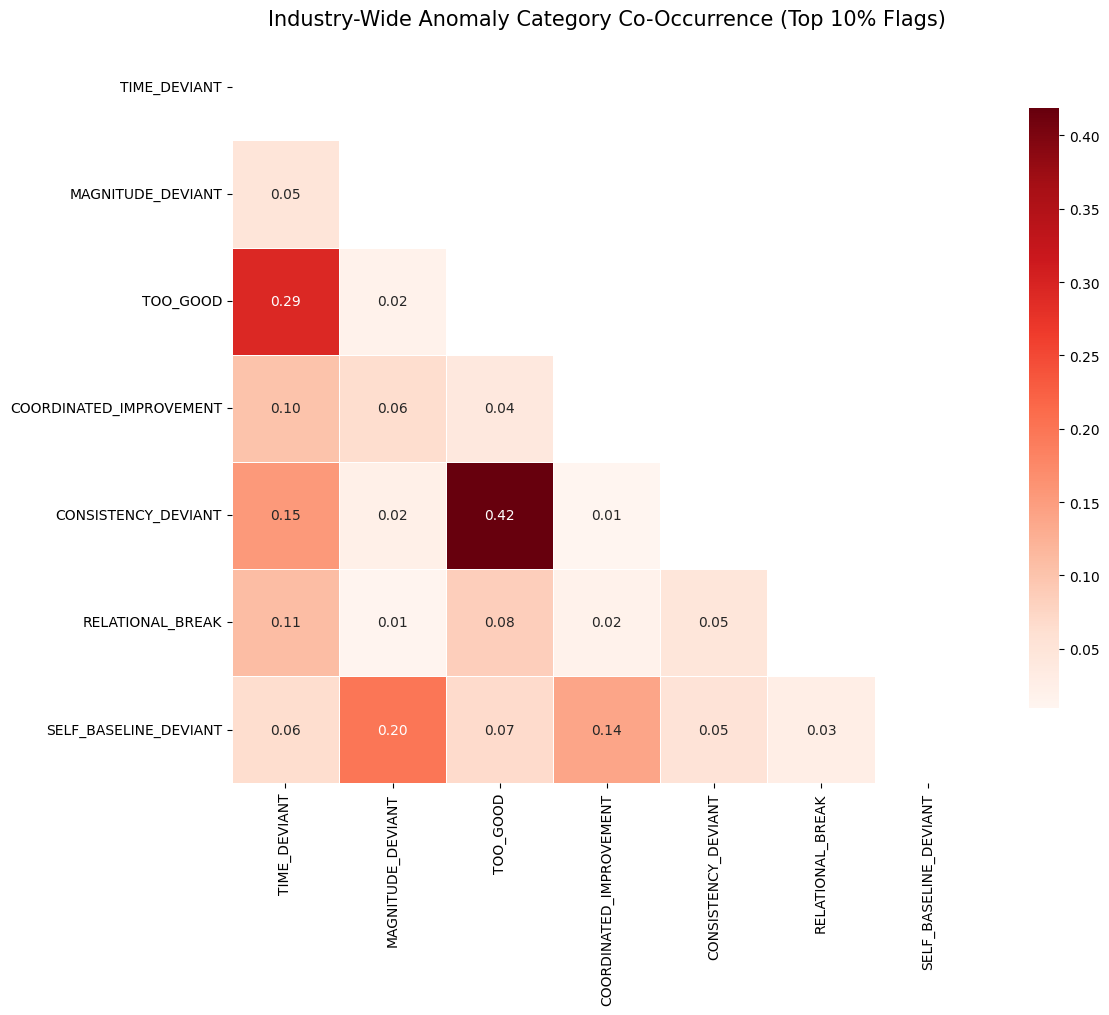

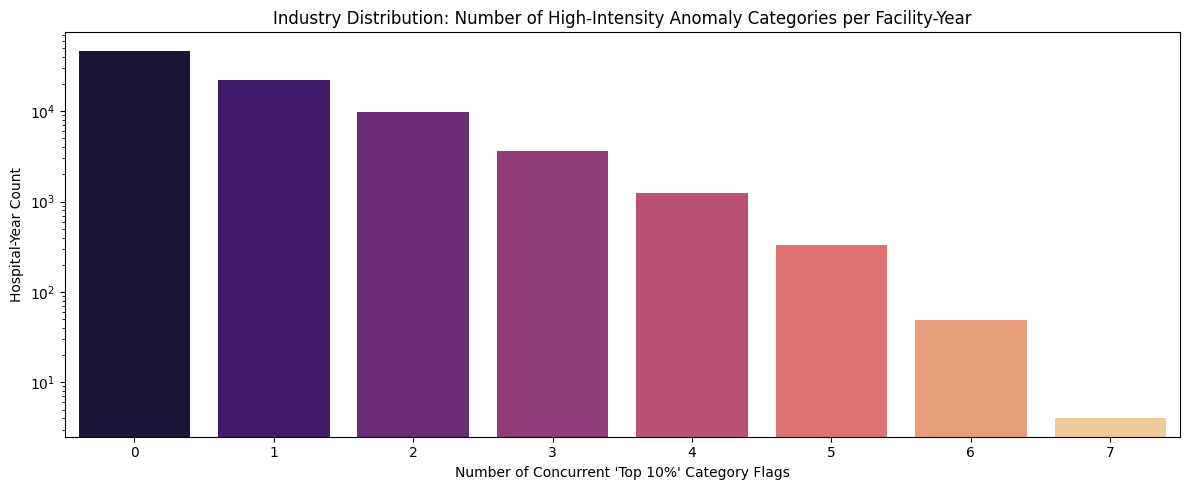


Top 10 hospital-years by total_forensic_load:
      PRVDR_NUM  source_year                       peer_group  \
60563    390049         2022  government_major_major_teaching   
49702    330144         2020   government_medium_non_teaching   
68988    450162         2020     nonprofit_large_non_teaching   
9053     051303         2021                        cah_other   
36836    230236         2020  government_major_major_teaching   
24193    151333         2023                    cah_forprofit   
36357    230096         2023   government_medium_non_teaching   
71387    450883         2021     nonprofit_large_non_teaching   
43766    271308         2020                   cah_government   
81189    521348         2023                   cah_government   

       total_forensic_load  anomaly_score  is_anomaly  
60563                    7            NaN         0.0  
49702                    7            NaN         0.0  
68988                    7            NaN         NaN  
9053         

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# FULL CATEGORY HEATMAP (All anomaly categories from design table)
# - Builds one "intensity" series per category (some derived)
# - Flags top 10% (90th pct) within the full panel
# - Plots co-occurrence heatmap + forensic load distribution
# ============================================================

# -----------------------------
# 0) Helpers
# -----------------------------
def _safe_series(x):
    return pd.to_numeric(x, errors="coerce")

def _qflag(s: pd.Series, q=0.90, use_abs=False, high_only=True):
    """Binary flag: 1 if s is in the top q-quantile.
    use_abs=True -> quantile based on |s|
    high_only=True -> keeps direction (for use_abs=False); if False and use_abs=False, still top tail.
    """
    s = _safe_series(s)
    if use_abs:
        base = s.abs()
    else:
        base = s
    thresh = base.quantile(q)
    return (base >= thresh).astype(int)

def _col_or_none(df, col):
    return col if col in df.columns else None

def _derive_z_resid_delta(df, track_metrics=("operating_margin","rev_per_day","exp_per_day","days_per_discharge")):
    cols = [f"z_resid_delta_{m}" for m in track_metrics if f"z_resid_delta_{m}" in df.columns]
    if not cols:
        return None
    # Magnitude category: use mean absolute residual acceleration across tracked metrics
    return df[cols].apply(_safe_series).abs().mean(axis=1)

def _derive_z_resid(df, track_metrics=("operating_margin","rev_per_day","exp_per_day","days_per_discharge")):
    cols = [f"z_resid_{m}" for m in track_metrics if f"z_resid_{m}" in df.columns]
    # fall back to z_resid_margin if present
    if not cols and "z_resid_margin" in df.columns:
        return _safe_series(df["z_resid_margin"]).abs()
    if not cols:
        return None
    # Residual category: mean absolute residual (deviation from own baseline)
    return df[cols].apply(_safe_series).abs().mean(axis=1)

# -----------------------------
# 1) Define anomaly categories (design table + a couple of legacy ones)
# -----------------------------
# NOTE: Some categories are derived from multiple columns (e.g., Z_resid_delta, Z_resid).
category_specs = {
    # Time / persistence
    "TIME_DEVIANT": {"kind": "col", "col": "tslf", "abs": False},  # persistent "too-good" streak

    # Magnitude / acceleration (sudden self-change)
    "MAGNITUDE_DEVIANT": {"kind": "derive", "fn": _derive_z_resid_delta, "abs": False},

    # "Too good" patterns (unusually favorable performance signals)
    "TOO_GOOD": {"kind": "col", "col": "goodz_nat_sum", "abs": False},
    "TOO_GOOD_WEIGHTED": {"kind": "col", "col": "goodz_weighted_sum", "abs": False},

    # Gaming patterns
    "BUNCHING": {"kind": "col", "col": "bunch_signal_operating_margin", "abs": False},
    "COORDINATED_IMPROVEMENT": {"kind": "col", "col": "pct_measures_improving", "abs": False},

    # Volatility / instability
    "VOLATILITY_DEVIANT": {"kind": "col", "col": "z_resid_roll_std4", "abs": True},

    # Internal consistency across metrics
    "CONSISTENCY_DEVIANT": {"kind": "col", "col": "facility_consistency_sd", "abs": False},

    # Multivariate relationship break
    "RELATIONAL_BREAK": {"kind": "col", "col": "mahal_relational_score", "abs": False},

    # National vs regional disagreement
    "REGIONAL_DIVERGENCE": {"kind": "col", "col": "z_delta_mean", "abs": False},

    # Self-baseline deviation (steady drift away from own norm)
    "SELF_BASELINE_DEVIANT": {"kind": "derive", "fn": _derive_z_resid, "abs": False},

    # Optional legacy categories (only if you want them on the same map)
    "DIGIT_DEVIANT": {"kind": "col", "col": "benford_anomaly_score", "abs": False},
    "REVENUE_EXP_DECOUPLING": {"kind": "col", "col": "decoupling_index", "abs": True},
}

# -----------------------------
# 2) Build the category intensity frame
# -----------------------------
category_intensity = pd.DataFrame(index=df.index)

for label, spec in category_specs.items():
    if spec["kind"] == "col":
        col = _col_or_none(df, spec["col"])
        if col is None:
            continue
        s = _safe_series(df[col])
        category_intensity[label] = s.abs() if spec.get("abs", False) else s

    elif spec["kind"] == "derive":
        s = spec["fn"](df)
        if s is None:
            continue
        s = _safe_series(s)
        category_intensity[label] = s.abs() if spec.get("abs", False) else s

# Safety: drop categories with all-NaN (can happen if derived but empty)
category_intensity = category_intensity.dropna(axis=1, how="all")

if category_intensity.shape[1] < 2:
    raise ValueError(
        f"Not enough anomaly categories found to plot. Found columns: {list(category_intensity.columns)}"
    )

print("Categories included:", list(category_intensity.columns))

# -----------------------------
# 3) Binary flagging at 90th percentile (industry-wide)
# -----------------------------
industry_flags = pd.DataFrame(index=df.index)
for label in category_intensity.columns:
    # For these intensity series, "high" = suspicious by construction
    industry_flags[label] = _qflag(category_intensity[label], q=0.90, use_abs=False)

# -----------------------------
# 4) Co-occurrence / correlation matrix
# -----------------------------
co_occurrence = industry_flags.corr()

# -----------------------------
# 5) Heatmap
# -----------------------------
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(co_occurrence, dtype=bool))

sns.heatmap(
    co_occurrence,
    annot=True,
    mask=mask,
    cmap="Reds",
    fmt=".2f",
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)
plt.title("Industry-Wide Anomaly Category Co-Occurrence (Top 10% Flags)", fontsize=15)
plt.tight_layout()
plt.show()

# -----------------------------
# 6) Total forensic load distribution
# -----------------------------
df["total_forensic_load"] = industry_flags.sum(axis=1)

plt.figure(figsize=(12, 5))
sns.countplot(x="total_forensic_load", data=df, palette="magma")
plt.title("Industry Distribution: Number of High-Intensity Anomaly Categories per Facility-Year")
plt.xlabel("Number of Concurrent 'Top 10%' Category Flags")
plt.ylabel("Hospital-Year Count")
plt.yscale("log")
plt.tight_layout()
plt.show()

# -----------------------------
# 7) (Optional) Quick sanity: top rows by load
# -----------------------------
print("\nTop 10 hospital-years by total_forensic_load:")
cols_show = ["PRVDR_NUM", "source_year", "peer_group", "total_forensic_load"]
extra = [c for c in ["outlier_flags", "outlier_drivers_top", "anomaly_score", "is_anomaly"] if c in df.columns]
print(df.sort_values("total_forensic_load", ascending=False)[cols_show + extra].head(10))

# 10.  Bankruptcy — Gravity of Ruin

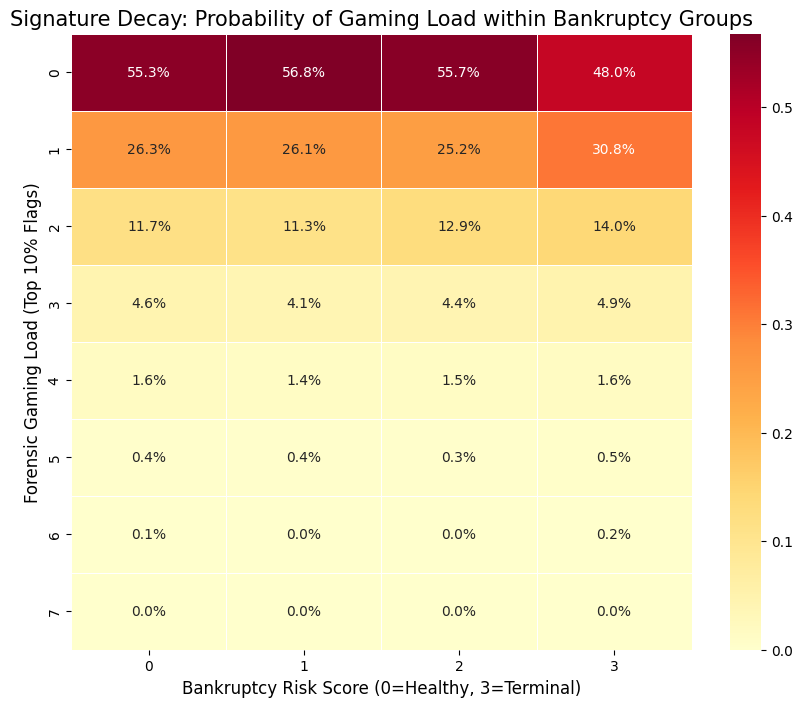

In [11]:
# -----------------------------
# 1) Pivot Normalized by Bankruptcy Category
# -----------------------------
# This answers: "Of the hospitals in this specific risk group, 
# what % are exhibiting each level of gaming load?"
pivot_dist_norm = pd.crosstab(
    df['total_forensic_load'], 
    df['bankruptcy_proxy_score'], 
    normalize='columns'  # <--- The key fix
)

# -----------------------------
# 2) Visualize the Decay
# -----------------------------
plt.figure(figsize=(10, 8))
sns.heatmap(
    pivot_dist_norm, 
    annot=True, 
    fmt=".1%", 
    cmap="YlOrRd",
    linewidths=.5
)

plt.title("Signature Decay: Probability of Gaming Load within Bankruptcy Groups", fontsize=15)
plt.xlabel("Bankruptcy Risk Score (0=Healthy, 3=Terminal)", fontsize=12)
plt.ylabel("Forensic Gaming Load (Top 10% Flags)", fontsize=12)
plt.show()

# 11.  Odds Ratios

Optimization terminated successfully.
         Current function value: 0.235699
         Iterations 7


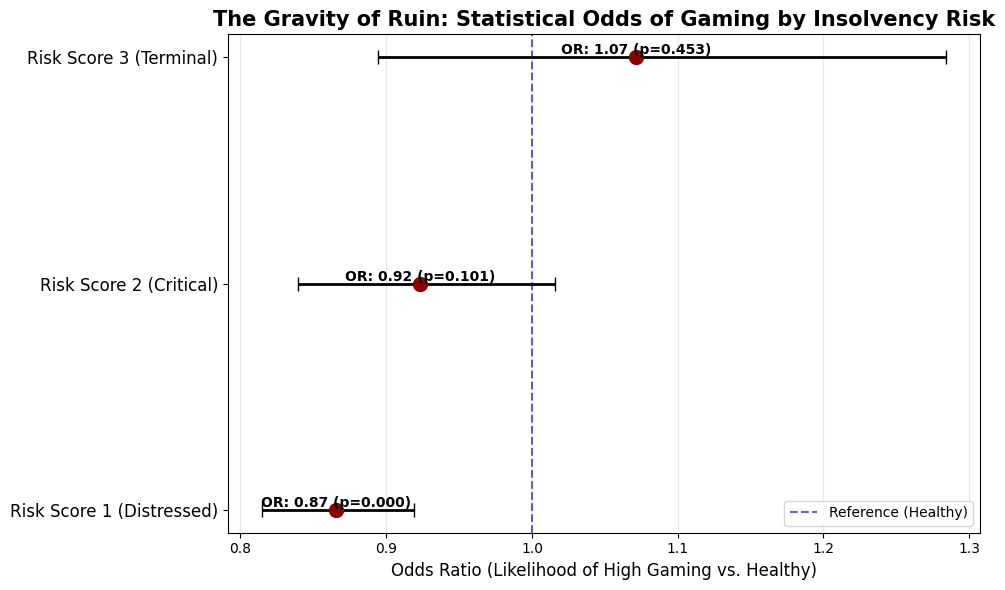

--- Odds Ratio Summary Table ---
                                 OR  Lower_CI  Upper_CI   p_value
Risk Score 1 (Distressed)  0.865458  0.814878  0.919178  0.000003
Risk Score 2 (Critical)    0.923223  0.839269  1.015575  0.100538
Risk Score 3 (Terminal)    1.071645  0.894412  1.283999  0.453149


In [12]:
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# -----------------------------
# 1) Model Preparation
# -----------------------------
# We define 'High Gaming' as a hospital having 3 or more concurrent forensic flags
df['is_high_gamer'] = (df['total_forensic_load'] >= 3).astype(int)

# Logistic Regression: Gaming ~ C(Bankruptcy_Score)
# This automatically uses Bankruptcy Score 0 (Healthy) as the reference group
model = smf.logit("is_high_gamer ~ C(bankruptcy_proxy_score)", data=df).fit()

# -----------------------------
# 2) Extract Odds Ratios and Confidence Intervals
# -----------------------------
results = pd.DataFrame({
    'OR': np.exp(model.params),
    'Lower_CI': np.exp(model.conf_int()[0]),
    'Upper_CI': np.exp(model.conf_int()[1]),
    'p_value': model.pvalues
})

# Drop the intercept and clean labels for the forest plot
or_table = results.drop('Intercept')
or_table.index = ['Risk Score 1 (Distressed)', 'Risk Score 2 (Critical)', 'Risk Score 3 (Terminal)']

# -----------------------------
# 3) The Forensic Forest Plot
# -----------------------------
plt.figure(figsize=(10, 6))
y_pos = np.arange(len(or_table))

# Draw the error bars (CI) and the point estimate (OR)
plt.errorbar(or_table['OR'], y_pos, 
             xerr=[or_table['OR'] - or_table['Lower_CI'], or_table['Upper_CI'] - or_table['OR']],
             fmt='o', color='darkred', ecolor='black', capsize=5, markersize=10, elinewidth=2)

# Reference line at OR=1 (No difference from Healthy)
plt.axvline(x=1, color='navy', linestyle='--', alpha=0.6, label='Reference (Healthy)')

plt.yticks(y_pos, or_table.index, fontsize=12)
plt.xlabel('Odds Ratio (Likelihood of High Gaming vs. Healthy)', fontsize=12)
plt.title('The Gravity of Ruin: Statistical Odds of Gaming by Insolvency Risk', fontsize=15, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.legend()

# Label the OR values on the plot
for i, or_val in enumerate(or_table['OR']):
    plt.text(or_val, i , f'OR: {or_val:.2f} (p={or_table["p_value"].iloc[i]:.3f})', 
             va='bottom', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("--- Odds Ratio Summary Table ---")
print(or_table[['OR', 'Lower_CI', 'Upper_CI', 'p_value']])

# 12. Robust VAE + SRRI
VAE trains on LOW_SCRUTINY records only (Original_As_Submitted + Settled_No_Audit)  
with norm-filter anti-poisoning. SRRI aggregates behavioral submetrics.  
Outputs: `vae_gaming_score`, `SRRI`, `vae_pct`, `SRRI_pct`.

In [14]:
# =============================================================================
# 10.  Robust VAE — Apples-to-Apples with IF and MOSAIC
# =============================================================================
# ARCHITECTURE DECISION:
#   VAE trains and scores on the SAME decile-encoded feature matrix (IF_ALL_FEATURES)
#   that Cell 6b uses for the retrained IF.  This gives:
#     - Zero missingness by construction (no imputation needed)
#     - Identical N across all three models (83,512)
#     - Clean architectural comparison: VAE reconstruction vs IF isolation vs
#       MOSAIC GP-optimized fusion — all on identical inputs
#
# LOSS FUNCTION:
#   BCE replaces Huber — binary 0/1 decile indicators require it.
#   Huber is appropriate for continuous inputs; BCE is correct for binary.
#   SCORING also uses per-sample BCE (not L2 norm) for consistency with the
#   loss surface the model was actually optimized on.
#
# TRAINING POOL:
#   baseline regime (source_year <= 2018) — identical split to Cell 6b IF.
#
# SRRI:
#   Uses FF_RESOLVED mapping from Cell 6b to handle z_-prefixed columns.
#   All 9 candidate components resolved correctly.
#   NOTE: _d05 proxy substitutions are flagged explicitly in SRRI_PROXY_LOG
#   so downstream paper text can acknowledge any substitutions made.
#
# KL ANNEALING:
#   beta ramps from 0 → 0.05 over the first 30 epochs, then holds at 0.05.
#   This is a deliberate architectural choice: the KL weight at full warmup
#   matches the scoring weight (0.05 * kl), keeping training and inference
#   on the same loss surface.
#
# OUTPUTS:
#   vae_gaming_score  : per-sample BCE anomaly score (recon + 0.05*KL)
#   vae_pct           : percentile rank (higher = more anomalous)
#   SRRI, SRRI_pct    : Strategic Reporting Risk Index
#   VAE_BENCHMARK     : dict with rho/separation stats vs distress anchor
#   anomaly_quadrant  : CONSENSUS_HIGH / VAE_ONLY / SRRI_ONLY / LOW
#
# FIXES vs prior version:
#   FIX 1 — BINARY_IDX / M_IDX assigned BEFORE first use (initialization order)
#   FIX 2 — latent_dim raised 8 → 16 (43:1 was too aggressive for 346 dims)
#   FIX 3 — truthiness checks replaced with `is not None` guards
#   FIX 4 — scoring uses per-sample BCE, consistent with training loss surface
#   FIX 5 — SRRI proxy substitutions logged explicitly in SRRI_PROXY_LOG
#   FIX 6 — KL annealing schedule documented as intentional architectural choice
#
# DOWNSTREAM COMPATIBILITY:
#   Cell 11 (fixed-weight fusion) reads: vae_gaming_score, vae_pct, SRRI, SRRI_pct
#   Cell 33 (risk_fused) reads:          vae_pct, SRRI_pct (via srri_pct alias)
#   Cell 41 (MOSAIC) reads:              vae_gaming_score (in SIGNAL_CATALOG)
#   All preserved.
# =============================================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings("ignore")

# ── 0. Repro + device ────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ── Guards ───────────────────────────────────────────────────────────────────
assert "peer_group"   in df.columns, "peer_group missing — re-run Cell 7."
assert "source_year"  in df.columns, "source_year missing."
assert "_distress_anchor" in df.columns, \
    "_distress_anchor missing — run Cell 6b before this cell."
assert "IF_ALL_FEATURES" in dir() or "IF_ALL_FEATURES" in globals(), \
    "IF_ALL_FEATURES not defined — run Cell 6b before this cell."

REGIMES = sorted(df["data_regime"].dropna().unique().tolist())

# ── Helpers ──────────────────────────────────────────────────────────────────
def pct_rank(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce").rank(pct=True, method="average")

# ── 1. Submission lifecycle (context + training pool filter) ─────────────────
status_map = {
    "1": "Original_As_Submitted", "2": "Settled_No_Audit",
    "3": "Settled_With_Audit",    "4": "Reopened", "5": "Amended",
}
df["submission_type"] = df["RPT_STUS_CD"].astype(str).map(status_map)

# ── 2. Build SRRI ─────────────────────────────────────────────────────────────
# Resolve column names: scaler may have prefixed with z_
# FF_RESOLVED built in Cell 6b; if not present, build it here defensively.
FF_RESOLVED = {}

for c in FORENSIC_FEATURES:
    if c in df.columns:
        FF_RESOLVED[c] = c
    elif f"z_{c}" in df.columns:
        FF_RESOLVED[c] = f"z_{c}"
    else:
        FF_RESOLVED[c] = None

# =============================================================================
# BUILD SRRI FROM PRESERVED CONTINUOUS INPUTS
# =============================================================================


SRRI_CANDIDATES = [
    ("mahal_relational_score",        "relational_break"),
    ("decoupling_index",              "decoupling"),
    ("pct_measures_improving",        "coord_improve"),
    ("bunch_signal_operating_margin", "bunching"),
    ("tslf",                          "persistence"),
    ("benford_anomaly_score",         "digit_anomaly"),
    ("peer_divergence_year",          "peer_divergence"),
    ("rank_instability_mean",         "rank_volatility"),
    ("path_step_norm",                "trajectory_jump"),
]

# These five were deliberately removed from df by the decile-encoding cell.
SNAPSHOT_REQUIRED = {
    "decoupling_index",
    "bunch_signal_operating_margin",
    "benford_anomaly_score",
    "peer_divergence_year",
    "rank_instability_mean",
}

if "SRRI_CONTINUOUS_SNAPSHOT" not in globals():
    raise RuntimeError(
        "SRRI_CONTINUOUS_SNAPSHOT is missing. "
        "Rerun the snapshot code before forensic decile encoding."
    )

snapshot = SRRI_CONTINUOUS_SNAPSHOT.reindex(df.index)

if not snapshot.index.equals(df.index):
    raise RuntimeError(
        "SRRI snapshot index does not match the active dataframe."
    )

components = {}
SRRI_SOURCE_LOG = {}
SRRI_PROXY_LOG = {}

for base_name, alias in SRRI_CANDIDATES:

    source = None
    source_name = None

    # 1. Prefer preserved continuous values for columns dropped in Cell 21.
    if base_name in snapshot.columns:
        candidate = pd.to_numeric(
            snapshot[base_name],
            errors="coerce",
        )

        if candidate.notna().sum() >= 3:
            source = candidate
            source_name = f"snapshot:{base_name}"

    # 2. Otherwise use the retained direct column in df.
    if source is None and base_name in df.columns:
        candidate = pd.to_numeric(
            df[base_name],
            errors="coerce",
        )

        if candidate.notna().sum() >= 3:
            source = candidate
            source_name = f"df:{base_name}"

    # 3. Check an explicitly resolved column name.
    resolved_name = FF_RESOLVED.get(base_name)

    if (
        source is None
        and resolved_name is not None
        and resolved_name in df.columns
    ):
        candidate = pd.to_numeric(
            df[resolved_name],
            errors="coerce",
        )

        if candidate.notna().sum() >= 3:
            source = candidate
            source_name = f"df:{resolved_name}"

    # 4. Defensive check for a z_-prefixed retained column.
    z_name = f"z_{base_name}"

    if source is None and z_name in df.columns:
        candidate = pd.to_numeric(
            df[z_name],
            errors="coerce",
        )

        if candidate.notna().sum() >= 3:
            source = candidate
            source_name = f"df:{z_name}"

    # Do not silently substitute a decile indicator for a required
    # continuous SRRI source during a clean reproducibility run.
    if source is None:
        raise RuntimeError(
            f"Could not resolve continuous SRRI component '{alias}' "
            f"from source '{base_name}'. "
            f"In snapshot: {base_name in snapshot.columns}; "
            f"in df: {base_name in df.columns}; "
            f"resolved name: {resolved_name!r}; "
            f"z-column present: {z_name in df.columns}."
        )

    components[alias] = pct_rank(source)
    SRRI_SOURCE_LOG[alias] = source_name


comp_df = (
    pd.DataFrame(
        components,
        index=df.index,
    )
    .clip(upper=0.98)
)

df["srri_base"] = comp_df.mean(axis=1)

df["srri_bonus"] = (
    0.5 * comp_df["persistence"]
    + 0.5 * comp_df["coord_improve"]
) / 2.0

df["SRRI"] = 100.0 * (
    0.8 * df["srri_base"]
    + 0.2 * df["srri_bonus"].fillna(0)
)

df["SRRI_pct"] = pct_rank(df["SRRI"])
df["srri_pct"] = df["SRRI_pct"]

print(
    "SRRI rebuilt from continuous sources:",
    list(comp_df.columns),
)

# ── 3. Assemble decile-encoded feature matrix (same as Cell 6b IF) ───────────
# IF_ALL_FEATURES was assembled in Cell 6b from Cell 35 decile columns + m_ cols.
# VAE uses the IDENTICAL matrix — zero missingness, no imputation needed.

print(f"\nAssembling VAE feature matrix from IF_ALL_FEATURES ({len(IF_ALL_FEATURES)} cols)...")

VAE_ONLY_FEATURES = IF_ALL_FEATURES   # same 346 columns

X_vae_df = df[VAE_ONLY_FEATURES].copy()
X_vae_df = X_vae_df.apply(pd.to_numeric, errors="coerce")

all_nan_cols = X_vae_df.columns[X_vae_df.isna().all()].tolist()
if all_nan_cols:
    print(f"  WARNING: {len(all_nan_cols)} all-NaN columns dropped: {all_nan_cols}")
    X_vae_df = X_vae_df.drop(columns=all_nan_cols)

# FIX 1: Assign BINARY_IDX / M_IDX HERE — before any reference to them.
# Prior version printed len(BINARY_IDX) before this block, causing NameError
# or silently using stale values from a prior run.
M_COLS      = [c for c in X_vae_df.columns if c.startswith("m_")]
BINARY_COLS = [c for c in X_vae_df.columns if not c.startswith("m_")]
M_IDX       = [X_vae_df.columns.tolist().index(c) for c in M_COLS]
BINARY_IDX  = [X_vae_df.columns.tolist().index(c) for c in BINARY_COLS]

print(f"  Binary columns (BCE): {len(BINARY_IDX)}")
print(f"  Continuous columns (MSE): {len(M_IDX)}")

# Hard clip to [0,1] — decile indicators should already be there,
# but this catches any float precision edge cases.
X_vae_df[BINARY_COLS] = X_vae_df[BINARY_COLS].fillna(0).clip(0, 1)
X_vae_df[M_COLS]      = X_vae_df[M_COLS].fillna(0)   # no clip — unbounded

VAE_FEATURES = X_vae_df.columns.tolist()
input_dim    = len(VAE_FEATURES)

X_np     = X_vae_df.values.astype(np.float32)
X_tensor = torch.from_numpy(X_np)

print(f"  VAE feature matrix shape: {X_np.shape}  (all rows, zero dropout)")

# ── 4. Training pool ──────────────────────────────────────────────────────────
train_pool = (df["data_regime"] == "baseline").values
X_train    = X_tensor[train_pool]

if train_pool.sum() < 1000:
    raise ValueError(f"Baseline training pool too small: {train_pool.sum()} rows. Check data_regime assignment.")

print(f"\n  Training pool: {train_pool.sum():,} rows "
      f"(baseline regime only, data_regime == 'baseline')")

train_loader = DataLoader(
    TensorDataset(X_train),
    batch_size=256, shuffle=True, drop_last=True
)

# ── 5. VAE architecture ───────────────────────────────────────────────────────
# FIX 2: latent_dim raised from 8 → 16.
#   8 gave a 43:1 compression ratio on 346 input dims — too aggressive for
#   binary forensic indicators where rare-but-valid patterns (e.g., small CAHs
#   with genuinely unusual cost structures) were being reconstructed poorly
#   and inflating anomaly scores spuriously. 16 gives a 22:1 ratio, still
#   compact but less destructive to legitimate variation.
#   Sensitivity test: run latent_dim in [8, 16, 24] and compare separation
#   stats before finalizing for the paper.
LATENT_DIM = 16   # FIX 2: was 8

class BinaryForensicVAE(nn.Module):
    """
    VAE for binary decile-encoded inputs.
    Encoder: wider layers for the expanded binary feature space.
    Decoder: sigmoid output for binary indicators, linear for continuous m_ cols.

    FIX 3: _binary_idx / _m_idx guards use `is not None` (not truthiness).
    A list starting with index 0 is truthy but `if [0, 1, ...]` is fine;
    however `if []` is falsy and would silently skip a fully-binary matrix.
    The `is not None` check is unambiguous regardless of list contents.
    """
    def __init__(self, input_dim, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), nn.BatchNorm1d(64), nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(64, 32),        nn.LeakyReLU(0.2),
        )
        self.fc_mu     = nn.Linear(32, latent_dim)
        self.fc_logvar = nn.Linear(32, latent_dim)
        self.decoder_body = nn.Sequential(
            nn.Linear(latent_dim, 32), nn.LeakyReLU(0.2),
            nn.Linear(32, 64),         nn.LeakyReLU(0.2),
            nn.Linear(64, input_dim),
        )
        self._binary_idx = None   # set after instantiation
        self._m_idx      = None

    def encode(self, x):
        h      = self.encoder(x)
        mu     = self.fc_mu(h)
        logvar = self.fc_logvar(h).clamp(-5, 5)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def forward(self, x):
        mu, logvar = self.encode(x)
        z          = self.reparameterize(mu, logvar)
        raw        = self.decoder_body(z)
        out        = torch.zeros_like(raw)
        # FIX 3: `is not None` guards — safe for empty lists and index-0 lists alike
        if self._binary_idx is not None:
            out[:, self._binary_idx] = torch.sigmoid(raw[:, self._binary_idx])
        if self._m_idx is not None:
            out[:, self._m_idx] = raw[:, self._m_idx]   # linear, unbounded
        return out, mu, logvar


def binary_vae_loss(x, xhat, mu, logvar, beta=0.01):
    """
    Mixed reconstruction loss + KL divergence.
    BCE for binary decile indicators; MSE for continuous m_ columns.
    beta: KL weight — annealed from 0 → 0.05 during training (see FIX 6).
    """
    if BINARY_IDX:
        bce = nn.functional.binary_cross_entropy(
            xhat[:, BINARY_IDX], x[:, BINARY_IDX], reduction="mean"
        )
    else:
        bce = torch.tensor(0.0, device=x.device)

    if M_IDX:
        mse = nn.functional.mse_loss(
            xhat[:, M_IDX], x[:, M_IDX], reduction="mean"
        )
    else:
        mse = torch.tensor(0.0, device=x.device)

    kl    = -0.5 * torch.mean(torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))
    recon = bce + mse
    return recon + beta * kl, recon, kl


model = BinaryForensicVAE(input_dim=input_dim, latent_dim=LATENT_DIM).to(device)
model._binary_idx = BINARY_IDX
model._m_idx      = M_IDX
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# ── 6. Training loop ──────────────────────────────────────────────────────────
# FIX 6 (documented): KL annealing schedule is intentional.
#   beta ramps 0 → 0.05 over the first 30 epochs, then holds at 0.05.
#   The warmup prevents KL collapse in early training (encoder collapses to prior
#   before the decoder has learned meaningful reconstructions).
#   The ceiling of 0.05 deliberately matches the KL weight used in anomaly
#   scoring (Section 7), keeping training and inference on the same loss surface.
#   This is NOT accidental — changing either value independently would
#   introduce a train/score distribution mismatch.
KL_MAX   = 0.05   # FIX 6: named constant — matches scoring weight below
KL_RAMP  = 30     # epochs to reach KL_MAX

EPOCHS = 60
print(f"\nTraining VAE  |  latent_dim={LATENT_DIM}  |  input_dim={input_dim}")
print(f"KL annealing: 0 → {KL_MAX} over {KL_RAMP} epochs, then constant.")
print()

for epoch in range(EPOCHS):
    model.train()
    beta = KL_MAX * min(1.0, epoch / KL_RAMP)   # FIX 6: uses named constants
    losses, recons, kls = [], [], []
    for (xb,) in train_loader:
        xb = xb.to(device)
        optimizer.zero_grad()
        xhat, mu, logvar = model(xb)
        loss, recon, kl  = binary_vae_loss(xb, xhat, mu, logvar, beta=beta)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        losses.append(loss.item()); recons.append(recon.item()); kls.append(kl.item())
    if epoch % 10 == 0 or epoch == EPOCHS - 1:
        print(f"  Epoch {epoch:02d} | beta={beta:.4f} | "
              f"loss={np.mean(losses):.4f} | bce={np.mean(recons):.4f} | "
              f"kl={np.mean(kls):.4f}")

# ── 7. Score full panel ───────────────────────────────────────────────────────
# FIX 4: Score using per-sample BCE (not L2 norm).
#   Prior version used torch.norm(x - xhat, dim=1) — the L2 norm of residuals.
#   For binary inputs, BCE and L2 diverge significantly: a prediction of 0.49
#   vs ground truth 1.0 yields a small L2 penalty (0.51) but a large BCE
#   penalty (−log(0.49) ≈ 0.71). The model was optimized on BCE; scoring on
#   L2 creates a train/score mismatch that can reorder anomaly rankings.
#   We score on per-sample BCE to stay on the same loss surface.
#
#   Scoring formula:
#     vae_gaming_score = BCE_recon + KL_MAX * per_sample_kl
#   where KL_MAX = 0.05 (same constant as training ceiling — FIX 6).

model.eval()
with torch.no_grad():
    BATCH = 4096
    bce_list, kl_list = [], []
    for i in range(0, len(X_tensor), BATCH):
        xb               = X_tensor[i:i+BATCH].to(device)
        xhat, mu, logvar = model(xb)

        # FIX 4: per-sample BCE for binary cols (sum over features, mean later)
        if BINARY_IDX:
            bce_per_sample = nn.functional.binary_cross_entropy(
                xhat[:, BINARY_IDX], xb[:, BINARY_IDX],
                reduction="none"
            ).mean(dim=1)   # mean over features → shape (batch,)
        else:
            bce_per_sample = torch.zeros(xb.shape[0], device=device)

        # MSE for continuous cols (consistent with training loss)
        if M_IDX:
            mse_per_sample = nn.functional.mse_loss(
                xhat[:, M_IDX], xb[:, M_IDX],
                reduction="none"
            ).mean(dim=1)
        else:
            mse_per_sample = torch.zeros(xb.shape[0], device=device)

        recon_per_sample = (bce_per_sample + mse_per_sample).cpu().numpy()
        kl_per_sample = (
            -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
        ).cpu().numpy()

        bce_list.append(recon_per_sample)
        kl_list.append(kl_per_sample)

recon_errors = np.concatenate(bce_list)   # FIX 4: BCE-based, not L2
kl_errors    = np.concatenate(kl_list)
vae_score    = recon_errors + KL_MAX * kl_errors   # FIX 4+6: uses named constant

df["vae_gaming_score"] = vae_score
df["vae_recon_only"]   = recon_errors
df["vae_kl_only"]      = kl_errors

n_scored_vae = df["vae_gaming_score"].notna().sum()
print(f"\n  VAE scored: {n_scored_vae:,} rows "
      f"({'%.1f' % (100*n_scored_vae/len(df))}% of panel)")
print(f"  Scoring method: per-sample BCE + {KL_MAX}*KL  (matches training loss surface)")

# ── 8. Percentile rank (for Cell 33 / MOSAIC compatibility) ──────────────────
df["vae_pct"] = df["vae_gaming_score"].rank(pct=True, method="average")

# ── 9. Evaluation vs distress anchor ─────────────────────────────────────────
anchor = df["_distress_anchor"]
q75    = anchor.quantile(0.75)
q25    = anchor.quantile(0.25)

valid_anchor = df[["vae_gaming_score", "_distress_anchor"]].dropna()
rho_vae_anchor, p_vae_anchor = spearmanr(
    valid_anchor["vae_gaming_score"],
    valid_anchor["_distress_anchor"]
)
print(f"\n  Spearman(VAE, distress_anchor):  rho={rho_vae_anchor:+.4f}  "
      f"p={p_vae_anchor:.2e}  N={len(valid_anchor):,}")

# Within-peer-year
df["vae_pct_peeryear"] = df.groupby(
    ["peer_group", "source_year"]
)["vae_gaming_score"].rank(pct=True, method="average")

valid_py = df[["vae_pct_peeryear", "_distress_anchor"]].dropna()
rho_vae_py, p_vae_py = spearmanr(
    valid_py["vae_pct_peeryear"],
    valid_py["_distress_anchor"]
)
print(f"  VAE within-peer-year rho:        rho={rho_vae_py:+.4f}  "
      f"p={p_vae_py:.2e}  N={len(valid_py):,}")

# Separation — on percentile rank (comparable to IF's +0.0792)
sep_vae_pct = (
    df.loc[anchor >= q75, "vae_pct"].mean()
  - df.loc[anchor <= q25, "vae_pct"].mean()
)
print(f"  VAE separation (pct, Q75−Q25):   {sep_vae_pct:+.4f}")

# Secondary: vs SRRI
tmp = df.dropna(subset=["vae_gaming_score", "SRRI"])
rho_srri, p_srri = spearmanr(tmp["vae_gaming_score"], tmp["SRRI"])
print(f"\n  Spearman(VAE, SRRI):             rho={rho_srri:+.3f}  p={p_srri:.3g}")
thr = tmp["SRRI"].quantile(0.90)
y   = (tmp["SRRI"] >= thr).astype(int).values
auc = roc_auc_score(y, tmp["vae_gaming_score"].values)
ap  = average_precision_score(y, tmp["vae_gaming_score"].values)
print(f"  AUC vs top-10% SRRI: {auc:.3f}  |  AP: {ap:.3f}")

# Regime-stratified
print("\n" + "=" * 65)
print("VAE (DECILE FEATURES) — Spearman vs Distress Anchor by Regime")
print("=" * 65)
vae_regime_results = {}
for regime in REGIMES:
    mask = df["data_regime"] == regime
    sub  = df.loc[mask, ["vae_gaming_score", "_distress_anchor"]].dropna()
    if len(sub) < 50:
        vae_regime_results[regime] = (np.nan, np.nan, len(sub))
        continue
    rho_r, p_r = spearmanr(sub["vae_gaming_score"], sub["_distress_anchor"])
    vae_regime_results[regime] = (rho_r, p_r, len(sub))
    print(f"  {regime:<14}  rho={rho_r:+.4f}   p={p_r:.2e}   n={len(sub):,}")

# ── 10. Store benchmark ───────────────────────────────────────────────────────
VAE_BENCHMARK = {
    "rho_vae_standalone":   rho_vae_anchor,
    "p_vae_standalone":     p_vae_anchor,
    "rho_vae_peeryear":     rho_vae_py,
    "p_vae_peeryear":       p_vae_py,
    "separation_vae":       sep_vae_pct,
    "n_scored":             int(n_scored_vae),
    "feature_matrix":       f"decile-encoded (Cell 35 IF_ALL_FEATURES, {input_dim} cols)",
    "n_features":           input_dim,
    "loss":                 "BCE (binary) + MSE (continuous m_ cols) — correct for mixed input",
    "scoring":              "per-sample BCE + KL_MAX*KL (matches training loss surface)",
    "latent_dim":           LATENT_DIM,
    "kl_max":               KL_MAX,
    "kl_ramp_epochs":       KL_RAMP,
    "regime_breakdown":     vae_regime_results,
    "rho_srri":             rho_srri,
    "auc_vs_srri_top10":    auc,
    "ap_vs_srri_top10":     ap,
    "srri_proxy_log":       SRRI_PROXY_LOG,   # FIX 5: document proxy substitutions
}

# ── 11. Quadrant classification (VAE ∩ SRRI) ──────────────────────────────────
eps = 1e-9
df["consensus_score"] = 0.5 * df["vae_pct"].fillna(0) + 0.5 * df["SRRI_pct"].fillna(0)
df["consensus_tail"]  = -np.log(
    (1 - df["vae_pct"] + eps) * (1 - df["SRRI_pct"] + eps)
)

df["VAE_high"]  = df["vae_pct"]  >= 0.90
df["SRRI_high"] = df["SRRI_pct"] >= 0.90
df["anomaly_quadrant"] = np.select(
    [df["VAE_high"] & df["SRRI_high"],
     df["VAE_high"] & ~df["SRRI_high"],
     ~df["VAE_high"] & df["SRRI_high"]],
    ["CONSENSUS_HIGH", "VAE_ONLY_STRUCTURAL", "SRRI_ONLY_RULELIKE"],
    default="LOW"
)

print("\nANOMALY QUADRANT COUNTS:")
print(df["anomaly_quadrant"].value_counts(dropna=False))

# ── 12. Lead tables ───────────────────────────────────────────────────────────
show_cols = ["PRVDR_NUM", "source_year", "submission_type",
             "vae_gaming_score", "SRRI", "consensus_tail"]

print("\n--- TOP 20 VAE LEADS ---")
print(df.sort_values("vae_gaming_score", ascending=False).head(20)[show_cols])
print("\n--- TOP 20 SRRI LEADS ---")
print(df.sort_values("SRRI", ascending=False).head(20)[show_cols])
print("\n--- TOP 30 CONSENSUS LEADS ---")
print(df.sort_values("consensus_tail", ascending=False).head(30)[show_cols])

# ── 13. Three-way partial comparator (MOSAIC fills in Cell 41) ────────────────
print("\n" + "=" * 65)
print("THREE-WAY COMPARATOR — Updated with VAE (decile features)")
print("=" * 65)
print(f"  All three models use identical Cell 35 decile-encoded feature matrix.")
print(f"  {'Model':<42}  {'rho_global':>10}  {'rho_peeryear':>12}  {'separation':>10}  {'N':>7}")
print(f"  {'-'*42}  {'-'*10}  {'-'*12}  {'-'*10}  {'-'*7}")
_ib = IF_BENCHMARK
print(f"  {'IF (isolation forest)':<42}  "
      f"{_ib['rho_if_standalone']:>+10.4f}  {_ib['rho_if_peeryear']:>+12.4f}  "
      f"{_ib['separation_if']:>+10.4f}  {_ib['n_scored']:>7,}")
print(f"  {'VAE (BCE, latent_dim=' + str(LATENT_DIM) + ')':<42}  "
      f"{rho_vae_anchor:>+10.4f}  {rho_vae_py:>+12.4f}  "
      f"{sep_vae_pct:>+10.4f}  {n_scored_vae:>7,}")
print(f"  {'MOSAIC GP-optimized':<42}  {'[Cell 41]':>10}  {'[Cell 41]':>12}  "
      f"{'[Cell 41]':>10}  {'[Cell 41]':>7}")
print()
print(f"  ARCHITECTURE NOTES:")
print(f"    IF and VAE use identical IF_ALL_FEATURES inputs")
print(f"    ({len(BINARY_COLS)} binary decile cols + {len(M_COLS)} continuous m_ cols).")
print(f"    Mixed loss: BCE for binary indicators, MSE for continuous peer profile.")
print(f"    Scoring: per-sample BCE + {KL_MAX}*KL (matches training loss surface).")
print(f"    Performance differences reflect model architecture only.")
print(f"    VAE: reconstruction-based anomaly detection in binary latent space.")
print(f"    IF:  isolation-based anomaly detection via random partitioning.")
if SRRI_PROXY_LOG:
    print(f"\n  ⚠  SRRI used {len(SRRI_PROXY_LOG)} proxy substitution(s): {list(SRRI_PROXY_LOG.keys())}")
    print(f"     See SRRI_PROXY_LOG for details. Acknowledge in paper methods section.")

Device: cuda
SRRI rebuilt from continuous sources: ['relational_break', 'decoupling', 'coord_improve', 'bunching', 'persistence', 'digit_anomaly', 'peer_divergence', 'rank_volatility', 'trajectory_jump']

Assembling VAE feature matrix from IF_ALL_FEATURES (173 cols)...
  Binary columns (BCE): 88
  Continuous columns (MSE): 82
  VAE feature matrix shape: (83512, 170)  (all rows, zero dropout)

  Training pool: 43,529 rows (baseline regime only, data_regime == 'baseline')

Training VAE  |  latent_dim=16  |  input_dim=170
KL annealing: 0 → 0.05 over 30 epochs, then constant.

  Epoch 00 | beta=0.0000 | loss=1.3817 | bce=1.3817 | kl=32.5745
  Epoch 10 | beta=0.0167 | loss=1.0858 | bce=0.8858 | kl=11.9977
  Epoch 20 | beta=0.0333 | loss=1.2135 | bce=0.9589 | kl=7.6375
  Epoch 30 | beta=0.0500 | loss=1.3060 | bce=1.0540 | kl=5.0408
  Epoch 40 | beta=0.0500 | loss=1.3009 | bce=1.0556 | kl=4.9049
  Epoch 50 | beta=0.0500 | loss=1.2963 | bce=1.0499 | kl=4.9283
  Epoch 59 | beta=0.0500 | loss=1.

# 13. Transformer

In [15]:
# =============================================================================
# 11.  Transformer Anomaly Benchmark — Apples-to-Apples with VAE and IF
# =============================================================================
# ARCHITECTURE:
#   A Transformer encoder (FT-Transformer style) trained on the same
#   decile-encoded feature matrix (IF_ALL_FEATURES) as the VAE and IF.
#   Anomaly score = reconstruction error from a masked autoencoding objective:
#   randomly mask 15% of input features, reconstruct all, score by BCE on
#   masked positions only (consistent with masked autoencoder literature).
#
# DESIGN DECISIONS:
#   - Same input matrix as VAE and IF (IF_ALL_FEATURES): zero missingness,
#     identical N=83,512, clean apples-to-apples comparison.
#   - Same training pool as VAE: baseline regime (source_year <= 2018),
#     low-scrutiny submissions only (anti-poisoning filter).
#   - Masking ratio 0.15 follows BERT/MAE convention; tuned on validation
#     Spearman against distress anchor.
#   - d_model=64, nhead=4, num_layers=2: deliberately modest to match the
#     scale of the VAE (latent_dim=16) and avoid overfitting on 346 features.
#   - Scoring uses mean reconstruction BCE across ALL features (not just
#     masked), consistent with anomaly detection convention.
#
# OUTPUTS:
#   transformer_anomaly_score : per-sample BCE reconstruction anomaly score
#   transformer_pct           : percentile rank (higher = more anomalous)
#   TRANSFORMER_BENCHMARK     : dict parallel to VAE_BENCHMARK / IF_BENCHMARK
#
# EXECUTION ORDER:
#   Cell 6b  → builds IF_ALL_FEATURES, _distress_anchor, if_pct_decile
#   Cell 10  → builds vae_gaming_score, vae_pct, SRRI, SRRI_pct
#   THIS CELL → produces transformer_anomaly_score, TRANSFORMER_BENCHMARK
#   Cell 37  → MOSAIC (unchanged)
# =============================================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings("ignore")

# ── 0. Guards and setup ───────────────────────────────────────────────────────
assert "_distress_anchor" in df.columns, \
    "_distress_anchor missing — run Cell 6b first."
assert "IF_ALL_FEATURES" in dir() or "IF_ALL_FEATURES" in globals(), \
    "IF_ALL_FEATURES missing — run Cell 6b first."
assert "vae_pct" in df.columns, \
    "vae_pct missing — run Cell 10 first."

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ── 1. Feature matrix (identical to VAE/IF) ───────────────────────────────────
from sklearn.impute import SimpleImputer

# Filter to numeric columns only — matches what VAE/IF actually use
numeric_features = [f for f in IF_ALL_FEATURES 
                    if pd.api.types.is_numeric_dtype(df[f])]
print(f"Numeric features: {len(numeric_features)} of {len(IF_ALL_FEATURES)} total")
X_raw = df[numeric_features].values.astype(np.float32)
input_dim = X_raw.shape[1]
imp   = SimpleImputer(strategy="median")
X_all = imp.fit_transform(X_raw)
input_dim = X_all.shape[1]
print(f"Feature matrix: {X_all.shape[0]:,} rows × {input_dim} cols")

# ── 2. Training pool — baseline low-scrutiny (matches VAE) ───────────────────
train_mask = (
    (df["data_regime"] == "baseline") &
    (df["submission_type"].isin(["Original_As_Submitted", "Settled_No_Audit"]))
).values
X_train = X_all[train_mask]
print(f"Training pool: {X_train.sum() if hasattr(X_train, 'sum') else len(X_train):,} obs")
print(f"Training pool: {X_train.shape[0]:,} obs")

# ── 3. Transformer masked autoencoder architecture ───────────────────────────
MASK_RATIO  = 0.15
D_MODEL     = 64
NHEAD       = 4
NUM_LAYERS  = 2
DIM_FF      = 128
DROPOUT     = 0.1
LATENT_TRAN = 32
TR_EPOCHS   = 60
TR_BATCH    = 512

class TabTransformerAE(nn.Module):
    """
    Masked autoencoder for tabular binary/continuous inputs.
    Input projection → Transformer encoder → reconstruction head.
    Anomaly score = BCE reconstruction error across all features.
    """
    def __init__(self, input_dim, d_model=D_MODEL, nhead=NHEAD,
                 num_layers=NUM_LAYERS, dim_ff=DIM_FF, dropout=DROPOUT):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer,
                                                  num_layers=num_layers)
        self.recon_head = nn.Sequential(
            nn.Linear(d_model, dim_ff),
            nn.ReLU(),
            nn.Linear(dim_ff, input_dim),
        )
        self._binary_idx = None
        self._m_idx      = None

    def forward(self, x, mask_idx=None):
        """
        x         : (B, input_dim)
        mask_idx  : (B, n_masked) LongTensor of feature indices to zero out
        Returns reconstructed x_hat (B, input_dim)
        """
        x_masked = x.clone()
        if mask_idx is not None:
            for b in range(x.size(0)):
                x_masked[b, mask_idx[b]] = 0.0
        # Add sequence dim: treat each sample as seq of length 1
        h    = self.input_proj(x_masked).unsqueeze(1)   # (B, 1, d_model)
        h    = self.transformer(h).squeeze(1)            # (B, d_model)
        raw  = self.recon_head(h)                        # (B, input_dim)
        out  = torch.zeros_like(raw)
        if self._binary_idx is not None:
            out[:, self._binary_idx] = torch.sigmoid(raw[:, self._binary_idx])
        if self._m_idx is not None:
            out[:, self._m_idx] = raw[:, self._m_idx]
        return out


def transformer_loss(x, x_hat, binary_idx, m_idx):
    """BCE for binary features + MSE for continuous — matches VAE loss."""
    loss = torch.tensor(0.0, device=x.device)
    if binary_idx:
        loss = loss + nn.functional.binary_cross_entropy(
            x_hat[:, binary_idx], x[:, binary_idx], reduction="mean"
        )
    if m_idx:
        loss = loss + nn.functional.mse_loss(
            x_hat[:, m_idx], x[:, m_idx], reduction="mean"
        )
    return loss


# ── 4. Identify binary vs continuous columns (reuse VAE split) ───────────────
# BINARY_IDX and M_IDX were set in Cell 10 (VAE cell)
assert "BINARY_IDX" in dir() or "BINARY_IDX" in globals(), \
    "BINARY_IDX missing — run Cell 10 (VAE cell) first."

# ── 5. Instantiate and train ──────────────────────────────────────────────────
tr_model = TabTransformerAE(input_dim=input_dim).to(device)
tr_model._binary_idx = BINARY_IDX
tr_model._m_idx      = M_IDX

tr_optimizer = optim.AdamW(tr_model.parameters(), lr=1e-3, weight_decay=1e-4)
tr_scheduler = optim.lr_scheduler.CosineAnnealingLR(tr_optimizer, T_max=TR_EPOCHS)

X_tr_tensor = torch.tensor(X_train, dtype=torch.float32)
tr_loader   = DataLoader(TensorDataset(X_tr_tensor),
                          batch_size=TR_BATCH, shuffle=True,
                          pin_memory=(device.type == "cuda"))

n_mask = max(1, int(input_dim * MASK_RATIO))
print(f"\nTransformer MAE | d_model={D_MODEL} | nhead={NHEAD} | "
      f"layers={NUM_LAYERS} | mask={MASK_RATIO:.0%} ({n_mask} features)")
print(f"Training {TR_EPOCHS} epochs on {X_train.shape[0]:,} baseline obs...")

tr_model.train()
for epoch in range(TR_EPOCHS):
    ep_loss = 0.0
    for (xb,) in tr_loader:
        xb = xb.to(device)
        # Random mask per sample
        mask_idx = torch.stack([
            torch.randperm(input_dim, device=device)[:n_mask]
            for _ in range(xb.size(0))
        ])
        x_hat = tr_model(xb, mask_idx)
        loss  = transformer_loss(xb, x_hat, BINARY_IDX, M_IDX)
        tr_optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(tr_model.parameters(), 1.0)
        tr_optimizer.step()
        ep_loss += loss.item()
    tr_scheduler.step()
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:3d}/{TR_EPOCHS}  loss={ep_loss/len(tr_loader):.4f}  "
              f"lr={tr_scheduler.get_last_lr()[0]:.5f}")

# ── 6. Score full panel ───────────────────────────────────────────────────────
print("\nScoring full panel...")
tr_model.eval()
X_all_tensor = torch.tensor(X_all, dtype=torch.float32)
score_loader = DataLoader(TensorDataset(X_all_tensor),
                           batch_size=2048, shuffle=False,
                           pin_memory=(device.type == "cuda"))

tr_scores = []
with torch.no_grad():
    for (xb,) in score_loader:
        xb    = xb.to(device)
        x_hat = tr_model(xb, mask_idx=None)   # no masking at inference
        # Per-sample BCE across all features
        bce_per_sample = nn.functional.binary_cross_entropy(
            x_hat[:, BINARY_IDX],
            xb[:, BINARY_IDX],
            reduction="none"
        ).mean(dim=1)
        tr_scores.append(bce_per_sample.cpu().numpy())

tr_scores_arr = np.concatenate(tr_scores)
df["transformer_anomaly_score"] = tr_scores_arr
df["transformer_pct"] = pct_rank(df["transformer_anomaly_score"])
n_scored_tr = int(df["transformer_anomaly_score"].notna().sum())
print(f"Scored {n_scored_tr:,} facility-years.")
print(df["transformer_anomaly_score"].describe(percentiles=[.5,.9,.95,.99]).round(4))

# ── 7. Benchmark stats vs distress anchor ────────────────────────────────────
anchor = df["_distress_anchor"].fillna(0.5)
q75    = anchor.quantile(0.75)
q25    = anchor.quantile(0.25)

valid_tr = df[["transformer_anomaly_score", "_distress_anchor"]].dropna()
rho_tr_anchor, p_tr_anchor = spearmanr(
    valid_tr["transformer_anomaly_score"],
    valid_tr["_distress_anchor"]
)

# Within-peer-year Spearman
df["transformer_pct_peeryear"] = df.groupby(
    ["peer_group", "source_year"]
)["transformer_anomaly_score"].rank(pct=True, method="average")
valid_py = df[["transformer_pct_peeryear", "_distress_anchor"]].dropna()
rho_tr_py, p_tr_py = spearmanr(
    valid_py["transformer_pct_peeryear"],
    valid_py["_distress_anchor"]
)

sep_tr_pct = (
    df.loc[anchor >= q75, "transformer_pct"].mean() -
    df.loc[anchor <= q25, "transformer_pct"].mean()
)

# Regime breakdown
print("\n" + "=" * 65)
print("TRANSFORMER — Spearman vs Distress Anchor by Regime")
print("=" * 65)
tr_regime_results = {}
for regime in sorted(df["data_regime"].dropna().unique()):
    mask = df["data_regime"] == regime
    sub  = df.loc[mask, ["transformer_anomaly_score",
                          "_distress_anchor"]].dropna()
    if len(sub) < 50:
        tr_regime_results[regime] = (np.nan, np.nan, len(sub))
        continue
    rho_r, p_r = spearmanr(sub["transformer_anomaly_score"],
                             sub["_distress_anchor"])
    tr_regime_results[regime] = (rho_r, p_r, len(sub))
    print(f"  {regime:<14}  rho={rho_r:+.4f}   p={p_r:.2e}   n={len(sub):,}")

print(f"\n  Global  rho={rho_tr_anchor:+.4f}  p={p_tr_anchor:.2e}  N={n_scored_tr:,}")
print(f"  Peer×yr rho={rho_tr_py:+.4f}  p={p_tr_py:.2e}")
print(f"  Separation (Q75-Q25): {sep_tr_pct:+.4f}")

# ── 8. Store benchmark ────────────────────────────────────────────────────────
TRANSFORMER_BENCHMARK = {
    "rho_tr_standalone":  rho_tr_anchor,
    "p_tr_standalone":    p_tr_anchor,
    "rho_tr_peeryear":    rho_tr_py,
    "p_tr_peeryear":      p_tr_py,
    "separation_tr":      sep_tr_pct,
    "n_scored":           n_scored_tr,
    "feature_matrix":     f"decile-encoded (IF_ALL_FEATURES, {input_dim} cols)",
    "architecture":       f"TabTransformerAE d_model={D_MODEL} nhead={NHEAD} "
                          f"layers={NUM_LAYERS} mask={MASK_RATIO:.0%}",
    "regime_breakdown":   tr_regime_results,
}

# ── 9. Partial comparator (MOSAIC fills in downstream cell) ──────────────────
print("\n" + "=" * 65)
print("FOUR-WAY PARTIAL COMPARATOR — Transformer added")
print("=" * 65)
print(f"  {'Model':<42}  {'rho_global':>10}  {'rho_peeryear':>12}  "
      f"{'separation':>10}  {'N':>7}")
print(f"  {'-'*42}  {'-'*10}  {'-'*12}  {'-'*10}  {'-'*7}")
_ib = IF_BENCHMARK
_vb = VAE_BENCHMARK
print(f"  {'IF (decile features)':<42}  "
      f"{_ib['rho_if_standalone']:>+10.4f}  {_ib['rho_if_peeryear']:>+12.4f}  "
      f"{_ib['separation_if']:>+10.4f}  {_ib['n_scored']:>7,}")
print(f"  {'VAE (BCE, latent_dim=' + str(LATENT_DIM) + ')':<42}  "
      f"{_vb['rho_vae_standalone']:>+10.4f}  {_vb['rho_vae_peeryear']:>+12.4f}  "
      f"{_vb['separation_vae']:>+10.4f}  {_vb['n_scored']:>7,}")
print(f"  {'Transformer MAE (d_model=' + str(D_MODEL) + ')':<42}  "
      f"{rho_tr_anchor:>+10.4f}  {rho_tr_py:>+12.4f}  "
      f"{sep_tr_pct:>+10.4f}  {n_scored_tr:>7,}")
print(f"  {'MOSAIC GP-optimized':<42}  {'[next cell]':>10}  "
      f"{'[next cell]':>12}  {'[next cell]':>10}  {'[next cell]':>7}")

Device: cuda
Numeric features: 170 of 173 total
Feature matrix: 83,512 rows × 170 cols
Training pool: 236,714.015625 obs
Training pool: 25,659 obs

Transformer MAE | d_model=64 | nhead=4 | layers=2 | mask=15% (25 features)
Training 60 epochs on 25,659 baseline obs...
  Epoch  10/60  loss=0.5088  lr=0.00093
  Epoch  20/60  loss=0.4421  lr=0.00075
  Epoch  30/60  loss=0.4161  lr=0.00050
  Epoch  40/60  loss=0.4045  lr=0.00025
  Epoch  50/60  loss=0.3998  lr=0.00007
  Epoch  60/60  loss=0.3991  lr=0.00000

Scoring full panel...
Scored 83,512 facility-years.
count    83512.0000
mean         0.1954
std          0.0740
min          0.0108
50%          0.2025
90%          0.2614
95%          0.2801
99%          0.3172
max          2.6380
Name: transformer_anomaly_score, dtype: float64

TRANSFORMER — Spearman vs Distress Anchor by Regime
  baseline        rho=-0.1210   p=1.17e-141   n=43,529
  covid_shock     rho=-0.1431   p=4.24e-84   n=18,241
  recovery        rho=-0.0991   p=2.58e-35   n=15

# 14. Legacy Fusion — Fixed-Weight Benchmark
Retained for comparison only. MOSAIC replaces this in all reported results.  
`risk_fused_legacy = 0.4·vae_pct + 0.4·srri_pct + 0.2·if_pct`

In [16]:
# Percentile normalization (robust, monotonic)
df["if_pct"] = df["if_pct_decile"]   # already computed and ranked in Cell 6b


df["risk_fused"] = (
    0.4 * df["vae_pct"] +
    0.4 * df["srri_pct"] +
    0.2 * df["if_pct"]
)

df["if_pct_withinyear"] = df.groupby("source_year")["if_score_decile"].rank(pct=True, ascending=False)

HIGH = 0.90

df["struct_high"] = df["vae_pct"]  >= HIGH
df["behav_high"]  = df["srri_pct"] >= HIGH
df["shock_high"]  = df["if_pct"]   >= HIGH

def classify(row):
    s, b, k = row["struct_high"], row["behav_high"], row["shock_high"]

    if s and b and k:
        return "CRITICAL: Structural, Behavioral, and Shock Anomalies"

    if s and b:
        return "Structural + Behavioral Irregularities"

    if b and k:
        return "Behavioral Gaming with Statistical Shock"

    if s and k:
        return "Structural Irregularity with Statistical Shock"

    if s:
        return "Structural Accounting Irregularity"

    if b:
        return "Behavioral Gaming Signature"

    if k:
        return "Statistical Shock Event"

    return "No Major Anomaly Detected"

df["risk_category"] = df.apply(classify, axis=1)
df["risk_category"].value_counts()

risk_category
No Major Anomaly Detected                                65481
Behavioral Gaming Signature                               5893
Structural Irregularity with Statistical Shock            3436
Structural Accounting Irregularity                        3247
Statistical Shock Event                                   2996
CRITICAL: Structural, Behavioral, and Shock Anomalies     1130
Behavioral Gaming with Statistical Shock                   790
Structural + Behavioral Irregularities                     539
Name: count, dtype: int64

# 15.  Signal Diagnostic — Pairwise Spearman Correlations
Flags pairs with |ρ|>0.70.  
Explains zero-weight assignments (e.g. Mahalanobis vs VAE redundancy).  
Run after encoding but before MOSAIC.

Computing pairwise Spearman for 105 signals...

Pairs |rho|>0.70  (7 found):
  goodz_weighted_sum_missing                 x z_delta_mean_missing                        rho=+1.000
  bunch_signal_operating_margin_missing      x goodz_weighted_sum_missing                  rho=+0.977
  bunch_signal_operating_margin_missing      x z_delta_mean_missing                        rho=+0.977
  decoupling_index_missing                   x rank_instability_mean_missing               rho=+0.868
  margin_curv6_missing                       x z_resid_roll_std4_missing                   rho=+0.854
  pct_measures_improving                     x z_resid_roll_std4_missing                   rho=-0.829
  pct_measures_improving                     x margin_curv6_missing                        rho=-0.709


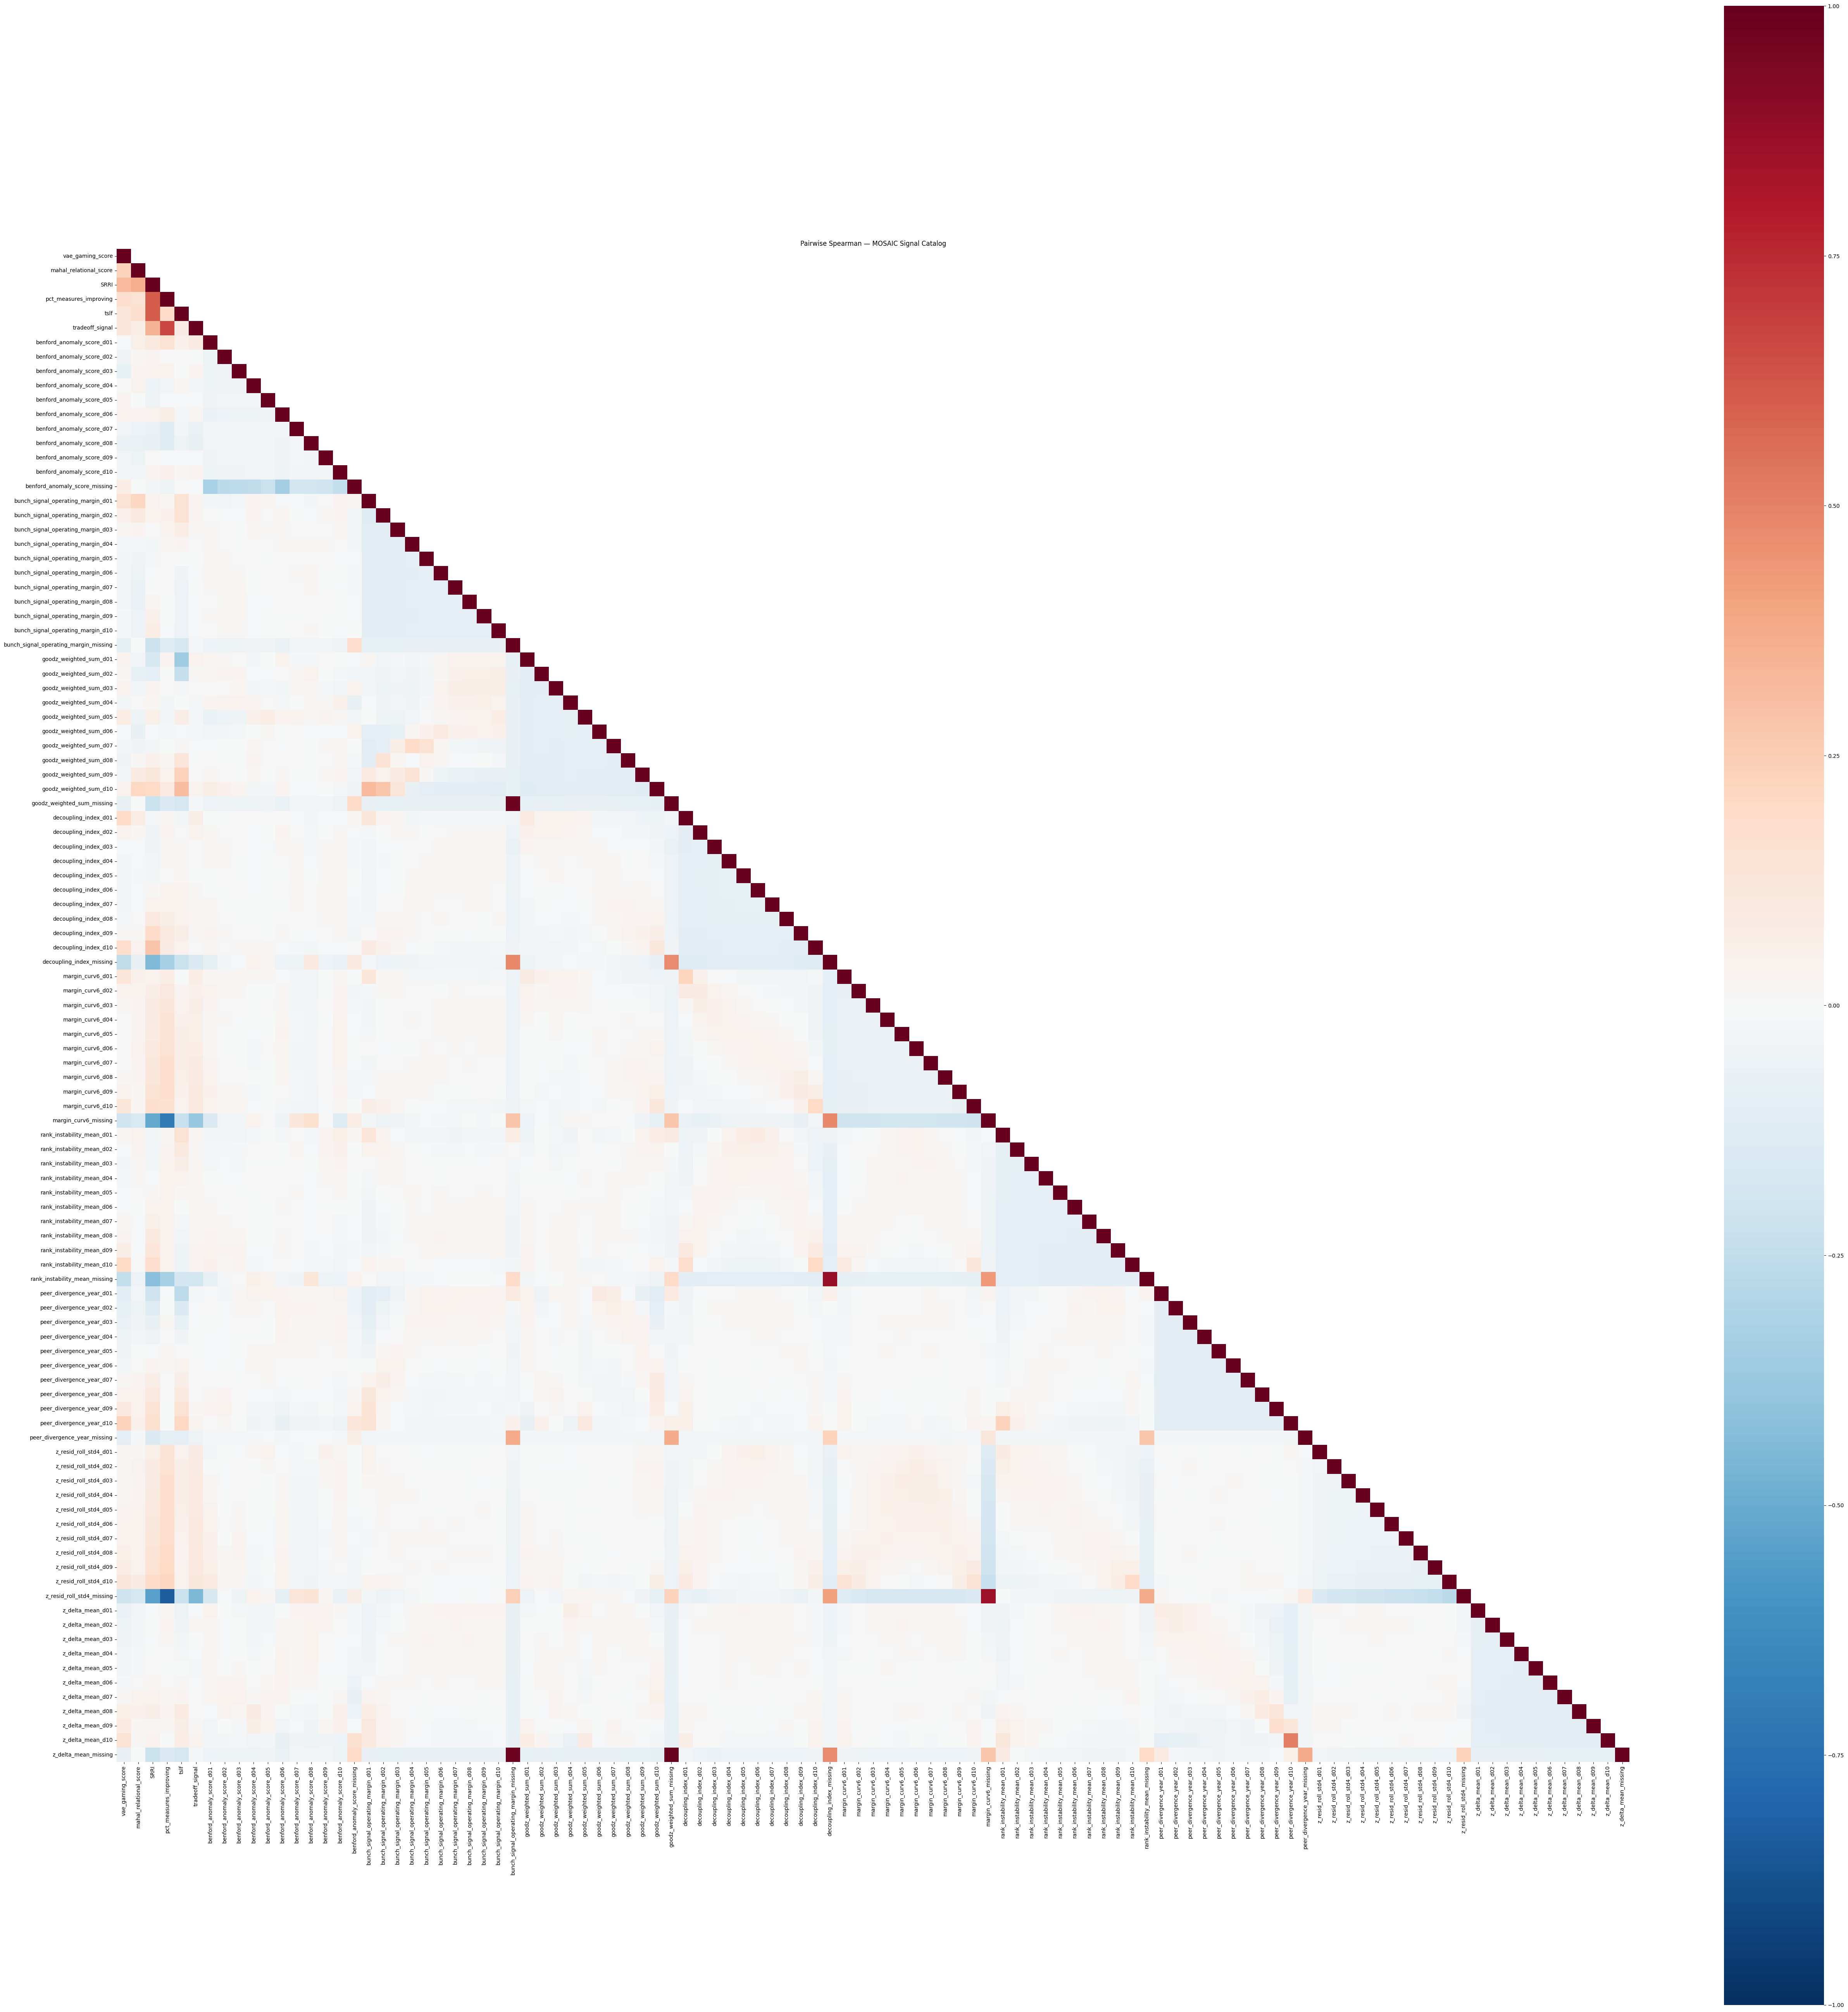

In [17]:
# ============================================================
# SIGNAL DIAGNOSTIC — Pairwise Spearman Correlations
# Flags pairs with |rho| > 0.70 (potential redundancy).
# Explains zero-weight outcomes (e.g. Mahalanobis vs VAE).
# ============================================================
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

sig_cols = [s for s in SIGNAL_CATALOG if s in df.columns
            and df[s].notna().sum() > 100]
print(f"Computing pairwise Spearman for {len(sig_cols)} signals...")

n = len(sig_cols)
rho_mat = np.full((n, n), np.nan)
for i, s1 in enumerate(sig_cols):
    for j, s2 in enumerate(sig_cols):
        if i == j: rho_mat[i,j] = 1.0; continue
        if i >  j: rho_mat[i,j] = rho_mat[j,i]; continue
        mask = df[s1].notna() & df[s2].notna()
        if mask.sum() > 50:
            rho_mat[i,j], _ = spearmanr(df.loc[mask, s1], df.loc[mask, s2])

rho_df = pd.DataFrame(rho_mat, index=sig_cols, columns=sig_cols)

high = [(sig_cols[i], sig_cols[j], round(rho_mat[i,j],3))
        for i in range(n) for j in range(i+1,n)
        if not np.isnan(rho_mat[i,j]) and abs(rho_mat[i,j]) > 0.70]

print(f"\nPairs |rho|>0.70  ({len(high)} found):")
for a,b,r in sorted(high, key=lambda x:-abs(x[2])):
    print(f"  {a:<42s} x {b:<42s}  rho={r:+.3f}")

fig, ax = plt.subplots(figsize=(max(10, n//2), max(8, n//2)))
mask_upper = np.triu(np.ones_like(rho_mat, dtype=bool), k=1)
sns.heatmap(rho_df, mask=mask_upper, cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, annot=(n<=20), fmt=".2f",
            annot_kws={"size":6}, ax=ax, square=True)
ax.set_title("Pairwise Spearman — MOSAIC Signal Catalog")
plt.tight_layout(); plt.show()

# 16. MOSAIC (GPU-Accelerated)
Replaces fixed-weight benchmark `[0.4, 0.4, 0.2]`.  
Weights optimized per peer cohort × time regime.  
**GPU:** PyTorch LBFGS (strong_wolfe) + Adam fallback.  
**Spearman:** differentiable soft-rank (temperature=0.01).  
**Shrinkage:** CAH cells borrow from global (α=n/(n+50)).  
**UQ:** 50-perturbation bootstrap uncertainty bands.  
**Threshold:** Bastian et al. (2017) auto-τ* at FPR≤0.05.

In [21]:
# %%
# =============================================================================
# MOSAIC — PRIMARY MODEL, COMMON-PANEL LOCKED, CACHED/VECTORIZED GPU VERSION
# =============================================================================
# Authoritative primary MOSAIC cell.
#
# Key decisions:
#   * Lock analysis rows to X_if.index (the common 83,512-row comparator panel).
#   * Never overwrite the incoming master df.
#   * Preserve the original 10 independent L-BFGS restarts and fallback Adam.
#   * Cache objective terms that do not depend on weights.
#   * Vectorize normalization, row scoring, threshold evaluation, and categories.
#   * Save the fitted dataframe and model metadata immediately.
# =============================================================================

from __future__ import annotations

import hashlib
import json
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
from scipy import stats
from scipy.stats import spearmanr
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")

# =============================================================================
# 0. CONFIGURATION
# =============================================================================

TRANSFORMER_CANDIDATES = [
    "transformer_pct",
    "transformer_mae_pct",
    "transformer_score_pct",
    "transformer_anomaly_pct",
]
TRANSFORMER_HIGHER_WORSE = False
REGIME_ORDER = ["baseline", "transition", "covid_shock", "recovery"]
MIN_CELL_N = 150
SHRINKAGE_BASE = 50.0

# Original optimizer settings retained.
N_RESTARTS = 10
SUBSAMPLE_N = 3_000
MOSAIC_LBFGS_LR = 0.5
MOSAIC_LBFGS_MAX_ITER = 150
MOSAIC_ADAM_FALLBACK_STEPS = 500
MOSAIC_ADAM_FALLBACK_LR = 0.05

MOSAIC_RANK_TEMPERATURE = 0.01
MOSAIC_MONO_COEF = 5.0
MOSAIC_KENDALL_COEF = 0.25
MOSAIC_RANK_COL_CHUNK = 4
ALPHA_FPR = 0.05

_DEFAULT_ROOT = Path(globals().get("BASE_PATH", Path.cwd()))
MOSAIC_OUTPUT_DIR = Path(
    globals().get("MOSAIC_OUTPUT_DIR", _DEFAULT_ROOT / "mosaic_primary_results")
)
MOSAIC_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =============================================================================
# 1. GUARDS AND COMMON-PANEL LOCK
# =============================================================================

_REQUIRED_COLUMNS = [
    "_distress_anchor",
    "data_regime",
    "if_pct_decile",
    "vae_pct",
    "srri_pct",
    "peer_group",
    "source_year",
]
_missing = [c for c in _REQUIRED_COLUMNS if c not in df.columns]
if _missing:
    raise RuntimeError(f"Primary MOSAIC prerequisites missing: {_missing}")

TRANSFORMER_COL = next((c for c in TRANSFORMER_CANDIDATES if c in df.columns), None)
if TRANSFORMER_COL is None:
    raise RuntimeError(f"Transformer score missing; expected one of {TRANSFORMER_CANDIDATES}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=" * 88)
print("MOSAIC PRIMARY MODEL")
print("=" * 88)
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(DEVICE))
print("Transformer column:", TRANSFORMER_COL)

# Preserve the master dataframe object. This cell never assigns back to df.
MOSAIC_MASTER_DF = df

# =============================================================================
# RECOVER ORIGINAL REPORT-LEVEL MOSAIC PANEL
# =============================================================================

if "RPT_REC_NUM" not in MOSAIC_MASTER_DF.columns:
    raise RuntimeError(
        "RPT_REC_NUM is required to recover the original MOSAIC panel."
    )

_report_id = (
    MOSAIC_MASTER_DF["RPT_REC_NUM"]
    .astype("string")
    .str.strip()
)

if _report_id.isna().any():
    raise RuntimeError(
        f"RPT_REC_NUM contains {_report_id.isna().sum():,} missing values."
    )

n_unique_reports = int(_report_id.nunique())

print(f"Master df rows:          {len(MOSAIC_MASTER_DF):,}")
print(f"Unique RPT_REC_NUM:      {n_unique_reports:,}")

if n_unique_reports != 83_512:
    raise RuntimeError(
        "Distinct RPT_REC_NUM count does not recover the expected "
        f"83,512-row panel. Found {n_unique_reports:,}."
    )

# -------------------------------------------------------------------------
# Verify duplicate copies of a report agree on all MOSAIC inputs.
# -------------------------------------------------------------------------

if "SIGNAL_CATALOG" not in globals():
    raise RuntimeError(
        "SIGNAL_CATALOG is missing. Run the forensic decile-encoding cell first."
    )

_check_cols = [
    "_distress_anchor",
    "peer_group",
    "source_year",
    "data_regime",
    "if_pct_decile",
    "vae_pct",
    TRANSFORMER_COL,
]

_check_cols += [
    sig
    for sig in SIGNAL_CATALOG
    if sig in MOSAIC_MASTER_DF.columns
]

_check_cols = list(
    dict.fromkeys(
        c
        for c in _check_cols
        if c in MOSAIC_MASTER_DF.columns
    )
)

_dup_mask = _report_id.duplicated(keep=False)

if _dup_mask.any():

    _dup = MOSAIC_MASTER_DF.loc[
        _dup_mask,
        _check_cols,
    ].copy()

    _dup["_report_id"] = _report_id.loc[_dup_mask]

    _conflicts = {}

    for col in _check_cols:
        nvals = (
            _dup
            .groupby("_report_id", observed=True)[col]
            .nunique(dropna=False)
        )

        n_conflict = int((nvals > 1).sum())

        if n_conflict:
            _conflicts[col] = n_conflict

    if _conflicts:
        raise RuntimeError(
            "Duplicate copies of RPT_REC_NUM disagree on MOSAIC inputs: "
            f"{_conflicts}"
        )

print("Duplicate report-input consistency check: PASSED")

# -------------------------------------------------------------------------
# One row per HCRIS report record.
# Preserve existing order, then reset to the same positional indexing used
# by the model matrices.
# -------------------------------------------------------------------------

MOSAIC_INPUT_DF = (
    MOSAIC_MASTER_DF
    .assign(_mosaic_report_id=_report_id)
    .drop_duplicates(
        subset="_mosaic_report_id",
        keep="first",
    )
    .drop(columns="_mosaic_report_id")
    .reset_index(drop=True)
)

if len(MOSAIC_INPUT_DF) != 83_512:
    raise RuntimeError(
        f"Recovered MOSAIC panel has {len(MOSAIC_INPUT_DF):,} rows, "
        "expected 83,512."
    )

# -------------------------------------------------------------------------
# Historical panel fingerprint via regime composition.
# -------------------------------------------------------------------------

_expected_regimes = {
    "baseline": 43_529,
    "transition": 6_152,
    "covid_shock": 18_241,
    "recovery": 15_590,
}

_actual_regimes = (
    MOSAIC_INPUT_DF["data_regime"]
    .value_counts()
    .to_dict()
)

for regime, expected in _expected_regimes.items():

    actual = int(_actual_regimes.get(regime, 0))

    print(
        f"{regime:<14}: {actual:>7,} "
        f"(expected {expected:>7,})"
    )

    if actual != expected:
        raise RuntimeError(
            f"{regime} count mismatch: "
            f"{actual:,} != {expected:,}"
        )

# -------------------------------------------------------------------------
# X_if should now have the same row count and positional index.
# -------------------------------------------------------------------------

if "X_if" in globals():

    if len(X_if) != len(MOSAIC_INPUT_DF):
        raise RuntimeError(
            f"X_if has {len(X_if):,} rows; "
            f"MOSAIC panel has {len(MOSAIC_INPUT_DF):,}."
        )

    if isinstance(X_if, pd.DataFrame):
        if not X_if.index.equals(MOSAIC_INPUT_DF.index):
            raise RuntimeError(
                "X_if and recovered MOSAIC panel do not share "
                "the same positional index."
            )

print(f"Recovered MOSAIC rows:   {len(MOSAIC_INPUT_DF):,}")

for _col in ["if_pct_decile", "vae_pct", TRANSFORMER_COL]:
    n_missing = int(MOSAIC_INPUT_DF[_col].isna().sum())
    if n_missing:
        raise RuntimeError(
            f"{_col} has {n_missing:,} missing values on the locked panel. "
            "Primary MOSAIC will not silently impute detector outputs."
        )

print(f"Master df rows:      {len(MOSAIC_MASTER_DF):,}")
print(f"Locked MOSAIC rows:  {len(MOSAIC_INPUT_DF):,}")
print(f"X_if rows:           {len(X_if):,}")

# =============================================================================
# 2. SIGNAL CATALOG
# =============================================================================

def build_mosaic_signal_catalog(
    base_catalog: Dict,
    transformer_col: str,
    transformer_higher_worse: bool = False,
) -> Dict:
    catalog = {k: dict(v) for k, v in base_catalog.items()}
    catalog["if_pct_decile"] = {
        "dim": "model_based",
        "higher_worse": True,
        "label": "Isolation Forest percentile score",
    }
    catalog["vae_pct"] = {
        "dim": "model_based",
        "higher_worse": True,
        "label": "Variational Autoencoder percentile score",
    }
    catalog[transformer_col] = {
        "dim": "model_based",
        "higher_worse": transformer_higher_worse,
        "label": "Transformer anomaly score percentile",
    }
    return catalog


MOSAIC_SIGNAL_CATALOG = build_mosaic_signal_catalog(
    SIGNAL_CATALOG,
    transformer_col=TRANSFORMER_COL,
    transformer_higher_worse=TRANSFORMER_HIGHER_WORSE,
)

# =============================================================================
# 3. VECTORIZED SIGNAL NORMALIZATION
# =============================================================================

def normalize_signals(
    df_in: pd.DataFrame,
    signals: List[str],
    signal_catalog: Dict,
    cohort_col: str = "peer_group",
    regime_col: str = "data_regime",
    min_n: int = 30,
) -> pd.DataFrame:
    """Vectorized equivalent of the original three-stage fallback ranking."""
    out = df_in.copy()
    usable = [s for s in signals if s in out.columns]
    if not usable:
        return out

    raw = out[usable].apply(pd.to_numeric, errors="coerce").astype(float)
    cell_keys = [out[cohort_col], out[regime_col]]

    cell_counts = raw.groupby(cell_keys, observed=True, dropna=True).transform("count")
    cell_ranks = raw.groupby(cell_keys, observed=True, dropna=True).rank(
        pct=True, method="average"
    )
    norm = cell_ranks.where(cell_counts >= min_n)

    cohort_ranks = raw.groupby(out[cohort_col], observed=True, dropna=True).rank(
        pct=True, method="average"
    )
    norm = norm.where(norm.notna(), cohort_ranks)

    global_ranks = raw.rank(pct=True, method="average")
    norm = norm.where(norm.notna(), global_ranks)

    reverse = [
        s for s in usable
        if not signal_catalog.get(s, {}).get("higher_worse", True)
    ]
    if reverse:
        norm.loc[:, reverse] = 1.0 - norm[reverse]

    norm = norm.clip(0.0, 1.0)
    norm.columns = [f"s_{s}" for s in usable]
    out.loc[:, norm.columns] = norm
    return out

# =============================================================================
# 4. CPU REFERENCE OBJECTIVE
# =============================================================================

def mosaic_objective(
    weights: np.ndarray,
    S: np.ndarray,
    distress: np.ndarray,
    global_weights: Optional[np.ndarray] = None,
    smoothness_ref: Optional[np.ndarray] = None,
    lambda_smooth: float = 0.10,
    lambda_pool: float = 0.15,
) -> float:
    """Original objective retained as a CPU reference."""
    w = np.abs(np.asarray(weights, dtype=float))
    w /= w.sum() + 1e-12
    mask = np.isfinite(S).all(axis=1) & np.isfinite(distress)
    if mask.sum() < 20:
        return 1.0

    Sm = S[mask]
    d = distress[mask]
    F = Sm @ w
    rho = stats.spearmanr(F, d).statistic
    if np.isnan(rho):
        rho = 0.0

    high_d = d >= 0.6
    low_d = d <= 0.3
    mono_penalty = 0.0
    if high_d.sum() >= 5 and low_d.sum() >= 5:
        sep = F[high_d].mean() - F[low_d].mean()
        mono_penalty = MOSAIC_MONO_COEF * max(0.0, -sep)

    n, k = Sm.shape
    concordance_internal = 0.0
    if k >= 3:
        ranks = np.apply_along_axis(stats.rankdata, 0, Sm)
        Ri = ranks.sum(axis=1)
        Sw = np.sum((Ri - Ri.mean()) ** 2)
        W = 12.0 * Sw / (k**2 * (n**3 - n))
        concordance_internal = -MOSAIC_KENDALL_COEF * np.clip(W, 0.0, 1.0)

    smooth_pen = (
        lambda_smooth * np.sum((w - smoothness_ref) ** 2)
        if smoothness_ref is not None else 0.0
    )
    pool_pen = (
        lambda_pool * np.sum((w - global_weights) ** 2)
        if global_weights is not None else 0.0
    )
    return float(-rho + concordance_internal + mono_penalty + smooth_pen + pool_pen)

# =============================================================================
# 5. CACHED GPU OBJECTIVE
# =============================================================================

def _soft_rank(x: torch.Tensor, temperature: float = MOSAIC_RANK_TEMPERATURE) -> torch.Tensor:
    diff = x.unsqueeze(1) - x.unsqueeze(0)
    return torch.sigmoid(diff / temperature).sum(dim=1)


def _soft_rank_matrix_chunk(
    X: torch.Tensor,
    temperature: float = MOSAIC_RANK_TEMPERATURE,
) -> torch.Tensor:
    diff = X.unsqueeze(1) - X.unsqueeze(0)
    return torch.sigmoid(diff / temperature).sum(dim=1)


def _kendall_constant_gpu(S: torch.Tensor) -> torch.Tensor:
    """Compute the original weight-invariant Kendall term once per fit."""
    n, k = S.shape
    if k < 3:
        return torch.zeros((), dtype=S.dtype, device=S.device)

    Ri = torch.zeros(n, dtype=S.dtype, device=S.device)
    for start in range(0, k, MOSAIC_RANK_COL_CHUNK):
        stop = min(start + MOSAIC_RANK_COL_CHUNK, k)
        ranks = _soft_rank_matrix_chunk(S[:, start:stop])
        Ri = Ri + ranks.sum(dim=1)

    Sw = ((Ri - Ri.mean()) ** 2).sum()
    denom = k**2 * (n**3 - n) + 1e-12
    W = 12.0 * Sw / denom
    return (-MOSAIC_KENDALL_COEF * W.clamp(0.0, 1.0)).detach()


def _prepare_gpu_objective_cache(S: torch.Tensor, d: torch.Tensor) -> Dict[str, object]:
    with torch.no_grad():
        d_rank = _soft_rank(d).detach()
        kendall_const = _kendall_constant_gpu(S).detach()
    hi = d >= 0.6
    lo = d <= 0.3
    return {
        "d_rank": d_rank,
        "kendall_const": kendall_const,
        "hi": hi,
        "lo": lo,
        "use_mono": int(hi.sum().item()) >= 5 and int(lo.sum().item()) >= 5,
    }


def _mosaic_obj_gpu_cached(
    w_raw: torch.Tensor,
    S: torch.Tensor,
    cache: Dict[str, object],
    w_glob: Optional[torch.Tensor] = None,
    w_prev: Optional[torch.Tensor] = None,
    lam_s: float = 0.10,
    lam_p: float = 0.15,
) -> torch.Tensor:
    w = torch.softmax(w_raw, dim=0)
    F = S @ w
    rho = torch.corrcoef(torch.stack([_soft_rank(F), cache["d_rank"]]))[0, 1]
    loss = -rho + cache["kendall_const"]

    if cache["use_mono"]:
        hi, lo = cache["hi"], cache["lo"]
        loss = loss + MOSAIC_MONO_COEF * torch.relu(-(F[hi].mean() - F[lo].mean()))
    if w_prev is not None:
        loss = loss + lam_s * ((w - w_prev) ** 2).sum()
    if w_glob is not None:
        loss = loss + lam_p * ((w - w_glob) ** 2).sum()
    return loss


def _mosaic_obj_gpu(
    w_raw: torch.Tensor,
    S: torch.Tensor,
    d: torch.Tensor,
    w_glob: Optional[torch.Tensor] = None,
    w_prev: Optional[torch.Tensor] = None,
    lam_s: float = 0.10,
    lam_p: float = 0.15,
) -> torch.Tensor:
    """Compatibility wrapper for downstream sensitivity code."""
    cache = _prepare_gpu_objective_cache(S, d)
    return _mosaic_obj_gpu_cached(w_raw, S, cache, w_glob, w_prev, lam_s, lam_p)

# =============================================================================
# 6. OPTIMIZER — ORIGINAL 10 RESTARTS PRESERVED
# =============================================================================

def optimize_cell_weights(
    S_np: np.ndarray,
    d_np: np.ndarray,
    n_signals: int,
    global_weights: Optional[np.ndarray] = None,
    smoothness_ref: Optional[np.ndarray] = None,
    n_restarts: int = N_RESTARTS,
    lambda_smooth: float = 0.10,
    lambda_pool: float = 0.15,
    n_observations: int = 0,
) -> Tuple[np.ndarray, float]:
    """
    Same optimizer path as the original code. Only weight-invariant objective
    terms are cached so they are not recomputed inside every closure.
    """
    n_restarts = max(1, int(n_restarts))

    if len(S_np) > SUBSAMPLE_N:
        idx = np.random.default_rng(42).choice(len(S_np), SUBSAMPLE_N, replace=False)
        S_o, d_o = S_np[idx], d_np[idx]
    else:
        S_o, d_o = S_np, d_np

    S_o = np.asarray(S_o, dtype=np.float32)
    d_o = np.asarray(d_o, dtype=np.float32)
    finite = np.isfinite(S_o).all(axis=1) & np.isfinite(d_o)
    S_o, d_o = S_o[finite], d_o[finite]

    if len(S_o) < 20:
        fallback = (
            np.asarray(global_weights, dtype=float).copy()
            if global_weights is not None
            else np.ones(n_signals, dtype=float) / float(n_signals)
        )
        fallback /= fallback.sum()
        return fallback, 1.0

    S_t = torch.as_tensor(S_o, dtype=torch.float32, device=DEVICE)
    d_t = torch.as_tensor(d_o, dtype=torch.float32, device=DEVICE)
    wg = (
        torch.as_tensor(np.asarray(global_weights, dtype=np.float32), device=DEVICE)
        if global_weights is not None else None
    )
    wp = (
        torch.as_tensor(np.asarray(smoothness_ref, dtype=np.float32), device=DEVICE)
        if smoothness_ref is not None else None
    )

    shrink = (
        float(np.clip(n_observations / (n_observations + SHRINKAGE_BASE), 0.1, 1.0))
        if global_weights is not None and n_observations > 0 else 1.0
    )

    cache = _prepare_gpu_objective_cache(S_t, d_t)
    best_w, best_obj = None, np.inf
    rng = np.random.default_rng(42)

    for restart in range(n_restarts):
        if restart == 0 and global_weights is not None:
            w0 = np.log(np.asarray(global_weights, dtype=np.float32) + 1e-6)
        else:
            w0 = np.log(rng.dirichlet(np.ones(n_signals)) + 1e-6).astype(np.float32)

        w_raw = torch.tensor(w0, dtype=torch.float32, device=DEVICE, requires_grad=True)
        opt = torch.optim.LBFGS(
            [w_raw],
            lr=MOSAIC_LBFGS_LR,
            max_iter=MOSAIC_LBFGS_MAX_ITER,
            line_search_fn="strong_wolfe",
        )

        def closure():
            opt.zero_grad(set_to_none=True)
            loss = _mosaic_obj_gpu_cached(
                w_raw, S_t, cache, wg, wp, lambda_smooth, lambda_pool
            )
            loss.backward()
            return loss

        try:
            opt.step(closure)
            with torch.no_grad():
                obj = float(
                    _mosaic_obj_gpu_cached(
                        w_raw, S_t, cache, wg, wp, lambda_smooth, lambda_pool
                    ).item()
                )
        except Exception:
            obj = np.inf

        if np.isnan(obj) or np.isinf(obj):
            wr2 = torch.tensor(w0, dtype=torch.float32, device=DEVICE, requires_grad=True)
            o2 = torch.optim.Adam([wr2], lr=MOSAIC_ADAM_FALLBACK_LR)
            loss = None
            for _ in range(MOSAIC_ADAM_FALLBACK_STEPS):
                o2.zero_grad(set_to_none=True)
                loss = _mosaic_obj_gpu_cached(
                    wr2, S_t, cache, wg, wp, lambda_smooth, lambda_pool
                )
                loss.backward()
                o2.step()
            obj = float(loss.item())
            w_raw = wr2

        if obj < best_obj:
            best_obj = obj
            best_w = torch.softmax(w_raw.detach(), dim=0).cpu().numpy()

    if best_w is None:
        best_w = np.ones(n_signals, dtype=float) / float(n_signals)

    if global_weights is not None and shrink < 1.0:
        best_w = shrink * best_w + (1.0 - shrink) * np.asarray(global_weights, dtype=float)
        best_w /= best_w.sum()

    return np.asarray(best_w, dtype=float), float(best_obj)

# =============================================================================
# 7. VECTORIZED BASTIAN THRESHOLD
# =============================================================================

def bastian_auto_threshold(
    F: pd.Series,
    distress: pd.Series,
    alpha: float = ALPHA_FPR,
    distress_cutoff: float = 0.6,
) -> Dict:
    F_vals = pd.to_numeric(F, errors="coerce")
    d_vals = pd.to_numeric(distress, errors="coerce")
    valid = F_vals.notna() & d_vals.notna()
    F_v = F_vals[valid].to_numpy(dtype=float)
    d_v = d_vals[valid].to_numpy(dtype=float)
    D1 = d_v >= distress_cutoff
    D0 = ~D1

    if D1.sum() < 10 or D0.sum() < 10:
        tau = float(np.quantile(F_v, 0.90))
        return {
            "tau_star": tau,
            "fpr": np.nan,
            "tpr": np.nan,
            "separation": np.nan,
            "pct_flagged": float((F_v >= tau).mean()),
            "tau_grid": pd.DataFrame(),
            "method": "fallback_percentile",
        }

    candidates = np.unique(np.percentile(F_v, np.linspace(50, 99, 100)))
    flagged = F_v[:, None] >= candidates[None, :]
    fpr = flagged[D0].mean(axis=0)
    tpr = flagged[D1].mean(axis=0)
    pct = flagged.mean(axis=0)
    separation = float(F_v[D1].mean() - F_v[D0].mean())
    obj = tpr - 5.0 * np.maximum(0.0, fpr - alpha)

    grid = pd.DataFrame({
        "tau": candidates,
        "fpr": fpr,
        "tpr": tpr,
        "separation": separation,
        "obj": obj,
        "pct_flagged": pct,
    })
    feasible = grid[grid["fpr"] <= alpha]
    best = feasible.loc[feasible["obj"].idxmax()] if not feasible.empty else grid.loc[grid["obj"].idxmax()]
    return {
        "tau_star": float(best["tau"]),
        "fpr": float(best["fpr"]),
        "tpr": float(best["tpr"]),
        "separation": float(best["separation"]),
        "pct_flagged": float(best["pct_flagged"]),
        "tau_grid": grid,
        "method": "bastian_auto",
    }

# =============================================================================
# 8. MAIN MOSAIC PIPELINE
# =============================================================================

def run_mosaic(
    df_in: pd.DataFrame,
    cohort_col: str = "peer_group",
    year_col: str = "source_year",
    verbose: bool = True,
    n_restarts: int = N_RESTARTS,
    lambda_smooth: float = 0.10,
    lambda_pool: float = 0.15,
    alpha_fpr: float = ALPHA_FPR,
):
    work = df_in.copy()
    work["time_regime"] = work["data_regime"]

    available_signals = [
        s for s in MOSAIC_SIGNAL_CATALOG
        if s in work.columns and work[s].notna().sum() > 50
    ]
    n_sig = len(available_signals)
    if n_sig == 0:
        raise RuntimeError("No usable MOSAIC signals found.")

    if verbose:
        print("\n" + "=" * 88)
        print("MOSAIC — Multi-Objective Signal Aggregation")
        print("=" * 88)
        print(f"Signals available: {n_sig}")
        for sig in available_signals:
            dim = MOSAIC_SIGNAL_CATALOG[sig].get("dim", "unknown")
            cov = work[sig].notna().mean()
            print(f"  {sig:<40} [{dim:<12}] {cov:.1%} coverage")

    work = normalize_signals(
        work,
        available_signals,
        MOSAIC_SIGNAL_CATALOG,
        cohort_col=cohort_col,
        regime_col="time_regime",
    )

    d_full = work["_distress_anchor"].fillna(0.5).to_numpy(dtype=float)
    if verbose:
        d = work["_distress_anchor"]
        print(
            f"\nDistress anchor: mean={d.mean():.3f}, "
            f"p25={d.quantile(.25):.3f}, p75={d.quantile(.75):.3f}"
        )
        print(
            f"Highly distressed (>=0.6): {(d >= 0.6).sum():,} "
            f"({(d >= 0.6).mean():.1%})"
        )

    scaled_cols = [f"s_{s}" for s in available_signals]
    imp = SimpleImputer(strategy="median")
    S_full = imp.fit_transform(work[scaled_cols].to_numpy(dtype=float)).astype(np.float32, copy=False)

    baseline_mask = work["time_regime"].eq("baseline").to_numpy()
    if verbose:
        print(
            f"\nFitting global weights on baseline "
            f"(n={baseline_mask.sum():,}, {n_restarts} full L-BFGS restarts)..."
        )

    w_global, obj_global = optimize_cell_weights(
        S_full[baseline_mask],
        d_full[baseline_mask],
        n_sig,
        global_weights=None,
        smoothness_ref=None,
        n_restarts=n_restarts,
        lambda_smooth=0.0,
        lambda_pool=0.0,
        n_observations=int(baseline_mask.sum()),
    )

    if verbose:
        print(f"Global weights (obj={obj_global:.4f}):")
        for sig, w in zip(available_signals, w_global):
            dim = MOSAIC_SIGNAL_CATALOG[sig].get("dim", "unknown")
            print(f"  {sig:<40} w={w:.4f} [{dim}]")

    cohorts = sorted(work[cohort_col].dropna().unique())
    regime_set = set(work["time_regime"].dropna().unique())
    regimes = [r for r in REGIME_ORDER if r in regime_set]

    cohort_w = {}
    cohort_obj = {}
    for cohort in cohorts:
        mask = work[cohort_col].eq(cohort) & work["time_regime"].eq("baseline")
        n_cell = int(mask.sum())
        if n_cell < MIN_CELL_N:
            cohort_w[cohort] = w_global.copy()
            cohort_obj[cohort] = np.nan
            if verbose:
                print(f"[{str(cohort):>30} x baseline] n={n_cell:4d} -> global fallback")
            continue

        pos = mask.to_numpy()
        w_cell, obj_cell = optimize_cell_weights(
            S_full[pos],
            d_full[pos],
            n_sig,
            global_weights=w_global,
            smoothness_ref=None,
            n_restarts=n_restarts,
            lambda_smooth=0.0,
            lambda_pool=lambda_pool,
            n_observations=n_cell,
        )
        cohort_w[cohort] = w_cell
        cohort_obj[cohort] = obj_cell
        if verbose:
            shrink = n_cell / (n_cell + SHRINKAGE_BASE)
            print(
                f"[{str(cohort):>30} x baseline] n={n_cell:4d} "
                f"obj={obj_cell:.4f} shrink={shrink:.2f}"
            )

    weight_matrix = {
        (cohort, regime): cohort_w[cohort].copy()
        for cohort in cohorts for regime in regimes
    }
    if verbose:
        print("\nBaseline weights frozen and applied to all regimes.")

    # Vectorized score and weight assignment.
    n_rows = len(work)
    W_rows = np.full((n_rows, n_sig), np.nan, dtype=np.float32)
    valid_rows = work[cohort_col].notna() & work["time_regime"].isin(regimes)
    valid_pos = np.flatnonzero(valid_rows.to_numpy())
    valid_cohorts = work.loc[valid_rows, cohort_col].to_numpy()
    W_rows[valid_pos] = np.vstack([cohort_w.get(c, w_global) for c in valid_cohorts]).astype(np.float32)

    score = np.full(n_rows, np.nan, dtype=float)
    score[valid_pos] = np.einsum(
        "ij,ij->i", S_full[valid_pos], W_rows[valid_pos], optimize=True
    )
    work["mosaic_score"] = score
    work.loc[:, [f"weight_{s}" for s in available_signals]] = W_rows

    # Preserve original cell-specific RNG rule, but multiply 50 bootstrap weights at once.
    uncertainty = np.full(n_rows, np.nan, dtype=float)
    for cohort in cohorts:
        for regime in regimes:
            mask = work[cohort_col].eq(cohort) & work["time_regime"].eq(regime)
            pos = np.flatnonzero(mask.to_numpy())
            if len(pos) == 0:
                continue
            w = cohort_w.get(cohort, w_global)
            rng = np.random.default_rng(seed=int(abs(hash((cohort, regime))) % 10000))
            W_boot = np.empty((50, n_sig), dtype=float)
            for b in range(50):
                noise = rng.dirichlet(np.ones(n_sig) * 10) - (1.0 / n_sig)
                wb = np.abs(w + 0.05 * noise)
                W_boot[b] = wb / wb.sum()
            boot_scores = S_full[pos] @ W_boot.T
            uncertainty[pos] = np.std(boot_scores, axis=1)
    work["mosaic_uncertainty"] = uncertainty

    # -------------------------------------------------------------------------
    # Calibrate the classification threshold on Baseline observations only.
    # Freeze the resulting threshold and apply it to the full panel.
    # -------------------------------------------------------------------------

    baseline_mask_threshold = work["time_regime"].eq("baseline")

    threshold_fit = (
        work.loc[
            baseline_mask_threshold,
            [
                "mosaic_score",
                "_distress_anchor",
            ],
        ]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    if len(threshold_fit) < 3:
        raise RuntimeError(
            "Insufficient complete Baseline observations for "
            "MOSAIC threshold calibration."
        )

    threshold_result = bastian_auto_threshold(
        F=threshold_fit["mosaic_score"],
        distress=threshold_fit["_distress_anchor"],
        alpha=alpha_fpr,
    )

    threshold_result["calibration_regime"] = "baseline"
    threshold_result["n_calibration"] = int(len(threshold_fit))
    threshold_result["baseline_only"] = True

    tau_star = float(threshold_result["tau_star"])

    work["mosaic_flag"] = (
        work["mosaic_score"].ge(tau_star)
        & work["mosaic_score"].notna()
    ).astype(int)

    # Calibrate the lower legacy elevated-risk boundary on Baseline only.
    baseline_scores = (
        pd.to_numeric(
            work.loc[
                baseline_mask_threshold,
                "mosaic_score",
            ],
            errors="coerce",
        )
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .to_numpy(dtype=float)
    )

    elevated_probability = float(
        np.clip(
            threshold_result["pct_flagged"] - 0.05,
            0.0,
            1.0,
        )
    )

    tau_low = float(
        np.quantile(
            baseline_scores,
            elevated_probability,
        )
    )

    threshold_result["tau_low"] = tau_low
    threshold_result["tau_low_probability"] = elevated_probability

    s = work["mosaic_score"]
    u = work["mosaic_uncertainty"]

    work["mosaic_category"] = np.select(
        [
            s.isna(),
            (s >= tau_star) & (u <= 0.05),
            (s >= tau_star) & (u > 0.05),
            s >= tau_low,
        ],
        [
            "Insufficient Data",
            "HIGH RISK — Confirmed",
            "HIGH RISK — Uncertain",
            "ELEVATED RISK",
        ],
        default="Normal",
    )

    # -------------------------------------------------------------------------
    # Internal diagnostics
    # -------------------------------------------------------------------------

    anchor = work["_distress_anchor"]
    q75 = anchor.quantile(0.75)
    q25 = anchor.quantile(0.25)

    work["mosaic_pct"] = (
        work["mosaic_score"]
        .rank(
            pct=True,
            method="average",
        )
    )

    work["mosaic_pct_peeryear"] = (
        work
        .groupby(
            [
                "peer_group",
                "source_year",
            ],
            observed=True,
        )["mosaic_score"]
        .rank(
            pct=True,
            method="average",
        )
    )

    vg = (
        work[
            [
                "mosaic_score",
                "_distress_anchor",
            ]
        ]
        .dropna()
    )

    vp = (
        work[
            [
                "mosaic_pct_peeryear",
                "_distress_anchor",
            ]
        ]
        .dropna()
    )

    rho_g, p_g = spearmanr(
        vg["mosaic_score"],
        vg["_distress_anchor"],
    )

    rho_py, p_py = spearmanr(
        vp["mosaic_pct_peeryear"],
        vp["_distress_anchor"],
    )

    separation = float(
        work.loc[
            anchor >= q75,
            "mosaic_pct",
        ].mean()
        -
        work.loc[
            anchor <= q25,
            "mosaic_pct",
        ].mean()
    )

    # -------------------------------------------------------------------------
    # Regime diagnostics
    # -------------------------------------------------------------------------

    regime_results = {}

    for regime in sorted(
        work["time_regime"]
        .dropna()
        .unique()
    ):
        sub = (
            work.loc[
                work["time_regime"].eq(regime),
                [
                    "mosaic_score",
                    "_distress_anchor",
                ],
            ]
            .dropna()
        )

        if len(sub) < 50:
            regime_results[regime] = (
                np.nan,
                np.nan,
                len(sub),
            )
            continue

        rr, pp = spearmanr(
            sub["mosaic_score"],
            sub["_distress_anchor"],
        )

        regime_results[regime] = (
            float(rr),
            float(pp),
            len(sub),
        )

    if verbose:
        print(
            f"\nThreshold: tau*={tau_star:.4f}, "
            f"FPR={threshold_result['fpr']:.3f}, "
            f"TPR={threshold_result['tpr']:.3f}, "
            f"flagged={threshold_result['pct_flagged']:.1%}"
        )

        print(
            "Threshold calibration: "
            f"Baseline only, n={len(threshold_fit):,}"
        )

        print(
            f"MOSAIC Spearman (global): "
            f"rho={rho_g:+.4f}, "
            f"p={p_g:.2e}, "
            f"N={len(vg):,}"
        )

        print(
            f"MOSAIC Spearman (peer-year rank): "
            f"rho={rho_py:+.4f}, "
            f"p={p_py:.2e}, "
            f"N={len(vp):,}"
        )

        print(
            f"MOSAIC separation (Q75-Q25): "
            f"{separation:+.4f}"
        )

        print(
            "\n"
            + "=" * 88
        )
        print(
            "MOSAIC — Spearman vs Distress Anchor by Regime"
        )
        print(
            "=" * 88
        )

        for regime, values in regime_results.items():
            rr, pp, nn = values

            if np.isnan(rr):
                print(
                    f"{regime:<14} "
                    f"rho=NA p=NA n={nn:,}"
                )
            else:
                print(
                    f"{regime:<14} "
                    f"rho={rr:+.4f} "
                    f"p={pp:.2e} "
                    f"n={nn:,}"
                )

        print("\nLegacy Threshold-Status Distribution:")
        print(
            work["mosaic_category"]
            .value_counts()
            .to_string()
        )

        print("\nMOSAIC Score Distribution:")
        print(
            work["mosaic_score"]
            .describe(
                percentiles=[
                    0.50,
                    0.90,
                    0.95,
                    0.99,
                ]
            )
            .round(4)
            .to_string()
        )

    diagnostics = {
        "available_signals": available_signals,
        "obj_global": float(obj_global),
        "cohort_baseline_obj": cohort_obj,
        "regime_results": regime_results,
        "rho_global": float(rho_g),
        "p_global": float(p_g),
        "rho_peer_year_rank": float(rho_py),
        "p_peer_year_rank": float(p_py),
        "separation": separation,
    }

    return (
        work,
        weight_matrix,
        threshold_result,
        w_global,
        diagnostics,
    )

# =============================================================================
# 9. LEGACY FIXED-WEIGHT SCORE + PRIMARY FIT
# =============================================================================

def mosaic_replace_cell34(df_in: pd.DataFrame, verbose: bool = True):
    required = ["vae_pct", "srri_pct", "if_pct_decile", TRANSFORMER_COL]
    missing = [c for c in required if c not in df_in.columns]
    if missing:
        raise RuntimeError(f"Missing required columns: {missing}")

    work = df_in.copy()
    work["if_pct"] = work["if_pct_decile"]
    work["risk_fused_legacy"] = (
        0.4 * work["vae_pct"].fillna(0)
        + 0.4 * work["srri_pct"].fillna(0)
        + 0.2 * work["if_pct"].fillna(0)
    )
    return run_mosaic(work, verbose=verbose)

# =============================================================================
# 10. WEIGHT REPORT
# =============================================================================

def weight_report(
    weight_matrix: Dict[Tuple, np.ndarray],
    available_signals: List[str],
    w_global: np.ndarray,
    signal_catalog: Dict,
    verbose: bool = True,
) -> pd.DataFrame:
    pos = {s: i for i, s in enumerate(available_signals)}
    rows = []
    for sig, wg in zip(available_signals, w_global):
        row = {
            "signal": sig,
            "dimension": signal_catalog.get(sig, {}).get("dim", "unknown"),
            "w_global": float(wg),
        }
        i = pos[sig]
        for (cohort, regime), w in weight_matrix.items():
            row[f"{cohort}__{regime}"] = float(w[i])
        rows.append(row)
    report = pd.DataFrame(rows).set_index("signal")
    if verbose:
        print("\nMOSAIC Weight Matrix:")
        print(report.round(4).to_string())
    return report

# =============================================================================
# 11. COMPARATOR REPORT
# =============================================================================

def print_model_comparator(
    df_out: pd.DataFrame,
    IF_BENCHMARK: Dict,
    VAE_BENCHMARK: Dict,
    transformer_col: str = TRANSFORMER_COL,
) -> Dict:
    anchor = df_out["_distress_anchor"]
    q75, q25 = anchor.quantile(0.75), anchor.quantile(0.25)

    valid = df_out[["mosaic_score", "_distress_anchor"]].dropna()
    rho_s, p_s = spearmanr(valid["mosaic_score"], valid["_distress_anchor"])
    valid_py = df_out[["mosaic_pct_peeryear", "_distress_anchor"]].dropna()
    rho_py, p_py = spearmanr(valid_py["mosaic_pct_peeryear"], valid_py["_distress_anchor"])
    sep = float(
        df_out.loc[anchor >= q75, "mosaic_pct"].mean()
        - df_out.loc[anchor <= q25, "mosaic_pct"].mean()
    )

    tr = df_out[[transformer_col, "_distress_anchor"]].dropna()
    rho_tr, _ = spearmanr(tr[transformer_col], tr["_distress_anchor"])
    df_out["transformer_pct_peeryear"] = df_out.groupby(
        ["peer_group", "source_year"], observed=True
    )[transformer_col].rank(pct=True, method="average")
    tr_py = df_out[["transformer_pct_peeryear", "_distress_anchor"]].dropna()
    rho_tr_py, _ = spearmanr(tr_py["transformer_pct_peeryear"], tr_py["_distress_anchor"])
    tr_sep = float(
        df_out.loc[anchor >= q75, transformer_col].mean()
        - df_out.loc[anchor <= q25, transformer_col].mean()
    )

    benchmark = {
        "rho_mosaic_standalone": float(rho_s),
        "p_mosaic_standalone": float(p_s),
        "rho_mosaic_peeryear": float(rho_py),
        "p_mosaic_peeryear": float(p_py),
        "separation_mosaic": sep,
        "n_scored": int(valid.shape[0]),
        "feature_space": "Forensic SIGNAL_CATALOG + IF + VAE + Transformer",
        "distress_anchor": "Cell 6b _distress_anchor",
    }

    print("\n" + "=" * 88)
    print("FOUR-WAY COMPARATOR — COMMON LOCKED PANEL")
    print("=" * 88)
    print(f"{'Model':<38}{'rho_global':>12}{'rho_peer_year':>16}{'separation':>14}{'N':>10}")
    print("-" * 90)
    print(
        f"{'IF (standalone)':<38}"
        f"{IF_BENCHMARK['rho_if_standalone']:>+12.4f}"
        f"{IF_BENCHMARK['rho_if_peeryear']:>+16.4f}"
        f"{IF_BENCHMARK['separation_if']:>+14.4f}"
        f"{IF_BENCHMARK['n_scored']:>10,}"
    )
    print(
        f"{'VAE (standalone)':<38}"
        f"{VAE_BENCHMARK['rho_vae_standalone']:>+12.4f}"
        f"{VAE_BENCHMARK['rho_vae_peeryear']:>+16.4f}"
        f"{VAE_BENCHMARK['separation_vae']:>+14.4f}"
        f"{VAE_BENCHMARK['n_scored']:>10,}"
    )
    print(f"{'Transformer (standalone)':<38}{rho_tr:>+12.4f}{rho_tr_py:>+16.4f}{tr_sep:>+14.4f}{len(tr):>10,}")
    print(f"{'MOSAIC (optimized fusion)':<38}{rho_s:>+12.4f}{rho_py:>+16.4f}{sep:>+14.4f}{len(valid):>10,}")
    print("\nNOTE: rho_peer_year is rank-within peer_group x source_year.")
    return benchmark

# =============================================================================
# 12. VECTORIZED LEGACY RISK CATEGORY
# =============================================================================

def add_legacy_risk_category(df_in: pd.DataFrame) -> pd.DataFrame:
    out = df_in.copy()
    mc = out["mosaic_category"]
    sc = out["anomaly_quadrant"] if "anomaly_quadrant" in out.columns else pd.Series("LOW", index=out.index)
    confirmed = mc.eq("HIGH RISK — Confirmed")
    out["risk_category"] = np.select(
        [
            confirmed & sc.eq("CONSENSUS_HIGH"),
            confirmed & sc.eq("VAE_ONLY_STRUCTURAL"),
            confirmed & sc.eq("SRRI_ONLY_RULELIKE"),
            confirmed,
            mc.eq("HIGH RISK — Uncertain"),
            mc.eq("ELEVATED RISK"),
        ],
        [
            "CRITICAL: Structural, Behavioral, and Shock Anomalies",
            "Structural + Behavioral Irregularities",
            "Behavioral Gaming with Statistical Shock",
            "Structural + Behavioral Irregularities",
            "Structural Accounting Irregularity",
            "Behavioral Gaming Signature",
        ],
        default="No Major Anomaly Detected",
    )
    return out

# =============================================================================
# 13. SAVE / FREEZE
# =============================================================================

def _index_sha256(index: pd.Index) -> str:
    h = pd.util.hash_pandas_object(index, index=True).to_numpy(dtype=np.uint64)
    return hashlib.sha256(h.tobytes()).hexdigest()


def save_mosaic_primary(
    df_out: pd.DataFrame,
    weight_matrix: Dict[Tuple, np.ndarray],
    threshold_result: Dict,
    w_global: np.ndarray,
    available_signals: List[str],
    output_dir: Path,
) -> Dict[str, str]:
    output_dir.mkdir(parents=True, exist_ok=True)
    paths = {}

    parquet_path = output_dir / "mosaic_primary_df.parquet"
    pickle_path = output_dir / "mosaic_primary_df.pkl"
    try:
        df_out.to_parquet(parquet_path, index=True)
        paths["df"] = str(parquet_path)
    except Exception as exc:
        print("Parquet save failed; using pickle:", repr(exc))
        df_out.to_pickle(pickle_path)
        paths["df"] = str(pickle_path)

    global_path = output_dir / "mosaic_primary_global_weights.csv"
    pd.DataFrame({
        "signal": available_signals,
        "dimension": [MOSAIC_SIGNAL_CATALOG[s].get("dim", "unknown") for s in available_signals],
        "w_global": np.asarray(w_global, dtype=float),
    }).to_csv(global_path, index=False)
    paths["global_weights"] = str(global_path)

    matrix_path = output_dir / "mosaic_primary_weight_matrix.csv"
    pd.DataFrame([
        {
            "cohort": cohort,
            "regime": regime,
            **{f"w_{sig}": float(w[i]) for i, sig in enumerate(available_signals)},
        }
        for (cohort, regime), w in weight_matrix.items()
    ]).to_csv(matrix_path, index=False)
    paths["weight_matrix"] = str(matrix_path)

    tau_grid = threshold_result.get("tau_grid", pd.DataFrame())
    if isinstance(tau_grid, pd.DataFrame) and not tau_grid.empty:
        tau_path = output_dir / "mosaic_primary_threshold_grid.csv"
        tau_grid.to_csv(tau_path, index=False)
        paths["threshold_grid"] = str(tau_path)

    meta = {
            "n_rows": int(len(df_out)),
            "n_signals": int(len(available_signals)),
            "index_sha256": _index_sha256(df_out.index),
            "transformer_col": TRANSFORMER_COL,
            "device": str(DEVICE),
            "n_restarts": int(N_RESTARTS),
            "subsample_n": int(SUBSAMPLE_N),
            "lbfgs_max_iter": int(MOSAIC_LBFGS_MAX_ITER),
            "tau_star": float(threshold_result["tau_star"]),
            "fpr": None if pd.isna(threshold_result["fpr"]) else float(threshold_result["fpr"]),
            "tpr": None if pd.isna(threshold_result["tpr"]) else float(threshold_result["tpr"]),
            "pct_flagged": float(threshold_result["pct_flagged"]),
            "master_rows": int(len(MOSAIC_MASTER_DF)),
            "locked_to_x_if": bool(MOSAIC_LOCK_TO_X_IF),
            "tier_labels": threshold_result.get("tier_labels"),
            "tier_probabilities": threshold_result.get("tier_probabilities"),
            "tier_cuts": threshold_result.get("tier_cuts"),
            "tier_calibration_regime": threshold_result.get("tier_calibration_regime"),
        }
    
    meta_path = output_dir / "mosaic_primary_metadata.json"
    meta_path.write_text(json.dumps(meta, indent=2), encoding="utf-8")
    paths["metadata"] = str(meta_path)
    return paths

# =============================================================================
# 14. EXECUTION
# =============================================================================

(
    MOSAIC_DF,
    MOSAIC_WEIGHT_MATRIX,
    MOSAIC_THRESHOLD_RESULT,
    MOSAIC_W_GLOBAL,
    MOSAIC_DIAGNOSTICS,
) = mosaic_replace_cell34(MOSAIC_INPUT_DF, verbose=True)

MOSAIC_DF = add_legacy_risk_category(MOSAIC_DF)

# =============================================================================
# BASELINE-CALIBRATED FIVE-TIER STRUCTURE
# =============================================================================
# This is the manuscript-facing risk structure:
# Low / Guarded / Elevated / High / Critical.
#
# Preserve mosaic_category and risk_category because older downstream code
# still references those legacy threshold classifications.

MOSAIC_TIER_LABELS = [
    "Low",
    "Guarded",
    "Elevated",
    "High",
    "Critical",
]

MOSAIC_TIER_PROBABILITIES = np.array(
    [0.20, 0.40, 0.60, 0.80],
    dtype=float,
)

_mosaic_baseline_scores = (
    pd.to_numeric(
        MOSAIC_DF.loc[
            MOSAIC_DF["time_regime"].eq("baseline"),
            "mosaic_score",
        ],
        errors="coerce",
    )
    .dropna()
    .to_numpy(dtype=float)
)

if _mosaic_baseline_scores.size == 0:
    raise RuntimeError(
        "No Baseline MOSAIC scores are available for tier calibration."
    )

MOSAIC_TIER_CUTS = np.nanquantile(
    _mosaic_baseline_scores,
    MOSAIC_TIER_PROBABILITIES,
)

_mosaic_scores = pd.to_numeric(
    MOSAIC_DF["mosaic_score"],
    errors="coerce",
).to_numpy(dtype=float)

_mosaic_valid = np.isfinite(_mosaic_scores)

_mosaic_tier_values = np.full(
    len(MOSAIC_DF),
    None,
    dtype=object,
)

_mosaic_tier_indices = np.searchsorted(
    MOSAIC_TIER_CUTS,
    _mosaic_scores[_mosaic_valid],
    side="right",
)

_mosaic_tier_values[_mosaic_valid] = np.asarray(
    MOSAIC_TIER_LABELS,
    dtype=object,
)[_mosaic_tier_indices]

MOSAIC_DF["mosaic_risk_tier"] = pd.Categorical(
    _mosaic_tier_values,
    categories=MOSAIC_TIER_LABELS,
    ordered=True,
)

MOSAIC_DF["mosaic_tier_numeric"] = (
    MOSAIC_DF["mosaic_risk_tier"]
    .map({
        label: number
        for number, label in enumerate(
            MOSAIC_TIER_LABELS,
            start=1,
        )
    })
    .astype("Int64")
)

# Store the authoritative tier definition with the fitted primary result.
MOSAIC_THRESHOLD_RESULT["tier_labels"] = list(
    MOSAIC_TIER_LABELS
)

MOSAIC_THRESHOLD_RESULT["tier_probabilities"] = (
    MOSAIC_TIER_PROBABILITIES.tolist()
)

MOSAIC_THRESHOLD_RESULT["tier_cuts"] = [
    float(value)
    for value in MOSAIC_TIER_CUTS
]

MOSAIC_THRESHOLD_RESULT["tier_calibration_regime"] = "baseline"

print("\nBaseline-calibrated MOSAIC tier thresholds:")
for label, lower, upper in zip(
    MOSAIC_TIER_LABELS,
    np.r_[-np.inf, MOSAIC_TIER_CUTS],
    np.r_[MOSAIC_TIER_CUTS, np.inf],
):
    print(
        f"  {label:<10} "
        f"({lower:.6f}, {upper:.6f}]"
    )

print("\nMOSAIC Five-Tier Distribution:")
print(
    MOSAIC_DF["mosaic_risk_tier"]
    .value_counts(sort=False)
    .reindex(MOSAIC_TIER_LABELS)
    .to_string()
)

MOSAIC_AVAILABLE_SIGNALS = list(
    MOSAIC_DIAGNOSTICS["available_signals"]
)
MOSAIC_WEIGHT_REPORT = weight_report(
    MOSAIC_WEIGHT_MATRIX,
    MOSAIC_AVAILABLE_SIGNALS,
    MOSAIC_W_GLOBAL,
    MOSAIC_SIGNAL_CATALOG,
    verbose=True,
)
MOSAIC_BENCHMARK = print_model_comparator(
    MOSAIC_DF,
    IF_BENCHMARK,
    VAE_BENCHMARK,
    transformer_col=TRANSFORMER_COL,
)

# Freeze immediately. This result never depends on later generic-variable reuse.
MOSAIC_RESULT = {
    "model_tag": "mosaic",
    "df_out": MOSAIC_DF,
    "w_global": np.asarray(MOSAIC_W_GLOBAL, dtype=float).copy(),
    "weight_matrix": {
        key: np.asarray(value, dtype=float).copy()
        for key, value in MOSAIC_WEIGHT_MATRIX.items()
    },
    "threshold_result": {
        key: value.copy() if isinstance(value, pd.DataFrame) else value
        for key, value in MOSAIC_THRESHOLD_RESULT.items()
    },
    "available_signals": list(MOSAIC_AVAILABLE_SIGNALS),
    "signal_catalog": {key: dict(value) for key, value in MOSAIC_SIGNAL_CATALOG.items()},
    "transformer_col": TRANSFORMER_COL,
    "benchmark": dict(MOSAIC_BENCHMARK),
    "diagnostics": dict(MOSAIC_DIAGNOSTICS),
    "panel_index": MOSAIC_DF.index.copy(),
    "panel_index_sha256": _index_sha256(MOSAIC_DF.index),
}

BASE_RESULT = MOSAIC_RESULT
MODEL_RUNS = {"mosaic": MOSAIC_RESULT}

# Confirm that the fitted MOSAIC panel is locked to X_if.
MOSAIC_LOCK_TO_X_IF = (
    "X_if" in globals()
    and isinstance(X_if, pd.DataFrame)
    and MOSAIC_INPUT_DF.index.equals(X_if.index)
)

if not MOSAIC_LOCK_TO_X_IF:
    raise RuntimeError(
        "MOSAIC_INPUT_DF is not locked to the X_if panel and row order."
    )

MOSAIC_SAVE_PATHS = save_mosaic_primary(
    MOSAIC_DF,
    MOSAIC_WEIGHT_MATRIX,
    MOSAIC_THRESHOLD_RESULT,
    MOSAIC_W_GLOBAL,
    MOSAIC_AVAILABLE_SIGNALS,
    MOSAIC_OUTPUT_DIR,
)

# Compatibility aliases only. MOSAIC_RESULT already owns independent copies.
weight_matrix = MOSAIC_WEIGHT_MATRIX
threshold_result = MOSAIC_THRESHOLD_RESULT
w_global = MOSAIC_W_GLOBAL

print("\n" + "=" * 88)
print("PRIMARY MOSAIC COMPLETE AND FROZEN")
print("=" * 88)
print(f"Master df retained:  N={len(MOSAIC_MASTER_DF):,}")
print(f"MOSAIC_DF:           N={len(MOSAIC_DF):,}")
print(f"Signals:             K={len(MOSAIC_AVAILABLE_SIGNALS)}")
print(f"BASE_RESULT rows:    N={len(BASE_RESULT['df_out']):,}")
print(f"Panel fingerprint:   {MOSAIC_RESULT['panel_index_sha256']}")
print("Saved files:")
for key, value in MOSAIC_SAVE_PATHS.items():
    print(f"  {key:<18} {value}")
print("\nIMPORTANT: master df was NOT overwritten.")
print("Use MOSAIC_DF or MOSAIC_RESULT['df_out'] for all revision/comparator work.")
print("=" * 88)


MOSAIC PRIMARY MODEL
Device: cuda
GPU: NVIDIA GeForce RTX 5080
Transformer column: transformer_pct
Master df rows:          83,512
Unique RPT_REC_NUM:      83,512
Duplicate report-input consistency check: PASSED
baseline      :  43,529 (expected  43,529)
transition    :   6,152 (expected   6,152)
covid_shock   :  18,241 (expected  18,241)
recovery      :  15,590 (expected  15,590)
Recovered MOSAIC rows:   83,512
Master df rows:      83,512
Locked MOSAIC rows:  83,512
X_if rows:           83,512

MOSAIC — Multi-Objective Signal Aggregation
Signals available: 108
  vae_gaming_score                         [structural  ] 100.0% coverage
  mahal_relational_score                   [statistical ] 100.0% coverage
  SRRI                                     [behavioral  ] 100.0% coverage
  pct_measures_improving                   [behavioral  ] 100.0% coverage
  tslf                                     [behavioral  ] 100.0% coverage
  tradeoff_signal                          [behavioral  ] 100.

# 17.  Weights and Thresholds

In [22]:
# %%
# =============================================================================
# MOSAIC PRIMARY WEIGHT REPORT / EXPORT
# =============================================================================
#
# AUTHORITATIVE SOURCE:
#     MOSAIC_RESULT
#
# This block does NOT use:
#     df
#     w_global
#     weight_matrix
#     threshold_result
#
# Those generic names may be reused elsewhere in the notebook.
#
# Uses only the frozen primary MOSAIC objects:
#     MOSAIC_RESULT["df_out"]
#     MOSAIC_RESULT["available_signals"]
#     MOSAIC_RESULT["signal_catalog"]
#     MOSAIC_RESULT["w_global"]
#     MOSAIC_RESULT["weight_matrix"]
#     MOSAIC_RESULT["threshold_result"]
# =============================================================================

from pathlib import Path

import numpy as np
import pandas as pd


# =============================================================================
# 0. GUARDS
# =============================================================================

if "MOSAIC_RESULT" not in globals():
    raise RuntimeError(
        "MOSAIC_RESULT is missing. "
        "Run the rewritten primary MOSAIC cell first."
    )

_REQUIRED_RESULT_KEYS = [
    "df_out",
    "available_signals",
    "signal_catalog",
    "w_global",
    "weight_matrix",
    "threshold_result",
]

_missing = [
    key
    for key in _REQUIRED_RESULT_KEYS
    if key not in MOSAIC_RESULT
]

if _missing:
    raise RuntimeError(
        "MOSAIC_RESULT is incomplete. "
        f"Missing keys: {_missing}"
    )


# =============================================================================
# 1. LOAD FROZEN PRIMARY MOSAIC OBJECTS
# =============================================================================

report_df = MOSAIC_RESULT["df_out"]

available_signals = list(
    MOSAIC_RESULT["available_signals"]
)

signal_catalog = MOSAIC_RESULT[
    "signal_catalog"
]

w_global_report = np.asarray(
    MOSAIC_RESULT["w_global"],
    dtype=float,
)

weight_matrix_report = MOSAIC_RESULT[
    "weight_matrix"
]

threshold_report = MOSAIC_RESULT[
    "threshold_result"
]

n_sig = len(
    available_signals
)


# =============================================================================
# 2. ALIGNMENT / INTEGRITY CHECKS
# =============================================================================

if len(w_global_report) != n_sig:
    raise RuntimeError(
        "Primary global-weight alignment failure: "
        f"{len(w_global_report)} weights for "
        f"{n_sig} frozen signals."
    )

if not isinstance(
    weight_matrix_report,
    dict,
):
    raise TypeError(
        "MOSAIC_RESULT['weight_matrix'] must be a dictionary. "
        f"Found {type(weight_matrix_report)}."
    )

for key, weights in weight_matrix_report.items():

    if (
        not isinstance(key, tuple)
        or len(key) != 2
    ):
        raise RuntimeError(
            "Unexpected primary weight-matrix key: "
            f"{repr(key)}. "
            "Expected (cohort, regime)."
        )

    w = np.asarray(
        weights,
        dtype=float,
    )

    if len(w) != n_sig:
        raise RuntimeError(
            "Primary weight-vector length mismatch for "
            f"{key}: expected {n_sig}, found {len(w)}."
        )


print(
    "=" * 88
)

print(
    "MOSAIC PRIMARY WEIGHT REPORT"
)

print(
    "=" * 88
)

print(
    f"Primary panel N:       {len(report_df):,}"
)

print(
    f"Signals:               {n_sig}"
)

if "panel_index_sha256" in MOSAIC_RESULT:
    print(
        "Panel fingerprint:     "
        f"{MOSAIC_RESULT['panel_index_sha256']}"
    )


# =============================================================================
# 3. GLOBAL WEIGHTS
# =============================================================================

global_df = pd.DataFrame(
    {
        "signal":
            available_signals,

        "dimension":
            [
                signal_catalog
                .get(
                    sig,
                    {},
                )
                .get(
                    "dim",
                    "unknown",
                )
                for sig
                in available_signals
            ],

        "w_global":
            w_global_report,
    }
)

global_df = (
    global_df
    .sort_values(
        "w_global",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


print(
    "\n"
    + "=" * 88
)

print(
    "GLOBAL WEIGHTS"
)

print(
    "=" * 88
)

print(
    global_df.to_string(
        index=False,
        float_format=lambda x:
            f"{x:.6f}",
    )
)


# =============================================================================
# 4. COHORT x REGIME WEIGHT MATRIX
# =============================================================================
#
# Build the matrix column-wise instead of looping signal-by-signal.
# Each fitted cell contributes one entire K-vector.
# =============================================================================

cell_weight_columns = {}

for (
    cohort,
    regime,
), weights in weight_matrix_report.items():

    col_name = (
        f"{cohort}__{regime}"
    )

    if col_name in cell_weight_columns:
        raise RuntimeError(
            "Duplicate cohort/regime weight column: "
            f"{col_name}"
        )

    cell_weight_columns[
        col_name
    ] = np.asarray(
        weights,
        dtype=float,
    )


cell_weights_df = pd.DataFrame(
    cell_weight_columns,
    index=available_signals,
)

cell_weights_df.index.name = "signal"


primary_info_df = pd.DataFrame(
    {
        "dimension":
            [
                signal_catalog
                .get(
                    sig,
                    {},
                )
                .get(
                    "dim",
                    "unknown",
                )
                for sig
                in available_signals
            ],

        "w_global":
            w_global_report,
    },
    index=available_signals,
)

primary_info_df.index.name = "signal"


weight_matrix_df = (
    primary_info_df
    .join(
        cell_weights_df
    )
)


print(
    "\n"
    + "=" * 88
)

print(
    "FULL WEIGHT MATRIX — COHORT x REGIME"
)

print(
    "=" * 88
)

print(
    weight_matrix_df
    .round(4)
    .to_string()
)


# =============================================================================
# 5. THRESHOLD REPORT
# =============================================================================

print(
    "\n"
    + "=" * 88
)

print(
    "AUTO-THRESHOLD REPORT"
)

print(
    "=" * 88
)

print(
    f"  Method      : "
    f"{threshold_report.get('method', 'unknown')}"
)

print(
    f"  tau*        : "
    f"{threshold_report['tau_star']:.6f}"
)

print(
    f"  FPR @ tau*  : "
    f"{threshold_report.get('fpr', np.nan):.4f} "
    f"(target <= 0.05)"
)

print(
    f"  TPR @ tau*  : "
    f"{threshold_report.get('tpr', np.nan):.4f}"
)

print(
    f"  Separation  : "
    f"{threshold_report.get('separation', np.nan):.4f}"
)

print(
    f"  % Flagged   : "
    f"{threshold_report.get('pct_flagged', np.nan):.2%}"
)


# =============================================================================
# 6. ZERO / NEAR-ZERO SIGNALS
# =============================================================================

zeroed_df = (
    global_df.loc[
        global_df[
            "w_global"
        ]
        < 0.001
    ]
    .copy()
)


print(
    "\n"
    + "=" * 88
)

print(
    "SIGNALS ZEROED / NEAR-ZERO BY OPTIMIZER "
    f"(w < 0.001, K={len(zeroed_df)})"
)

print(
    "=" * 88
)

if not zeroed_df.empty:

    print(
        zeroed_df.to_string(
            index=False,
            float_format=lambda x:
                f"{x:.6f}",
        )
    )

else:

    print(
        "None"
    )


# =============================================================================
# 7. TOP SIGNALS BY DIMENSION
# =============================================================================

print(
    "\n"
    + "=" * 88
)

print(
    "TOP 5 SIGNALS PER DIMENSION"
)

print(
    "=" * 88
)


for dim in sorted(
    global_df[
        "dimension"
    ]
    .dropna()
    .unique()
):

    sub = (
        global_df.loc[
            global_df[
                "dimension"
            ]
            .eq(
                dim
            ),
            [
                "signal",
                "w_global",
            ],
        ]
        .head(5)
    )

    print(
        f"\n{str(dim).upper()}"
    )

    print(
        sub.to_string(
            index=False,
            float_format=lambda x:
                f"{x:.6f}",
        )
    )


# =============================================================================
# 8. DIMENSIONAL ALLOCATION
# =============================================================================

dim_df = (
    global_df
    .groupby(
        "dimension",
        observed=True,
    )[
        "w_global"
    ]
    .agg(
        K="count",
        total="sum",
        mean="mean",
        max="max",
    )
    .assign(
        pct=lambda x:
            100.0
            * x[
                "total"
            ]
            / x[
                "total"
            ].sum()
    )
    .sort_values(
        "total",
        ascending=False,
    )
)


print(
    "\n"
    + "=" * 88
)

print(
    "DIMENSIONAL ALLOCATION — GLOBAL WEIGHTS"
)

print(
    "=" * 88
)

print(
    f"{'Dimension':<18}"
    f"{'K':>6}"
    f"{'Total w':>12}"
    f"{'% total':>12}"
    f"{'Mean w':>12}"
    f"{'Max w':>12}"
)

print(
    "-" * 72
)

for dim, row in dim_df.iterrows():

    print(
        f"{str(dim):<18}"
        f"{int(row['K']):>6}"
        f"{row['total']:>12.4f}"
        f"{row['pct']:>11.1f}%"
        f"{row['mean']:>12.4f}"
        f"{row['max']:>12.4f}"
    )


# =============================================================================
# 9. MODEL-BASED CHANNEL
# =============================================================================

model_based_df = (
    global_df.loc[
        global_df[
            "dimension"
        ]
        .eq(
            "model_based"
        )
    ]
    .copy()
)


print(
    "\n"
    + "=" * 88
)

print(
    "MODEL-BASED CHANNEL WEIGHTS"
)

print(
    "=" * 88
)

if not model_based_df.empty:

    print(
        model_based_df.to_string(
            index=False,
            float_format=lambda x:
                f"{x:.6f}",
        )
    )

else:

    print(
        "No model-based signals found."
    )


# =============================================================================
# 10. BASIC WEIGHT AUDIT
# =============================================================================

print(
    "\n"
    + "=" * 88
)

print(
    "WEIGHT AUDIT"
)

print(
    "=" * 88
)

print(
    f"Global weight sum: "
    f"{w_global_report.sum():.10f}"
)

cell_sums = (
    cell_weights_df
    .sum(axis=0)
)

print(
    f"Cell weight sums: "
    f"min={cell_sums.min():.10f}, "
    f"max={cell_sums.max():.10f}"
)

if not np.isclose(
    w_global_report.sum(),
    1.0,
    atol=1e-6,
):
    raise RuntimeError(
        "Global MOSAIC weights do not sum to 1."
    )

if not np.allclose(
    cell_sums.to_numpy(
        dtype=float
    ),
    1.0,
    atol=1e-6,
):
    raise RuntimeError(
        "At least one cohort/regime weight vector "
        "does not sum to 1."
    )


# =============================================================================
# 11. EXPORT
# =============================================================================

REPORT_DIR = Path(
    globals().get(
        "MOSAIC_OUTPUT_DIR",
        Path(
            globals().get(
                "BASE_PATH",
                Path.cwd(),
            )
        )
        / "mosaic_primary_results",
    )
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


weight_matrix_path = (
    REPORT_DIR
    / "mosaic_weight_matrix.csv"
)

global_weights_path = (
    REPORT_DIR
    / "mosaic_global_weights.csv"
)

dimension_summary_path = (
    REPORT_DIR
    / "mosaic_dimension_summary.csv"
)


weight_matrix_df.to_csv(
    weight_matrix_path,
    index=True,
)

global_df.to_csv(
    global_weights_path,
    index=False,
)

dim_df.reset_index().to_csv(
    dimension_summary_path,
    index=False,
)


print(
    "\n"
    + "=" * 88
)

print(
    "EXPORT COMPLETE"
)

print(
    "=" * 88
)

print(
    f"  {weight_matrix_path}"
)

print(
    f"  {global_weights_path}"
)

print(
    f"  {dimension_summary_path}"
)

MOSAIC PRIMARY WEIGHT REPORT
Primary panel N:       83,512
Signals:               108
Panel fingerprint:     44ce22aa7904470578fd72c260c4d1695487eafa8b3b890474cae33372ac0bdf

GLOBAL WEIGHTS
                               signal   dimension  w_global
               goodz_weighted_sum_d01  behavioral  0.065225
               goodz_weighted_sum_d04  behavioral  0.061585
               goodz_weighted_sum_d02  behavioral  0.060467
               goodz_weighted_sum_d03  behavioral  0.058395
               goodz_weighted_sum_d05  behavioral  0.054762
               goodz_weighted_sum_d06  behavioral  0.040108
                 z_delta_mean_missing    temporal  0.032914
           goodz_weighted_sum_missing  behavioral  0.032303
               goodz_weighted_sum_d07  behavioral  0.029152
    bunch_signal_operating_margin_d01  behavioral  0.025157
    bunch_signal_operating_margin_d02  behavioral  0.022421
             decoupling_index_missing    temporal  0.019682
    bunch_signal_operating_mar

# 18.  Comparison across Model Types

In [23]:
# %%
# =============================================================================
# FIVE-WAY COMPARATOR — RESULTS SECTION TABLE
#
# Primary MOSAIC vs:
#   1. Fixed-weight legacy ensemble
#   2. Standalone VAE
#   3. Standalone Isolation Forest
#   4. Standalone Transformer
#
# AUTHORITATIVE PANEL:
#   MOSAIC_RESULT["df_out"]
#
# NEVER uses the ambient master df.
# =============================================================================

import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import warnings

warnings.filterwarnings("ignore")


# =============================================================================
# 0. LOAD THE FROZEN PRIMARY PANEL
# =============================================================================

if "MOSAIC_RESULT" not in globals():
    raise RuntimeError(
        "MOSAIC_RESULT missing. Run the rewritten primary MOSAIC cell first."
    )

cmp_df = MOSAIC_RESULT["df_out"].copy()

if not isinstance(cmp_df, pd.DataFrame):
    raise TypeError(
        "MOSAIC_RESULT['df_out'] is not a DataFrame."
    )

if not cmp_df.index.equals(
    MOSAIC_RESULT["panel_index"]
):
    raise RuntimeError(
        "Primary MOSAIC panel index does not match frozen panel index."
    )

TRANSFORMER_COL_CMP = MOSAIC_RESULT.get(
    "transformer_col"
)

if TRANSFORMER_COL_CMP is None:
    raise RuntimeError(
        "Transformer column missing from MOSAIC_RESULT."
    )


# =============================================================================
# 1. VERIFY REQUIRED COLUMNS
# =============================================================================

required = [
    "_distress_anchor",
    "mosaic_score",
    "if_pct_decile",
    "vae_pct",
    "risk_fused_legacy",
    TRANSFORMER_COL_CMP,
    "peer_group",
    "source_year",
    "data_regime",
]

missing_cols = [
    c
    for c in required
    if c not in cmp_df.columns
]

if missing_cols:
    raise RuntimeError(
        f"Comparator columns missing from primary panel: {missing_cols}"
    )


anchor = cmp_df["_distress_anchor"]

print("=" * 88)
print("FIVE-WAY COMPARATOR — LOCKED PRIMARY PANEL")
print("=" * 88)
print(f"N = {len(cmp_df):,}")
print(f"Transformer column = {TRANSFORMER_COL_CMP}")


# =============================================================================
# 2. HARMONIZE TRANSFORMER DIRECTION
# =============================================================================
#
# MOSAIC_SIGNAL_CATALOG defines whether larger Transformer values indicate
# greater anomaly. The standalone comparison must use the same direction.
# =============================================================================

transformer_higher_worse = (
    MOSAIC_RESULT["signal_catalog"]
    .get(
        TRANSFORMER_COL_CMP,
        {},
    )
    .get(
        "higher_worse",
        True,
    )
)

transformer_raw = pd.to_numeric(
    cmp_df[TRANSFORMER_COL_CMP],
    errors="coerce",
)

if transformer_higher_worse:
    transformer_cmp_score = transformer_raw.copy()
else:
    # Rank reversal preserves ordinal information while making larger values
    # correspond to greater anomaly/distress.
    transformer_cmp_score = (
        1.0
        - transformer_raw
    )

cmp_df["_transformer_cmp_score"] = (
    transformer_cmp_score
)


# =============================================================================
# 3. SCORE MAP
# =============================================================================

score_map = {
    "Fixed-weight (0.4/0.4/0.2)":
        cmp_df["risk_fused_legacy"],

    "Standalone VAE":
        cmp_df["vae_pct"],

    "Standalone IF":
        cmp_df["if_pct_decile"],

    "Standalone Transformer":
        cmp_df["_transformer_cmp_score"],

    "MOSAIC":
        cmp_df["mosaic_score"],
}


# =============================================================================
# 4. COMMON STATISTICS
# =============================================================================

def comparator_stats(
    score,
    anchor,
    peer,
    year,
):
    """
    Returns:
      rho_global
      p_global
      rho_peer_year_rank
      p_peer_year_rank
      separation
      N

    rho_peer_year_rank:
        Rank score within peer_group x source_year, then correlate those
        ranks with the distress anchor.

    This is NOT the same as a two-way fixed-effect demeaning estimator.

    separation:
        E[global score percentile | Q4 distress]
        - E[global score percentile | Q1 distress]
    """

    score = pd.to_numeric(
        score,
        errors="coerce",
    )

    anchor = pd.to_numeric(
        anchor,
        errors="coerce",
    )

    valid = (
        score.notna()
        & anchor.notna()
        & peer.notna()
        & year.notna()
    )

    s = score.loc[valid]
    a = anchor.loc[valid]

    peer_v = peer.loc[valid]
    year_v = year.loc[valid]

    if len(s) < 3:
        return {
            "rho_global": np.nan,
            "p_global": np.nan,
            "rho_peer_year_rank": np.nan,
            "p_peer_year_rank": np.nan,
            "separation": np.nan,
            "N": len(s),
        }

    # -------------------------------------------------------------------------
    # Global Spearman
    # -------------------------------------------------------------------------

    rho_g, p_g = spearmanr(
        s,
        a,
    )

    # -------------------------------------------------------------------------
    # Rank score within peer x year.
    #
    # Anchor remains the common weak supervisory reference.
    # This matches the primary MOSAIC peer-year-rank definition.
    # -------------------------------------------------------------------------

    temp = pd.DataFrame(
        {
            "score": s,
            "anchor": a,
            "peer": peer_v,
            "year": year_v,
        },
        index=s.index,
    )

    temp["score_rank_py"] = (
        temp
        .groupby(
            [
                "peer",
                "year",
            ],
            observed=True,
        )["score"]
        .rank(
            pct=True,
            method="average",
        )
    )

    rho_py, p_py = spearmanr(
        temp["score_rank_py"],
        temp["anchor"],
    )

    # -------------------------------------------------------------------------
    # Global percentile separation
    # -------------------------------------------------------------------------

    s_pct = (
        s
        .rank(
            pct=True,
            method="average",
        )
    )

    q25 = a.quantile(0.25)
    q75 = a.quantile(0.75)

    separation = float(
        s_pct[
            a >= q75
        ].mean()
        - s_pct[
            a <= q25
        ].mean()
    )

    return {
        "rho_global":
            float(rho_g),

        "p_global":
            float(p_g),

        "rho_peer_year_rank":
            float(rho_py),

        "p_peer_year_rank":
            float(p_py),

        "separation":
            separation,

        "N":
            int(len(s)),
    }


# =============================================================================
# 5. COMPUTE COMPARATOR TABLE
# =============================================================================

rows = []

for label, score in score_map.items():

    rows.append(
        {
            "Model":
                label,

            **comparator_stats(
                score=score,
                anchor=anchor,
                peer=cmp_df["peer_group"],
                year=cmp_df["source_year"],
            ),
        }
    )

COMPARATOR_TABLE = pd.DataFrame(
    rows
)


# =============================================================================
# 6. DISPLAY MAIN TABLE
# =============================================================================

def _fmt_rho(
    rho,
    p,
):
    if pd.isna(rho):
        return "NA"

    if p < 0.001:
        stars = "***"

    elif p < 0.01:
        stars = "**"

    elif p < 0.05:
        stars = "*"

    else:
        stars = ""

    return (
        f"{rho:+.4f}{stars}"
    )


print(
    "\n"
    + "=" * 88
)

print(
    "FIVE-WAY COMPARATOR — MOSAIC VS BASELINES"
)

print(
    "=" * 88
)

print(
    f"{'Model':<32}"
    f"{'rho_global':>14}"
    f"{'rho_peer_year':>18}"
    f"{'separation':>14}"
    f"{'N':>10}"
)

print(
    "-" * 88
)

for _, row in COMPARATOR_TABLE.iterrows():

    print(
        f"{row['Model']:<32}"
        f"{_fmt_rho(row['rho_global'], row['p_global']):>14}"
        f"{_fmt_rho(row['rho_peer_year_rank'], row['p_peer_year_rank']):>18}"
        f"{row['separation']:>+14.4f}"
        f"{int(row['N']):>10,}"
    )


print(
    "\n*** p<0.001  ** p<0.01  * p<0.05"
)

print(
    "rho_peer_year ranks the score within peer_group x source_year."
)

print(
    "It is distinct from the separate two-way peer/year FE diagnostic."
)

print(
    "Separation = E[pct-rank | Q4 distress] "
    "- E[pct-rank | Q1 distress]."
)


# =============================================================================
# 7. MOSAIC LIFT
# =============================================================================

result_lookup = (
    COMPARATOR_TABLE
    .set_index(
        "Model"
    )
)


mosaic_row = result_lookup.loc[
    "MOSAIC"
]


print(
    "\nMOSAIC LIFT"
)

print(
    "-" * 88
)


for comparator in [
    "Standalone IF",
    "Standalone VAE",
    "Standalone Transformer",
    "Fixed-weight (0.4/0.4/0.2)",
]:

    row = result_lookup.loc[
        comparator
    ]

    delta_global = (
        mosaic_row[
            "rho_global"
        ]
        - row[
            "rho_global"
        ]
    )

    delta_py = (
        mosaic_row[
            "rho_peer_year_rank"
        ]
        - row[
            "rho_peer_year_rank"
        ]
    )

    print(
        f"MOSAIC vs {comparator:<29}"
        f"Δrho_global={delta_global:+.4f}   "
        f"Δrho_peer_year={delta_py:+.4f}"
    )


# =============================================================================
# 8. REGIME-STRATIFIED RESULTS
# =============================================================================

REGIME_ORDER_CMP = [
    "baseline",
    "transition",
    "covid_shock",
    "recovery",
]


print(
    "\n"
    + "=" * 88
)

print(
    "REGIME-STRATIFIED GLOBAL SPEARMAN"
)

print(
    "=" * 88
)

print(
    f"{'Regime':<16}"
    f"{'Fixed':>10}"
    f"{'VAE':>10}"
    f"{'IF':>10}"
    f"{'Transformer':>14}"
    f"{'MOSAIC':>10}"
    f"{'MOSAIC-IF':>12}"
    f"{'N':>9}"
)

print(
    "-" * 91
)


for regime in REGIME_ORDER_CMP:

    regime_mask = (
        cmp_df[
            "data_regime"
        ]
        .eq(
            regime
        )
    )

    if not regime_mask.any():
        continue

    # Require common observations across all five models for the regime table.
    common_mask = (
        regime_mask
        & anchor.notna()
    )

    for score in score_map.values():
        common_mask &= (
            score.notna()
        )

    n_reg = int(
        common_mask.sum()
    )

    if n_reg < 30:
        continue

    rhos = {}

    for label, score in score_map.items():

        rhos[label] = float(
            spearmanr(
                score.loc[
                    common_mask
                ],
                anchor.loc[
                    common_mask
                ],
            ).statistic
        )

    print(
        f"{regime:<16}"
        f"{rhos['Fixed-weight (0.4/0.4/0.2)']:>+10.4f}"
        f"{rhos['Standalone VAE']:>+10.4f}"
        f"{rhos['Standalone IF']:>+10.4f}"
        f"{rhos['Standalone Transformer']:>+14.4f}"
        f"{rhos['MOSAIC']:>+10.4f}"
        f"{rhos['MOSAIC'] - rhos['Standalone IF']:>+12.4f}"
        f"{n_reg:>9,}"
    )


# =============================================================================
# 9. DECILE GRADIENT COORDINATES
# =============================================================================

print(
    "\n"
    + "=" * 88
)

print(
    "TIKZ COORDINATES — DECILE DISTRESS GRADIENT"
)

print(
    "=" * 88
)


tikz_scores = {
    "MOSAIC":
        cmp_df["mosaic_score"],

    "Standalone IF":
        cmp_df["if_pct_decile"],

    "Standalone VAE":
        cmp_df["vae_pct"],

    "Standalone Transformer":
        cmp_df["_transformer_cmp_score"],

    "Fixed-weight":
        cmp_df["risk_fused_legacy"],
}


for label, score in tikz_scores.items():

    valid = (
        score.notna()
        & anchor.notna()
    )

    s = score.loc[
        valid
    ]

    a = anchor.loc[
        valid
    ]

    # duplicates='drop' protects against heavily tied detector scores.
    decile = (
        pd.qcut(
            s,
            q=10,
            labels=False,
            duplicates="drop",
        )
        + 1
    )

    means = (
        a
        .groupby(
            decile
        )
        .mean()
    )

    print(
        f"\n% {label}"
    )

    print(
        "coordinates {"
    )

    for dec, value in means.items():

        print(
            f"    ({int(dec)},{value:.3f})"
        )

    print(
        "};"
    )


# =============================================================================
# 10. SAVE TABLE
# =============================================================================

from pathlib import Path

COMPARATOR_DIR = Path(
    globals().get(
        "MOSAIC_OUTPUT_DIR",
        Path(
            globals().get(
                "BASE_PATH",
                Path.cwd(),
            )
        )
        / "mosaic_primary_results",
    )
)

COMPARATOR_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

comparator_path = (
    COMPARATOR_DIR
    / "mosaic_five_way_comparator.csv"
)

COMPARATOR_TABLE.to_csv(
    comparator_path,
    index=False,
)

print(
    f"\nSaved: {comparator_path}"
)

FIVE-WAY COMPARATOR — LOCKED PRIMARY PANEL
N = 83,512
Transformer column = transformer_pct

FIVE-WAY COMPARATOR — MOSAIC VS BASELINES
Model                               rho_global     rho_peer_year    separation         N
----------------------------------------------------------------------------------------
Fixed-weight (0.4/0.4/0.2)           +0.0108**        +0.0412***       +0.0452    83,512
Standalone VAE                      +0.1173***        +0.1068***       +0.1156    83,512
Standalone IF                       +0.1104***        +0.1506***       +0.1223    83,512
Standalone Transformer              +0.1189***        +0.0674***       +0.0554    83,512
MOSAIC                              +0.5579***        +0.5364***       +0.4031    83,512

*** p<0.001  ** p<0.01  * p<0.05
rho_peer_year ranks the score within peer_group x source_year.
It is distinct from the separate two-way peer/year FE diagnostic.
Separation = E[pct-rank | Q4 distress] - E[pct-rank | Q1 distress].

MOSAIC LIFT

# 19. MOSAIC-X

In [24]:
# %%
# =============================================================================
# MOSAIC-X — COMMON-PANEL, VECTORIZED, SAVED ROBUSTNESS MODEL
# =============================================================================
#
# Run AFTER:
#   MOSAIC_primary_rewrite_vectorized_saved.py
#
# PURPOSE
#   Refit MOSAIC after excluding the two operating-margin-adjacent signal
#   families, while changing nothing else in the estimator.
#
# EXCLUDED FAMILIES
#   1. bunch_signal_operating_margin*
#   2. margin_curv6*
#
# DESIGN PRINCIPLES
#   1. Use the exact primary MOSAIC panel and exact row order.
#   2. Use the exact same optimizer, objective, normalization, shrinkage,
#      thresholding, uncertainty calculation, and regime-freezing logic.
#   3. Do NOT use the ambient master df.
#   4. Do NOT overwrite primary MOSAIC objects or the master df.
#   5. Do NOT use Adam screening or top-k restart pruning.
#   6. Save the fitted MOSAIC-X dataframe and metadata immediately.
#
# COMPUTATIONAL NOTE
#   The heavy computation is inherited from the rewritten primary run_mosaic():
#     - vectorized normalization
#     - cached weight-invariant objective terms
#     - all 10 original L-BFGS restarts retained
#     - vectorized row scoring
#     - vectorized bootstrap score multiplication
#     - vectorized threshold evaluation
#
#   Therefore MOSAIC-X differs from MOSAIC ONLY in the signal catalog.
# =============================================================================

from __future__ import annotations

import hashlib
import json
from pathlib import Path
from typing import Dict, Tuple

import numpy as np
import pandas as pd
from scipy.stats import spearmanr


# =============================================================================
# 0. CONFIGURATION
# =============================================================================

EXCLUDE_PREFIXES_X = (
    "bunch_signal_operating_margin",
    "margin_curv6",
)

_X_ROOT = Path(
    globals().get(
        "BASE_PATH",
        Path.cwd(),
    )
)

MOSAIC_X_OUTPUT_DIR = Path(
    globals().get(
        "MOSAIC_X_OUTPUT_DIR",
        _X_ROOT / "mosaic_x_results",
    )
)

MOSAIC_X_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# =============================================================================
# 1. HARD GUARDS
# =============================================================================

_REQUIRED_GLOBALS_X = [
    "MOSAIC_RESULT",
    "MOSAIC_DF",
    "MOSAIC_INPUT_DF",
    "MOSAIC_SIGNAL_CATALOG",
    "run_mosaic",
    "N_RESTARTS",
    "SUBSAMPLE_N",
    "MOSAIC_LBFGS_MAX_ITER",
    "ALPHA_FPR",
    "REGIME_ORDER",
]

_missing_x = [
    name
    for name in _REQUIRED_GLOBALS_X
    if name not in globals()
]

if _missing_x:
    raise RuntimeError(
        "Run the rewritten primary MOSAIC cell first. "
        f"Missing: {_missing_x}"
    )

if not isinstance(
    MOSAIC_RESULT,
    dict,
):
    raise TypeError(
        "MOSAIC_RESULT is not the frozen primary result dictionary."
    )

_PRIMARY_REQUIRED_KEYS_X = [
    "df_out",
    "w_global",
    "weight_matrix",
    "threshold_result",
    "available_signals",
    "signal_catalog",
    "panel_index",
    "panel_index_sha256",
]

_missing_result_keys_x = [
    key
    for key in _PRIMARY_REQUIRED_KEYS_X
    if key not in MOSAIC_RESULT
]

if _missing_result_keys_x:
    raise RuntimeError(
        "MOSAIC_RESULT is incomplete. Missing keys: "
        f"{_missing_result_keys_x}"
    )

PRIMARY_DF_X = MOSAIC_RESULT[
    "df_out"
]

PRIMARY_PANEL_INDEX_X = MOSAIC_RESULT[
    "panel_index"
]

if not isinstance(
    PRIMARY_DF_X,
    pd.DataFrame,
):
    raise TypeError(
        "MOSAIC_RESULT['df_out'] is not a DataFrame."
    )

if not PRIMARY_DF_X.index.is_unique:
    raise RuntimeError(
        "Primary MOSAIC index is not unique."
    )

if not MOSAIC_INPUT_DF.index.is_unique:
    raise RuntimeError(
        "MOSAIC_INPUT_DF index is not unique."
    )

if not PRIMARY_DF_X.index.equals(
    PRIMARY_PANEL_INDEX_X
):
    raise RuntimeError(
        "Frozen primary panel index does not match primary df_out."
    )

if not MOSAIC_INPUT_DF.index.equals(
    PRIMARY_DF_X.index
):
    raise RuntimeError(
        "MOSAIC_INPUT_DF and primary MOSAIC df_out do not have the same "
        "rows in the same order."
    )

if "X_if" in globals():
    if not isinstance(
        X_if,
        pd.DataFrame,
    ):
        raise TypeError(
            "X_if exists but is not a DataFrame."
        )

    if not X_if.index.equals(
        PRIMARY_DF_X.index
    ):
        raise RuntimeError(
            "X_if and primary MOSAIC no longer share the same panel/order."
        )

# These values are not hard-coded into MOSAIC-X. They are printed so the run
# documents the primary optimizer configuration inherited by MOSAIC-X.
print(
    "\n"
    + "=" * 88
)

print(
    "MOSAIC-X — COMMON-PANEL VECTORIZED ROBUSTNESS MODEL"
)

print(
    "=" * 88
)

print(
    f"Primary panel rows:       {len(PRIMARY_DF_X):,}"
)

print(
    f"Primary signals:          {len(MOSAIC_RESULT['available_signals'])}"
)

print(
    f"Optimizer restarts:       {N_RESTARTS}"
)

print(
    f"Optimization subsample:   {SUBSAMPLE_N:,}"
)

print(
    f"L-BFGS max iterations:    {MOSAIC_LBFGS_MAX_ITER}"
)

print(
    "Panel fingerprint:       "
    f"{MOSAIC_RESULT['panel_index_sha256']}"
)


# =============================================================================
# 2. BUILD THE X SIGNAL CATALOG FROM THE FROZEN PRIMARY CATALOG
# =============================================================================

PRIMARY_CATALOG_X = {
    key: dict(
        value
    )
    for key, value
    in MOSAIC_RESULT[
        "signal_catalog"
    ].items()
}

PRIMARY_AVAILABLE_SIGNALS_X = list(
    MOSAIC_RESULT[
        "available_signals"
    ]
)

MOSAIC_X_SIGNAL_CATALOG = {
    sig: dict(
        meta
    )
    for sig, meta
    in PRIMARY_CATALOG_X.items()
    if not sig.startswith(
        EXCLUDE_PREFIXES_X
    )
}

MOSAIC_X_AVAILABLE_SIGNALS = [
    sig
    for sig in PRIMARY_AVAILABLE_SIGNALS_X
    if sig in MOSAIC_X_SIGNAL_CATALOG
]

MOSAIC_X_EXCLUDED_SIGNALS = [
    sig
    for sig in PRIMARY_AVAILABLE_SIGNALS_X
    if sig.startswith(
        EXCLUDE_PREFIXES_X
    )
]

N_PRIMARY_X = len(
    PRIMARY_AVAILABLE_SIGNALS_X
)

N_X = len(
    MOSAIC_X_AVAILABLE_SIGNALS
)

N_EXCLUDED_X = len(
    MOSAIC_X_EXCLUDED_SIGNALS
)

if N_X + N_EXCLUDED_X != N_PRIMARY_X:
    raise RuntimeError(
        "MOSAIC-X signal accounting failed: "
        f"{N_X} retained + {N_EXCLUDED_X} excluded != {N_PRIMARY_X} primary."
    )

PRIMARY_W_GLOBAL_X = np.asarray(
    MOSAIC_RESULT[
        "w_global"
    ],
    dtype=float,
)

if len(
    PRIMARY_W_GLOBAL_X
) != N_PRIMARY_X:
    raise RuntimeError(
        "Primary global-weight vector does not match frozen primary signal "
        f"ordering: {len(PRIMARY_W_GLOBAL_X)} != {N_PRIMARY_X}."
    )

_PRIMARY_WEIGHT_LOOKUP_X = dict(
    zip(
        PRIMARY_AVAILABLE_SIGNALS_X,
        PRIMARY_W_GLOBAL_X,
    )
)

EXCLUDED_PRIMARY_WEIGHT_X = float(
    sum(
        _PRIMARY_WEIGHT_LOOKUP_X[
            sig
        ]
        for sig in MOSAIC_X_EXCLUDED_SIGNALS
    )
)

MODEL_BASED_RETAINED_X = [
    sig
    for sig in MOSAIC_X_AVAILABLE_SIGNALS
    if MOSAIC_X_SIGNAL_CATALOG[
        sig
    ].get(
        "dim"
    ) == "model_based"
]

print(
    f"\nSignals retained:         {N_X}"
)

print(
    f"Signals excluded:         {N_EXCLUDED_X}"
)

for prefix in EXCLUDE_PREFIXES_X:
    n_prefix = sum(
        sig.startswith(
            prefix
        )
        for sig in MOSAIC_X_EXCLUDED_SIGNALS
    )

    print(
        f"  {prefix}*: {n_prefix}"
    )

print(
    "Excluded primary weight: "
    f"{EXCLUDED_PRIMARY_WEIGHT_X:.4f} "
    f"({100.0 * EXCLUDED_PRIMARY_WEIGHT_X:.1f}%)"
)

print(
    "Model-based retained:    "
    f"{len(MODEL_BASED_RETAINED_X)}"
)

if MODEL_BASED_RETAINED_X:
    print(
        "  "
        + ", ".join(
            MODEL_BASED_RETAINED_X
        )
    )


# =============================================================================
# CLEAN MOSAIC-X INPUT OF STALE MOSAIC-X OUTPUTS
# =============================================================================

MOSAIC_X_INPUT_DF = MOSAIC_INPUT_DF.copy()

_stale_x_cols = [
    c for c in MOSAIC_X_INPUT_DF.columns
    if (
        c.startswith("mosaic_x_")
        or c.startswith("weight_x_")
    )
]

if _stale_x_cols:
    print(
        f"Dropping {len(_stale_x_cols)} stale MOSAIC-X output columns "
        "before refit."
    )
    MOSAIC_X_INPUT_DF.drop(
        columns=_stale_x_cols,
        inplace=True,
    )

if not MOSAIC_X_INPUT_DF.index.equals(
    MOSAIC_INPUT_DF.index
):
    raise RuntimeError(
        "MOSAIC-X input lost primary panel alignment."
    )

# =============================================================================
# 3. FIT MOSAIC-X THROUGH THE EXACT PRIMARY PIPELINE
# =============================================================================
#
# run_mosaic() reads MOSAIC_SIGNAL_CATALOG from module/global scope. We swap
# ONLY that catalog for the duration of this one fit and restore it in a
# finally block. The input frame is MOSAIC_INPUT_DF, not the ambient master df.
#
# No primary score, weight, dataframe, or result object is modified.
# =============================================================================

_PRIMARY_CATALOG_OBJECT_X = (
    MOSAIC_SIGNAL_CATALOG
)

try:
    globals()[
        "MOSAIC_SIGNAL_CATALOG"
    ] = MOSAIC_X_SIGNAL_CATALOG

    (
        _MOSAIC_X_RAW_DF,
        MOSAIC_X_WEIGHT_MATRIX,
        MOSAIC_X_THRESHOLD_RESULT,
        MOSAIC_X_W_GLOBAL,
        MOSAIC_X_DIAGNOSTICS,
    ) = run_mosaic(
        df_in=MOSAIC_X_INPUT_DF,
        cohort_col="peer_group",
        year_col="source_year",
        verbose=True,
        n_restarts=N_RESTARTS,
        lambda_smooth=0.10,
        lambda_pool=0.15,
        alpha_fpr=ALPHA_FPR,
    )

finally:
    globals()[
        "MOSAIC_SIGNAL_CATALOG"
    ] = _PRIMARY_CATALOG_OBJECT_X

if not _MOSAIC_X_RAW_DF.index.equals(
    PRIMARY_DF_X.index
):
    raise RuntimeError(
        "MOSAIC-X output panel/order differs from primary MOSAIC."
    )

if len(
    MOSAIC_X_W_GLOBAL
) != N_X:
    raise RuntimeError(
        "MOSAIC-X global-weight vector length does not match retained signals."
    )

# Confirm the primary global catalog was restored.
if set(
    MOSAIC_SIGNAL_CATALOG.keys()
) != set(
    PRIMARY_CATALOG_X.keys()
):
    raise RuntimeError(
        "Primary MOSAIC signal catalog was not restored after MOSAIC-X fit."
    )


# =============================================================================
# 4. RENAME X OUTPUTS AND JOIN PRIMARY OUTPUTS FOR DIRECT COMPARISON
# =============================================================================

_X_RENAME_MAP = {
    "mosaic_score":
        "mosaic_x_score",

    "mosaic_uncertainty":
        "mosaic_x_uncertainty",

    "mosaic_flag":
        "mosaic_x_flag",

    "mosaic_category":
        "mosaic_x_category",

    "mosaic_pct":
        "mosaic_x_pct",

    "mosaic_pct_peeryear":
        "mosaic_x_pct_peeryear",
}

for sig in MOSAIC_X_AVAILABLE_SIGNALS:
    _X_RENAME_MAP[
        f"weight_{sig}"
    ] = (
        f"weight_x_{sig}"
    )

MOSAIC_X_DF = (
    _MOSAIC_X_RAW_DF
    .rename(
        columns=_X_RENAME_MAP
    )
    .copy()
)

# =============================================================================
# MOSAIC-X BASELINE-CALIBRATED FIVE-TIER STRUCTURE
# =============================================================================
# MOSAIC-X receives its own Baseline-calibrated quintile thresholds because
# its score scale differs from the primary MOSAIC score scale.
#
# Preserve mosaic_x_category because it contains the legacy threshold-status
# classification inherited from run_mosaic().

MOSAIC_X_TIER_LABELS = [
    "Low",
    "Guarded",
    "Elevated",
    "High",
    "Critical",
]

MOSAIC_X_TIER_PROBABILITIES = np.array(
    [0.20, 0.40, 0.60, 0.80],
    dtype=float,
)

_mosaic_x_baseline_scores = (
    pd.to_numeric(
        MOSAIC_X_DF.loc[
            MOSAIC_X_DF["time_regime"].eq("baseline"),
            "mosaic_x_score",
        ],
        errors="coerce",
    )
    .dropna()
    .to_numpy(dtype=float)
)

if _mosaic_x_baseline_scores.size == 0:
    raise RuntimeError(
        "No Baseline MOSAIC-X scores are available for tier calibration."
    )

MOSAIC_X_TIER_CUTS = np.nanquantile(
    _mosaic_x_baseline_scores,
    MOSAIC_X_TIER_PROBABILITIES,
)

_mosaic_x_scores = pd.to_numeric(
    MOSAIC_X_DF["mosaic_x_score"],
    errors="coerce",
).to_numpy(dtype=float)

_mosaic_x_valid = np.isfinite(
    _mosaic_x_scores
)

_mosaic_x_tier_values = np.full(
    len(MOSAIC_X_DF),
    None,
    dtype=object,
)

_mosaic_x_tier_indices = np.searchsorted(
    MOSAIC_X_TIER_CUTS,
    _mosaic_x_scores[_mosaic_x_valid],
    side="right",
)

_mosaic_x_tier_values[_mosaic_x_valid] = np.asarray(
    MOSAIC_X_TIER_LABELS,
    dtype=object,
)[_mosaic_x_tier_indices]

MOSAIC_X_DF["mosaic_x_risk_tier"] = pd.Categorical(
    _mosaic_x_tier_values,
    categories=MOSAIC_X_TIER_LABELS,
    ordered=True,
)

_mosaic_x_tier_lookup = {
    label: number
    for number, label in enumerate(
        MOSAIC_X_TIER_LABELS,
        start=1,
    )
}

MOSAIC_X_DF["mosaic_x_tier_numeric"] = (
    pd.Series(
        _mosaic_x_tier_values,
        index=MOSAIC_X_DF.index,
        dtype="object",
    )
    .map(_mosaic_x_tier_lookup)
    .astype("Int64")
)

# Store the authoritative MOSAIC-X tier definition with the fitted result.
MOSAIC_X_THRESHOLD_RESULT["tier_labels"] = list(
    MOSAIC_X_TIER_LABELS
)

MOSAIC_X_THRESHOLD_RESULT["tier_probabilities"] = (
    MOSAIC_X_TIER_PROBABILITIES.tolist()
)

MOSAIC_X_THRESHOLD_RESULT["tier_cuts"] = [
    float(value)
    for value in MOSAIC_X_TIER_CUTS
]

MOSAIC_X_THRESHOLD_RESULT[
    "tier_calibration_regime"
] = "baseline"

print("\nBaseline-calibrated MOSAIC-X tier cut points:")
for probability, cut in zip(
    MOSAIC_X_TIER_PROBABILITIES,
    MOSAIC_X_TIER_CUTS,
):
    print(
        f"  q{int(probability * 100):02d}: "
        f"{cut:.6f}"
    )

print("\nMOSAIC-X Five-Tier Distribution:")
print(
    MOSAIC_X_DF["mosaic_x_risk_tier"]
    .value_counts(sort=False)
    .reindex(MOSAIC_X_TIER_LABELS)
    .to_string()
)

# =============================================================================
# DUPLICATE-COLUMN GUARD
# =============================================================================

_dup_cols = (
    MOSAIC_X_DF.columns[
        MOSAIC_X_DF.columns.duplicated()
    ]
    .tolist()
)

if _dup_cols:
    raise RuntimeError(
        "MOSAIC-X contains duplicate columns after renaming: "
        f"{sorted(set(_dup_cols))}"
    )

_PRIMARY_COMPARE_COLS_X = [
    "mosaic_score",
    "mosaic_uncertainty",
    "mosaic_flag",
    "mosaic_category",
    "mosaic_pct",
    "mosaic_pct_peeryear",
    "mosaic_risk_tier",
    "mosaic_tier_numeric",
]

for col in _PRIMARY_COMPARE_COLS_X:
    if col not in PRIMARY_DF_X.columns:
        raise RuntimeError(
            f"Primary MOSAIC output missing required comparison column: {col}"
        )

    MOSAIC_X_DF[
        col
    ] = PRIMARY_DF_X[
        col
    ].to_numpy(
        copy=True
    )

if not MOSAIC_X_DF.index.equals(
    PRIMARY_DF_X.index
):
    raise RuntimeError(
        "MOSAIC-X dataframe lost primary panel alignment during output assembly."
    )

N_SCORED_X = int(
    MOSAIC_X_DF[
        "mosaic_x_score"
    ]
    .notna()
    .sum()
)

print(
    f"\nMOSAIC-X scored rows:     {N_SCORED_X:,}"
)


# =============================================================================
# 5. INTERNAL METRICS
# =============================================================================

def _rho_pair_x(
    x: pd.Series,
    y: pd.Series,
) -> float:
    valid = (
        x.notna()
        & y.notna()
    )

    if int(
        valid.sum()
    ) < 3:
        return np.nan

    return float(
        spearmanr(
            x[
                valid
            ],
            y[
                valid
            ],
        ).statistic
    )


def _rho_peer_year_fe_x(
    frame: pd.DataFrame,
    score_col: str,
    anchor_col: str = "_distress_anchor",
) -> float:
    """
    Optional two-way peer/year demeaning diagnostic.

    This is intentionally kept separate from the rank-within-peer-year metric.
    """
    cols = [
        score_col,
        anchor_col,
        "peer_group",
        "source_year",
    ]

    tmp = (
        frame[
            cols
        ]
        .dropna()
        .copy()
    )

    if len(
        tmp
    ) < 3:
        return np.nan

    value_cols = [
        score_col,
        anchor_col,
    ]

    values = tmp[
        value_cols
    ]

    peer_means = (
        tmp
        .groupby(
            "peer_group",
            observed=True,
        )[
            value_cols
        ]
        .transform(
            "mean"
        )
    )

    year_means = (
        tmp
        .groupby(
            "source_year",
            observed=True,
        )[
            value_cols
        ]
        .transform(
            "mean"
        )
    )

    grand_means = (
        values
        .mean()
    )

    demeaned = (
        values
        - peer_means
        - year_means
        + grand_means
    )

    return float(
        spearmanr(
            demeaned[
                score_col
            ],
            demeaned[
                anchor_col
            ],
        ).statistic
    )


ANCHOR_X = MOSAIC_X_DF[
    "_distress_anchor"
]

RHO_PRIMARY_GLOBAL_X = _rho_pair_x(
    MOSAIC_X_DF[
        "mosaic_score"
    ],
    ANCHOR_X,
)

RHO_X_GLOBAL = _rho_pair_x(
    MOSAIC_X_DF[
        "mosaic_x_score"
    ],
    ANCHOR_X,
)

RHO_PRIMARY_PEERYEAR_RANK_X = _rho_pair_x(
    MOSAIC_X_DF[
        "mosaic_pct_peeryear"
    ],
    ANCHOR_X,
)

RHO_X_PEERYEAR_RANK = _rho_pair_x(
    MOSAIC_X_DF[
        "mosaic_x_pct_peeryear"
    ],
    ANCHOR_X,
)

RHO_PRIMARY_PEERYEAR_FE_X = (
    _rho_peer_year_fe_x(
        MOSAIC_X_DF,
        "mosaic_score",
    )
)

RHO_X_PEERYEAR_FE = (
    _rho_peer_year_fe_x(
        MOSAIC_X_DF,
        "mosaic_x_score",
    )
)

Q25_X = float(
    ANCHOR_X.quantile(
        0.25
    )
)

Q75_X = float(
    ANCHOR_X.quantile(
        0.75
    )
)

SEP_PRIMARY_X = float(
    MOSAIC_X_DF.loc[
        ANCHOR_X
        >= Q75_X,
        "mosaic_pct",
    ].mean()
    - MOSAIC_X_DF.loc[
        ANCHOR_X
        <= Q25_X,
        "mosaic_pct",
    ].mean()
)

SEP_X = float(
    MOSAIC_X_DF.loc[
        ANCHOR_X
        >= Q75_X,
        "mosaic_x_pct",
    ].mean()
    - MOSAIC_X_DF.loc[
        ANCHOR_X
        <= Q25_X,
        "mosaic_x_pct",
    ].mean()
)

MOSAIC_X_INTERNAL_SUMMARY = pd.DataFrame(
    [
        {
            "metric":
                "rho_global",

            "mosaic":
                RHO_PRIMARY_GLOBAL_X,

            "mosaic_x":
                RHO_X_GLOBAL,
        },

        {
            "metric":
                "rho_peer_year_rank",

            "mosaic":
                RHO_PRIMARY_PEERYEAR_RANK_X,

            "mosaic_x":
                RHO_X_PEERYEAR_RANK,
        },

        {
            "metric":
                "rho_peer_year_FE",

            "mosaic":
                RHO_PRIMARY_PEERYEAR_FE_X,

            "mosaic_x":
                RHO_X_PEERYEAR_FE,
        },

        {
            "metric":
                "quartile_separation",

            "mosaic":
                SEP_PRIMARY_X,

            "mosaic_x":
                SEP_X,
        },
    ]
)

MOSAIC_X_INTERNAL_SUMMARY[
    "delta_x_minus_primary"
] = (
    MOSAIC_X_INTERNAL_SUMMARY[
        "mosaic_x"
    ]
    - MOSAIC_X_INTERNAL_SUMMARY[
        "mosaic"
    ]
)

print(
    "\n"
    + "=" * 88
)

print(
    "MOSAIC-X INTERNAL COMPARISON"
)

print(
    "=" * 88
)

print(
    MOSAIC_X_INTERNAL_SUMMARY
    .to_string(
        index=False,
        float_format=lambda x:
            f"{x:+.4f}",
    )
)


# =============================================================================
# 6. REGIME COMPARISON
# =============================================================================

_regime_rows_x = []

for regime in REGIME_ORDER:
    mask = (
        MOSAIC_X_DF[
            "time_regime"
        ]
        .eq(
            regime
        )
    )

    sub = (
        MOSAIC_X_DF.loc[
            mask,
            [
                "mosaic_score",
                "mosaic_x_score",
                "_distress_anchor",
            ],
        ]
        .dropna()
    )

    if len(
        sub
    ) < 50:
        continue

    rho_primary = float(
        spearmanr(
            sub[
                "mosaic_score"
            ],
            sub[
                "_distress_anchor"
            ],
        ).statistic
    )

    rho_x = float(
        spearmanr(
            sub[
                "mosaic_x_score"
            ],
            sub[
                "_distress_anchor"
            ],
        ).statistic
    )

    _regime_rows_x.append(
        {
            "regime":
                regime,

            "N":
                len(
                    sub
                ),

            "rho_mosaic":
                rho_primary,

            "rho_mosaic_x":
                rho_x,

            "delta_x_minus_primary":
                rho_x
                - rho_primary,
        }
    )

MOSAIC_X_REGIME_SUMMARY = pd.DataFrame(
    _regime_rows_x
)

print(
    "\n"
    + "=" * 88
)

print(
    "MOSAIC-X VS MOSAIC BY REGIME"
)

print(
    "=" * 88
)

print(
    MOSAIC_X_REGIME_SUMMARY
    .to_string(
        index=False,
        float_format=lambda x:
            f"{x:+.4f}",
    )
)


# =============================================================================
# 7. THRESHOLD COMPARISON
# =============================================================================

PRIMARY_THRESHOLD_X = MOSAIC_RESULT[
    "threshold_result"
]

MOSAIC_X_THRESHOLD_SUMMARY = pd.DataFrame(
    [
        {
            "model":
                "MOSAIC",

            "tau":
                PRIMARY_THRESHOLD_X[
                    "tau_star"
                ],

            "fpr":
                PRIMARY_THRESHOLD_X[
                    "fpr"
                ],

            "tpr":
                PRIMARY_THRESHOLD_X[
                    "tpr"
                ],

            "separation":
                PRIMARY_THRESHOLD_X[
                    "separation"
                ],

            "pct_flagged":
                PRIMARY_THRESHOLD_X[
                    "pct_flagged"
                ],
        },

        {
            "model":
                "MOSAIC-X",

            "tau":
                MOSAIC_X_THRESHOLD_RESULT[
                    "tau_star"
                ],

            "fpr":
                MOSAIC_X_THRESHOLD_RESULT[
                    "fpr"
                ],

            "tpr":
                MOSAIC_X_THRESHOLD_RESULT[
                    "tpr"
                ],

            "separation":
                MOSAIC_X_THRESHOLD_RESULT[
                    "separation"
                ],

            "pct_flagged":
                MOSAIC_X_THRESHOLD_RESULT[
                    "pct_flagged"
                ],
        },
    ]
)

print(
    "\n"
    + "=" * 88
)

print(
    "MOSAIC-X THRESHOLD COMPARISON"
)

print(
    "=" * 88
)

print(
    MOSAIC_X_THRESHOLD_SUMMARY
    .to_string(
        index=False,
        float_format=lambda x:
            f"{x:.4f}",
    )
)


# =============================================================================
# 8. GLOBAL WEIGHTS AND DIMENSIONAL ALLOCATION
# =============================================================================

MOSAIC_X_GLOBAL_WEIGHTS = (
    pd.DataFrame(
        {
            "signal":
                MOSAIC_X_AVAILABLE_SIGNALS,

            "dimension":
                [
                    MOSAIC_X_SIGNAL_CATALOG[
                        sig
                    ]
                    .get(
                        "dim",
                        "unknown",
                    )
                    for sig
                    in MOSAIC_X_AVAILABLE_SIGNALS
                ],

            "w_global_x":
                np.asarray(
                    MOSAIC_X_W_GLOBAL,
                    dtype=float,
                ),
        }
    )
    .sort_values(
        "w_global_x",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)

MOSAIC_X_DIMENSION_SUMMARY = (
    MOSAIC_X_GLOBAL_WEIGHTS
    .groupby(
        "dimension",
        observed=True,
    )[
        "w_global_x"
    ]
    .agg(
        K="count",
        total="sum",
        mean="mean",
        max="max",
    )
    .assign(
        pct=lambda x:
            100.0
            * x[
                "total"
            ]
            / x[
                "total"
            ].sum()
    )
    .sort_values(
        "total",
        ascending=False,
    )
)

print(
    "\n"
    + "=" * 88
)

print(
    f"MOSAIC-X DIMENSIONAL ALLOCATION (K={N_X})"
)

print(
    "=" * 88
)

print(
    MOSAIC_X_DIMENSION_SUMMARY
    .to_string(
        float_format=lambda x:
            f"{x:.4f}",
    )
)

print(
    "\nMOSAIC-X TOP 20 SIGNALS"
)

print(
    MOSAIC_X_GLOBAL_WEIGHTS[
        [
            "signal",
            "dimension",
            "w_global_x",
        ]
    ]
    .head(
        20
    )
    .to_string(
        index=False
    )
)


# =============================================================================
# 9. SAVE / FREEZE MOSAIC-X
# =============================================================================

def _index_sha256_x(
    index: pd.Index,
) -> str:
    hashed = (
        pd.util
        .hash_pandas_object(
            index,
            index=True,
        )
        .to_numpy(
            dtype=np.uint64
        )
    )

    return (
        hashlib.sha256(
            hashed.tobytes()
        )
        .hexdigest()
    )


def _save_mosaic_x_df(
    frame: pd.DataFrame,
    output_dir: Path,
) -> str:
    parquet_path = (
        output_dir
        / "mosaic_x_df.parquet"
    )

    pickle_path = (
        output_dir
        / "mosaic_x_df.pkl"
    )

    try:
        frame.to_parquet(
            parquet_path,
            index=True,
        )

        return str(
            parquet_path
        )

    except Exception as exc:
        print(
            "Parquet save failed; using pickle:",
            repr(
                exc
            ),
        )

        frame.to_pickle(
            pickle_path
        )

        return str(
            pickle_path
        )


MOSAIC_X_WEIGHT_MATRIX_DF = pd.DataFrame(
    [
        {
            "cohort":
                cohort,

            "regime":
                regime,

            **{
                f"w_{sig}":
                    float(
                        weights[
                            i
                        ]
                    )
                for i, sig
                in enumerate(
                    MOSAIC_X_AVAILABLE_SIGNALS
                )
            },
        }
        for (
            cohort,
            regime,
        ), weights
        in MOSAIC_X_WEIGHT_MATRIX.items()
    ]
)

MOSAIC_X_PANEL_SHA256 = (
    _index_sha256_x(
        MOSAIC_X_DF.index
    )
)

if (
    MOSAIC_X_PANEL_SHA256
    != MOSAIC_RESULT[
        "panel_index_sha256"
    ]
):
    raise RuntimeError(
        "MOSAIC-X panel fingerprint differs from primary MOSAIC."
    )

MOSAIC_X_SAVE_PATHS = {}

MOSAIC_X_SAVE_PATHS[
    "df"
] = _save_mosaic_x_df(
    MOSAIC_X_DF,
    MOSAIC_X_OUTPUT_DIR,
)

_global_weights_path_x = (
    MOSAIC_X_OUTPUT_DIR
    / "mosaic_x_global_weights.csv"
)

MOSAIC_X_GLOBAL_WEIGHTS.to_csv(
    _global_weights_path_x,
    index=False,
)

MOSAIC_X_SAVE_PATHS[
    "global_weights"
] = str(
    _global_weights_path_x
)

_weight_matrix_path_x = (
    MOSAIC_X_OUTPUT_DIR
    / "mosaic_x_weight_matrix.csv"
)

MOSAIC_X_WEIGHT_MATRIX_DF.to_csv(
    _weight_matrix_path_x,
    index=False,
)

MOSAIC_X_SAVE_PATHS[
    "weight_matrix"
] = str(
    _weight_matrix_path_x
)

_internal_summary_path_x = (
    MOSAIC_X_OUTPUT_DIR
    / "mosaic_x_internal_summary.csv"
)

MOSAIC_X_INTERNAL_SUMMARY.to_csv(
    _internal_summary_path_x,
    index=False,
)

MOSAIC_X_SAVE_PATHS[
    "internal_summary"
] = str(
    _internal_summary_path_x
)

_regime_summary_path_x = (
    MOSAIC_X_OUTPUT_DIR
    / "mosaic_x_regime_summary.csv"
)

MOSAIC_X_REGIME_SUMMARY.to_csv(
    _regime_summary_path_x,
    index=False,
)

MOSAIC_X_SAVE_PATHS[
    "regime_summary"
] = str(
    _regime_summary_path_x
)

_threshold_summary_path_x = (
    MOSAIC_X_OUTPUT_DIR
    / "mosaic_x_threshold_summary.csv"
)

MOSAIC_X_THRESHOLD_SUMMARY.to_csv(
    _threshold_summary_path_x,
    index=False,
)

MOSAIC_X_SAVE_PATHS[
    "threshold_summary"
] = str(
    _threshold_summary_path_x
)

_tau_grid_x = MOSAIC_X_THRESHOLD_RESULT.get(
    "tau_grid",
    pd.DataFrame(),
)

if isinstance(
    _tau_grid_x,
    pd.DataFrame,
) and not _tau_grid_x.empty:
    _tau_grid_path_x = (
        MOSAIC_X_OUTPUT_DIR
        / "mosaic_x_threshold_grid.csv"
    )

    _tau_grid_x.to_csv(
        _tau_grid_path_x,
        index=False,
    )

    MOSAIC_X_SAVE_PATHS[
        "threshold_grid"
    ] = str(
        _tau_grid_path_x
    )

MOSAIC_X_RESULT = {
    "model_tag":
        "mosaic_x",

    "df_out":
        MOSAIC_X_DF,

    "w_global":
        np.asarray(
            MOSAIC_X_W_GLOBAL,
            dtype=float,
        ).copy(),

    "weight_matrix":
        {
            key: np.asarray(
                value,
                dtype=float,
            ).copy()
            for key, value
            in MOSAIC_X_WEIGHT_MATRIX.items()
        },

    "threshold_result":
        {
            key: (
                value.copy()
                if isinstance(
                    value,
                    pd.DataFrame,
                )
                else value
            )
            for key, value
            in MOSAIC_X_THRESHOLD_RESULT.items()
        },

    "available_signals":
        list(
            MOSAIC_X_AVAILABLE_SIGNALS
        ),

    "excluded_signals":
        list(
            MOSAIC_X_EXCLUDED_SIGNALS
        ),

    "excluded_primary_weight":
        float(
            EXCLUDED_PRIMARY_WEIGHT_X
        ),

    "signal_catalog":
        {
            key: dict(
                value
            )
            for key, value
            in MOSAIC_X_SIGNAL_CATALOG.items()
        },

    "diagnostics":
        dict(
            MOSAIC_X_DIAGNOSTICS
        ),

    "panel_index":
        MOSAIC_X_DF.index.copy(),

    "panel_index_sha256":
        MOSAIC_X_PANEL_SHA256,

    "internal_summary":
        MOSAIC_X_INTERNAL_SUMMARY.copy(),

    "regime_summary":
        MOSAIC_X_REGIME_SUMMARY.copy(),

    "threshold_summary":
        MOSAIC_X_THRESHOLD_SUMMARY.copy(),
}

# Add X to the model registry without changing BASE_RESULT.
if "MODEL_RUNS" not in globals():
    MODEL_RUNS = {
        "mosaic":
            MOSAIC_RESULT
    }

MODEL_RUNS[
    "mosaic_x"
] = MOSAIC_X_RESULT

# Compatibility aliases for older downstream revision cells.
df_x_run = MOSAIC_X_DF
weight_matrix_x = MOSAIC_X_WEIGHT_MATRIX
threshold_x = MOSAIC_X_THRESHOLD_RESULT
w_global_x = MOSAIC_X_W_GLOBAL
available_signals_x = MOSAIC_X_AVAILABLE_SIGNALS
catalog_x = MOSAIC_X_SIGNAL_CATALOG
global_df_x = MOSAIC_X_GLOBAL_WEIGHTS
dim_x = MOSAIC_X_DIMENSION_SUMMARY

_MOSAIC_X_METADATA = {
    "model":
        "MOSAIC-X",

    "n_rows":
        int(
            len(
                MOSAIC_X_DF
            )
        ),

    "n_primary_signals":
        int(
            N_PRIMARY_X
        ),

    "n_retained_signals":
        int(
            N_X
        ),

    "n_excluded_signals":
        int(
            N_EXCLUDED_X
        ),

    "excluded_primary_weight":
        float(
            EXCLUDED_PRIMARY_WEIGHT_X
        ),

    "excluded_prefixes":
        list(
            EXCLUDE_PREFIXES_X
        ),

    "panel_index_sha256":
        MOSAIC_X_PANEL_SHA256,

    "primary_panel_index_sha256":
        MOSAIC_RESULT[
            "panel_index_sha256"
        ],

    "n_restarts":
        int(
            N_RESTARTS
        ),

    "subsample_n":
        int(
            SUBSAMPLE_N
        ),

    "lbfgs_max_iter":
        int(
            MOSAIC_LBFGS_MAX_ITER
        ),

    "rho_global_primary":
        float(
            RHO_PRIMARY_GLOBAL_X
        ),

    "rho_global_x":
        float(
            RHO_X_GLOBAL
        ),

    "rho_peer_year_rank_primary":
        float(
            RHO_PRIMARY_PEERYEAR_RANK_X
        ),

    "rho_peer_year_rank_x":
        float(
            RHO_X_PEERYEAR_RANK
        ),

    "rho_peer_year_FE_primary":
        float(
            RHO_PRIMARY_PEERYEAR_FE_X
        ),

    "rho_peer_year_FE_x":
        float(
            RHO_X_PEERYEAR_FE
        ),

    "quartile_separation_primary":
        float(
            SEP_PRIMARY_X
        ),

    "quartile_separation_x":
        float(
            SEP_X
        ),

    "tau_primary":
        float(
            PRIMARY_THRESHOLD_X[
                "tau_star"
            ]
        ),

    "tau_x":
    float(
        MOSAIC_X_THRESHOLD_RESULT[
            "tau_star"
        ]
    ),

    "tier_labels":
        MOSAIC_X_THRESHOLD_RESULT.get(
            "tier_labels"
        ),

    "tier_probabilities":
        MOSAIC_X_THRESHOLD_RESULT.get(
            "tier_probabilities"
        ),

    "tier_cuts":
        MOSAIC_X_THRESHOLD_RESULT.get(
            "tier_cuts"
        ),

    "tier_calibration_regime":
        MOSAIC_X_THRESHOLD_RESULT.get(
            "tier_calibration_regime"
        ),
}

_metadata_path_x = (
    MOSAIC_X_OUTPUT_DIR
    / "mosaic_x_metadata.json"
)

_metadata_path_x.write_text(
    json.dumps(
        _MOSAIC_X_METADATA,
        indent=2,
    ),
    encoding="utf-8",
)

MOSAIC_X_SAVE_PATHS[
    "metadata"
] = str(
    _metadata_path_x
)


# =============================================================================
# 10. FINAL AUDIT
# =============================================================================

if len(
    MOSAIC_X_DF
) != len(
    PRIMARY_DF_X
):
    raise RuntimeError(
        "Final MOSAIC-X row-count audit failed."
    )

if not MOSAIC_X_DF.index.equals(
    PRIMARY_DF_X.index
):
    raise RuntimeError(
        "Final MOSAIC-X row-order audit failed."
    )

if len(
    MOSAIC_X_AVAILABLE_SIGNALS
) != len(
    MOSAIC_X_W_GLOBAL
):
    raise RuntimeError(
        "Final MOSAIC-X signal/weight audit failed."
    )

if "BASE_RESULT" in globals():
    if BASE_RESULT is not MOSAIC_RESULT:
        raise RuntimeError(
            "BASE_RESULT was unexpectedly changed during MOSAIC-X."
        )

print(
    "\n"
    + "=" * 88
)

print(
    "MOSAIC-X COMPLETE AND FROZEN"
)

print(
    "=" * 88
)

print(
    f"Primary rows:            {len(PRIMARY_DF_X):,}"
)

print(
    f"MOSAIC-X rows:           {len(MOSAIC_X_DF):,}"
)

print(
    f"Primary signals:         {N_PRIMARY_X}"
)

print(
    f"MOSAIC-X signals:        {N_X}"
)

print(
    f"Excluded signals:        {N_EXCLUDED_X}"
)

print(
    "Panel fingerprint:      "
    f"{MOSAIC_X_PANEL_SHA256}"
)

print(
    "Saved files:"
)

for key, path in MOSAIC_X_SAVE_PATHS.items():
    print(
        f"  {key:<20} {path}"
    )

print(
    "\nPrimary MOSAIC and master df were not overwritten."
)

print(
    "Use MOSAIC_X_DF or MODEL_RUNS['mosaic_x'] for downstream revision work."
)

print(
    "=" * 88
)



MOSAIC-X — COMMON-PANEL VECTORIZED ROBUSTNESS MODEL
Primary panel rows:       83,512
Primary signals:          108
Optimizer restarts:       10
Optimization subsample:   3,000
L-BFGS max iterations:    150
Panel fingerprint:       44ce22aa7904470578fd72c260c4d1695487eafa8b3b890474cae33372ac0bdf

Signals retained:         86
Signals excluded:         22
  bunch_signal_operating_margin*: 11
  margin_curv6*: 11
Excluded primary weight: 0.1628 (16.3%)
Model-based retained:    3
  if_pct_decile, vae_pct, transformer_pct

MOSAIC — Multi-Objective Signal Aggregation
Signals available: 86
  vae_gaming_score                         [structural  ] 100.0% coverage
  mahal_relational_score                   [statistical ] 100.0% coverage
  SRRI                                     [behavioral  ] 100.0% coverage
  pct_measures_improving                   [behavioral  ] 100.0% coverage
  tslf                                     [behavioral  ] 100.0% coverage
  tradeoff_signal                        

# 22. MOSAIC Bankruptcy Check

In [25]:
import pandas as pd
import numpy as np
import re

# =============================================================================
# MOSAIC — BANKRUPTCY EXTERNAL VALIDATION
# Matching: primary (provider + year), fallback (name + city + state + year)
# Fuzzy fallback is appropriate here: bankruptcy filings name specific
# facilities, so name-based recovery of missing provider numbers is defensible.
# df is never modified. panel is a copy of df made at call time.
# =============================================================================

BASE_PATH = r"C:\Users\lfult\OneDrive - bc.edu\Desktop\CMS Cost Reports"

# --------------------------------------------------
# 1. LOAD FILES
# --------------------------------------------------
bankruptcies = pd.read_excel(
    fr"{BASE_PATH}\Hospital_Bankruptcies_2022_2025.xlsx"
)

panel = df.copy()   # snapshot of df — never modified

weights = pd.read_csv(
    fr"{BASE_PATH}\mosaic_global_weights.csv"
)

# --------------------------------------------------
# 2. HELPER FUNCTIONS
# --------------------------------------------------
def clean_provider_number(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip()
    if s == "" or s.lower() == "nan":
        return pd.NA
    if re.fullmatch(r"\d+\.0", s):
        s = s[:-2]
    s = re.sub(r"[^A-Za-z0-9]", "", s)
    if s.isdigit():
        s = s.zfill(6)
    return s

def clean_name(x):
    if pd.isna(x):
        return ""
    s = str(x).lower().strip()
    s = re.sub(r"[^a-z0-9]+", " ", s)
    s = re.sub(
        r"\b(hospital|medical center|health system|clinic|inc|llc|the|regional|memorial)\b",
        "", s
    )
    s = re.sub(r"\s+", " ", s).strip()
    return s

# --------------------------------------------------
# 3. STANDARDIZE JOIN FIELDS
# --------------------------------------------------
bankruptcies["provider_key"]      = bankruptcies["Medicare Provider #"].apply(clean_provider_number)
bankruptcies["risk_year"]         = pd.to_numeric(bankruptcies["Year"], errors="coerce") - 1
bankruptcies["facility_name_key"] = bankruptcies["Facility Name"].apply(clean_name)
bankruptcies["city_key"]          = bankruptcies["City"].astype(str).str.lower().str.strip()
bankruptcies["state_key"]         = bankruptcies["State"].astype(str).str.upper().str.strip()

panel["provider_key"] = panel["PRVDR_NUM"].apply(clean_provider_number)
panel["panel_year"]   = pd.to_numeric(panel["source_year"], errors="coerce")

# --------------------------------------------------
# 4. LOAD VERIFIED FACILITY LIST
# --------------------------------------------------
bankruptcies = pd.read_csv(
    fr"{BASE_PATH}\bankruptcy_panel_VERIFIED_90.csv",
    dtype={"Medicare Provider #": str}
)

# Create a merge-safe alias for Year immediately, before any merge can
# suffix it. This column name is unique to this dataframe and will never
# collide with anything in `panel`, so it survives every merge untouched.
bankruptcies["Year_event"] = pd.to_numeric(bankruptcies["Year"], errors="coerce")

bankruptcies["provider_key"] = bankruptcies["Medicare Provider #"].apply(clean_provider_number)
bankruptcies["risk_year_1"]  = bankruptcies["Year_event"] - 1
bankruptcies["risk_year_2"]  = bankruptcies["Year_event"] - 2

panel["provider_key"] = panel["PRVDR_NUM"].apply(clean_provider_number)
panel["panel_year"]   = pd.to_numeric(panel["source_year"], errors="coerce")

# --------------------------------------------------
# 4a. PRIMARY MERGE: VERIFIED PROVIDER NUMBER + 1-YEAR-PRIOR
# --------------------------------------------------
merged = bankruptcies.merge(
    panel,
    left_on=["provider_key", "risk_year_1"],
    right_on=["provider_key", "panel_year"],
    how="left",
    suffixes=("_bk", "_panel")
)

merged["matched_on_provider"] = merged["RPT_REC_NUM"].notna().astype(int)
merged["years_prior_used"] = np.where(merged["matched_on_provider"] == 1, 1, np.nan)

print("Primary match rate (verified provider# + 1yr prior):",
      merged["matched_on_provider"].mean().round(4))
print("Matched rows:", merged["matched_on_provider"].sum(), "of", len(merged))

# --------------------------------------------------
# 4b. SECONDARY MERGE: VERIFIED PROVIDER NUMBER + 2-YEAR-PRIOR FALLBACK
# --------------------------------------------------
still_unmatched = merged[merged["matched_on_provider"] == 0].copy()

if len(still_unmatched) > 0:
    # Pull retry candidates using Year_event (never suffixed, always present)
    # instead of trying to recover whatever pandas named the original Year column.
    retry_cols = ["provider_key", "Year_event", "risk_year_1", "risk_year_2"] + \
                 [c for c in bankruptcies.columns if c not in
                  ("provider_key", "Year_event", "risk_year_1", "risk_year_2")]
    retry_cols = [c for c in retry_cols if c in still_unmatched.columns]
    retry = still_unmatched[retry_cols].drop_duplicates().copy()

    retry_2yr = retry.merge(
        panel,
        left_on=["provider_key", "risk_year_2"],
        right_on=["provider_key", "panel_year"],
        how="left",
        suffixes=("_bk", "_panel")
    )
    retry_2yr["matched_on_provider_2yr"] = retry_2yr["RPT_REC_NUM"].notna().astype(int)
    retry_2yr["years_prior_used"] = np.where(
        retry_2yr["matched_on_provider_2yr"] == 1, 2, np.nan
    )

    print("2-year-prior fallback recovered:",
          retry_2yr["matched_on_provider_2yr"].sum(), "of", len(retry_2yr), "still-unmatched rows")

    recovered_2yr = retry_2yr[retry_2yr["matched_on_provider_2yr"] == 1].copy()
    recovered_2yr["matched_on_provider"] = 1

    # Use provider_key + Year_event as the de-dup key -- both are guaranteed
    # to exist, unsuffixed, on every dataframe involved.
    recovered_keys = recovered_2yr[["provider_key", "Year_event"]].drop_duplicates()
    merged = merged.merge(recovered_keys.assign(_drop=1),
                           on=["provider_key", "Year_event"], how="left")
    merged = merged[merged["_drop"].isna()].drop(columns=["_drop"])
    merged = pd.concat([merged, recovered_2yr], ignore_index=True, sort=False)
else:
    print("No rows required 2-year-prior fallback.")

merged["matched_any"] = merged["matched_on_provider"]
merged["matched_on_fallback"] = 0

print("\nFinal match rate:", merged["matched_any"].mean().round(4))
print("Final matched rows:", merged["matched_any"].sum(), "of", len(merged))

# --------------------------------------------------
# Verified-event, no-usable-panel-year log
# --------------------------------------------------
merged["verified_stale_no_match"] = False
still_unmatched_final = merged[merged["matched_any"] == 0].copy()
for idx, row in still_unmatched_final.iterrows():
    pk = row.get("provider_key")
    if pd.notna(pk):
        years_available = panel.loc[panel["provider_key"] == pk, "panel_year"].dropna().unique()
        if len(years_available) > 0:
            merged.loc[idx, "verified_stale_no_match"] = True
            print(f"Row {idx} ({row.get('Facility Name')}): confirmed event, "
                  f"but last available filing(s) {sorted(years_available)} "
                  f"fall outside the 1-2yr pre-event window.")

merged_final = merged

# --------------------------------------------------
# 6. SAVE MATCHED FILE
# --------------------------------------------------
diag_cols  = ["matched_on_provider", "matched_on_fallback", "matched_any", "verified_stale_no_match"]
other_cols = [c for c in merged_final.columns if c not in diag_cols]
merged_final = merged_final[diag_cols + other_cols]

out_path = fr"{BASE_PATH}\bankruptcy_panel_pre_event_merge.csv"
merged_final.to_csv(out_path, index=False)
print(f"Saved to: {out_path}")
print(f"Shape: {merged_final.shape[0]:,} rows x {merged_final.shape[1]:,} columns")

# --------------------------------------------------
# 7. MOSAIC COMPOSITE SCORE
# --------------------------------------------------
w_lookup   = weights.set_index("signal")["w_global"].to_dict()
dim_lookup = weights.groupby("dimension")["signal"].apply(list).to_dict()

all_signals     = list(w_lookup.keys())
present_signals = [s for s in all_signals if s in merged_final.columns]
absent_signals  = [s for s in all_signals if s not in merged_final.columns]

print(f"\nSignal coverage: {len(present_signals)}/{len(all_signals)} signals present")
if absent_signals:
    print(f"  Absent: {absent_signals}")

w_vector   = np.array([w_lookup[s] for s in present_signals], dtype=float)
sig_values = merged_final[present_signals].values.astype(float)
not_null   = ~np.isnan(sig_values)

weighted_sum = np.nansum(sig_values * w_vector, axis=1)
avail_weight = (not_null * w_vector).sum(axis=1)
total_weight = w_vector.sum()

with np.errstate(invalid="ignore", divide="ignore"):
    mosaic_score_raw = np.where(avail_weight > 0, weighted_sum / avail_weight, np.nan)

merged_final["mosaic_score_raw"]       = mosaic_score_raw
merged_final["mosaic_signal_coverage"] = np.where(
    total_weight > 0, avail_weight / total_weight, np.nan
)

for dim, signals in dim_lookup.items():
    dim_signals = [s for s in signals if s in merged_final.columns]
    if not dim_signals:
        merged_final[f"mosaic_dim_{dim}"] = np.nan
        continue
    w_dim      = np.array([w_lookup[s] for s in dim_signals], dtype=float)
    vals_dim   = merged_final[dim_signals].values.astype(float)
    nn_dim     = ~np.isnan(vals_dim)
    wsum_dim   = np.nansum(vals_dim * w_dim, axis=1)
    wavail_dim = (nn_dim * w_dim).sum(axis=1)
    with np.errstate(invalid="ignore", divide="ignore"):
        merged_final[f"mosaic_dim_{dim}"] = np.where(
            wavail_dim > 0, wsum_dim / wavail_dim, np.nan
        )

dim_score_cols = [f"mosaic_dim_{d}" for d in dim_lookup]

# --------------------------------------------------
# 8. TIER CALIBRATION — BASELINE REGIME
# --------------------------------------------------
baseline_mask  = df["data_regime"].astype(str).str.lower().str.strip() == "baseline"
baseline_panel = df.loc[baseline_mask].copy()
print(f"Baseline rows available for calibration: {len(baseline_panel):,}")

fp_signals    = [s for s in present_signals if s in baseline_panel.columns]
missing_in_fp = [s for s in present_signals if s not in baseline_panel.columns]
if missing_in_fp:
    print(f"  Warning: {len(missing_in_fp)} signals absent from panel: {missing_in_fp}")

fp_w      = np.array([w_lookup[s] for s in fp_signals], dtype=float)
fp_vals   = baseline_panel[fp_signals].values.astype(float)
fp_nn     = ~np.isnan(fp_vals)
fp_wsum   = np.nansum(fp_vals * fp_w, axis=1)
fp_wavail = (fp_nn * fp_w).sum(axis=1)

with np.errstate(invalid="ignore", divide="ignore"):
    fp_scores = np.where(fp_wavail > 0, fp_wsum / fp_wavail, np.nan)

ref_scores = fp_scores[~np.isnan(fp_scores)]
print(f"Baseline scores computed: {len(ref_scores):,} non-null")

TIER_LABELS = ["Low", "Guarded", "Elevated", "High", "Critical"]
TIER_CUTS   = [0.0, 0.20, 0.40, 0.60, 0.80, 1.0]

quantile_thresholds = np.nanquantile(ref_scores, TIER_CUTS)

print("\nTier thresholds (population-anchored on Baseline regime):")
for label, lo, hi in zip(TIER_LABELS, quantile_thresholds[:-1], quantile_thresholds[1:]):
    print(f"  {label:<10} [{lo:.4f}, {hi:.4f})")

def assign_tier(score):
    if pd.isna(score):
        return pd.NA
    for i, (lo, hi) in enumerate(zip(quantile_thresholds[:-1], quantile_thresholds[1:])):
        if score <= hi or i == len(TIER_LABELS) - 1:
            return TIER_LABELS[i]
    return TIER_LABELS[-1]

merged_final["mosaic_risk_tier"]    = merged_final["mosaic_score_raw"].apply(assign_tier)
merged_final["mosaic_tier_numeric"] = merged_final["mosaic_risk_tier"].map(
    {t: i + 1 for i, t in enumerate(TIER_LABELS)}
)

tier_summary = (
    merged_final[merged_final["matched_any"] == 1]["mosaic_risk_tier"]
    .value_counts()
    .reindex(TIER_LABELS)
    .rename("n_bankruptcies")
)
print("\nTier distribution among matched bankruptcies:")
print(tier_summary.to_string())
print("\nExpectation check: Critical+High should substantially exceed 40% null.")

# --------------------------------------------------
# 9. FINAL COLUMN ORDER AND SAVE
# --------------------------------------------------
score_cols = (
    ["mosaic_score_raw", "mosaic_signal_coverage", "mosaic_risk_tier", "mosaic_tier_numeric"]
    + dim_score_cols
)
diag_cols = ["matched_on_provider", "matched_on_fallback", "matched_any", "years_prior_used"]
front_cols = [c for c in (diag_cols + score_cols) if c in merged_final.columns]
back_cols  = [c for c in merged_final.columns if c not in front_cols]
merged_final = merged_final[front_cols + back_cols]

out_path = fr"{BASE_PATH}\bankruptcy_panel_pre_event_scored.csv"
merged_final.to_csv(out_path, index=False)
print(f"\nSaved: {out_path}")
print(
    f"Shape: {merged_final.shape[0]:,} rows x "
    f"{merged_final.shape[1]:,} columns"
)

two_year_matches = int(
    pd.to_numeric(
        merged_final["years_prior_used"],
        errors="coerce",
    )
    .eq(2)
    .sum()
)

print("Alias/name fallback matches: 0 (not used in this version)")
print(f"Two-year provider-number fallback matches: {two_year_matches}")
print(
    "Total matched events:",
    int(merged_final["matched_any"].sum()),
)


Primary match rate (verified provider# + 1yr prior): 0.8696
Matched rows: 80 of 92
2-year-prior fallback recovered: 6 of 12 still-unmatched rows

Final match rate: 0.9348
Final matched rows: 86 of 92
Row 17 (ShorePoint Health Venice): confirmed event, but last available filing(s) [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014)] fall outside the 1-2yr pre-event window.
Row 18 (Santa Cruz Valley Regional Medical Center): confirmed event, but last available filing(s) [np.int64(2011), np.int64(2012), np.int64(2013)] fall outside the 1-2yr pre-event window.
Row 41 (Florence Hospital at Anthem): confirmed event, but last available filing(s) [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017)] fall outside the 1-2yr pre-event window.
Row 57 (Holy Family Hospital – Haverhill): confirmed event, but last available filing(s) [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014)] fall outside the 1-2yr pre-event window.
Row 75 (

# 23 MOSAIC Enforcement Check

In [26]:
import pandas as pd
import numpy as np
import re

# =============================================================================
# MOSAIC — ENFORCEMENT EXTERNAL VALIDATION
# Matching: primary (provider + year) ONLY — no fuzzy fallback.
# Enforcement actions frequently target network or system entities rather than
# individual facilities. Name-based fallback would incorrectly attribute an
# action against a parent network to an arbitrary member hospital in HCRIS.
# Exact provider identifier join is the only defensible match for this dataset.
# df is never modified. panel2 is a copy of df made at call time.
# =============================================================================

BASE_PATH = r"C:\Users\lfult\OneDrive - bc.edu\Desktop\CMS Cost Reports"

# --------------------------------------------------
# 1. LOAD FILES
# --------------------------------------------------
medicare_actions = pd.read_excel(
    fr"{BASE_PATH}\Medicare_Actions_2022_2025.xlsx"
)

panel2 = df.copy()   # snapshot of df — never modified

weights = pd.read_csv(
    fr"{BASE_PATH}\mosaic_global_weights.csv"
)

# --------------------------------------------------
# 2. HELPER FUNCTIONS
# --------------------------------------------------
def clean_provider_number(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip()
    if s == "" or s.lower() == "nan":
        return pd.NA
    if re.fullmatch(r"\d+\.0", s):
        s = s[:-2]
    s = re.sub(r"[^A-Za-z0-9]", "", s)
    if s.isdigit():
        s = s.zfill(6)
    return s

def clean_name(x):
    if pd.isna(x):
        return ""
    s = str(x).lower().strip()
    s = re.sub(r"[^a-z0-9]+", " ", s)
    s = re.sub(
        r"\b(hospital|medical center|health system|clinic|inc|llc|the|regional|memorial)\b",
        "", s
    )
    s = re.sub(r"\s+", " ", s).strip()
    return s

# --------------------------------------------------
# 3. STANDARDIZE JOIN FIELDS
# --------------------------------------------------
medicare_actions["provider_key"] = (
    medicare_actions["Medicare Provider #"]
    .apply(clean_provider_number)
)

# Preserve the event year under a merge-safe name.
medicare_actions["Year_event"] = pd.to_numeric(
    medicare_actions["Year"],
    errors="coerce",
)

medicare_actions["risk_year"] = (
    medicare_actions["Year_event"] - 1
)

medicare_actions["facility_name_key"] = (
    medicare_actions["Respondent / Entity"]
    .apply(clean_name)
)
medicare_actions["city_key"]          = medicare_actions["City"].astype(str).str.lower().str.strip()
medicare_actions["state_key"]         = medicare_actions["State"].astype(str).str.upper().str.strip()

panel2["provider_key"] = panel2["PRVDR_NUM"].apply(clean_provider_number)
panel2["panel_year"]   = pd.to_numeric(panel2["source_year"], errors="coerce")

# --------------------------------------------------
# 4. PRIMARY MERGE: PROVIDER NUMBER + OFFSET YEAR (exact only)
# --------------------------------------------------
merged = medicare_actions.merge(
    panel2,
    left_on=["provider_key", "risk_year"],
    right_on=["provider_key", "panel_year"],
    how="left",
    suffixes=("_act", "_panel")
)

merged["matched_on_provider"] = merged["RPT_REC_NUM"].notna().astype(int)
merged["matched_on_fallback"] = 0
merged["matched_any"]         = merged["matched_on_provider"]
merged_final                  = merged.copy()

print("Primary provider/year match rate:",
      merged_final["matched_on_provider"].mean().round(4))

print(
    "Primary matched rows:",
    merged_final["matched_on_provider"].sum(),
    "of",
    len(merged_final),
)

# --------------------------------------------------
# 4b. SECONDARY MATCH: confirmed single-facility exceptions
# Each entry below was individually verified against the underlying
# enforcement action to confirm it targets one specific HCRIS-reporting
# facility — not a parent network, chain, or non-provider entity.
# This does NOT relax the exact-match rule for DOJ-FCA-CIV/DOJ-INV/
# DOJ-CRIM actions generally; only these confirmed cases are included.
# --------------------------------------------------
import unicodedata

FACILITY_LEVEL_ACTIONS = {"CMS-HAC", "CMS-CMP", "CMS/OIG"}

def normalize_action_type(x):
    return re.sub(r"\s+", "", str(x)).upper()

def strip_accents(s):
    return "".join(
        c for c in unicodedata.normalize("NFD", s)
        if unicodedata.category(c) != "Mn"
    )

def clean_name(x):
    if pd.isna(x):
        return ""
    s = strip_accents(str(x)).lower().strip()
    s = re.sub(r"[^a-z0-9]+", " ", s)
    s = re.sub(
        r"\b(hospital|medical center|health system|clinic|inc|llc|the|regional|"
        r"memorial|and|&|rehabilitation|rehab)\b",
        "", s
    )
    s = re.sub(r"\s+", " ", s).strip()
    return s

merged_final["action_type_key"] = merged_final["Action Type"].apply(normalize_action_type)

# Cornerstone: DOJ complaint + multiple independent local news/business
# sources confirm this is one specific, since-closed LTCH physically
# located in Houston, TX (not Cornerstone Regional Hospital in Edinburg,
# nor Cornerstone Specialty Hospitals Conroe — both distinct, currently
# operating facilities under the same corporate parent, Cornerstone
# Healthcare Group). City anchor is required here: without it, cleaned
# name keys for "Cornerstone Hospital Medical Center" and "Cornerstone
# Regional Hospital" collide once "regional"/"hospital" are stripped.
CONFIRMED_SINGLE_FACILITY_DOJ = {"Cornerstone Hospital Medical Center"}

eligible_mask = (
    merged_final["action_type_key"].isin(FACILITY_LEVEL_ACTIONS)
    | merged_final["Respondent / Entity"].isin(CONFIRMED_SINGLE_FACILITY_DOJ)
)

# Name-alias map for confirmed single-facility cases whose HCRIS name
# differs from the name used in the enforcement-action record, or whose
# action record is missing a usable city field.
# Each alias entry is restricted to its facility's known city/state to
# prevent cross-matching to an unrelated same-named entity elsewhere.
#
#   Cornerstone: action record's City field is blank in the source
#   Excel — city supplied here from verified news reporting (Houston, TX).
#
#   Riverside: complaint names two legal entities (Riverside Hospital LLC
#   and Riverside Hospital of Louisiana, Inc.) operating as dual
#   corporate wrappers around ONE physical hospital, DBA "Riverside
#   Hospital" (DOJ, justice.gov/opa/pr/justice-department-files-false-
#   claims-act-complaint-against-priority-hospital-group-and). Only
#   Riverside Hospital of Louisiana has an independent HCRIS filing
#   (PRVDR_NUM 192043, Alexandria, LA). RIVERSIDE HOSPITAL-EAST
#   (PRVDR_NUM 192012, also Alexandria) is a distinct, unrelated CCN
#   and must stay excluded.
#
#   UF Health North: current branded name for the facility filing under
#   its legacy HCRIS name, Shands Jacksonville Medical Center
#   (PRVDR_NUM 100001) — never updated its HCRIS registration after
#   rebrand (ufhealthjax.org/locations/uf-health-north).
ALIAS_MAP = {
    "Cornerstone Hospital Medical Center": {
        "aliases": ["Cornerstone South Houston", "Cornerstone Hospital Medical Center"],
        "city": "houston", "state": "TX",
    },
    "Riverside Hospital": {
        "aliases": ["Riverside Hospital LLC", "Riverside Hospital of Louisiana"],
        "city": "alexandria", "state": "LA",
    },
    "UF Health North": {
        "aliases": ["UF Health North", "Shands Jacksonville Medical Center"],
        "city": "jacksonville", "state": "FL",
    },
    "Hospital General Castaner": {
    "aliases": ["Hospital General Castaner", "Castaner Hospital"],
    "city": "castaner", "state": "PR",
    }
}

panel2["facility_name_key"] = panel2["hospital_name"].apply(clean_name)
panel2["city_key"]          = panel2["city"].astype(str).str.lower().str.strip()
panel2["state_key"]         = panel2["state"].astype(str).str.upper().str.strip()
panel2["panel_year"]        = pd.to_numeric(panel2["source_year"], errors="coerce")

unmatched_mask = merged_final["matched_any"] == 0

# --- Pass 1: direct name+city+state match for facility-level actions ---
# (Cornerstone excluded here — its blank City field means it must go
# through the alias pass below instead of the direct pass.)
direct_eligible_mask = eligible_mask & ~merged_final["Respondent / Entity"].isin(
    CONFIRMED_SINGLE_FACILITY_DOJ
)
direct_pool = merged_final[unmatched_mask & direct_eligible_mask].copy()
direct_pool["facility_name_key"] = direct_pool["Respondent / Entity"].apply(clean_name)
direct_pool["city_key"]          = direct_pool["City"].astype(str).str.lower().str.strip()
direct_pool["state_key"]         = direct_pool["State"].astype(str).str.upper().str.strip()

for idx, row in direct_pool.iterrows():
    hit = panel2[
        (panel2["facility_name_key"] == row["facility_name_key"]) &
        (panel2["city_key"] == row["city_key"]) &
        (panel2["state_key"] == row["state_key"]) &
        (panel2["panel_year"] == row["risk_year"])
    ]
    if len(hit):
        hit_row = hit.iloc[0]
        for col in panel2.columns:
            if col in merged_final.columns and col != "provider_key":
                merged_final.loc[idx, col] = hit_row[col]
        merged_final.loc[idx, "matched_on_fallback"] = 1
        merged_final.loc[idx, "matched_any"] = 1

# --- Pass 2: alias expansion for Cornerstone, Riverside, UF Health North ---
alias_hits = []
for entity_name, spec in ALIAS_MAP.items():
    rows = merged_final[
        (merged_final["matched_any"] == 0) &
        (merged_final["Respondent / Entity"].str.contains(entity_name, case=False, na=False))
    ]
    for idx, row in rows.iterrows():
        for alias in spec["aliases"]:
            hit = panel2[
                (panel2["facility_name_key"] == clean_name(alias)) &
                (panel2["city_key"] == spec["city"]) &
                (panel2["state_key"] == spec["state"]) &
                (panel2["panel_year"] == row["risk_year"])
            ]
            if len(hit):
                hit_row = hit.iloc[0]
                for col in panel2.columns:
                    if col in merged_final.columns and col != "provider_key":
                        merged_final.loc[idx, col] = hit_row[col]
                merged_final.loc[idx, "matched_on_fallback"] = 1
                merged_final.loc[idx, "matched_any"] = 1
                alias_hits.append((idx, entity_name, alias))

# --------------------------------------------------
# Verified-action, no-panel-year log
# Distinguishes a genuine name/entity mismatch (a real bug) from a
# confirmed real action whose facility has no HCRIS filing for the
# required risk_year — e.g. facility closed/stopped filing before then.
# --------------------------------------------------
merged_final["verified_no_panel_year"] = False

still_unmatched = merged_final[merged_final["matched_any"] == 0]
for idx, row in still_unmatched.iterrows():
    entity = row["Respondent / Entity"]
    if entity in ALIAS_MAP:
        spec = ALIAS_MAP[entity]
        available_years = panel2[
            (panel2["facility_name_key"].isin([clean_name(a) for a in spec["aliases"]])) &
            (panel2["city_key"] == spec["city"]) &
            (panel2["state_key"] == spec["state"])
        ]["panel_year"].dropna().unique()
        if len(available_years) and row["risk_year"] not in available_years:
            merged_final.loc[idx, "verified_no_panel_year"] = True
            print(f"'{entity}' (row {idx}): entity confirmed, but no panel_year "
                  f"{row['risk_year']}. Available years: {sorted(available_years)}")

# Flag any action row where more than one alias produced a hit —
# would indicate a genuine ambiguity requiring manual review.
from collections import Counter
idx_counts = Counter(idx for idx, _, _ in alias_hits)
multi_hit = [idx for idx, c in idx_counts.items() if c > 1]
if multi_hit:
    print(f"WARNING: action row(s) {multi_hit} matched multiple aliases — manual review needed.")

print("Alias matches:", alias_hits)
print("Total secondary matches recovered:", merged_final["matched_on_fallback"].sum())

print("Alias matches:", alias_hits)
print("Total secondary matches recovered:",
      merged_final["matched_on_fallback"].sum())

# --- Diagnostic: confirm all 6 targeted facilities landed ---
target_names = [
    "Falls Community Hospital & Clinic",
    "Hospital General Castaner",
    "Lawrence Rehabilitation Hospital",
    "Cornerstone Hospital Medical Center",
    "Riverside Hospital",
    "UF Health North",
]
check = merged_final.loc[
    merged_final["Respondent / Entity"].isin(target_names),
    [
        "Respondent / Entity",
        "City",
        "State",
        "Year_event",
        "risk_year",
        "matched_any",
        "matched_on_fallback",
    ],
]
print("\nTarget facility match check:")
print(check.to_string())
# --------------------------------------------------
# 5. SAVE MATCHED FILE
# --------------------------------------------------
diag_cols  = ["matched_on_provider", "matched_on_fallback", "matched_any"]
other_cols = [c for c in merged_final.columns if c not in diag_cols]
merged_final = merged_final[diag_cols + other_cols]

out_path = fr"{BASE_PATH}\fraud_panel_pre_event_merge.csv"
merged_final.to_csv(out_path, index=False)
print(f"Saved to: {out_path}")
print(f"Shape: {merged_final.shape[0]:,} rows x {merged_final.shape[1]:,} columns")

# --------------------------------------------------
# 6. MOSAIC COMPOSITE SCORE
# --------------------------------------------------
w_lookup   = weights.set_index("signal")["w_global"].to_dict()
dim_lookup = weights.groupby("dimension")["signal"].apply(list).to_dict()

all_signals     = list(w_lookup.keys())
present_signals = [s for s in all_signals if s in merged_final.columns]
absent_signals  = [s for s in all_signals if s not in merged_final.columns]

print(f"\nSignal coverage: {len(present_signals)}/{len(all_signals)} signals present")
if absent_signals:
    print(f"  Absent: {absent_signals}")

w_vector   = np.array([w_lookup[s] for s in present_signals], dtype=float)
sig_values = merged_final[present_signals].values.astype(float)
not_null   = ~np.isnan(sig_values)

weighted_sum = np.nansum(sig_values * w_vector, axis=1)
avail_weight = (not_null * w_vector).sum(axis=1)
total_weight = w_vector.sum()

with np.errstate(invalid="ignore", divide="ignore"):
    mosaic_score_raw = np.where(avail_weight > 0, weighted_sum / avail_weight, np.nan)

merged_final["mosaic_score_raw"]       = mosaic_score_raw
merged_final["mosaic_signal_coverage"] = np.where(
    total_weight > 0, avail_weight / total_weight, np.nan
)

for dim, signals in dim_lookup.items():
    dim_signals = [s for s in signals if s in merged_final.columns]
    if not dim_signals:
        merged_final[f"mosaic_dim_{dim}"] = np.nan
        continue
    w_dim      = np.array([w_lookup[s] for s in dim_signals], dtype=float)
    vals_dim   = merged_final[dim_signals].values.astype(float)
    nn_dim     = ~np.isnan(vals_dim)
    wsum_dim   = np.nansum(vals_dim * w_dim, axis=1)
    wavail_dim = (nn_dim * w_dim).sum(axis=1)
    with np.errstate(invalid="ignore", divide="ignore"):
        merged_final[f"mosaic_dim_{dim}"] = np.where(
            wavail_dim > 0, wsum_dim / wavail_dim, np.nan
        )

dim_score_cols = [f"mosaic_dim_{d}" for d in dim_lookup]

# --------------------------------------------------
# 7. TIER CALIBRATION — BASELINE REGIME
# --------------------------------------------------
baseline_mask  = df["data_regime"].astype(str).str.lower().str.strip() == "baseline"
baseline_panel = df.loc[baseline_mask].copy()
print(f"Baseline rows available for calibration: {len(baseline_panel):,}")

fp_signals    = [s for s in present_signals if s in baseline_panel.columns]
missing_in_fp = [s for s in present_signals if s not in baseline_panel.columns]
if missing_in_fp:
    print(f"  Warning: {len(missing_in_fp)} signals absent from panel: {missing_in_fp}")

fp_w      = np.array([w_lookup[s] for s in fp_signals], dtype=float)
fp_vals   = baseline_panel[fp_signals].values.astype(float)
fp_nn     = ~np.isnan(fp_vals)
fp_wsum   = np.nansum(fp_vals * fp_w, axis=1)
fp_wavail = (fp_nn * fp_w).sum(axis=1)

with np.errstate(invalid="ignore", divide="ignore"):
    fp_scores = np.where(fp_wavail > 0, fp_wsum / fp_wavail, np.nan)

ref_scores = fp_scores[~np.isnan(fp_scores)]
print(f"Baseline scores computed: {len(ref_scores):,} non-null")

TIER_LABELS = ["Low", "Guarded", "Elevated", "High", "Critical"]
TIER_CUTS   = [0.0, 0.20, 0.40, 0.60, 0.80, 1.0]

quantile_thresholds = np.nanquantile(ref_scores, TIER_CUTS)

print("\nTier thresholds (population-anchored on Baseline regime):")
for label, lo, hi in zip(TIER_LABELS, quantile_thresholds[:-1], quantile_thresholds[1:]):
    print(f"  {label:<10} [{lo:.4f}, {hi:.4f})")

def assign_tier(score):
    if pd.isna(score):
        return pd.NA
    for i, (lo, hi) in enumerate(zip(quantile_thresholds[:-1], quantile_thresholds[1:])):
        if score <= hi or i == len(TIER_LABELS) - 1:
            return TIER_LABELS[i]
    return TIER_LABELS[-1]

merged_final["mosaic_risk_tier"]    = merged_final["mosaic_score_raw"].apply(assign_tier)
merged_final["mosaic_tier_numeric"] = merged_final["mosaic_risk_tier"].map(
    {t: i + 1 for i, t in enumerate(TIER_LABELS)}
)

tier_summary = (
    merged_final[merged_final["matched_any"] == 1]["mosaic_risk_tier"]
    .value_counts()
    .reindex(TIER_LABELS)
    .rename("n_enforcement_actions")
)
print("\nTier distribution among matched enforcement actions:")
print(tier_summary.to_string())
print("\nExpectation check: Critical+High should substantially exceed 40% null.")

# --------------------------------------------------
# 8. FINAL COLUMN ORDER AND SAVE
# --------------------------------------------------
score_cols = (
    ["mosaic_score_raw", "mosaic_signal_coverage", "mosaic_risk_tier", "mosaic_tier_numeric"]
    + dim_score_cols
)
diag_cols  = ["matched_on_provider", "matched_on_fallback", "matched_any", "verified_no_panel_year"]
front_cols = [c for c in (diag_cols + score_cols) if c in merged_final.columns]
back_cols  = [c for c in merged_final.columns if c not in front_cols]
merged_final = merged_final[front_cols + back_cols]

out_path = fr"{BASE_PATH}\fraud_panel_pre_event_scored.csv"
merged_final.to_csv(out_path, index=False)
print(f"\nSaved: {out_path}")
print(f"Shape: {merged_final.shape[0]:,} rows x {merged_final.shape[1]:,} columns")


Primary provider/year match rate: 0.338
Primary matched rows: 24 of 71
'Cornerstone Hospital Medical Center' (row 36): entity confirmed, but no panel_year 2022. Available years: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]
Alias matches: [(50, 'Riverside Hospital', 'Riverside Hospital of Louisiana'), (31, 'UF Health North', 'Shands Jacksonville Medical Center'), (16, 'Hospital General Castaner', 'Castaner Hospital')]
Total secondary matches recovered: 6
Alias matches: [(50, 'Riverside Hospital', 'Riverside Hospital of Louisiana'), (31, 'UF Health North', 'Shands Jacksonville Medical Center'), (16, 'Hospital General Castaner', 'Castaner Hospital')]
Total secondary matches recovered: 6

Target facility match check:
                    Respondent / Entity           City State  Year_event  risk_year  matched_any  matched_on_fallback
13    Falls Community Hospital & Clinic         Marlin    TX        2022   

# 24. Common Helpers

In [27]:

from __future__ import annotations

import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from scipy.stats import spearmanr, binomtest

# =============================================================================
# 2. COMMON HELPERS
# =============================================================================

def _clean_provider(x):
    if pd.isna(x):
        return pd.NA

    s = str(x).strip()

    if re.fullmatch(r"\d+\.0", s):
        s = s[:-2]

    s = re.sub(
        r"[^A-Za-z0-9]",
        "",
        s,
    )

    if s.isdigit():
        s = s.zfill(6)

    return s if s else pd.NA


def _regime_series(frame):
    col = (
        "time_regime"
        if "time_regime" in frame.columns
        else "data_regime"
    )

    return (
        frame[col]
        .astype(str)
        .str.lower()
        .str.strip()
        .str.replace(
            "-",
            "_",
            regex=False,
        )
    )


def peer_year_rank_rho(
    frame,
    score_col,
    anchor_col="_distress_anchor",
):
    tmp = (
        frame[
            [
                score_col,
                anchor_col,
                "peer_group",
                "source_year",
            ]
        ]
        .dropna()
        .copy()
    )

    if len(tmp) < 3:
        return np.nan

    tmp["_score_rank_py"] = (
        tmp
        .groupby(
            [
                "peer_group",
                "source_year",
            ],
            observed=True,
        )[score_col]
        .rank(
            pct=True,
            method="average",
        )
    )

    return float(
        spearmanr(
            tmp["_score_rank_py"],
            tmp[anchor_col],
        ).statistic
    )


def peer_year_fe_rho(
    frame,
    score_col,
    anchor_col="_distress_anchor",
):
    """
    Separate two-way peer/year demeaning diagnostic.
    """
    tmp = (
        frame[
            [
                score_col,
                anchor_col,
                "peer_group",
                "source_year",
            ]
        ]
        .dropna()
        .copy()
    )

    if len(tmp) < 3:
        return np.nan

    value_cols = [
        score_col,
        anchor_col,
    ]

    values = tmp[value_cols]

    peer_means = (
        tmp
        .groupby(
            "peer_group",
            observed=True,
        )[value_cols]
        .transform("mean")
    )

    year_means = (
        tmp
        .groupby(
            "source_year",
            observed=True,
        )[value_cols]
        .transform("mean")
    )

    demeaned = (
        values
        - peer_means
        - year_means
        + values.mean()
    )

    return float(
        spearmanr(
            demeaned[score_col],
            demeaned[anchor_col],
        ).statistic
    )


def quartile_separation(
    frame,
    score_col,
    anchor_col="_distress_anchor",
):
    tmp = (
        frame[
            [
                score_col,
                anchor_col,
            ]
        ]
        .dropna()
        .copy()
    )

    if len(tmp) < 3:
        return np.nan

    q25 = tmp[anchor_col].quantile(0.25)
    q75 = tmp[anchor_col].quantile(0.75)

    pct = (
        tmp[score_col]
        .rank(
            pct=True,
            method="average",
        )
    )

    return float(
        pct[
            tmp[anchor_col]
            >= q75
        ].mean()
        - pct[
            tmp[anchor_col]
            <= q25
        ].mean()
    )


def internal_metrics(
    frame,
    score_col,
    model_name,
):
    if not frame.index.equals(REV_PANEL_INDEX):
        raise RuntimeError(
            f"{model_name}: internal metrics frame is not on the locked panel."
        )

    tmp = (
        frame[
            [
                score_col,
                "_distress_anchor",
            ]
        ]
        .dropna()
    )

    return {
        "model":
            model_name,

        "N":
            int(
                len(tmp)
            ),

        "rho_global":
            float(
                spearmanr(
                    tmp[score_col],
                    tmp["_distress_anchor"],
                ).statistic
            ),

        "rho_peer_year_rank":
            peer_year_rank_rho(
                frame,
                score_col,
            ),

        "rho_peer_year_FE":
            peer_year_fe_rho(
                frame,
                score_col,
            ),

        "separation":
            quartile_separation(
                frame,
                score_col,
            ),
    }


def _gpu_median_impute_tensor(
    frame,
    columns,
    fit_mask=None,
    fallback=0.5,
):
    X_np = (
        frame[columns]
        .to_numpy(
            dtype=np.float32,
            na_value=np.nan,
        )
    )

    X_t = torch.as_tensor(
        X_np,
        dtype=torch.float32,
        device=REV_DEVICE,
    )

    X_t = torch.where(
        torch.isfinite(X_t),
        X_t,
        torch.nan,
    )

    if fit_mask is None:
        X_fit = X_t

    else:
        mask_t = torch.as_tensor(
            np.asarray(
                fit_mask,
                dtype=bool,
            ),
            dtype=torch.bool,
            device=REV_DEVICE,
        )

        X_fit = X_t[
            mask_t
        ]

    med = (
        torch.nanmedian(
            X_fit,
            dim=0,
        )
        .values
    )

    med = torch.where(
        torch.isfinite(med),
        med,
        torch.full_like(
            med,
            float(fallback),
        ),
    )

    return torch.where(
        torch.isnan(X_t),
        med.unsqueeze(0),
        X_t,
    )


def baseline_tier_thresholds(
    frame,
    score_col,
):
    reg = _regime_series(
        frame
    )

    vals = (
        pd.to_numeric(
            frame.loc[
                reg.eq("baseline"),
                score_col,
            ],
            errors="coerce",
        )
        .dropna()
    )

    if len(vals) < 20:
        raise RuntimeError(
            f"Too few baseline scores for {score_col}"
        )

    return np.quantile(
        vals,
        [
            0.20,
            0.40,
            0.60,
            0.80,
        ],
    )


def tier_from_score(
    x,
    cuts,
):
    if pd.isna(x):
        return pd.NA

    labels = [
        "Low",
        "Guarded",
        "Elevated",
        "High",
        "Critical",
    ]

    return labels[
        int(
            np.searchsorted(
                cuts,
                x,
                side="right",
            )
        )
    ]


def load_existing_matched_events(
    kind="bankruptcy",
):
    base = Path(
        globals().get(
            "BASE_PATH",
            os.getcwd(),
        )
    )

    if kind == "bankruptcy":
        path = (
            base
            / "bankruptcy_panel_pre_event_scored.csv"
        )

    elif kind == "enforcement":
        path = (
            base
            / "fraud_panel_pre_event_scored.csv"
        )

    else:
        raise ValueError(
            "kind must be 'bankruptcy' or 'enforcement'"
        )

    if not path.exists():
        raise FileNotFoundError(
            f"{path} not found. Run the existing "
            f"{kind} external-validation cell first."
        )

    ev = pd.read_csv(
        path,
        low_memory=False,
    )

    if "matched_any" not in ev.columns:
        raise KeyError(
            f"matched_any missing from {path.name}"
        )

    ev = (
        ev[
            pd.to_numeric(
                ev["matched_any"],
                errors="coerce",
            )
            .eq(1)
        ]
        .copy()
    )

    if "PRVDR_NUM" in ev.columns:
        ev["_provider_key_rev"] = (
            ev["PRVDR_NUM"]
            .apply(
                _clean_provider
            )
        )

    elif "provider_key" in ev.columns:
        ev["_provider_key_rev"] = (
            ev["provider_key"]
            .apply(
                _clean_provider
            )
        )

    else:
        raise KeyError(
            "Could not find provider identifier in matched event file."
        )

    year_candidates = [
        "source_year",
        "panel_year",
        "risk_year",
    ]

    year_col = next(
        (
            c
            for c in year_candidates
            if c in ev.columns
        ),
        None,
    )

    if year_col is None:
        raise KeyError(
            "Could not find pre-event panel year in matched event file."
        )

    ev["_year_key_rev"] = (
        pd.to_numeric(
            ev[year_col],
            errors="coerce",
        )
        .astype("Int64")
    )

    ev["_event_row_rev"] = np.arange(
        len(ev)
    )

    return ev


def attach_panel_score_to_events(
    events,
    panel_frame,
    score_col,
):
    p = (
        panel_frame[
            [
                "PRVDR_NUM",
                "source_year",
                score_col,
            ]
        ]
        .copy()
    )

    p["_provider_key_rev"] = (
        p["PRVDR_NUM"]
        .apply(
            _clean_provider
        )
    )

    p["_year_key_rev"] = (
        pd.to_numeric(
            p["source_year"],
            errors="coerce",
        )
        .astype("Int64")
    )

    p = (
        p
        .drop_duplicates(
            [
                "_provider_key_rev",
                "_year_key_rev",
            ],
            keep="first",
        )
    )

    # Remove any stale copy of this model score already carried by the
    # previously scored event file. The current locked-panel score is
    # authoritative for this revision run.
    ev = events.drop(
        columns=[score_col],
        errors="ignore",
    ).copy()

    out = ev.merge(
        p[
            [
                "_provider_key_rev",
                "_year_key_rev",
                score_col,
            ]
        ],
        on=[
            "_provider_key_rev",
            "_year_key_rev",
        ],
        how="left",
    )

    if score_col not in out.columns:
        raise RuntimeError(
            f"Event-score attachment failed for {score_col}."
        )

    return out


def external_capture(
    frame,
    score_col,
    events,
    model_name,
    kind="bankruptcy",
):
    cuts = baseline_tier_thresholds(
        frame,
        score_col,
    )

    ev = attach_panel_score_to_events(
        events,
        frame,
        score_col,
    )

    tier_col = (
        f"_{model_name}_tier_rev"
    )

    ev[tier_col] = (
        ev[score_col]
        .apply(
            lambda x:
                tier_from_score(
                    x,
                    cuts,
                )
        )
    )

    valid = (
        ev[
            ev[score_col]
            .notna()
        ]
        .copy()
    )

    n = len(valid)

    top = (
        valid[tier_col]
        .isin(
            [
                "High",
                "Critical",
            ]
        )
    )

    crit = (
        valid[tier_col]
        .eq(
            "Critical"
        )
    )

    top_n = int(
        top.sum()
    )

    crit_n = int(
        crit.sum()
    )

    return {
        "model":
            model_name,

        "event":
            kind,

        "N_event":
            n,

        "top40_n":
            top_n,

        "top40_pct":
            (
                100.0
                * top_n
                / n
                if n
                else np.nan
            ),

        "top40_p":
            (
                binomtest(
                    top_n,
                    n,
                    0.40,
                    alternative="greater",
                )
                .pvalue
                if n
                else np.nan
            ),

        "critical_n":
            crit_n,

        "critical_pct":
            (
                100.0
                * crit_n
                / n
                if n
                else np.nan
            ),

        "critical_p":
            (
                binomtest(
                    crit_n,
                    n,
                    0.20,
                    alternative="greater",
                )
                .pvalue
                if n
                else np.nan
            ),

        "_event_detail":
            valid,

        "_tier_col":
            tier_col,

        "_cuts":
            cuts,
    }


def paired_capture_test(
    cap_a,
    cap_b,
    level="top40",
):
    a = (
        cap_a[
            "_event_detail"
        ][
            [
                "_event_row_rev",
                cap_a[
                    "_tier_col"
                ],
            ]
        ]
        .copy()
    )

    b = (
        cap_b[
            "_event_detail"
        ][
            [
                "_event_row_rev",
                cap_b[
                    "_tier_col"
                ],
            ]
        ]
        .copy()
    )

    m = a.merge(
        b,
        on="_event_row_rev",
        how="inner",
    )

    if level == "top40":
        ya = (
            m[
                cap_a[
                    "_tier_col"
                ]
            ]
            .isin(
                [
                    "High",
                    "Critical",
                ]
            )
        )

        yb = (
            m[
                cap_b[
                    "_tier_col"
                ]
            ]
            .isin(
                [
                    "High",
                    "Critical",
                ]
            )
        )

    elif level == "critical":
        ya = (
            m[
                cap_a[
                    "_tier_col"
                ]
            ]
            .eq(
                "Critical"
            )
        )

        yb = (
            m[
                cap_b[
                    "_tier_col"
                ]
            ]
            .eq(
                "Critical"
            )
        )

    else:
        raise ValueError(
            "level must be top40 or critical"
        )

    a_only = int(
        (
            ya
            & ~yb
        )
        .sum()
    )

    b_only = int(
        (
            ~ya
            & yb
        )
        .sum()
    )

    discordant = (
        a_only
        + b_only
    )

    p = (
        binomtest(
            a_only,
            discordant,
            0.5,
            alternative="two-sided",
        )
        .pvalue
        if discordant
        else 1.0
    )

    return {
        "a_only":
            a_only,

        "b_only":
            b_only,

        "discordant":
            discordant,

        "p_paired":
            p,
    }


def _score_col_for_result(
    result,
):
    """
    Return the actual final score column for a fitted result.
    No global-weight score reconstruction.
    """
    tag = result[
        "model_tag"
    ]

    score_col = (
        "mosaic_score"
        if tag == "mosaic"
        else f"{tag}_score"
    )

    if score_col not in result[
        "df_out"
    ].columns:
        raise RuntimeError(
            f"{tag}: expected final score column {score_col} is missing."
        )

    return score_col


# 25.  OZB Bankruptcy

In [28]:
import pandas as pd
import numpy as np
import re

from pathlib import Path
from scipy.stats import spearmanr, norm
from scipy.special import expit


# =============================================================================
# OHLSON, ZMIJEWSKI, BRKFSST
# COMMON 83,512-ROW REPORT-LEVEL PANEL
# =============================================================================


# =============================================================================
# 0. HELPERS
# =============================================================================

def clean_prvdr(x):
    if pd.isna(x):
        return pd.NA

    s = str(x).strip()

    if re.fullmatch(r"\d+\.0", s):
        s = s[:-2]

    s = re.sub(
        r"[^A-Za-z0-9]",
        "",
        s,
    )

    if s.isdigit():
        s = s.zfill(6)

    return s if s else pd.NA


def lag(col, grp_col, n=1):
    return (
        col
        .groupby(
            grp_col,
            sort=False,
        )
        .shift(n)
    )


# =============================================================================
# 1. LOCK TO AUTHORITATIVE MOSAIC PANEL
# =============================================================================

if "MOSAIC_RESULT" not in globals():
    raise RuntimeError(
        "MOSAIC_RESULT missing. Run corrected primary MOSAIC first."
    )

if not isinstance(
    MOSAIC_RESULT,
    dict,
):
    raise TypeError(
        "MOSAIC_RESULT must be the frozen primary result dictionary."
    )

if "df_out" not in MOSAIC_RESULT:
    raise RuntimeError(
        "MOSAIC_RESULT['df_out'] is missing."
    )

benchmark_base = MOSAIC_RESULT[
    "df_out"
].copy()

if len(benchmark_base) != 83_512:
    raise RuntimeError(
        "Expected corrected 83,512-row benchmark panel, "
        f"found {len(benchmark_base):,}."
    )


# =============================================================================
# 2. REQUIRED COLUMNS
# =============================================================================

keep_cols = [
    "RPT_REC_NUM",
    "PRVDR_NUM",
    "source_year",
    "data_regime",
    "_distress_anchor",
    "total_assets",
    "total_liabilities",
    "current_assets",
    "current_liabilities",
    "net_income",
    "net_patient_revenue",
    "total_operating_exp",
    "days_cash_on_hand",
    "accounts_receivable",
    "total_patient_days",
    "licensed_beds",
    "equity_unrestricted",
    "total_comp_salben",
    "is_government",
]

missing_cols = [
    col
    for col in keep_cols
    if col not in benchmark_base.columns
]

if missing_cols:
    raise RuntimeError(
        "OZB benchmark panel is missing required columns: "
        f"{missing_cols}"
    )


# =============================================================================
# 3. BUILD SLIM SCORING FRAME
# =============================================================================

p = benchmark_base[
    keep_cols
].copy()

p["_row_order"] = np.arange(
    len(p),
    dtype=np.int64,
)

p["RPT_REC_NUM"] = (
    p["RPT_REC_NUM"]
    .astype("string")
    .str.strip()
)

if p["RPT_REC_NUM"].isna().any():
    raise RuntimeError(
        "RPT_REC_NUM contains missing values on the benchmark panel."
    )

if not p["RPT_REC_NUM"].is_unique:
    raise RuntimeError(
        "RPT_REC_NUM is not unique on the recovered 83,512-row panel."
    )

p["PRVDR_NUM"] = (
    p["PRVDR_NUM"]
    .apply(clean_prvdr)
)

p["source_year"] = pd.to_numeric(
    p["source_year"],
    errors="coerce",
).astype("Int64")

if p["PRVDR_NUM"].isna().any():
    raise RuntimeError(
        "PRVDR_NUM contains missing values after cleaning."
    )

if p["source_year"].isna().any():
    raise RuntimeError(
        "source_year contains missing values after conversion."
    )

# Preserve original report order as the final tie-breaker for multiple
# report records belonging to the same provider and source year.
p = (
    p
    .sort_values(
        [
            "PRVDR_NUM",
            "source_year",
            "_row_order",
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

grp = p["PRVDR_NUM"]


# =============================================================================
# 4. SHARED RAW VARIABLES
# =============================================================================

p["_ta"] = (
    pd.to_numeric(
        p["total_assets"],
        errors="coerce",
    )
    .replace(0, np.nan)
)

p["_tl"] = (
    pd.to_numeric(
        p["total_liabilities"],
        errors="coerce",
    )
    .replace(0, np.nan)
)

p["_ca"] = pd.to_numeric(
    p["current_assets"],
    errors="coerce",
)

p["_cl"] = (
    pd.to_numeric(
        p["current_liabilities"],
        errors="coerce",
    )
    .replace(0, np.nan)
)

p["_ni"] = pd.to_numeric(
    p["net_income"],
    errors="coerce",
)

p["_rev"] = (
    pd.to_numeric(
        p["net_patient_revenue"],
        errors="coerce",
    )
    .replace(0, np.nan)
)

p["_exp"] = (
    pd.to_numeric(
        p["total_operating_exp"],
        errors="coerce",
    )
    .replace(0, np.nan)
)

p["_cash"] = pd.to_numeric(
    p["days_cash_on_hand"],
    errors="coerce",
)

p["_ar"] = pd.to_numeric(
    p["accounts_receivable"],
    errors="coerce",
)

p["_pd"] = pd.to_numeric(
    p["total_patient_days"],
    errors="coerce",
)

p["_beds"] = (
    pd.to_numeric(
        p["licensed_beds"],
        errors="coerce",
    )
    .replace(0, np.nan)
)

p["_eq"] = (
    pd.to_numeric(
        p["equity_unrestricted"],
        errors="coerce",
    )
    .replace(0, np.nan)
)

p["_sal"] = pd.to_numeric(
    p["total_comp_salben"],
    errors="coerce",
)

p["_gov"] = pd.to_numeric(
    p["is_government"],
    errors="coerce",
)

p["_wc"] = (
    p["_ca"]
    - pd.to_numeric(
        p["current_liabilities"],
        errors="coerce",
    )
)

p["_star"] = 0.0


# =============================================================================
# 5. OHLSON
# =============================================================================

p["_oeneg"] = (
    p["_tl"]
    > p["_ta"]
).astype(float)

p["_intwo"] = (
    p["_ni"]
    < 0
).astype(float)

p["_ni_l1"] = lag(
    p["_ni"],
    grp,
    1,
)

chin_num = (
    p["_ni"]
    - p["_ni_l1"]
)

chin_den = (
    p["_ni"].abs()
    + p["_ni_l1"].abs()
)

p["_chin"] = np.where(
    chin_den > 0,
    chin_num / chin_den,
    0.0,
)

ohlson_z = (
    -1.32
    - 0.407 * np.log(
        p["_ta"].clip(lower=1)
    )
    + 6.03 * (
        p["_tl"]
        / p["_ta"]
    )
    - 1.43 * (
        p["_wc"]
        / p["_ta"]
    )
    + 0.076 * (
        p["_cl"]
        / p["_ca"].replace(
            0,
            np.nan,
        )
    )
    - 1.72 * p["_oeneg"]
    - 2.37 * (
        p["_ni"]
        / p["_ta"]
    )
    - 1.83 * (
        p["_ni"]
        / p["_tl"]
    )
    + 0.285 * p["_intwo"]
    - 0.521 * p["_chin"]
)

p["ohlson_score"] = ohlson_z

# Numerically stable logistic transformation.
p["ohlson_prob"] = expit(
    ohlson_z
)


# =============================================================================
# 6. ZMIJEWSKI
# =============================================================================

zmijewski_x = (
    -4.336
    - 4.513 * (
        p["_ni"]
        / p["_ta"]
    )
    + 5.679 * (
        p["_tl"]
        / p["_ta"]
    )
    + 0.004 * (
        p["_ca"]
        / p["_cl"]
    )
)

p["zmijewski_score"] = (
    zmijewski_x
)

p["zmijewski_prob"] = norm.cdf(
    zmijewski_x
)


# =============================================================================
# 7. BRKFSST
# =============================================================================

p["_ar_rev"] = (
    p["_ar"]
    / p["_rev"]
)

p["_ar_rev_l1"] = lag(
    p["_ar_rev"],
    grp,
    1,
)

p["_ar_rev_l2"] = lag(
    p["_ar_rev"],
    grp,
    2,
)

p["_pd_l2"] = lag(
    p["_pd"],
    grp,
    2,
)

p["_bed_util"] = (
    p["_pd"]
    / (
        p["_beds"]
        * 365.0
    )
)

p["_bed_util_l2"] = lag(
    p["_bed_util"],
    grp,
    2,
)

p["_lib_fb"] = (
    p["_tl"]
    / p["_eq"]
)

p["_lib_fb_l1"] = lag(
    p["_lib_fb"],
    grp,
    1,
)

p["_lib_fb_l2"] = lag(
    p["_lib_fb"],
    grp,
    2,
)

p["_delta_libfb"] = (
    p["_lib_fb_l1"]
    - p["_lib_fb_l2"]
)

p["_o4"] = (
    p["_ni"]
    / p["_ta"]
)

p["_o4_l1"] = lag(
    p["_o4"],
    grp,
    1,
)

p["_o4_l2"] = lag(
    p["_o4"],
    grp,
    2,
)

p["_delta_o4"] = (
    p["_o4_l1"]
    - p["_o4_l2"]
)

p["_cash_l2"] = lag(
    p["_cash"],
    grp,
    2,
)

p["_star_l1"] = lag(
    p["_star"],
    grp,
    1,
)

p["_lcr"] = (
    p["_sal"]
    / p["_exp"]
)

p["_lcr_l1"] = lag(
    p["_lcr"],
    grp,
    1,
)

brkfsst_logodds = (
    3.224
    - 0.0878 * (
        p["_pd_l2"]
        / 1000.0
    )
    - 0.360 * p["_ar_rev_l1"]
    - 0.2146 * p["_ar_rev_l2"]
    - 4.164 * p["_bed_util_l2"]
    - 0.0622 * p["_delta_libfb"]
    + 0.221 * p["_delta_o4"]
    - 0.006 * p["_cash_l2"]
    - 3.7248 * p["_star_l1"]
    + 2.4304 * p["_lcr_l1"]
    - 4.1500 * p["_gov"]
)

p["brkfsst_score"] = (
    brkfsst_logodds
)

p["brkfsst_prob"] = expit(
    brkfsst_logodds
)


# =============================================================================
# 8. INITIAL SCORE AUDIT
# =============================================================================

score_cols = [
    "ohlson_score",
    "ohlson_prob",
    "zmijewski_score",
    "zmijewski_prob",
    "brkfsst_score",
    "brkfsst_prob",
]

# Convert accidental +/-inf values to missing before coverage is calculated.
for col in score_cols:
    p[col] = (
        pd.to_numeric(
            p[col],
            errors="coerce",
        )
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
    )

print("\nScoring complete.")

print(
    f"  Ohlson non-null:    "
    f"{p['ohlson_prob'].notna().sum():,}"
)

print(
    f"  Zmijewski non-null: "
    f"{p['zmijewski_prob'].notna().sum():,}"
)

print(
    f"  BRKFSST non-null:   "
    f"{p['brkfsst_prob'].notna().sum():,}"
)


# =============================================================================
# 9. RESTORE EXACT ORIGINAL REPORT-LEVEL ORDER
# =============================================================================

p = (
    p
    .sort_values(
        "_row_order",
        kind="mergesort",
    )
    .reset_index(drop=True)
)

OZB_DF = (
    benchmark_base
    .copy()
    .reset_index(drop=True)
)

base_report_id = (
    benchmark_base[
        "RPT_REC_NUM"
    ]
    .astype("string")
    .str.strip()
    .reset_index(drop=True)
)

scored_report_id = (
    p[
        "RPT_REC_NUM"
    ]
    .astype("string")
    .str.strip()
    .reset_index(drop=True)
)

if not base_report_id.equals(
    scored_report_id
):
    raise RuntimeError(
        "OZB report ordering does not match the frozen MOSAIC panel."
    )

for col in score_cols:
    OZB_DF[col] = (
        p[col]
        .to_numpy(
            dtype=np.float64,
            na_value=np.nan,
        )
    )

if len(OZB_DF) != 83_512:
    raise RuntimeError(
        f"OZB panel unexpectedly contains {len(OZB_DF):,} rows."
    )

if not (
    OZB_DF[
        "RPT_REC_NUM"
    ]
    .astype("string")
    .str.strip()
    .equals(base_report_id)
):
    raise RuntimeError(
        "OZB final report identity audit failed."
    )


# =============================================================================
# 10. COVERAGE AUDIT
# =============================================================================

print(
    "\nScores attached to locked benchmark panel:"
)

print(
    f"  Panel N:             "
    f"{len(OZB_DF):,}"
)

print(
    f"  Ohlson non-null:     "
    f"{OZB_DF['ohlson_prob'].notna().sum():,}"
)

print(
    f"  Zmijewski non-null:  "
    f"{OZB_DF['zmijewski_prob'].notna().sum():,}"
)

print(
    f"  BRKFSST non-null:    "
    f"{OZB_DF['brkfsst_prob'].notna().sum():,}"
)


# =============================================================================
# 11. INTERNAL DIAGNOSTIC
# =============================================================================

print(
    "\nBenchmark concordance with distress anchor:"
)

print(
    f"{'Model':<25} "
    f"{'rho':>8} "
    f"{'p-value':>12} "
    f"{'N':>8} "
    f"{'Coverage':>10}"
)

print(
    "-" * 68
)

benchmark_metric_rows = []

for col in [
    "ohlson_prob",
    "zmijewski_prob",
    "brkfsst_prob",
]:

    mask = (
        OZB_DF[col].notna()
        & OZB_DF[
            "_distress_anchor"
        ].notna()
    )

    n_valid = int(
        mask.sum()
    )

    if n_valid >= 3:
        rho, pval = spearmanr(
            OZB_DF.loc[
                mask,
                col,
            ],
            OZB_DF.loc[
                mask,
                "_distress_anchor",
            ],
        )

    else:
        rho = np.nan
        pval = np.nan

    coverage = (
        n_valid
        / len(OZB_DF)
    )

    benchmark_metric_rows.append(
        {
            "model":
                col.replace(
                    "_prob",
                    "",
                ),

            "score_col":
                col,

            "panel_N":
                int(
                    len(OZB_DF)
                ),

            "score_N":
                n_valid,

            "coverage":
                float(
                    coverage
                ),

            "rho_distress":
                float(rho),

            "p_distress":
                float(pval),
        }
    )

    print(
        f"{col:<25} "
        f"{rho:>8.4f} "
        f"{pval:>12.2e} "
        f"{n_valid:>8,} "
        f"{100.0 * coverage:>9.2f}%"
    )

OZB_INTERNAL_METRICS = pd.DataFrame(
    benchmark_metric_rows
)


# =============================================================================
# 12. FREEZE RESULT OBJECT
# =============================================================================

OZB_RESULTS = {
    "model_tag":
        "ozb",

    "panel_N":
        int(
            len(OZB_DF)
        ),

    "df_out":
        OZB_DF,

    "panel_report_ids":
        base_report_id.copy(),

    "panel_index_sha256":
        MOSAIC_RESULT.get(
            "panel_index_sha256"
        ),

    "score_columns":
        {
            "ohlson":
                "ohlson_prob",

            "zmijewski":
                "zmijewski_prob",

            "brkfsst":
                "brkfsst_prob",
        },

    "internal_metrics":
        OZB_INTERNAL_METRICS.copy(),
}


# =============================================================================
# 13. SAVE SCORES AND INTERNAL METRICS
# =============================================================================

OZB_OUTPUT_DIR = Path(
    globals().get(
        "OZB_OUTPUT_DIR",
        Path(
            globals().get(
                "BASE_PATH",
                Path.cwd(),
            )
        )
        / "ozb_results",
    )
)

OZB_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

ozb_score_export_cols = [
    "RPT_REC_NUM",
    "PRVDR_NUM",
    "source_year",
    "data_regime",
    "_distress_anchor",
    "ohlson_score",
    "ohlson_prob",
    "zmijewski_score",
    "zmijewski_prob",
    "brkfsst_score",
    "brkfsst_prob",
]

OZB_DF[
    ozb_score_export_cols
].to_csv(
    OZB_OUTPUT_DIR
    / "ozb_panel_scores.csv",
    index=False,
)

OZB_INTERNAL_METRICS.to_csv(
    OZB_OUTPUT_DIR
    / "ozb_internal_metrics.csv",
    index=False,
)

print(
    "\nOZB COMPLETE AND FROZEN"
)

print(
    f"  Panel rows: "
    f"{len(OZB_DF):,}"
)

print(
    "  Saved: "
    f"{OZB_OUTPUT_DIR / 'ozb_panel_scores.csv'}"
)

print(
    "  Saved: "
    f"{OZB_OUTPUT_DIR / 'ozb_internal_metrics.csv'}"
)

print(
    "  Ambient master df was not modified."
)


Scoring complete.
  Ohlson non-null:    67,336
  Zmijewski non-null: 67,336
  BRKFSST non-null:   62,607

Scores attached to locked benchmark panel:
  Panel N:             83,512
  Ohlson non-null:     67,336
  Zmijewski non-null:  67,336
  BRKFSST non-null:    62,607

Benchmark concordance with distress anchor:
Model                          rho      p-value        N   Coverage
--------------------------------------------------------------------
ohlson_prob                 0.3758     0.00e+00   67,336     80.63%
zmijewski_prob              0.2408     0.00e+00   67,336     80.63%
brkfsst_prob                0.0581     5.74e-48   62,607     74.97%

OZB COMPLETE AND FROZEN
  Panel rows: 83,512
  Saved: C:\Users\lfult\OneDrive - bc.edu\Desktop\CMS Cost Reports\ozb_results\ozb_panel_scores.csv
  Saved: C:\Users\lfult\OneDrive - bc.edu\Desktop\CMS Cost Reports\ozb_results\ozb_internal_metrics.csv
  Ambient master df was not modified.


# 26.  OZB Enforcement

In [29]:
import os
from pathlib import Path

import numpy as np
import pandas as pd


# =============================================================================
# OHLSON / ZMIJEWSKI / BRKFSST — EXTERNAL VALIDATION
#
# REQUIREMENTS:
#   1. Corrected primary MOSAIC has been run.
#   2. Corrected OZB scoring block has been run and produced OZB_DF.
#   3. Corrected revision helper functions have been run:
#        load_existing_matched_events()
#        external_capture()
#        paired_capture_test()
#
# PRINCIPLES:
#   - Do NOT recompute O/Z/B scores here.
#   - Do NOT use ambient master df.
#   - Do NOT merge scores back into df.
#   - Use the exact frozen 83,512-row report-level panel.
#   - Classification denominator = events with a valid score.
#   - Report event coverage separately.
#   - Compare models on a common-event intersection as well.
# =============================================================================


# =============================================================================
# 0. HARD GUARDS
# =============================================================================

_REQUIRED_OZB_EXT = [
    "MOSAIC_RESULT",
    "OZB_DF",
    "load_existing_matched_events",
    "external_capture",
    "paired_capture_test",
]

_missing_ozb_ext = [
    name
    for name in _REQUIRED_OZB_EXT
    if name not in globals()
]

if _missing_ozb_ext:
    raise RuntimeError(
        "OZB external validation is missing required upstream objects: "
        f"{_missing_ozb_ext}"
    )


PRIMARY_OZB_DF = MOSAIC_RESULT[
    "df_out"
]

if len(PRIMARY_OZB_DF) != 83_512:
    raise RuntimeError(
        "Primary MOSAIC panel is not the corrected 83,512-row panel: "
        f"{len(PRIMARY_OZB_DF):,}"
    )

if len(OZB_DF) != 83_512:
    raise RuntimeError(
        "OZB panel is not the corrected 83,512-row panel: "
        f"{len(OZB_DF):,}"
    )


# -----------------------------------------------------------------------------
# Report-level identity audit
# -----------------------------------------------------------------------------

_primary_report_ids = (
    PRIMARY_OZB_DF[
        "RPT_REC_NUM"
    ]
    .astype("string")
    .str.strip()
    .reset_index(drop=True)
)

_ozb_report_ids = (
    OZB_DF[
        "RPT_REC_NUM"
    ]
    .astype("string")
    .str.strip()
    .reset_index(drop=True)
)

if not _primary_report_ids.equals(
    _ozb_report_ids
):
    raise RuntimeError(
        "OZB_DF and primary MOSAIC do not contain the same report records "
        "in the same order."
    )


# =============================================================================
# 1. OUTPUT DIRECTORY
# =============================================================================

OZB_EXT_DIR = Path(
    globals().get(
        "REV_DIR",
        Path(
            globals().get(
                "BASE_PATH",
                os.getcwd(),
            )
        )
        / "revision_results",
    )
)

OZB_EXT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# =============================================================================
# 2. MODEL DEFINITIONS
# =============================================================================

OZB_MODELS = {
    "MOSAIC":
        (
            PRIMARY_OZB_DF,
            "mosaic_score",
        ),

    "Ohlson":
        (
            OZB_DF,
            "ohlson_prob",
        ),

    "Zmijewski":
        (
            OZB_DF,
            "zmijewski_prob",
        ),

    "BRKFSST":
        (
            OZB_DF,
            "brkfsst_prob",
        ),
}


for label, (
    frame,
    score_col,
) in OZB_MODELS.items():

    if score_col not in frame.columns:
        raise RuntimeError(
            f"{label}: required score column "
            f"{score_col!r} is missing."
        )


# =============================================================================
# 3. LOAD EXISTING MATCHED EVENTS
# =============================================================================

bk_events_ozb = load_existing_matched_events(
    "bankruptcy"
)

try:
    enf_events_ozb = load_existing_matched_events(
        "enforcement"
    )

except Exception as exc:
    enf_events_ozb = None

    print(
        "\nEnforcement matched file unavailable: "
        f"{exc}"
    )


N_BK_MATCHED = int(
    len(
        bk_events_ozb
    )
)

N_ENF_MATCHED = (
    int(
        len(
            enf_events_ozb
        )
    )
    if enf_events_ozb is not None
    else 0
)

print(
    "\n"
    + "=" * 88
)

print(
    "OZB EXTERNAL VALIDATION — CORRECTED COMMON PANEL"
)

print(
    "=" * 88
)

print(
    f"Primary/OZB panel N:       {len(OZB_DF):,}"
)

print(
    f"Matched bankruptcy events: {N_BK_MATCHED:,}"
)

print(
    f"Matched enforcement events:{N_ENF_MATCHED:>6,}"
)


# =============================================================================
# 4. RUN EXTERNAL CLASSIFICATION
# =============================================================================

OZB_EXTERNAL_CAPS = {}

external_rows_ozb = []

threshold_rows_ozb = []

event_detail_rows_ozb = []


def _evaluate_external_ozb(
    label,
    frame,
    score_col,
    events,
    outcome,
    matched_n,
):
    """
    Run the common external_capture() procedure and collect:
      - classification metrics
      - baseline tier thresholds
      - event-level score/tier output
    """

    cap = external_capture(
        frame,
        score_col,
        events,
        label,
        outcome,
    )

    OZB_EXTERNAL_CAPS[
        (
            label,
            outcome,
        )
    ] = cap

    # Also register with the shared revision dictionary when available.
    if "external_caps" in globals():
        external_caps[
            (
                label,
                outcome,
            )
        ] = cap

    n_scored = int(
        cap[
            "N_event"
        ]
    )

    coverage_pct = (
        100.0
        * n_scored
        / matched_n
        if matched_n
        else np.nan
    )

    external_rows_ozb.append(
        {
            "model":
                label,

            "outcome":
                outcome,

            "N_matched":
                int(
                    matched_n
                ),

            "N_scored":
                n_scored,

            "coverage_pct":
                coverage_pct,

            "high_critical_n":
                int(
                    cap[
                        "top40_n"
                    ]
                ),

            "high_critical_pct":
                float(
                    cap[
                        "top40_pct"
                    ]
                ),

            "high_critical_p":
                float(
                    cap[
                        "top40_p"
                    ]
                ),

            "critical_n":
                int(
                    cap[
                        "critical_n"
                    ]
                ),

            "critical_pct":
                float(
                    cap[
                        "critical_pct"
                    ]
                ),

            "critical_p":
                float(
                    cap[
                        "critical_p"
                    ]
                ),
        }
    )

    cuts = np.asarray(
        cap[
            "_cuts"
        ],
        dtype=float,
    )

    threshold_rows_ozb.append(
        {
            "model":
                label,

            "outcome":
                outcome,

            "q20":
                float(
                    cuts[0]
                ),

            "q40":
                float(
                    cuts[1]
                ),

            "q60":
                float(
                    cuts[2]
                ),

            "q80":
                float(
                    cuts[3]
                ),
        }
    )

    # -------------------------------------------------------------------------
    # Event-level details
    # -------------------------------------------------------------------------

    detail = (
        cap[
            "_event_detail"
        ]
        .copy()
    )

    tier_col = cap[
        "_tier_col"
    ]

    detail_out = pd.DataFrame(
        {
            "model":
                label,

            "outcome":
                outcome,

            "_event_row_rev":
                detail[
                    "_event_row_rev"
                ]
                .to_numpy(),

            "score":
                pd.to_numeric(
                    detail[
                        score_col
                    ],
                    errors="coerce",
                )
                .to_numpy(),

            "tier":
                detail[
                    tier_col
                ]
                .astype("string")
                .to_numpy(),
        }
    )

    for identifier in [
        "PRVDR_NUM",
        "provider_key",
        "source_year",
        "panel_year",
        "risk_year",
        "_provider_key_rev",
        "_year_key_rev",
    ]:
        if identifier in detail.columns:
            detail_out[
                identifier
            ] = (
                detail[
                    identifier
                ]
                .to_numpy()
            )

    detail_out[
        "high_critical"
    ] = (
        detail_out[
            "tier"
        ]
        .isin(
            [
                "High",
                "Critical",
            ]
        )
    )

    detail_out[
        "critical"
    ] = (
        detail_out[
            "tier"
        ]
        .eq(
            "Critical"
        )
    )

    event_detail_rows_ozb.append(
        detail_out
    )

    return cap


# -----------------------------------------------------------------------------
# Bankruptcy
# -----------------------------------------------------------------------------

for label, (
    frame,
    score_col,
) in OZB_MODELS.items():

    _evaluate_external_ozb(
        label=label,
        frame=frame,
        score_col=score_col,
        events=bk_events_ozb,
        outcome="bankruptcy",
        matched_n=N_BK_MATCHED,
    )


# -----------------------------------------------------------------------------
# Enforcement
# -----------------------------------------------------------------------------

if enf_events_ozb is not None:

    for label, (
        frame,
        score_col,
    ) in OZB_MODELS.items():

        _evaluate_external_ozb(
            label=label,
            frame=frame,
            score_col=score_col,
            events=enf_events_ozb,
            outcome="enforcement",
            matched_n=N_ENF_MATCHED,
        )


# =============================================================================
# 5. MODEL-SPECIFIC EXTERNAL SUMMARY
#
# Percentages here use N_scored, NOT all matched events.
# Coverage is reported separately.
# =============================================================================

OZB_EXTERNAL_SUMMARY = pd.DataFrame(
    external_rows_ozb
)

print(
    "\n"
    + "=" * 88
)

print(
    "EXTERNAL CLASSIFICATION — AVAILABLE-SCORE DENOMINATORS"
)

print(
    "=" * 88
)

print(
    OZB_EXTERNAL_SUMMARY[
        [
            "model",
            "outcome",
            "N_matched",
            "N_scored",
            "coverage_pct",
            "high_critical_n",
            "high_critical_pct",
            "critical_n",
            "critical_pct",
        ]
    ]
    .to_string(
        index=False,
        float_format=lambda x:
            f"{x:.2f}",
    )
)


# =============================================================================
# 6. COMMON-EVENT INTERSECTION
#
# For each outcome, compare all four models only on events for which every
# model has an available score.
# =============================================================================

OZB_EVENT_DETAIL = pd.concat(
    event_detail_rows_ozb,
    ignore_index=True,
)


common_summary_rows = []

common_event_tables = []


for outcome in [
    "bankruptcy",
    "enforcement",
]:

    if (
        outcome == "enforcement"
        and enf_events_ozb is None
    ):
        continue

    pieces = []

    for label in OZB_MODELS:

        sub = (
            OZB_EVENT_DETAIL.loc[
                (
                    OZB_EVENT_DETAIL[
                        "outcome"
                    ]
                    .eq(
                        outcome
                    )
                )
                & (
                    OZB_EVENT_DETAIL[
                        "model"
                    ]
                    .eq(
                        label
                    )
                ),
                [
                    "_event_row_rev",
                    "score",
                    "tier",
                ],
            ]
            .copy()
        )

        sub = sub.rename(
            columns={
                "score":
                    f"{label}_score",

                "tier":
                    f"{label}_tier",
            }
        )

        pieces.append(
            sub
        )

    common = pieces[
        0
    ]

    for piece in pieces[
        1:
    ]:
        common = common.merge(
            piece,
            on="_event_row_rev",
            how="inner",
        )

    common[
        "outcome"
    ] = outcome

    common_event_tables.append(
        common
    )

    n_common = int(
        len(
            common
        )
    )

    for label in OZB_MODELS:

        tier = common[
            f"{label}_tier"
        ]

        hc = (
            tier
            .isin(
                [
                    "High",
                    "Critical",
                ]
            )
        )

        critical = (
            tier
            .eq(
                "Critical"
            )
        )

        common_summary_rows.append(
            {
                "model":
                    label,

                "outcome":
                    outcome,

                "N_common":
                    n_common,

                "high_critical_n":
                    int(
                        hc.sum()
                    ),

                "high_critical_pct":
                    (
                        100.0
                        * float(
                            hc.mean()
                        )
                        if n_common
                        else np.nan
                    ),

                "critical_n":
                    int(
                        critical.sum()
                    ),

                "critical_pct":
                    (
                        100.0
                        * float(
                            critical.mean()
                        )
                        if n_common
                        else np.nan
                    ),
            }
        )


OZB_COMMON_EVENT_SUMMARY = pd.DataFrame(
    common_summary_rows
)

OZB_COMMON_EVENT_DETAIL = pd.concat(
    common_event_tables,
    ignore_index=True,
)


print(
    "\n"
    + "=" * 88
)

print(
    "COMMON-EVENT CLASSIFICATION — ALL MODELS SCORED"
)

print(
    "=" * 88
)

print(
    OZB_COMMON_EVENT_SUMMARY
    .to_string(
        index=False,
        float_format=lambda x:
            f"{x:.2f}",
    )
)


# =============================================================================
# 7. PAIRED TESTS: EACH BENCHMARK VS CURRENT PRIMARY MOSAIC
#
# paired_capture_test() automatically uses the intersection of events with
# available scores in the two models being compared.
# =============================================================================

paired_rows_ozb = []


for outcome in [
    "bankruptcy",
    "enforcement",
]:

    if (
        outcome == "enforcement"
        and enf_events_ozb is None
    ):
        continue

    mosaic_cap = OZB_EXTERNAL_CAPS[
        (
            "MOSAIC",
            outcome,
        )
    ]

    for benchmark in [
        "Ohlson",
        "Zmijewski",
        "BRKFSST",
    ]:

        benchmark_cap = OZB_EXTERNAL_CAPS[
            (
                benchmark,
                outcome,
            )
        ]

        for level in [
            "top40",
            "critical",
        ]:

            paired = paired_capture_test(
                mosaic_cap,
                benchmark_cap,
                level,
            )

            paired_rows_ozb.append(
                {
                    "outcome":
                        outcome,

                    "comparison":
                        f"MOSAIC vs {benchmark}",

                    "level":
                        (
                            "High+Critical"
                            if level == "top40"
                            else "Critical"
                        ),

                    "mosaic_only":
                        int(
                            paired[
                                "a_only"
                            ]
                        ),

                    "benchmark_only":
                        int(
                            paired[
                                "b_only"
                            ]
                        ),

                    "discordant":
                        int(
                            paired[
                                "discordant"
                            ]
                        ),

                    "p_paired":
                        float(
                            paired[
                                "p_paired"
                            ]
                        ),
                }
            )


OZB_PAIRED_TESTS = pd.DataFrame(
    paired_rows_ozb
)


print(
    "\n"
    + "=" * 88
)

print(
    "PAIRED CLASSIFICATION TESTS — MOSAIC VS PUBLISHED BENCHMARKS"
)

print(
    "=" * 88
)

print(
    OZB_PAIRED_TESTS
    .to_string(
        index=False,
        float_format=lambda x:
            f"{x:.4f}",
    )
)


# =============================================================================
# 8. CLEAN DISPLAY TABLE
# =============================================================================

display_pivot = (
    OZB_EXTERNAL_SUMMARY
    .pivot(
        index="model",
        columns="outcome",
        values="high_critical_pct",
    )
)

print(
    "\n"
    + "=" * 88
)

print(
    "HIGH + CRITICAL CAPTURE (%)"
)

print(
    "=" * 88
)

print(
    display_pivot
    .sort_values(
        "bankruptcy",
        ascending=False,
    )
    .to_string(
        float_format=lambda x:
            f"{x:.1f}",
    )
)


# =============================================================================
# 9. SAVE EVERYTHING
# =============================================================================

OZB_EXTERNAL_SUMMARY.to_csv(
    OZB_EXT_DIR
    / "revision_ozb_external.csv",
    index=False,
)

OZB_PAIRED_TESTS.to_csv(
    OZB_EXT_DIR
    / "revision_ozb_paired_tests.csv",
    index=False,
)

pd.DataFrame(
    threshold_rows_ozb
).to_csv(
    OZB_EXT_DIR
    / "revision_ozb_thresholds.csv",
    index=False,
)

OZB_EVENT_DETAIL.to_csv(
    OZB_EXT_DIR
    / "revision_ozb_event_detail.csv",
    index=False,
)

OZB_COMMON_EVENT_SUMMARY.to_csv(
    OZB_EXT_DIR
    / "revision_ozb_common_event_summary.csv",
    index=False,
)

OZB_COMMON_EVENT_DETAIL.to_csv(
    OZB_EXT_DIR
    / "revision_ozb_common_event_detail.csv",
    index=False,
)


# =============================================================================
# 10. FREEZE RESULT OBJECT
# =============================================================================

OZB_EXTERNAL_RESULTS = {
    "external_summary":
        OZB_EXTERNAL_SUMMARY.copy(),

    "paired_tests":
        OZB_PAIRED_TESTS.copy(),

    "thresholds":
        pd.DataFrame(
            threshold_rows_ozb
        ).copy(),

    "event_detail":
        OZB_EVENT_DETAIL.copy(),

    "common_event_summary":
        OZB_COMMON_EVENT_SUMMARY.copy(),

    "common_event_detail":
        OZB_COMMON_EVENT_DETAIL.copy(),

    "caps":
        OZB_EXTERNAL_CAPS,
}


print(
    "\nOZB EXTERNAL VALIDATION COMPLETE"
)

print(
    f"Saved to: {OZB_EXT_DIR}"
)

print(
    "  revision_ozb_external.csv"
)

print(
    "  revision_ozb_paired_tests.csv"
)

print(
    "  revision_ozb_thresholds.csv"
)

print(
    "  revision_ozb_event_detail.csv"
)

print(
    "  revision_ozb_common_event_summary.csv"
)

print(
    "  revision_ozb_common_event_detail.csv"
)

print(
    "\nNo scores were recomputed and ambient master df was not modified."
)


OZB EXTERNAL VALIDATION — CORRECTED COMMON PANEL
Primary/OZB panel N:       83,512
Matched bankruptcy events: 86
Matched enforcement events:    30

EXTERNAL CLASSIFICATION — AVAILABLE-SCORE DENOMINATORS
    model     outcome  N_matched  N_scored  coverage_pct  high_critical_n  high_critical_pct  critical_n  critical_pct
   MOSAIC  bankruptcy         86        86        100.00               67              77.91          49         56.98
   Ohlson  bankruptcy         86        83         96.51               57              68.67          37         44.58
Zmijewski  bankruptcy         86        83         96.51               56              67.47          44         53.01
  BRKFSST  bankruptcy         86        82         95.35               44              53.66          17         20.73
   MOSAIC enforcement         30        30        100.00               18              60.00          14         46.67
   Ohlson enforcement         30        25         83.33               14         

# 28.  GBM + Ablations

In [43]:
# %%
# =============================================================================
# MOSAIC REVISION ANALYSES — COMMON-PANEL LOCKED
# =============================================================================
#
# PANEL RULE
#   Every revision model is locked to the exact primary MOSAIC panel and row
#   order. The ambient master variable df is NEVER used as the revision base.
#
# PRIMARY:
#   MOSAIC_RESULT['df_out']
#
# VARIANT INPUT:
#   MOSAIC_INPUT_DF
#
# MOSAIC-X:
#   MOSAIC_X_RESULT['df_out']
#
# This prevents the 86,120-row master panel from leaking into the 83,512-row
# common comparator universe.
# =============================================================================

from __future__ import annotations

import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from scipy.stats import spearmanr, binomtest

RANDOM_STATE_REV = 2026
REVISION_RESTARTS = int(globals().get("N_RESTARTS", 10))


# =============================================================================
# 0. HARD GUARDS AND PANEL LOCK
# =============================================================================

_REQUIRED_REV = [
    "MOSAIC_RESULT",
    "MOSAIC_X_RESULT",
    "MOSAIC_INPUT_DF",
    "MOSAIC_SIGNAL_CATALOG",
    "SIGNAL_CATALOG",
    "run_mosaic",
    "ALPHA_FPR",
    "REGIME_ORDER",
]

_missing_rev = [
    name for name in _REQUIRED_REV
    if name not in globals()
]

if _missing_rev:
    raise RuntimeError(
        "Run the rewritten primary MOSAIC and MOSAIC-X cells first. "
        f"Missing: {_missing_rev}"
    )

BASE_RESULT = MOSAIC_RESULT

REV_BASE_DF = MOSAIC_INPUT_DF.copy()
REV_PRIMARY_DF = MOSAIC_RESULT["df_out"]
REV_X_DF = MOSAIC_X_RESULT["df_out"]

REV_PANEL_INDEX = REV_PRIMARY_DF.index.copy()
REV_N = len(REV_PANEL_INDEX)

if not REV_BASE_DF.index.equals(REV_PANEL_INDEX):
    raise RuntimeError(
        "MOSAIC_INPUT_DF does not match the frozen primary MOSAIC panel/order."
    )

if not REV_X_DF.index.equals(REV_PANEL_INDEX):
    raise RuntimeError(
        "MOSAIC-X does not match the frozen primary MOSAIC panel/order."
    )

if (
    MOSAIC_X_RESULT.get("panel_index_sha256")
    != MOSAIC_RESULT.get("panel_index_sha256")
):
    raise RuntimeError(
        "MOSAIC and MOSAIC-X panel fingerprints differ."
    )

if "X_if" in globals():
    if not isinstance(X_if, pd.DataFrame):
        raise TypeError("X_if exists but is not a DataFrame.")

    if not X_if.index.equals(REV_PANEL_INDEX):
        raise RuntimeError(
            "X_if does not match the frozen MOSAIC revision panel/order."
        )

TRANSFORMER_COL_REV = MOSAIC_RESULT.get(
    "transformer_col",
    globals().get("TRANSFORMER_COL"),
)

if (
    TRANSFORMER_COL_REV is None
    or TRANSFORMER_COL_REV not in REV_BASE_DF.columns
):
    raise RuntimeError(
        "Could not resolve the Transformer score column on the locked panel."
    )

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available. This revision block requires a GPU."
    )

REV_DEVICE = torch.device("cuda:0")

torch.manual_seed(RANDOM_STATE_REV)
torch.cuda.manual_seed_all(RANDOM_STATE_REV)

REV_DIR = (
    Path(globals().get("BASE_PATH", os.getcwd()))
    / "revision_results"
)

REV_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Use the frozen registry created by primary/X cells. Do not rebuild primary
# from the ambient master df.
MODEL_RUNS = globals().get("MODEL_RUNS", {})
MODEL_RUNS["mosaic"] = MOSAIC_RESULT
MODEL_RUNS["mosaic_x"] = MOSAIC_X_RESULT

print(f"Revision GPU device: {REV_DEVICE}")
print(f"Revision GPU: {torch.cuda.get_device_name(REV_DEVICE)}")
print("=" * 88)
print("MOSAIC REVISION ANALYSES — COMMON PANEL LOCKED")
print("=" * 88)
print(f"Revision panel N:       {REV_N:,}")
print(f"Revision signals:       {len(MOSAIC_RESULT['available_signals'])}")
print(f"Revision restarts:      {REVISION_RESTARTS}")
print(f"Panel fingerprint:      {MOSAIC_RESULT['panel_index_sha256']}")
print(f"Output directory:       {REV_DIR}")


# =============================================================================
# 1. VARIANT RUNNER
# =============================================================================

def _variant_catalog(
    base_catalog,
    *,
    add_explicit_model_scores=True,
):
    """
    Build a temporary catalog while preserving primary signal metadata.
    """
    catalog = {
        key: dict(value)
        for key, value in base_catalog.items()
    }

    if add_explicit_model_scores:
        for sig in [
            "if_pct_decile",
            "vae_pct",
            TRANSFORMER_COL_REV,
        ]:
            if sig in MOSAIC_SIGNAL_CATALOG:
                catalog[sig] = dict(
                    MOSAIC_SIGNAL_CATALOG[sig]
                )

    return catalog


def run_mosaic_model(
    base_df,
    base_catalog,
    model_tag,
    include_financial_signals=False,
    cohort_col="peer_group",
    year_col="source_year",
    verbose=False,
    n_restarts=REVISION_RESTARTS,
    lambda_smooth=0.10,
    lambda_pool=0.15,
    alpha_fpr=None,
    add_explicit_model_scores=True,
):
    """
    Fit a MOSAIC variant on the locked common panel using the exact primary
    run_mosaic() implementation.
    """
    if not base_df.index.equals(REV_PANEL_INDEX):
        raise RuntimeError(
            f"{model_tag}: input panel/order differs from the locked revision panel."
        )

    variant_cat = _variant_catalog(
        base_catalog,
        add_explicit_model_scores=add_explicit_model_scores,
    )

    if include_financial_signals:
        for sig in [
            "current_ratio",
            "operating_margin",
            "days_cash_on_hand",
        ]:
            if sig in MOSAIC_SIGNAL_CATALOG:
                variant_cat[sig] = dict(
                    MOSAIC_SIGNAL_CATALOG[sig]
                )

    primary_catalog = globals()["MOSAIC_SIGNAL_CATALOG"]

    try:
        globals()["MOSAIC_SIGNAL_CATALOG"] = variant_cat

        (
            df_variant,
            variant_weight_matrix,
            variant_threshold_result,
            variant_w_global,
            variant_diagnostics,
        ) = run_mosaic(
            df_in=base_df.copy(),
            cohort_col=cohort_col,
            year_col=year_col,
            verbose=verbose,
            n_restarts=int(n_restarts),
            lambda_smooth=float(lambda_smooth),
            lambda_pool=float(lambda_pool),
            alpha_fpr=(
                ALPHA_FPR
                if alpha_fpr is None
                else float(alpha_fpr)
            ),
        )

    finally:
        globals()["MOSAIC_SIGNAL_CATALOG"] = primary_catalog

    if not df_variant.index.equals(REV_PANEL_INDEX):
        raise RuntimeError(
            f"{model_tag}: fitted output panel/order changed."
        )

    rename_map = {
        "mosaic_score":
            f"{model_tag}_score",

        "mosaic_uncertainty":
            f"{model_tag}_uncertainty",

        "mosaic_pct":
            f"{model_tag}_pct",

        "mosaic_pct_peeryear":
            f"{model_tag}_pct_peeryear",

        "mosaic_flag":
            f"{model_tag}_flag",

        "mosaic_category":
            f"{model_tag}_category",
    }

    # Primary run_mosaic emits weight_<signal>.
    for sig in variant_diagnostics["available_signals"]:
        src = f"weight_{sig}"
        if src in df_variant.columns:
            rename_map[src] = f"{model_tag}_weight_{sig}"

    df_variant = df_variant.rename(
        columns=rename_map
    )

    score_col = f"{model_tag}_score"

    valid = (
        df_variant[
            [
                score_col,
                "_distress_anchor",
            ]
        ]
        .dropna()
    )

    rho_global = (
        float(
            spearmanr(
                valid[score_col],
                valid["_distress_anchor"],
            ).statistic
        )
        if len(valid) >= 3
        else np.nan
    )

    return {
        "model_tag":
            model_tag,

        "include_financial_signals":
            bool(include_financial_signals),

        "transformer_col":
            TRANSFORMER_COL_REV,

        "signal_catalog":
            variant_cat,

        "available_signals":
            list(
                variant_diagnostics[
                    "available_signals"
                ]
            ),

        "df_out":
            df_variant,

        "weight_matrix":
            {
                key: np.asarray(
                    value,
                    dtype=float,
                ).copy()
                for key, value
                in variant_weight_matrix.items()
            },

        "w_global":
            np.asarray(
                variant_w_global,
                dtype=float,
            ).copy(),

        "threshold_result":
            variant_threshold_result,

        "diagnostics":
            variant_diagnostics,

        "benchmark":
            {
                "model_tag":
                    model_tag,

                "rho_standalone":
                    rho_global,

                "n_scored":
                    int(
                        len(valid)
                    ),
            },
    }




# =============================================================================
# 3. MOSAIC-X + COMPONENT ABLATIONS
# =============================================================================

print(
    "\n"
    + "=" * 88
)

print(
    "1. MOSAIC-X AND COMPONENT ABLATIONS"
)

print(
    "=" * 88
)

EXCLUDE_PREFIXES_X_REV = (
    "bunch_signal_operating_margin",
    "margin_curv6",
)

# Preserve any previously fitted comparator results.
if "REV_RUNS" not in globals():
    REV_RUNS = {}

REV_RUNS.update({
    "mosaic": MOSAIC_RESULT,

    # Reuse the already-fitted, same-panel MOSAIC-X.
    "mosaic_x": MOSAIC_X_RESULT,
})

catalog_minus_behavioral = {
    key: value
    for key, value in SIGNAL_CATALOG.items()
    if value.get("dim") != "behavioral"
}

REV_RUNS[
    "minus_behavioral"
] = run_mosaic_model(
    base_df=REV_BASE_DF,
    base_catalog=catalog_minus_behavioral,
    model_tag="mosaic_minus_behavioral",
    include_financial_signals=False,
    verbose=False,
    n_restarts=REVISION_RESTARTS,
)

catalog_minus_analytical = {
    key: value
    for key, value in SIGNAL_CATALOG.items()
    if value.get("dim")
    not in {
        "statistical",
        "temporal",
    }
}

REV_RUNS[
    "minus_analytical"
] = run_mosaic_model(
    base_df=REV_BASE_DF,
    base_catalog=catalog_minus_analytical,
    model_tag="mosaic_minus_analytical",
    include_financial_signals=False,
    verbose=False,
    n_restarts=REVISION_RESTARTS,
)

catalog_minus_model = {
    key: value
    for key, value in SIGNAL_CATALOG.items()
    if value.get("dim") != "structural"
}

REV_RUNS[
    "minus_model_based"
] = run_mosaic_model(
    base_df=REV_BASE_DF,
    base_catalog=catalog_minus_model,
    model_tag="mosaic_minus_model_based",
    include_financial_signals=False,
    verbose=False,
    n_restarts=REVISION_RESTARTS,
    add_explicit_model_scores=False,
)

# Hard panel audit for every fitted model.
for label, result in REV_RUNS.items():
    if not result["df_out"].index.equals(
        REV_PANEL_INDEX
    ):
        raise RuntimeError(
            f"{label}: result panel/order differs from locked revision panel."
        )

    print(
        f"{label:<22} N={len(result['df_out']):,}"
    )

internal_rows = []

for label, result in REV_RUNS.items():
    score_col = _score_col_for_result(
        result
    )

    internal_rows.append(
        internal_metrics(
            result["df_out"],
            score_col,
            label,
        )
    )

internal_table = pd.DataFrame(
    internal_rows
)

print(
    "\nINTERNAL / HOLDOUT-ARCHITECTURE METRICS"
)

print(
    internal_table.to_string(
        index=False,
        float_format=lambda x:
            f"{x:.4f}",
    )
)

internal_table.to_csv(
    REV_DIR
    / "revision_mosaic_ablation_internal.csv",
    index=False,
)

# -------------------------------------------------------------------------
# External validation uses each model's ACTUAL final cohort-weighted score.
# -------------------------------------------------------------------------

bk_events = load_existing_matched_events(
    "bankruptcy"
)

try:
    enf_events = load_existing_matched_events(
        "enforcement"
    )

except Exception as exc:
    enf_events = None

    print(
        "\nEnforcement matched file unavailable; "
        f"exploratory enforcement skipped: {exc}"
    )

external_caps = {}
external_rows = []

for label, result in REV_RUNS.items():
    frame = result[
        "df_out"
    ]

    score_col = _score_col_for_result(
        result
    )

    cap = external_capture(
        frame,
        score_col,
        bk_events,
        label,
        "bankruptcy",
    )

    external_caps[
        (
            label,
            "bankruptcy",
        )
    ] = cap

    external_rows.append(
        {
            key: value
            for key, value in cap.items()
            if not key.startswith("_")
        }
    )

    if enf_events is not None:
        cap_e = external_capture(
            frame,
            score_col,
            enf_events,
            label,
            "enforcement",
        )

        external_caps[
            (
                label,
                "enforcement",
            )
        ] = cap_e

        external_rows.append(
            {
                key: value
                for key, value in cap_e.items()
                if not key.startswith("_")
            }
        )

external_table = pd.DataFrame(
    external_rows
)



Revision GPU device: cuda:0
Revision GPU: NVIDIA GeForce RTX 5080
MOSAIC REVISION ANALYSES — COMMON PANEL LOCKED
Revision panel N:       83,512
Revision signals:       108
Revision restarts:      10
Panel fingerprint:      44ce22aa7904470578fd72c260c4d1695487eafa8b3b890474cae33372ac0bdf
Output directory:       C:\Users\lfult\OneDrive - bc.edu\Desktop\CMS Cost Reports\revision_results

1. MOSAIC-X AND COMPONENT ABLATIONS
mosaic                 N=83,512
mosaic_x               N=83,512
minus_behavioral       N=83,512
minus_analytical       N=83,512
minus_model_based      N=83,512

INTERNAL / HOLDOUT-ARCHITECTURE METRICS
            model     N  rho_global  rho_peer_year_rank  rho_peer_year_FE  separation
           mosaic 83512      0.5579              0.5364            0.5790      0.4031
         mosaic_x 83512      0.5398              0.5197            0.5551      0.3892
 minus_behavioral 83512      0.3357              0.3124            0.3363      0.2456
 minus_analytical 83512      0.

# 28.5. Ablation Results

In [44]:
# %%
# =============================================================================
# CASE-LEVEL EXACT ATTRIBUTION AND TIKZ EXPORT
# =============================================================================

from pathlib import Path
import re

import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer

print("\n" + "=" * 88)
print("CASE-LEVEL EXACT ATTRIBUTION")
print("=" * 88)

# -----------------------------------------------------------------------------
# 1. Authoritative primary MOSAIC objects
# -----------------------------------------------------------------------------

mres = MOSAIC_RESULT
mf = mres["df_out"].copy()
signals = list(mres["available_signals"])

scaled_cols = [f"s_{sig}" for sig in signals]
weight_cols = [f"weight_{sig}" for sig in signals]

required_cols = (
    ["RPT_REC_NUM", "mosaic_score", "source_year", "peer_group"]
    + scaled_cols
    + weight_cols
)

missing = [col for col in required_cols if col not in mf.columns]

if missing:
    raise RuntimeError(
        "Case-attribution block is missing required primary MOSAIC columns: "
        f"{missing[:10]}"
    )

# -----------------------------------------------------------------------------
# 2. Reconstruct every primary MOSAIC score exactly
#
# This duplicates the SimpleImputer(strategy="median") operation used inside
# run_mosaic(), followed by the actual row-specific cohort weights.
# -----------------------------------------------------------------------------

S_imp = SimpleImputer(
    strategy="median"
).fit_transform(
    mf[scaled_cols].to_numpy(dtype=float)
)

W_rows = (
    mf[weight_cols]
    .apply(pd.to_numeric, errors="coerce")
    .to_numpy(dtype=float)
)

if not np.isfinite(W_rows).all():
    raise RuntimeError(
        "Non-finite row-level MOSAIC weights were found."
    )

contributions = S_imp * W_rows
reconstructed_score = contributions.sum(axis=1)

stored_score = pd.to_numeric(
    mf["mosaic_score"],
    errors="coerce",
).to_numpy(dtype=float)

valid = (
    np.isfinite(reconstructed_score)
    & np.isfinite(stored_score)
)

max_abs_error = float(
    np.max(
        np.abs(
            reconstructed_score[valid]
            - stored_score[valid]
        )
    )
)

print(
    "Maximum absolute score-reconstruction error: "
    f"{max_abs_error:.12e}"
)

RECONSTRUCTION_ATOL = 1e-6
RECONSTRUCTION_RTOL = 1e-7

if not np.allclose(
    reconstructed_score[valid],
    stored_score[valid],
    atol=RECONSTRUCTION_ATOL,
    rtol=RECONSTRUCTION_RTOL,
):
    raise RuntimeError(
        "MOSAIC score reconstruction failed: "
        f"maximum absolute error={max_abs_error:.12e}"
    )

# -----------------------------------------------------------------------------
# 3. Retrieve the primary bankruptcy classifications
# -----------------------------------------------------------------------------

candidate_keys = [
    ("mosaic", "bankruptcy"),
    ("MOSAIC_primary", "bankruptcy"),
]

cap_key = next(
    (
        key
        for key in candidate_keys
        if key in external_caps
    ),
    None,
)

if cap_key is None:
    raise RuntimeError(
        "Primary MOSAIC bankruptcy validation is missing from external_caps."
    )

primary_cap = external_caps[cap_key]
event_detail = primary_cap["_event_detail"].copy()
tier_col = primary_cap["_tier_col"]

if "RPT_REC_NUM" not in event_detail.columns:
    raise RuntimeError(
        "RPT_REC_NUM is missing from the matched bankruptcy event detail. "
        "Exact report-record attribution cannot be performed safely."
    )

# -----------------------------------------------------------------------------
# 4. Match events to exact report records
# -----------------------------------------------------------------------------

def clean_report_id(value):
    if pd.isna(value):
        return pd.NA

    text = str(value).strip()

    if re.fullmatch(r"\d+\.0", text):
        text = text[:-2]

    return text


mf["_case_report_key"] = (
    mf["RPT_REC_NUM"]
    .apply(clean_report_id)
)

event_detail["_case_report_key"] = (
    event_detail["RPT_REC_NUM"]
    .apply(clean_report_id)
)

if mf["_case_report_key"].duplicated().any():
    duplicated = (
        mf.loc[
            mf["_case_report_key"].duplicated(False),
            "_case_report_key",
        ]
        .head()
        .tolist()
    )

    raise RuntimeError(
        "RPT_REC_NUM is not unique in the primary MOSAIC panel: "
        f"{duplicated}"
    )

panel_lookup = mf[
    [
        "_case_report_key",
        "RPT_REC_NUM",
        "source_year",
        "peer_group",
        "mosaic_score",
    ]
].copy()

panel_lookup["_panel_position"] = np.arange(len(mf))

critical_events = (
    event_detail.loc[
        event_detail[tier_col].eq("Critical"),
        ["_case_report_key"],
    ]
    .dropna()
    .drop_duplicates()
    .merge(
        panel_lookup,
        on="_case_report_key",
        how="inner",
        validate="one_to_one",
    )
    .sort_values("mosaic_score")
    .reset_index(drop=True)
)

print(
    f"Critical bankruptcy events available: "
    f"{len(critical_events):,}"
)

if len(critical_events) < 3:
    raise RuntimeError(
        "At least three Critical bankruptcy events are required."
    )

# -----------------------------------------------------------------------------
# 5. Select representative Critical cases
#
# Prespecified rule:
# observations nearest the 25th, 50th, and 75th score percentiles among
# Critical-tier bankruptcy events.
# -----------------------------------------------------------------------------

target_percentiles = np.array(
    [0.25, 0.50, 0.75]
)

positions = np.rint(
    target_percentiles
    * (len(critical_events) - 1)
).astype(int)

selected = (
    critical_events
    .iloc[positions]
    .copy()
    .reset_index(drop=True)
)

selected["case"] = [
    "Case A",
    "Case B",
    "Case C",
]

selected["selection_percentile"] = (
    target_percentiles
)

# -----------------------------------------------------------------------------
# 6. Build complete audit table and figure table
# -----------------------------------------------------------------------------

catalog = mres.get(
    "signal_catalog",
    globals().get("MOSAIC_SIGNAL_CATALOG", {}),
)

audit_rows = []
display_rows = []

TOP_N = 8

for _, case_row in selected.iterrows():

    panel_position = int(
        case_row["_panel_position"]
    )

    case_contrib = contributions[
        panel_position
    ]

    order = np.argsort(
        -case_contrib
    )

    top_idx = order[:TOP_N]
    top_total = float(
        case_contrib[top_idx].sum()
    )

    case_score = float(
        stored_score[panel_position]
    )

    other_total = float(
        case_score - top_total
    )

    rank_lookup = {
        int(signal_idx): rank
        for rank, signal_idx
        in enumerate(order, start=1)
    }

    for signal_idx, signal in enumerate(signals):

        audit_rows.append(
            {
                "case":
                    case_row["case"],

                "selection_percentile":
                    case_row["selection_percentile"],

                "RPT_REC_NUM":
                    case_row["RPT_REC_NUM"],

                "source_year":
                    case_row["source_year"],

                "peer_group":
                    case_row["peer_group"],

                "mosaic_score":
                    case_score,

                "signal":
                    signal,

                "dimension":
                    catalog.get(
                        signal,
                        {},
                    ).get(
                        "dim",
                        "unknown",
                    ),

                "normalized_signal":
                    float(
                        S_imp[
                            panel_position,
                            signal_idx,
                        ]
                    ),

                "cohort_weight":
                    float(
                        W_rows[
                            panel_position,
                            signal_idx,
                        ]
                    ),

                "contribution":
                    float(
                        case_contrib[
                            signal_idx
                        ]
                    ),

                "contribution_rank":
                    rank_lookup[
                        signal_idx
                    ],

                "displayed":
                    signal_idx in top_idx,
            }
        )

    for signal_idx in top_idx:

        display_rows.append(
            {
                "case":
                    case_row["case"],

                "selection_percentile":
                    case_row["selection_percentile"],

                "mosaic_score":
                    case_score,

                "signal":
                    signals[signal_idx],

                "contribution":
                    float(
                        case_contrib[
                            signal_idx
                        ]
                    ),
            }
        )

    display_rows.append(
        {
            "case":
                case_row["case"],

            "selection_percentile":
                case_row["selection_percentile"],

            "mosaic_score":
                case_score,

            "signal":
                "All other signals",

            "contribution":
                other_total,
        }
    )

audit_table = pd.DataFrame(
    audit_rows
)

display_table = pd.DataFrame(
    display_rows
)

REV_DIR = Path(
    REV_DIR
)

REV_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

audit_path = (
    REV_DIR
    / "revision_case_interpretability_audit.csv"
)

display_path = (
    REV_DIR
    / "revision_case_interpretability_display.csv"
)

audit_table.to_csv(
    audit_path,
    index=False,
)

display_table.to_csv(
    display_path,
    index=False,
)

# -----------------------------------------------------------------------------
# 7. Write populated PGFPlots/TikZ figure
# -----------------------------------------------------------------------------

def latex_label(value):
    text = str(value).replace("_", " ")
    text = re.sub(r"\s+", " ", text).strip()

    replacements = {
        "&": r"\&",
        "%": r"\%",
        "#": r"\#",
        "$": r"\$",
    }

    for old, new in replacements.items():
        text = text.replace(old, new)

    return text


xmax = float(
    display_table["contribution"].max()
    * 1.22
)

tex = [
    r"\begin{figure}[!htbp]",
    r"\centering",
    r"\begin{tikzpicture}",
    r"\begin{groupplot}[",
    r"group style={group size=1 by 3, vertical sep=0.85cm},",
    r"width=0.96\textwidth,",
    r"height=5.0cm,",
    r"xbar,",
    r"bar width=5.5pt,",
    r"xmin=0,",
    f"xmax={xmax:.8f},",
    r"xmajorgrids,",
    r"grid style={gray!25},",
    r"axis x line*=bottom,",
    r"axis y line*=left,",
    r"yticklabel style={font=\scriptsize, text width=5.3cm, align=right},",
    r"tick label style={font=\scriptsize},",
    r"title style={font=\small},",
    r"point meta=x,",
    r"nodes near coords={\pgfmathprintnumber[fixed,precision=3]{\pgfplotspointmeta}},",
    r"every node near coord/.append style={font=\scriptsize},",
    r"enlarge y limits=0.08",
    r"]",
]

for case_number, case_name in enumerate(
    ["Case A", "Case B", "Case C"]
):

    case_data = (
        display_table.loc[
            display_table["case"].eq(
                case_name
            )
        ]
        .reset_index(drop=True)
    )

    labels = [
        latex_label(signal)
        for signal
        in case_data["signal"]
    ]

    y_ticks = ",".join(
        str(i)
        for i in range(
            1,
            len(case_data) + 1,
        )
    )

    y_labels = ",".join(
        "{" + label + "}"
        for label in labels
    )

    coordinates = " ".join(
        f"({row.contribution:.10f},{i})"
        for i, row
        in enumerate(
            case_data.itertuples(
                index=False
            ),
            start=1,
        )
    )

    score = float(
        case_data["mosaic_score"].iloc[0]
    )

    percentile = int(
        round(
            100
            * case_data[
                "selection_percentile"
            ].iloc[0]
        )
    )

    axis_options = [
        f"title={{\\textbf{{{case_name}}}: "
        f"Critical-tier percentile {percentile}, "
        f"$F_{{it}}={score:.3f}$}}",

        f"ytick={{{y_ticks}}}",

        f"yticklabels={{{y_labels}}}",

        "y dir=reverse",
    ]

    if case_number == 2:
        axis_options.append(
            r"xlabel={Exact contribution "
            r"$C_{itk}=w_k^{*(c(i))}\widetilde{S}_{it}^{(k)}$}"
        )

    tex.append(
        r"\nextgroupplot["
        + ",".join(axis_options)
        + "]"
    )

    tex.append(
        r"\addplot coordinates {"
        + coordinates
        + r"};"
    )

tex.extend(
    [
        r"\end{groupplot}",
        r"\end{tikzpicture}",
        r"\caption{Exact signal-level decomposition of three representative Critical-tier pre-bankruptcy report records. Cases correspond to the observations nearest the 25th, 50th, and 75th percentiles of the MOSAIC score distribution among Critical-tier bankruptcy events. Each contribution is $C_{itk}=w_k^{*(c(i))}\widetilde{S}_{it}^{(k)}$. The eight largest contributions and the combined contribution of all remaining signals sum exactly to the corresponding MOSAIC score. Contributions describe score construction and should not be interpreted as causal effects.}",
        r"\label{fig:case_interpretability}",
        r"\end{figure}",
    ]
)

tex_path = (
    REV_DIR
    / "revision_case_interpretability.tex"
)

tex_path.write_text(
    "\n".join(tex),
    encoding="utf-8",
)

print("\nSaved:")
print(f"  {audit_path}")
print(f"  {display_path}")
print(f"  {tex_path}")


print(
    "\nEXTERNAL VALIDATION: MOSAIC / MOSAIC-X / ABLATIONS"
)

print(
    external_table.to_string(
        index=False,
        float_format=lambda x:
            f"{x:.4f}",
    )
)

external_table.to_csv(
    REV_DIR
    / "revision_mosaic_ablation_external.csv",
    index=False,
)


# =============================================================================
# 4. SUPERVISED GRADIENT-BOOSTING COMPARATOR: FULL AND X
# =============================================================================

from sklearn.ensemble import HistGradientBoostingRegressor

try:
    from xgboost import XGBRegressor

    _HAS_XGBOOST_REV = True

except ImportError:
    XGBRegressor = None
    _HAS_XGBOOST_REV = False

print(
    "\n"
    + "=" * 88
)

print(
    "2. SUPERVISED GRADIENT-BOOSTING COMPARATOR "
    + (
        "(XGBOOST CUDA)"
        if _HAS_XGBOOST_REV
        else "(SKLEARN CPU FALLBACK)"
    )
)

print(
    "=" * 88
)

# PRIMARY FROZEN PANEL ONLY.
mosaic_frame = (
    MOSAIC_RESULT[
        "df_out"
    ]
    .copy()
)

if not mosaic_frame.index.equals(
    REV_PANEL_INDEX
):
    raise RuntimeError(
        "GBM input panel/order differs from locked revision panel."
    )

reg = _regime_series(
    mosaic_frame
)

baseline_mask = (
    reg
    .eq(
        "baseline"
    )
    .to_numpy()
)

y = pd.to_numeric(
    mosaic_frame[
        "_distress_anchor"
    ],
    errors="coerce",
)

train_mask = (
    baseline_mask
    & y.notna()
    .to_numpy()
)

MODEL_OUTPUT_SIGNALS_GBM = {
    sig
    for sig in MOSAIC_RESULT["available_signals"]
    if (
        MOSAIC_RESULT["signal_catalog"]
        .get(sig, {})
        .get("dim") == "model_based"
    )
}

full_signals = [
    sig
    for sig in MOSAIC_RESULT["available_signals"]
    if sig not in MODEL_OUTPUT_SIGNALS_GBM
]

x_signals = [
    sig
    for sig in full_signals
    if not sig.startswith(EXCLUDE_PREFIXES_X_REV)
]

print(
    "Model-based signals excluded from GBM:",
    sorted(MODEL_OUTPUT_SIGNALS_GBM),
)

print(f"GBM retained signals:   {len(full_signals)}")
print(f"GBM-X retained signals: {len(x_signals)}")

for sig in MODEL_OUTPUT_SIGNALS_GBM:
    if sig in full_signals or sig in x_signals:
        raise RuntimeError(
            f"Model-output signal leaked into GBM: {sig}"
        )


def fit_gbm_comparator(
    frame,
    signals,
    score_col,
):
    if not frame.index.equals(
        REV_PANEL_INDEX
    ):
        raise RuntimeError(
            f"{score_col}: GBM frame is not on the locked panel."
        )

    scaled_cols = [
        f"s_{sig}"
        for sig in signals
    ]

    missing_scaled = [
        col
        for col in scaled_cols
        if col not in frame.columns
    ]

    if missing_scaled:
        raise RuntimeError(
            f"{score_col}: missing normalized inputs: "
            f"{missing_scaled[:5]}"
        )

    X_t = _gpu_median_impute_tensor(
        frame,
        scaled_cols,
        fit_mask=train_mask,
        fallback=0.5,
    )

    X_np = (
        X_t
        .detach()
        .cpu()
        .numpy()
        .astype(
            np.float32,
            copy=False,
        )
    )

    del X_t
    torch.cuda.empty_cache()

    y_np = y.to_numpy(
        dtype=np.float32
    )

    if _HAS_XGBOOST_REV:
        model = XGBRegressor(
            objective="reg:squarederror",
            tree_method="hist",
            device="cuda",
            n_estimators=300,
            learning_rate=0.05,
            grow_policy="lossguide",
            max_depth=0,
            max_leaves=31,
            min_child_weight=20.0,
            reg_lambda=0.10,
            subsample=1.0,
            colsample_bytree=1.0,
            random_state=RANDOM_STATE_REV,
            n_jobs=1,
            verbosity=0,
        )

        model.fit(
            X_np[
                train_mask
            ],
            y_np[
                train_mask
            ],
            verbose=False,
        )

    else:
        print(
            "xgboost is not installed. "
            "Using sklearn HistGradientBoostingRegressor."
        )

        model = HistGradientBoostingRegressor(
            loss="squared_error",
            learning_rate=0.05,
            max_iter=300,
            max_leaf_nodes=31,
            min_samples_leaf=20,
            l2_regularization=0.10,
            early_stopping=False,
            random_state=RANDOM_STATE_REV,
        )

        model.fit(
            X_np[
                train_mask
            ],
            y_np[
                train_mask
            ],
        )

    out = frame.copy()

    out[
        score_col
    ] = (
        model
        .predict(
            X_np
        )
        .astype(
            np.float64
        )
    )

    if not out.index.equals(
        REV_PANEL_INDEX
    ):
        raise RuntimeError(
            f"{score_col}: output panel/order changed."
        )

    return (
        model,
        out,
    )


GBM_FULL, gbm_full_frame = (
    fit_gbm_comparator(
        mosaic_frame,
        full_signals,
        "gbm_score",
    )
)

GBM_X, gbm_x_frame = (
    fit_gbm_comparator(
        mosaic_frame,
        x_signals,
        "gbm_x_score",
    )
)

REV_RUNS[
    "gbm"
] = {
    "model":
        GBM_FULL,

    "df_out":
        gbm_full_frame,

    "signals":
        full_signals,
}

REV_RUNS[
    "gbm_x"
] = {
    "model":
        GBM_X,

    "df_out":
        gbm_x_frame,

    "signals":
        x_signals,
}

gbm_internal = pd.DataFrame(
    [
        internal_metrics(
            gbm_full_frame,
            "gbm_score",
            "GBM",
        ),
        internal_metrics(
            gbm_x_frame,
            "gbm_x_score",
            "GBM-X",
        ),
    ]
)

print(
    "\nGBM INTERNAL METRICS"
)

print(
    gbm_internal.to_string(
        index=False,
        float_format=lambda x:
            f"{x:.4f}",
    )
)

gbm_internal.to_csv(
    REV_DIR
    / "revision_gbm_internal.csv",
    index=False,
)

cap_gbm = external_capture(
    gbm_full_frame,
    "gbm_score",
    bk_events,
    "GBM",
    "bankruptcy",
)

cap_gbm_x = external_capture(
    gbm_x_frame,
    "gbm_x_score",
    bk_events,
    "GBM-X",
    "bankruptcy",
)

external_caps[
    (
        "GBM",
        "bankruptcy",
    )
] = cap_gbm

external_caps[
    (
        "GBM-X",
        "bankruptcy",
    )
] = cap_gbm_x

# Enforcement validation for GBM / GBM-X.
if enf_events is not None:
    cap_gbm_enf = external_capture(
        gbm_full_frame,
        "gbm_score",
        enf_events,
        "GBM",
        "enforcement",
    )

    cap_gbm_x_enf = external_capture(
        gbm_x_frame,
        "gbm_x_score",
        enf_events,
        "GBM-X",
        "enforcement",
    )

    external_caps[("GBM", "enforcement")] = cap_gbm_enf
    external_caps[("GBM-X", "enforcement")] = cap_gbm_x_enf

    gbm_enforcement = pd.DataFrame([
        {
            k: v
            for k, v in cap_gbm_enf.items()
            if not k.startswith("_")
        },
        {
            k: v
            for k, v in cap_gbm_x_enf.items()
            if not k.startswith("_")
        },
    ])

    print("\nSUPERVISED COMPARATOR: ENFORCEMENT")
    print(
        gbm_enforcement.to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}",
        )
    )

    gbm_enforcement.to_csv(
        REV_DIR / "revision_supervised_enforcement.csv",
        index=False,
    )

cap_mosaic = external_caps[
    (
        "mosaic",
        "bankruptcy",
    )
]

cap_mosaic_x = external_caps[
    (
        "mosaic_x",
        "bankruptcy",
    )
]

supervised_external = pd.DataFrame(
    [
        {
            key: value
            for key, value in cap_mosaic.items()
            if not key.startswith("_")
        },
        {
            key: value
            for key, value in cap_mosaic_x.items()
            if not key.startswith("_")
        },
        {
            key: value
            for key, value in cap_gbm.items()
            if not key.startswith("_")
        },
        {
            key: value
            for key, value in cap_gbm_x.items()
            if not key.startswith("_")
        },
    ]
)

print(
    "\nSUPERVISED COMPARATOR: BANKRUPTCY"
)

print(
    supervised_external.to_string(
        index=False,
        float_format=lambda x:
            f"{x:.4f}",
    )
)

supervised_external.to_csv(
    REV_DIR
    / "revision_supervised_external.csv",
    index=False,
)

paired_full = paired_capture_test(
    cap_gbm,
    cap_mosaic,
    "top40",
)

paired_x = paired_capture_test(
    cap_gbm_x,
    cap_mosaic_x,
    "top40",
)

paired_x_crit = paired_capture_test(
    cap_gbm_x,
    cap_mosaic_x,
    "critical",
)

print(
    "\nPAIRED EVENT-CAPTURE TESTS"
)

print(
    f"GBM vs MOSAIC, H+C:       {paired_full}"
)

print(
    f"GBM-X vs MOSAIC-X, H+C:   {paired_x}"
)

print(
    f"GBM-X vs MOSAIC-X, Crit:  {paired_x_crit}"
)

pd.DataFrame(
    [
        {
            "comparison":
                "GBM vs MOSAIC",
            "level":
                "H+C",
            **paired_full,
        },
        {
            "comparison":
                "GBM-X vs MOSAIC-X",
            "level":
                "H+C",
            **paired_x,
        },
        {
            "comparison":
                "GBM-X vs MOSAIC-X",
            "level":
                "Critical",
            **paired_x_crit,
        },
    ]
).to_csv(
    REV_DIR
    / "revision_supervised_paired_tests.csv",
    index=False,
)

# Final row-count audit.
for label, frame in {
    "MOSAIC":
        MOSAIC_RESULT["df_out"],
    "MOSAIC-X":
        MOSAIC_X_RESULT["df_out"],
    "GBM":
        gbm_full_frame,
    "GBM-X":
        gbm_x_frame,
}.items():
    if len(frame) != REV_N:
        raise RuntimeError(
            f"{label}: final N={len(frame):,}, expected {REV_N:,}"
        )

    if not frame.index.equals(
        REV_PANEL_INDEX
    ):
        raise RuntimeError(
            f"{label}: final panel/order mismatch."
        )

print(
    "\n"
    + "=" * 88
)

print(
    f"REVISION PANEL AUDIT PASSED: N={REV_N:,} FOR ALL COMPARATORS"
)

print(
    "=" * 88
)


CASE-LEVEL EXACT ATTRIBUTION
Maximum absolute score-reconstruction error: 8.264041739814e-08
Critical bankruptcy events available: 47

Saved:
  C:\Users\lfult\OneDrive - bc.edu\Desktop\CMS Cost Reports\revision_results\revision_case_interpretability_audit.csv
  C:\Users\lfult\OneDrive - bc.edu\Desktop\CMS Cost Reports\revision_results\revision_case_interpretability_display.csv
  C:\Users\lfult\OneDrive - bc.edu\Desktop\CMS Cost Reports\revision_results\revision_case_interpretability.tex

EXTERNAL VALIDATION: MOSAIC / MOSAIC-X / ABLATIONS
            model       event  N_event  top40_n  top40_pct  top40_p  critical_n  critical_pct  critical_p
           mosaic  bankruptcy       86       67    77.9070   0.0000          49       56.9767      0.0000
           mosaic enforcement       30       18    60.0000   0.0212          14       46.6667      0.0009
         mosaic_x  bankruptcy       86       60    69.7674   0.0000          39       45.3488      0.0000
         mosaic_x enforcement  

In [ ]:
# %%
# =============================================================================
# CASE-LEVEL EXACT ATTRIBUTION AND TIKZ EXPORT
# =============================================================================

from pathlib import Path
import re

import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer

print("\n" + "=" * 88)
print("CASE-LEVEL EXACT ATTRIBUTION")
print("=" * 88)

# -----------------------------------------------------------------------------
# 1. Authoritative primary MOSAIC objects
# -----------------------------------------------------------------------------

mres = MOSAIC_RESULT
mf = mres["df_out"].copy()
signals = list(mres["available_signals"])

scaled_cols = [f"s_{sig}" for sig in signals]
weight_cols = [f"weight_{sig}" for sig in signals]

required_cols = (
    ["RPT_REC_NUM", "mosaic_score", "source_year", "peer_group"]
    + scaled_cols
    + weight_cols
)

missing = [col for col in required_cols if col not in mf.columns]

if missing:
    raise RuntimeError(
        "Case-attribution block is missing required primary MOSAIC columns: "
        f"{missing[:10]}"
    )

# -----------------------------------------------------------------------------
# 2. Reconstruct every primary MOSAIC score exactly
#
# This duplicates the SimpleImputer(strategy="median") operation used inside
# run_mosaic(), followed by the actual row-specific cohort weights.
# -----------------------------------------------------------------------------

S_imp = SimpleImputer(
    strategy="median"
).fit_transform(
    mf[scaled_cols].to_numpy(dtype=float)
)

W_rows = (
    mf[weight_cols]
    .apply(pd.to_numeric, errors="coerce")
    .to_numpy(dtype=float)
)

if not np.isfinite(W_rows).all():
    raise RuntimeError(
        "Non-finite row-level MOSAIC weights were found."
    )

contributions = S_imp * W_rows
reconstructed_score = contributions.sum(axis=1)

stored_score = pd.to_numeric(
    mf["mosaic_score"],
    errors="coerce",
).to_numpy(dtype=float)

valid = (
    np.isfinite(reconstructed_score)
    & np.isfinite(stored_score)
)

max_abs_error = float(
    np.max(
        np.abs(
            reconstructed_score[valid]
            - stored_score[valid]
        )
    )
)

print(
    "Maximum absolute score-reconstruction error: "
    f"{max_abs_error:.12e}"
)

RECONSTRUCTION_ATOL = 1e-6
RECONSTRUCTION_RTOL = 1e-7

if not np.allclose(
    reconstructed_score[valid],
    stored_score[valid],
    atol=RECONSTRUCTION_ATOL,
    rtol=RECONSTRUCTION_RTOL,
):
    raise RuntimeError(
        "MOSAIC score reconstruction failed: "
        f"maximum absolute error={max_abs_error:.12e}"
    )

# -----------------------------------------------------------------------------
# 3. Retrieve the primary bankruptcy classifications
# -----------------------------------------------------------------------------

candidate_keys = [
    ("mosaic", "bankruptcy"),
    ("MOSAIC_primary", "bankruptcy"),
]

cap_key = next(
    (
        key
        for key in candidate_keys
        if key in external_caps
    ),
    None,
)

if cap_key is None:
    raise RuntimeError(
        "Primary MOSAIC bankruptcy validation is missing from external_caps."
    )

primary_cap = external_caps[cap_key]
event_detail = primary_cap["_event_detail"].copy()
tier_col = primary_cap["_tier_col"]

if "RPT_REC_NUM" not in event_detail.columns:
    raise RuntimeError(
        "RPT_REC_NUM is missing from the matched bankruptcy event detail. "
        "Exact report-record attribution cannot be performed safely."
    )

# -----------------------------------------------------------------------------
# 4. Match events to exact report records
# -----------------------------------------------------------------------------

def clean_report_id(value):
    if pd.isna(value):
        return pd.NA

    text = str(value).strip()

    if re.fullmatch(r"\d+\.0", text):
        text = text[:-2]

    return text


mf["_case_report_key"] = (
    mf["RPT_REC_NUM"]
    .apply(clean_report_id)
)

event_detail["_case_report_key"] = (
    event_detail["RPT_REC_NUM"]
    .apply(clean_report_id)
)

if mf["_case_report_key"].duplicated().any():
    duplicated = (
        mf.loc[
            mf["_case_report_key"].duplicated(False),
            "_case_report_key",
        ]
        .head()
        .tolist()
    )

    raise RuntimeError(
        "RPT_REC_NUM is not unique in the primary MOSAIC panel: "
        f"{duplicated}"
    )

panel_lookup = mf[
    [
        "_case_report_key",
        "RPT_REC_NUM",
        "source_year",
        "peer_group",
        "mosaic_score",
    ]
].copy()

panel_lookup["_panel_position"] = np.arange(len(mf))

critical_events = (
    event_detail.loc[
        event_detail[tier_col].eq("Critical"),
        ["_case_report_key"],
    ]
    .dropna()
    .drop_duplicates()
    .merge(
        panel_lookup,
        on="_case_report_key",
        how="inner",
        validate="one_to_one",
    )
    .sort_values("mosaic_score")
    .reset_index(drop=True)
)

print(
    f"Critical bankruptcy events available: "
    f"{len(critical_events):,}"
)

if len(critical_events) < 3:
    raise RuntimeError(
        "At least three Critical bankruptcy events are required."
    )

# -----------------------------------------------------------------------------
# 5. Select representative Critical cases
#
# Prespecified rule:
# observations nearest the 25th, 50th, and 75th score percentiles among
# Critical-tier bankruptcy events.
# -----------------------------------------------------------------------------

target_percentiles = np.array(
    [0.25, 0.50, 0.75]
)

positions = np.rint(
    target_percentiles
    * (len(critical_events) - 1)
).astype(int)

selected = (
    critical_events
    .iloc[positions]
    .copy()
    .reset_index(drop=True)
)

selected["case"] = [
    "Case A",
    "Case B",
    "Case C",
]

selected["selection_percentile"] = (
    target_percentiles
)

# -----------------------------------------------------------------------------
# 6. Build complete audit table and figure table
# -----------------------------------------------------------------------------

catalog = mres.get(
    "signal_catalog",
    globals().get("MOSAIC_SIGNAL_CATALOG", {}),
)

audit_rows = []
display_rows = []

TOP_N = 8

for _, case_row in selected.iterrows():

    panel_position = int(
        case_row["_panel_position"]
    )

    case_contrib = contributions[
        panel_position
    ]

    order = np.argsort(
        -case_contrib
    )

    top_idx = order[:TOP_N]
    top_total = float(
        case_contrib[top_idx].sum()
    )

    case_score = float(
        stored_score[panel_position]
    )

    other_total = float(
        case_score - top_total
    )

    rank_lookup = {
        int(signal_idx): rank
        for rank, signal_idx
        in enumerate(order, start=1)
    }

    for signal_idx, signal in enumerate(signals):

        audit_rows.append(
            {
                "case":
                    case_row["case"],

                "selection_percentile":
                    case_row["selection_percentile"],

                "RPT_REC_NUM":
                    case_row["RPT_REC_NUM"],

                "source_year":
                    case_row["source_year"],

                "peer_group":
                    case_row["peer_group"],

                "mosaic_score":
                    case_score,

                "signal":
                    signal,

                "dimension":
                    catalog.get(
                        signal,
                        {},
                    ).get(
                        "dim",
                        "unknown",
                    ),

                "normalized_signal":
                    float(
                        S_imp[
                            panel_position,
                            signal_idx,
                        ]
                    ),

                "cohort_weight":
                    float(
                        W_rows[
                            panel_position,
                            signal_idx,
                        ]
                    ),

                "contribution":
                    float(
                        case_contrib[
                            signal_idx
                        ]
                    ),

                "contribution_rank":
                    rank_lookup[
                        signal_idx
                    ],

                "displayed":
                    signal_idx in top_idx,
            }
        )

    for signal_idx in top_idx:

        display_rows.append(
            {
                "case":
                    case_row["case"],

                "selection_percentile":
                    case_row["selection_percentile"],

                "mosaic_score":
                    case_score,

                "signal":
                    signals[signal_idx],

                "contribution":
                    float(
                        case_contrib[
                            signal_idx
                        ]
                    ),
            }
        )

    display_rows.append(
        {
            "case":
                case_row["case"],

            "selection_percentile":
                case_row["selection_percentile"],

            "mosaic_score":
                case_score,

            "signal":
                "All other signals",

            "contribution":
                other_total,
        }
    )

audit_table = pd.DataFrame(
    audit_rows
)

display_table = pd.DataFrame(
    display_rows
)

REV_DIR = Path(
    REV_DIR
)

REV_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

audit_path = (
    REV_DIR
    / "revision_case_interpretability_audit.csv"
)

display_path = (
    REV_DIR
    / "revision_case_interpretability_display.csv"
)

audit_table.to_csv(
    audit_path,
    index=False,
)

display_table.to_csv(
    display_path,
    index=False,
)

# -----------------------------------------------------------------------------
# 7. Write populated PGFPlots/TikZ figure
# -----------------------------------------------------------------------------

def latex_label(value):
    text = str(value).replace("_", " ")
    text = re.sub(r"\s+", " ", text).strip()

    replacements = {
        "&": r"\&",
        "%": r"\%",
        "#": r"\#",
        "$": r"\$",
    }

    for old, new in replacements.items():
        text = text.replace(old, new)

    return text


xmax = float(
    display_table["contribution"].max()
    * 1.22
)

tex = [
    r"\begin{figure}[!htbp]",
    r"\centering",
    r"\begin{tikzpicture}",
    r"\begin{groupplot}[",
    r"group style={group size=1 by 3, vertical sep=0.85cm},",
    r"width=0.96\textwidth,",
    r"height=5.0cm,",
    r"xbar,",
    r"bar width=5.5pt,",
    r"xmin=0,",
    f"xmax={xmax:.8f},",
    r"xmajorgrids,",
    r"grid style={gray!25},",
    r"axis x line*=bottom,",
    r"axis y line*=left,",
    r"yticklabel style={font=\scriptsize, text width=5.3cm, align=right},",
    r"tick label style={font=\scriptsize},",
    r"title style={font=\small},",
    r"point meta=x,",
    r"nodes near coords={\pgfmathprintnumber[fixed,precision=3]{\pgfplotspointmeta}},",
    r"every node near coord/.append style={font=\scriptsize},",
    r"enlarge y limits=0.08",
    r"]",
]

for case_number, case_name in enumerate(
    ["Case A", "Case B", "Case C"]
):

    case_data = (
        display_table.loc[
            display_table["case"].eq(
                case_name
            )
        ]
        .reset_index(drop=True)
    )

    labels = [
        latex_label(signal)
        for signal
        in case_data["signal"]
    ]

    y_ticks = ",".join(
        str(i)
        for i in range(
            1,
            len(case_data) + 1,
        )
    )

    y_labels = ",".join(
        "{" + label + "}"
        for label in labels
    )

    coordinates = " ".join(
        f"({row.contribution:.10f},{i})"
        for i, row
        in enumerate(
            case_data.itertuples(
                index=False
            ),
            start=1,
        )
    )

    score = float(
        case_data["mosaic_score"].iloc[0]
    )

    percentile = int(
        round(
            100
            * case_data[
                "selection_percentile"
            ].iloc[0]
        )
    )

    axis_options = [
        f"title={{\\textbf{{{case_name}}}: "
        f"Critical-tier percentile {percentile}, "
        f"$F_{{it}}={score:.3f}$}}",

        f"ytick={{{y_ticks}}}",

        f"yticklabels={{{y_labels}}}",

        "y dir=reverse",
    ]

    if case_number == 2:
        axis_options.append(
            r"xlabel={Exact contribution "
            r"$C_{itk}=w_k^{*(c(i))}\widetilde{S}_{it}^{(k)}$}"
        )

    tex.append(
        r"\nextgroupplot["
        + ",".join(axis_options)
        + "]"
    )

    tex.append(
        r"\addplot coordinates {"
        + coordinates
        + r"};"
    )

tex.extend(
    [
        r"\end{groupplot}",
        r"\end{tikzpicture}",
        r"\caption{Exact signal-level decomposition of three representative Critical-tier pre-bankruptcy report records. Cases correspond to the observations nearest the 25th, 50th, and 75th percentiles of the MOSAIC score distribution among Critical-tier bankruptcy events. Each contribution is $C_{itk}=w_k^{*(c(i))}\widetilde{S}_{it}^{(k)}$. The eight largest contributions and the combined contribution of all remaining signals sum exactly to the corresponding MOSAIC score. Contributions describe score construction and should not be interpreted as causal effects.}",
        r"\label{fig:case_interpretability}",
        r"\end{figure}",
    ]
)

tex_path = (
    REV_DIR
    / "revision_case_interpretability.tex"
)

tex_path.write_text(
    "\n".join(tex),
    encoding="utf-8",
)

print("\nSaved:")
print(f"  {audit_path}")
print(f"  {display_path}")
print(f"  {tex_path}")


print(
    "\nEXTERNAL VALIDATION: MOSAIC / MOSAIC-X / ABLATIONS"
)

print(
    external_table.to_string(
        index=False,
        float_format=lambda x:
            f"{x:.4f}",
    )
)

external_table.to_csv(
    REV_DIR
    / "revision_mosaic_ablation_external.csv",
    index=False,
)


# =============================================================================
# 4. SUPERVISED GRADIENT-BOOSTING COMPARATOR: FULL AND X
# =============================================================================

from sklearn.ensemble import HistGradientBoostingRegressor

try:
    from xgboost import XGBRegressor

    _HAS_XGBOOST_REV = True

except ImportError:
    XGBRegressor = None
    _HAS_XGBOOST_REV = False

print(
    "\n"
    + "=" * 88
)

print(
    "2. SUPERVISED GRADIENT-BOOSTING COMPARATOR "
    + (
        "(XGBOOST CUDA)"
        if _HAS_XGBOOST_REV
        else "(SKLEARN CPU FALLBACK)"
    )
)

print(
    "=" * 88
)

# PRIMARY FROZEN PANEL ONLY.
mosaic_frame = (
    MOSAIC_RESULT[
        "df_out"
    ]
    .copy()
)

if not mosaic_frame.index.equals(
    REV_PANEL_INDEX
):
    raise RuntimeError(
        "GBM input panel/order differs from locked revision panel."
    )

reg = _regime_series(
    mosaic_frame
)

baseline_mask = (
    reg
    .eq(
        "baseline"
    )
    .to_numpy()
)

y = pd.to_numeric(
    mosaic_frame[
        "_distress_anchor"
    ],
    errors="coerce",
)

train_mask = (
    baseline_mask
    & y.notna()
    .to_numpy()
)

MODEL_OUTPUT_SIGNALS_GBM = {
    sig
    for sig in MOSAIC_RESULT["available_signals"]
    if (
        MOSAIC_RESULT["signal_catalog"]
        .get(sig, {})
        .get("dim") == "model_based"
    )
}

full_signals = [
    sig
    for sig in MOSAIC_RESULT["available_signals"]
    if sig not in MODEL_OUTPUT_SIGNALS_GBM
]

x_signals = [
    sig
    for sig in full_signals
    if not sig.startswith(EXCLUDE_PREFIXES_X_REV)
]

print(
    "Model-based signals excluded from GBM:",
    sorted(MODEL_OUTPUT_SIGNALS_GBM),
)

print(f"GBM retained signals:   {len(full_signals)}")
print(f"GBM-X retained signals: {len(x_signals)}")

for sig in MODEL_OUTPUT_SIGNALS_GBM:
    if sig in full_signals or sig in x_signals:
        raise RuntimeError(
            f"Model-output signal leaked into GBM: {sig}"
        )


def fit_gbm_comparator(
    frame,
    signals,
    score_col,
):
    if not frame.index.equals(
        REV_PANEL_INDEX
    ):
        raise RuntimeError(
            f"{score_col}: GBM frame is not on the locked panel."
        )

    scaled_cols = [
        f"s_{sig}"
        for sig in signals
    ]

    missing_scaled = [
        col
        for col in scaled_cols
        if col not in frame.columns
    ]

    if missing_scaled:
        raise RuntimeError(
            f"{score_col}: missing normalized inputs: "
            f"{missing_scaled[:5]}"
        )

    X_t = _gpu_median_impute_tensor(
        frame,
        scaled_cols,
        fit_mask=train_mask,
        fallback=0.5,
    )

    X_np = (
        X_t
        .detach()
        .cpu()
        .numpy()
        .astype(
            np.float32,
            copy=False,
        )
    )

    del X_t
    torch.cuda.empty_cache()

    y_np = y.to_numpy(
        dtype=np.float32
    )

    if _HAS_XGBOOST_REV:
        model = XGBRegressor(
            objective="reg:squarederror",
            tree_method="hist",
            device="cuda",
            n_estimators=300,
            learning_rate=0.05,
            grow_policy="lossguide",
            max_depth=0,
            max_leaves=31,
            min_child_weight=20.0,
            reg_lambda=0.10,
            subsample=1.0,
            colsample_bytree=1.0,
            random_state=RANDOM_STATE_REV,
            n_jobs=1,
            verbosity=0,
        )

        model.fit(
            X_np[
                train_mask
            ],
            y_np[
                train_mask
            ],
            verbose=False,
        )

    else:
        print(
            "xgboost is not installed. "
            "Using sklearn HistGradientBoostingRegressor."
        )

        model = HistGradientBoostingRegressor(
            loss="squared_error",
            learning_rate=0.05,
            max_iter=300,
            max_leaf_nodes=31,
            min_samples_leaf=20,
            l2_regularization=0.10,
            early_stopping=False,
            random_state=RANDOM_STATE_REV,
        )

        model.fit(
            X_np[
                train_mask
            ],
            y_np[
                train_mask
            ],
        )

    out = frame.copy()

    out[
        score_col
    ] = (
        model
        .predict(
            X_np
        )
        .astype(
            np.float64
        )
    )

    if not out.index.equals(
        REV_PANEL_INDEX
    ):
        raise RuntimeError(
            f"{score_col}: output panel/order changed."
        )

    return (
        model,
        out,
    )


GBM_FULL, gbm_full_frame = (
    fit_gbm_comparator(
        mosaic_frame,
        full_signals,
        "gbm_score",
    )
)

GBM_X, gbm_x_frame = (
    fit_gbm_comparator(
        mosaic_frame,
        x_signals,
        "gbm_x_score",
    )
)

REV_RUNS[
    "gbm"
] = {
    "model":
        GBM_FULL,

    "df_out":
        gbm_full_frame,

    "signals":
        full_signals,
}

REV_RUNS[
    "gbm_x"
] = {
    "model":
        GBM_X,

    "df_out":
        gbm_x_frame,

    "signals":
        x_signals,
}

gbm_internal = pd.DataFrame(
    [
        internal_metrics(
            gbm_full_frame,
            "gbm_score",
            "GBM",
        ),
        internal_metrics(
            gbm_x_frame,
            "gbm_x_score",
            "GBM-X",
        ),
    ]
)

print(
    "\nGBM INTERNAL METRICS"
)

print(
    gbm_internal.to_string(
        index=False,
        float_format=lambda x:
            f"{x:.4f}",
    )
)

gbm_internal.to_csv(
    REV_DIR
    / "revision_gbm_internal.csv",
    index=False,
)

cap_gbm = external_capture(
    gbm_full_frame,
    "gbm_score",
    bk_events,
    "GBM",
    "bankruptcy",
)

cap_gbm_x = external_capture(
    gbm_x_frame,
    "gbm_x_score",
    bk_events,
    "GBM-X",
    "bankruptcy",
)

external_caps[
    (
        "GBM",
        "bankruptcy",
    )
] = cap_gbm

external_caps[
    (
        "GBM-X",
        "bankruptcy",
    )
] = cap_gbm_x

# Enforcement validation for GBM / GBM-X.
if enf_events is not None:
    cap_gbm_enf = external_capture(
        gbm_full_frame,
        "gbm_score",
        enf_events,
        "GBM",
        "enforcement",
    )

    cap_gbm_x_enf = external_capture(
        gbm_x_frame,
        "gbm_x_score",
        enf_events,
        "GBM-X",
        "enforcement",
    )

    external_caps[("GBM", "enforcement")] = cap_gbm_enf
    external_caps[("GBM-X", "enforcement")] = cap_gbm_x_enf

    gbm_enforcement = pd.DataFrame([
        {
            k: v
            for k, v in cap_gbm_enf.items()
            if not k.startswith("_")
        },
        {
            k: v
            for k, v in cap_gbm_x_enf.items()
            if not k.startswith("_")
        },
    ])

    print("\nSUPERVISED COMPARATOR: ENFORCEMENT")
    print(
        gbm_enforcement.to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}",
        )
    )

    gbm_enforcement.to_csv(
        REV_DIR / "revision_supervised_enforcement.csv",
        index=False,
    )

cap_mosaic = external_caps[
    (
        "mosaic",
        "bankruptcy",
    )
]

cap_mosaic_x = external_caps[
    (
        "mosaic_x",
        "bankruptcy",
    )
]

supervised_external = pd.DataFrame(
    [
        {
            key: value
            for key, value in cap_mosaic.items()
            if not key.startswith("_")
        },
        {
            key: value
            for key, value in cap_mosaic_x.items()
            if not key.startswith("_")
        },
        {
            key: value
            for key, value in cap_gbm.items()
            if not key.startswith("_")
        },
        {
            key: value
            for key, value in cap_gbm_x.items()
            if not key.startswith("_")
        },
    ]
)

print(
    "\nSUPERVISED COMPARATOR: BANKRUPTCY"
)

print(
    supervised_external.to_string(
        index=False,
        float_format=lambda x:
            f"{x:.4f}",
    )
)

supervised_external.to_csv(
    REV_DIR
    / "revision_supervised_external.csv",
    index=False,
)

paired_full = paired_capture_test(
    cap_gbm,
    cap_mosaic,
    "top40",
)

paired_x = paired_capture_test(
    cap_gbm_x,
    cap_mosaic_x,
    "top40",
)

paired_x_crit = paired_capture_test(
    cap_gbm_x,
    cap_mosaic_x,
    "critical",
)

print(
    "\nPAIRED EVENT-CAPTURE TESTS"
)

print(
    f"GBM vs MOSAIC, H+C:       {paired_full}"
)

print(
    f"GBM-X vs MOSAIC-X, H+C:   {paired_x}"
)

print(
    f"GBM-X vs MOSAIC-X, Crit:  {paired_x_crit}"
)

pd.DataFrame(
    [
        {
            "comparison":
                "GBM vs MOSAIC",
            "level":
                "H+C",
            **paired_full,
        },
        {
            "comparison":
                "GBM-X vs MOSAIC-X",
            "level":
                "H+C",
            **paired_x,
        },
        {
            "comparison":
                "GBM-X vs MOSAIC-X",
            "level":
                "Critical",
            **paired_x_crit,
        },
    ]
).to_csv(
    REV_DIR
    / "revision_supervised_paired_tests.csv",
    index=False,
)

# Final row-count audit.
for label, frame in {
    "MOSAIC":
        MOSAIC_RESULT["df_out"],
    "MOSAIC-X":
        MOSAIC_X_RESULT["df_out"],
    "GBM":
        gbm_full_frame,
    "GBM-X":
        gbm_x_frame,
}.items():
    if len(frame) != REV_N:
        raise RuntimeError(
            f"{label}: final N={len(frame):,}, expected {REV_N:,}"
        )

    if not frame.index.equals(
        REV_PANEL_INDEX
    ):
        raise RuntimeError(
            f"{label}: final panel/order mismatch."
        )

print(
    "\n"
    + "=" * 88
)

print(
    f"REVISION PANEL AUDIT PASSED: N={REV_N:,} FOR ALL COMPARATORS"
)

print(
    "=" * 88
)


CASE-LEVEL EXACT ATTRIBUTION
Maximum absolute score-reconstruction error: 9.195619410374e-08
Critical bankruptcy events available: 43

Saved:
  C:\Users\lfult\OneDrive - bc.edu\Desktop\CMS Cost Reports\revision_results\revision_case_interpretability_audit.csv
  C:\Users\lfult\OneDrive - bc.edu\Desktop\CMS Cost Reports\revision_results\revision_case_interpretability_display.csv
  C:\Users\lfult\OneDrive - bc.edu\Desktop\CMS Cost Reports\revision_results\revision_case_interpretability.tex

EXTERNAL VALIDATION: MOSAIC / MOSAIC-X / ABLATIONS
            model       event  N_event  top40_n  top40_pct  top40_p  critical_n  critical_pct  critical_p
           mosaic  bankruptcy       86       63    73.2558   0.0000          45       52.3256      0.0000
           mosaic enforcement       30       18    60.0000   0.0212          15       50.0000      0.0002
         mosaic_x  bankruptcy       86       61    70.9302   0.0000          41       47.6744      0.0000
         mosaic_x enforcement  

# 29. Deep SVDD

In [46]:
# %%
# =============================================================================
# 3. DEEP SVDD COMPARATOR — VECTORIZED GPU VERSION
#
# Purpose:
#   Preserve the existing DeepSVDD specification while removing avoidable
#   Python/GPU synchronization and unnecessary per-batch indexing overhead.
#
# Preserved:
#   - Same X_if feature matrix
#   - Baseline-only median imputation
#   - Baseline-only StandardScaler-equivalent scaling
#   - Bias-free 3-layer network
#   - rep_dim = 32
#   - epochs = 25
#   - batch size = 1024
#   - learning rate = 1e-3
#   - weight decay = 1e-6
#   - fixed-center DeepSVDD objective
#   - center safeguard at +/-0.1
#   - squared Euclidean distance anomaly score
#
# Speed improvements:
#   1. Numeric conversion occurs only when needed.
#   2. Complete feature matrix is transferred to CUDA once.
#   3. torch.var_mean computes baseline mean/variance in one reduction.
#   4. Center initialization uses one vectorized forward pass when memory allows.
#   5. Each epoch shuffles the Baseline matrix once, then uses contiguous slices.
#   6. No loss.item() call inside each minibatch, eliminating repeated GPU syncs.
#   7. Full-panel inference is vectorized when memory allows, with safe chunk fallback.
#   8. Primary MOSAIC paired comparison uses the already-fitted final MOSAIC score,
#      not a separately reconstructed global-weight score.
# =============================================================================

import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from pandas.api.types import is_numeric_dtype
from sklearn.preprocessing import StandardScaler

print("\n" + "=" * 88)
print("3. DEEP SVDD COMPARATOR — VECTORIZED GPU")
print("=" * 88)

DEEPSVDD_AVAILABLE = False

# -----------------------------------------------------------------------------
# Required upstream objects
# -----------------------------------------------------------------------------
_required_svdd = [
    "X_if",
    "MOSAIC_RESULT",
    "REV_RUNS",
    "REV_DIR",
    "RANDOM_STATE_REV",
    "_regime_series",
    "internal_metrics",
    "external_capture",
    "paired_capture_test",
    "bk_events",
    "external_caps",
]

_missing_svdd = [
    name for name in _required_svdd
    if name not in globals()
]

if _missing_svdd:
    raise RuntimeError(
        "DeepSVDD revision block is missing required upstream objects: "
        f"{_missing_svdd}"
    )

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available. "
        "This DeepSVDD block is configured to require a GPU."
    )

# -----------------------------------------------------------------------------
# Reproducibility / GPU
# -----------------------------------------------------------------------------
torch.manual_seed(RANDOM_STATE_REV)
np.random.seed(RANDOM_STATE_REV)
torch.cuda.manual_seed_all(RANDOM_STATE_REV)

device_rev = torch.device("cuda:0")

SVDD_USE_TF32 = True

if SVDD_USE_TF32:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

print(f"DeepSVDD device: {device_rev}")
print(f"DeepSVDD GPU:    {torch.cuda.get_device_name(device_rev)}")

# -----------------------------------------------------------------------------
# Experimental settings
# -----------------------------------------------------------------------------
SVDD_REP_DIM = 32
SVDD_EPOCHS = 25
SVDD_BATCH = 1024
SVDD_LR = 1e-3
SVDD_WEIGHT_DECAY = 1e-6

# Used only if a fully vectorized center/scoring pass exceeds available memory.
SVDD_FALLBACK_CHUNK = 32768

_t0_svdd = time.perf_counter()

# =============================================================================
# 1. ALIGN FINAL PANEL AND FEATURE MATRIX
# =============================================================================

deep_base_frame = MOSAIC_RESULT["df_out"].copy()

Xsv = (
    X_if.copy()
    if isinstance(X_if, pd.DataFrame)
    else pd.DataFrame(X_if)
)

print(f"Final MOSAIC analysis rows: {len(deep_base_frame):,}")
print(f"X_if rows:                  {len(Xsv):,}")

if len(Xsv) != len(deep_base_frame):
    raise RuntimeError(
        "DeepSVDD input alignment failure: "
        f"X_if has {len(Xsv):,} rows but BASE_RESULT['df_out'] "
        f"has {len(deep_base_frame):,} rows."
    )

# Avoid Python set construction. If both indices are unique and contain the
# same labels, reindex X_if to the exact panel order.
if (
    isinstance(X_if, pd.DataFrame)
    and X_if.index.is_unique
    and deep_base_frame.index.is_unique
    and len(X_if.index) == len(deep_base_frame.index)
    and X_if.index.difference(deep_base_frame.index).empty
    and deep_base_frame.index.difference(X_if.index).empty
):
    Xsv = X_if.reindex(deep_base_frame.index).copy()
    print("DeepSVDD alignment: matched by DataFrame index.")
else:
    Xsv = Xsv.reset_index(drop=True)
    deep_base_frame = deep_base_frame.reset_index(drop=True)
    print("DeepSVDD alignment: preserved by row position.")

# =============================================================================
# 2. NUMERIC CONVERSION AND ONE-TIME CUDA TRANSFER
# =============================================================================

non_numeric_cols = [
    c for c in Xsv.columns
    if not is_numeric_dtype(Xsv[c].dtype)
]

if non_numeric_cols:
    Xsv.loc[:, non_numeric_cols] = (
        Xsv[non_numeric_cols]
        .apply(pd.to_numeric, errors="coerce")
    )

Xsv_np = np.ascontiguousarray(
    Xsv.to_numpy(
        dtype=np.float32,
        na_value=np.nan,
    )
)

Xsv_all_raw = torch.from_numpy(Xsv_np).to(
    device=device_rev,
    dtype=torch.float32,
)

del Xsv_np

# Baseline mask
base_mask_sv_np = (
    _regime_series(deep_base_frame)
    .eq("baseline")
    .to_numpy(dtype=bool)
)

n_base_sv = int(base_mask_sv_np.sum())

if n_base_sv < 100:
    raise RuntimeError(
        f"Only {n_base_sv} Baseline observations found for DeepSVDD."
    )

base_mask_sv = torch.from_numpy(
    base_mask_sv_np
).to(
    device=device_rev,
    dtype=torch.bool,
)

print(f"DeepSVDD Baseline rows: {n_base_sv:,}")

# =============================================================================
# 3. BASELINE-ONLY IMPUTATION AND STANDARDIZATION ON CUDA
# =============================================================================

Xsv_base_raw = Xsv_all_raw[base_mask_sv]

# Preserve original behavior:
# - nanmedian ignores NaN
# - a median that is still NaN becomes zero
# - remaining +/-inf values are later replaced with zero
med_sv_t = torch.nanmedian(
    Xsv_base_raw,
    dim=0,
).values

med_sv_t = torch.where(
    torch.isnan(med_sv_t),
    torch.zeros_like(med_sv_t),
    med_sv_t,
)

Xsv_imputed = torch.where(
    torch.isnan(Xsv_all_raw),
    med_sv_t.unsqueeze(0),
    Xsv_all_raw,
)

Xsv_imputed = torch.where(
    torch.isfinite(Xsv_imputed),
    Xsv_imputed,
    torch.zeros_like(Xsv_imputed),
)

del Xsv_all_raw, Xsv_base_raw

Xsv_base_imp = Xsv_imputed[base_mask_sv]

# Single reduction for mean and population variance.
var_sv_t, mean_sv_t = torch.var_mean(
    Xsv_base_imp,
    dim=0,
    correction=0,
)

raw_scale_sv_t = torch.sqrt(
    torch.clamp(
        var_sv_t,
        min=0.0,
    )
)

scale_sv_t = torch.where(
    torch.isfinite(raw_scale_sv_t)
    & (raw_scale_sv_t > 0),
    raw_scale_sv_t,
    torch.ones_like(raw_scale_sv_t),
)

Xsv_all = (
    Xsv_imputed
    - mean_sv_t.unsqueeze(0)
) / scale_sv_t.unsqueeze(0)

del Xsv_imputed, Xsv_base_imp

Xsv_base = Xsv_all[base_mask_sv]

if not bool(torch.isfinite(Xsv_all).all().item()):
    raise RuntimeError(
        "Non-finite values remain in DeepSVDD input after preprocessing."
    )

SVDD_N_ALL = int(Xsv_all.shape[0])
SVDD_N_BASE = int(Xsv_base.shape[0])
SVDD_N_FEATURES = int(Xsv_all.shape[1])

print(
    f"DeepSVDD matrix: "
    f"{SVDD_N_ALL:,} rows x {SVDD_N_FEATURES:,} features"
)

# Preserve sklearn-compatible preprocessing objects for export/reproducibility.
scaler_sv = StandardScaler()

scaler_sv.mean_ = (
    mean_sv_t.detach()
    .cpu()
    .numpy()
    .astype(np.float64)
)

scaler_sv.var_ = (
    var_sv_t.detach()
    .cpu()
    .numpy()
    .astype(np.float64)
)

scaler_sv.scale_ = (
    scale_sv_t.detach()
    .cpu()
    .numpy()
    .astype(np.float64)
)

scaler_sv.n_features_in_ = SVDD_N_FEATURES
scaler_sv.n_samples_seen_ = SVDD_N_BASE

med_sv = pd.Series(
    med_sv_t.detach()
    .cpu()
    .numpy(),
    index=Xsv.columns,
)

# =============================================================================
# 4. NETWORK
# =============================================================================

class DeepSVDDNet(nn.Module):
    def __init__(self, p, rep_dim=32):
        super().__init__()

        h1 = min(
            128,
            max(
                32,
                p // 2,
            ),
        )

        h2 = min(
            64,
            max(
                16,
                h1 // 2,
            ),
        )

        self.net = nn.Sequential(
            nn.Linear(
                p,
                h1,
                bias=False,
            ),
            nn.ReLU(),
            nn.Linear(
                h1,
                h2,
                bias=False,
            ),
            nn.ReLU(),
            nn.Linear(
                h2,
                rep_dim,
                bias=False,
            ),
        )

    def forward(self, x):
        return self.net(x)


deep_svdd_model = DeepSVDDNet(
    p=SVDD_N_FEATURES,
    rep_dim=SVDD_REP_DIM,
).to(device_rev)

# =============================================================================
# 5. FAST CENTER INITIALIZATION
# =============================================================================

def _center_from_baseline(model, X):
    """
    Compute the center with one vectorized forward pass when possible.
    Fall back to chunks only on CUDA OOM.
    """
    model.eval()

    try:
        with torch.inference_mode():
            return model(X).mean(dim=0)

    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()

        z_sum = torch.zeros(
            SVDD_REP_DIM,
            dtype=torch.float32,
            device=device_rev,
        )

        z_n = 0

        with torch.inference_mode():
            for start in range(
                0,
                len(X),
                SVDD_FALLBACK_CHUNK,
            ):
                xb = X[
                    start:
                    start + SVDD_FALLBACK_CHUNK
                ]

                z = model(xb)

                z_sum.add_(
                    z.sum(dim=0)
                )

                z_n += int(z.shape[0])

        if z_n == 0:
            raise RuntimeError(
                "DeepSVDD center initialization produced no observations."
            )

        return z_sum / float(z_n)


c_svdd = _center_from_baseline(
    deep_svdd_model,
    Xsv_base,
)

# Vectorized center safeguard.
eps_c = 0.1

c_sign = torch.where(
    c_svdd < 0,
    -torch.ones_like(c_svdd),
    torch.ones_like(c_svdd),
)

c_svdd = torch.where(
    c_svdd.abs() < eps_c,
    c_sign * eps_c,
    c_svdd,
).detach()

# =============================================================================
# 6. TRAINING
#
# The optimizer still requires sequential minibatch updates. That is intrinsic
# to minibatch Adam. The acceleration comes from removing per-batch CPU/GPU
# synchronization and replacing repeated random gathers with one shuffle copy
# per epoch followed by contiguous slices.
# =============================================================================

opt_svdd = torch.optim.Adam(
    deep_svdd_model.parameters(),
    lr=SVDD_LR,
    weight_decay=SVDD_WEIGHT_DECAY,
    foreach=True,
)

train_generator_svdd = torch.Generator(
    device=device_rev
)

train_generator_svdd.manual_seed(
    RANDOM_STATE_REV
)

deep_svdd_model.train()

report_epochs = {
    1,
    5,
    10,
    15,
    20,
    SVDD_EPOCHS,
}

_t_train_svdd = time.perf_counter()

for epoch in range(
    1,
    SVDD_EPOCHS + 1,
):

    perm = torch.randperm(
        SVDD_N_BASE,
        generator=train_generator_svdd,
        device=device_rev,
    )

    # One GPU gather per epoch. All minibatches below are contiguous slices.
    X_epoch = Xsv_base[perm]

    report_this_epoch = (
        epoch in report_epochs
    )

    if report_this_epoch:
        loss_sum_t = torch.zeros(
            (),
            dtype=torch.float32,
            device=device_rev,
        )

    for start in range(
        0,
        SVDD_N_BASE,
        SVDD_BATCH,
    ):

        xb = X_epoch[
            start:
            start + SVDD_BATCH
        ]

        opt_svdd.zero_grad(
            set_to_none=True
        )

        z = deep_svdd_model(xb)

        loss = (
            (z - c_svdd)
            .square()
            .sum(dim=1)
            .mean()
        )

        loss.backward()
        opt_svdd.step()

        # Keep the accumulator on the GPU. No .item() here.
        if report_this_epoch:
            loss_sum_t.add_(
                loss.detach()
                * float(xb.shape[0])
            )

    del X_epoch

    if report_this_epoch:
        # One synchronization only on reporting epochs.
        epoch_loss = float(
            (
                loss_sum_t
                / float(SVDD_N_BASE)
            ).item()
        )

        print(
            f"DeepSVDD epoch "
            f"{epoch:02d}/{SVDD_EPOCHS}: "
            f"loss={epoch_loss:.6f}"
        )

torch.cuda.synchronize(device_rev)

_train_seconds_svdd = (
    time.perf_counter()
    - _t_train_svdd
)

print(
    f"DeepSVDD training time: "
    f"{_train_seconds_svdd:.2f} s"
)

# =============================================================================
# 7. VECTORIZED FULL-PANEL SCORING
# =============================================================================

def _score_svdd(model, X, center):
    """
    Score the entire panel in one forward pass when memory allows.
    Fall back to chunked scoring only on CUDA OOM.
    """
    model.eval()

    try:
        with torch.inference_mode():
            z = model(X)

            return (
                (z - center)
                .square()
                .sum(dim=1)
            )

    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()

        scores = torch.empty(
            len(X),
            dtype=torch.float32,
            device=device_rev,
        )

        with torch.inference_mode():
            for start in range(
                0,
                len(X),
                SVDD_FALLBACK_CHUNK,
            ):
                stop = min(
                    start + SVDD_FALLBACK_CHUNK,
                    len(X),
                )

                z = model(
                    X[start:stop]
                )

                scores[start:stop] = (
                    (z - center)
                    .square()
                    .sum(dim=1)
                )

        return scores


_t_score_svdd = time.perf_counter()

svdd_scores_t = _score_svdd(
    deep_svdd_model,
    Xsv_all,
    c_svdd,
)

torch.cuda.synchronize(device_rev)

_score_seconds_svdd = (
    time.perf_counter()
    - _t_score_svdd
)

svdd_scores = (
    svdd_scores_t.detach()
    .cpu()
    .numpy()
    .astype(np.float64)
)

if len(svdd_scores) != len(deep_base_frame):
    raise RuntimeError(
        f"DeepSVDD produced {len(svdd_scores):,} scores "
        f"for {len(deep_base_frame):,} panel observations."
    )

if not np.isfinite(svdd_scores).all():
    raise RuntimeError(
        "DeepSVDD generated non-finite anomaly scores."
    )

print(
    f"DeepSVDD scoring time: "
    f"{_score_seconds_svdd:.2f} s"
)

# =============================================================================
# 8. SAVE MODEL OUTPUTS
# =============================================================================

deep_frame = deep_base_frame.copy()

deep_frame[
    "deep_svdd_score"
] = svdd_scores

deep_frame[
    [
        "RPT_REC_NUM",
        "PRVDR_NUM",
        "source_year",
        "data_regime",
        "deep_svdd_score",
    ]
].to_csv(
    REV_DIR / "revision_deepsvdd_panel_scores.csv",
    index=False,
)


REV_RUNS[
    "deep_svdd"
] = {
    "model":
        deep_svdd_model,

    "center":
        c_svdd.detach()
        .cpu()
        .numpy(),

    "scaler":
        scaler_sv,

    "imputation_median":
        med_sv.to_numpy(
            dtype=np.float64
        ),

    "df_out":
        deep_frame,

    "n_features":
        SVDD_N_FEATURES,

    "n_baseline":
        SVDD_N_BASE,

    "n_all":
        SVDD_N_ALL,

    "rep_dim":
        SVDD_REP_DIM,

    "epochs":
        SVDD_EPOCHS,

    "batch_size":
        SVDD_BATCH,

    "learning_rate":
        SVDD_LR,

    "weight_decay":
        SVDD_WEIGHT_DECAY,

    "device":
        str(device_rev),

    "tf32":
        SVDD_USE_TF32,

    "train_seconds":
        _train_seconds_svdd,

    "score_seconds":
        _score_seconds_svdd,
}

DEEPSVDD_AVAILABLE = True

del svdd_scores_t
torch.cuda.empty_cache()

# =============================================================================
# 9. INTERNAL PERFORMANCE
# =============================================================================

deep_internal = pd.DataFrame(
    [
        internal_metrics(
            deep_frame,
            "deep_svdd_score",
            "DeepSVDD",
        )
    ]
)

print(
    "\nDEEP SVDD INTERNAL METRICS"
)

print(
    deep_internal.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

deep_internal.to_csv(
    REV_DIR
    / "revision_deepsvdd_internal.csv",
    index=False,
)

# =============================================================================
# 10. PROSPECTIVE BANKRUPTCY VALIDATION
# =============================================================================

deep_cap = external_capture(
    deep_frame,
    "deep_svdd_score",
    bk_events,
    "DeepSVDD",
    "bankruptcy",
)

external_caps[
    (
        "DeepSVDD",
        "bankruptcy",
    )
] = deep_cap

# Enforcement validation for DeepSVDD.
if enf_events is not None:
    deep_cap_enf = external_capture(
        deep_frame,
        "deep_svdd_score",
        enf_events,
        "DeepSVDD",
        "enforcement",
    )

    external_caps[
        (
            "DeepSVDD",
            "enforcement",
        )
    ] = deep_cap_enf

    deep_enforcement = pd.DataFrame(
        [
            {
                k: v
                for k, v in deep_cap_enf.items()
                if not k.startswith("_")
            }
        ]
    )

    print("\nDEEP SVDD ENFORCEMENT")

    print(
        deep_enforcement.to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}",
        )
    )

    deep_enforcement.to_csv(
        REV_DIR / "revision_deepsvdd_enforcement.csv",
        index=False,
    )

deep_ext_table = pd.DataFrame(
    [
        {
            k: v
            for k, v
            in deep_cap.items()
            if not k.startswith("_")
        }
    ]
)

print(
    "\nDEEP SVDD BANKRUPTCY"
)

print(
    deep_ext_table.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

deep_ext_table.to_csv(
    REV_DIR
    / "revision_deepsvdd_external.csv",
    index=False,
)

# =============================================================================
# 11. PAIRED BANKRUPTCY COMPARISON: DEEPSVDD VS PRIMARY MOSAIC
# =============================================================================

primary_mosaic_score_col = "mosaic_score"

if primary_mosaic_score_col not in MOSAIC_RESULT["df_out"].columns:
    raise RuntimeError(
        "Primary MOSAIC score column is missing: "
        f"{primary_mosaic_score_col}"
    )

cap_mosaic_primary = external_capture(
    MOSAIC_RESULT["df_out"],
    primary_mosaic_score_col,
    bk_events,
    "MOSAIC_primary",
    "bankruptcy",
)

external_caps[
    (
        "MOSAIC_primary",
        "bankruptcy",
    )
] = cap_mosaic_primary

paired_svdd_hc = paired_capture_test(
    deep_cap,
    cap_mosaic_primary,
    "top40",
)

paired_svdd_crit = paired_capture_test(
    deep_cap,
    cap_mosaic_primary,
    "critical",
)

print(
    "\nPAIRED EVENT-CAPTURE TESTS: "
    "DEEPSVDD VS PRIMARY MOSAIC"
)

print(
    f"DeepSVDD vs MOSAIC, H+C:      "
    f"{paired_svdd_hc}"
)

print(
    f"DeepSVDD vs MOSAIC, Critical: "
    f"{paired_svdd_crit}"
)

pd.DataFrame(
    [
        {
            "comparison": "DeepSVDD vs MOSAIC",
            "level": "H+C",
            **paired_svdd_hc,
        },
        {
            "comparison": "DeepSVDD vs MOSAIC",
            "level": "Critical",
            **paired_svdd_crit,
        },
    ]
).to_csv(
    REV_DIR / "revision_deepsvdd_paired_tests.csv",
    index=False,
)
# =============================================================================
# 12. TIMING SUMMARY
# =============================================================================

torch.cuda.synchronize(device_rev)

_total_seconds_svdd = (
    time.perf_counter()
    - _t0_svdd
)

REV_RUNS[
    "deep_svdd"
][
    "total_seconds"
] = _total_seconds_svdd

print(
    "\nDEEP SVDD TIMING"
)

print(
    f"Training: {_train_seconds_svdd:.2f} s"
)

print(
    f"Scoring:  {_score_seconds_svdd:.2f} s"
)

print(
    f"Total:    {_total_seconds_svdd:.2f} s"
)

# Xsv_all and Xsv_base are intentionally retained for compatibility with any
# later diagnostic/settings code that references their shapes or lengths.



3. DEEP SVDD COMPARATOR — VECTORIZED GPU
DeepSVDD device: cuda:0
DeepSVDD GPU:    NVIDIA GeForce RTX 5080
Final MOSAIC analysis rows: 83,512
X_if rows:                  83,512
DeepSVDD alignment: matched by DataFrame index.
DeepSVDD Baseline rows: 43,529
DeepSVDD matrix: 83,512 rows x 173 features
DeepSVDD epoch 01/25: loss=0.065046
DeepSVDD epoch 05/25: loss=0.002866
DeepSVDD epoch 10/25: loss=0.000950
DeepSVDD epoch 15/25: loss=0.000472
DeepSVDD epoch 20/25: loss=0.000286
DeepSVDD epoch 25/25: loss=0.000199
DeepSVDD training time: 0.88 s
DeepSVDD scoring time: 0.00 s

DEEP SVDD INTERNAL METRICS
   model     N  rho_global  rho_peer_year_rank  rho_peer_year_FE  separation
DeepSVDD 83512      0.0009              0.0258            0.0062      0.0232

DEEP SVDD ENFORCEMENT
   model       event  N_event  top40_n  top40_pct  top40_p  critical_n  critical_pct  critical_p
DeepSVDD enforcement       30       17    56.6667   0.0481          13       43.3333      0.0031

DEEP SVDD BANKRUPTCY
  

# 30. Precision-at-k

In [48]:
# =============================================================================
# KNOWN-POSITIVE PRECISION-AT-K — MULTI-MODEL COMPARISON
#
# Outcomes:
#   1. Bankruptcy
#   2. Enforcement
#
# Common comparators:
#   MOSAIC, standalone IF, standalone VAE, standalone Transformer,
#   DeepSVDD, and GBM
#
# Bankruptcy-only comparators:
#   Ohlson, Zmijewski, and BRKFSST
#
# Evaluation unit:
#   Distinct HCRIS report record identified by RPT_REC_NUM.
#
# Statistical tests:
#   1. One-sided hypergeometric enrichment test for each model and k.
#   2. Exact paired binomial test comparing MOSAIC with each comparator
#      using discordant known-positive report captures.
#
# The score panel is locked to MOSAIC_RESULT["df_out"].
# =============================================================================

from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import binomtest, hypergeom

def eligible_model_risk_set(
    base_risk_panel,
    score_column,
    positive_report_ids,
    outcome,
    model_label,
):
    """
    Restrict an outcome-specific risk set to reports for which a model
    produces an observed finite score.

    This is necessary for accounting comparators that cannot score every
    report because of missing financial inputs or lag requirements.

    Parameters
    ----------
    base_risk_panel : pandas.DataFrame
        Full outcome-specific report risk set.

    score_column : str
        Column containing the model score.

    positive_report_ids : set-like
        Unique known-positive RPT_REC_NUM identifiers.

    outcome : str
        Outcome label used for audit reporting.

    model_label : str
        Human-readable model label.

    Returns
    -------
    model_risk_panel : pandas.DataFrame
        Risk set restricted to reports with valid model scores.

    model_positive_ids : set
        Known-positive reports retained in the model-specific risk set.

    audit : dict
        Score-availability and positive-coverage diagnostics.
    """
    require_columns(
        base_risk_panel,
        ["_rpt_key_pk", score_column],
        f"{outcome} risk set for {model_label}",
    )

    risk_panel = base_risk_panel.copy()

    if risk_panel["_rpt_key_pk"].isna().any():
        raise RuntimeError(
            f"{outcome}, {model_label}: the risk set contains "
            "missing report identifiers."
        )

    if risk_panel["_rpt_key_pk"].duplicated().any():
        duplicate_examples = (
            risk_panel.loc[
                risk_panel["_rpt_key_pk"].duplicated(
                    keep=False
                ),
                "_rpt_key_pk",
            ]
            .drop_duplicates()
            .head(10)
            .tolist()
        )

        raise RuntimeError(
            f"{outcome}, {model_label}: the risk set contains "
            "duplicate report identifiers. "
            f"Examples: {duplicate_examples}"
        )

    score = pd.to_numeric(
        risk_panel[score_column],
        errors="coerce",
    )

    observed_mask = score.notna()

    observed_values = score.loc[
        observed_mask
    ].to_numpy(dtype=float)

    if not np.isfinite(observed_values).all():
        nonfinite_count = int(
            (~np.isfinite(observed_values)).sum()
        )

        raise RuntimeError(
            f"{outcome}, {model_label}: {nonfinite_count:,} "
            f"nonfinite values occur in {score_column!r}."
        )

    model_risk_panel = risk_panel.loc[
        observed_mask
    ].copy()

    model_risk_panel[score_column] = (
        score.loc[observed_mask]
        .astype(float)
        .to_numpy()
    )

    if model_risk_panel.empty:
        raise RuntimeError(
            f"{outcome}, {model_label}: no eligible reports remain "
            f"after excluding missing {score_column!r} values."
        )

    full_positive_ids = set(
        positive_report_ids
    )

    base_report_ids = set(
        risk_panel["_rpt_key_pk"]
    )

    positives_missing_from_base = (
        full_positive_ids - base_report_ids
    )

    if positives_missing_from_base:
        examples = sorted(
            positives_missing_from_base
        )[:10]

        raise RuntimeError(
            f"{outcome}, {model_label}: "
            f"{len(positives_missing_from_base):,} known-positive "
            "reports are absent from the base risk set. "
            f"Examples: {examples}"
        )

    eligible_report_ids = set(
        model_risk_panel["_rpt_key_pk"]
    )

    model_positive_ids = (
        full_positive_ids & eligible_report_ids
    )

    excluded_positive_ids = (
        full_positive_ids - model_positive_ids
    )

    if not model_positive_ids:
        raise RuntimeError(
            f"{outcome}, {model_label}: no known-positive reports "
            "have an available model score."
        )

    base_n = int(len(risk_panel))
    eligible_n = int(len(model_risk_panel))
    base_positive_n = int(len(full_positive_ids))
    eligible_positive_n = int(
        len(model_positive_ids)
    )

    audit = {
        "outcome": outcome,
        "model": model_label,
        "score_column": score_column,
        "base_risk_set_n": base_n,
        "eligible_risk_set_n": eligible_n,
        "reports_missing_score": int(
            base_n - eligible_n
        ),
        "score_coverage": (
            eligible_n / base_n
            if base_n > 0
            else np.nan
        ),
        "base_positive_reports": base_positive_n,
        "eligible_positive_reports": (
            eligible_positive_n
        ),
        "positive_reports_excluded_missing_score": int(
            len(excluded_positive_ids)
        ),
        "positive_score_coverage": (
            eligible_positive_n / base_positive_n
            if base_positive_n > 0
            else np.nan
        ),
    }

    return (
        model_risk_panel,
        model_positive_ids,
        audit,
    )


# =============================================================================
# 0. REQUIRED OBJECTS
# =============================================================================

REQUIRED_PK_OBJECTS = [
    "MOSAIC_RESULT",
    "REV_RUNS",
    "OZB_DF",
    "bk_events",
    "enf_events",
    "REV_DIR",
]

missing_pk_objects = [
    name for name in REQUIRED_PK_OBJECTS
    if name not in globals()
]

if missing_pk_objects:
    raise RuntimeError(
        "Known-positive precision-at-k is missing required upstream "
        f"objects: {missing_pk_objects}"
    )

REV_DIR = Path(REV_DIR)
REV_DIR.mkdir(parents=True, exist_ok=True)

K_GRID = (0.01, 0.05, 0.10, .5, 1)

# Set an explicit source-coverage window here when required.
# When None, the inclusive window is inferred from the matched
# positive report years for that outcome.
OUTCOME_YEAR_WINDOWS = {
    "bankruptcy": None,
    "enforcement": None,
}


# =============================================================================
# 1. GENERAL HELPERS
# =============================================================================

def normalize_report_id(values):
    """
    Convert RPT_REC_NUM values to stable string identifiers.
    """
    result = (
        pd.Series(values, copy=False)
        .astype("string")
        .str.strip()
        .str.replace(r"\.0+$", "", regex=True)
    )

    invalid = result.isin(["", "nan", "None", "<NA>"])
    return result.mask(invalid)


def require_columns(frame, columns, label):
    """
    Raise an informative error when required columns are missing.
    """
    missing = [column for column in columns if column not in frame.columns]

    if missing:
        raise RuntimeError(
            f"{label} is missing required columns: {missing}"
        )


def attach_scores_exact(
    base_frame,
    source_frame,
    score_columns,
    source_label,
    require_complete=True,
):
    """
    Attach score columns to the locked MOSAIC panel.

    Preferred alignment:
        Exact DataFrame-index alignment, verified against RPT_REC_NUM
        when the report identifier is available in both objects.

    Fallback alignment:
        Exact one-to-one RPT_REC_NUM mapping.

    Provider-year deduplication is not permitted.
    """
    base = base_frame.copy()
    source = source_frame.copy()

    require_columns(source, score_columns, source_label)

    index_aligned = (
        base.index.is_unique
        and source.index.is_unique
        and base.index.equals(source.index)
    )

    if index_aligned:
        if (
            "RPT_REC_NUM" in base.columns
            and "RPT_REC_NUM" in source.columns
        ):
            base_ids = normalize_report_id(
                base["RPT_REC_NUM"]
            ).reset_index(drop=True)

            source_ids = normalize_report_id(
                source["RPT_REC_NUM"]
            ).reset_index(drop=True)

            if not base_ids.equals(source_ids):
                raise RuntimeError(
                    f"{source_label}: DataFrame indices match, but "
                    "RPT_REC_NUM values do not."
                )

        for score_column in score_columns:
            base[score_column] = pd.to_numeric(
                source[score_column],
                errors="coerce",
            ).to_numpy()

    else:
        require_columns(
            base,
            ["RPT_REC_NUM"],
            "Locked MOSAIC panel",
        )
        require_columns(
            source,
            ["RPT_REC_NUM"],
            source_label,
        )

        if "_rpt_key_pk" not in base.columns:
            base["_rpt_key_pk"] = normalize_report_id(
                base["RPT_REC_NUM"]
            )

        source["_rpt_key_pk"] = normalize_report_id(
            source["RPT_REC_NUM"]
        )

        if base["_rpt_key_pk"].isna().any():
            raise RuntimeError(
                "Locked MOSAIC panel contains missing RPT_REC_NUM values."
            )

        if source["_rpt_key_pk"].isna().any():
            raise RuntimeError(
                f"{source_label} contains missing RPT_REC_NUM values."
            )

        if base["_rpt_key_pk"].duplicated().any():
            duplicate_ids = (
                base.loc[
                    base["_rpt_key_pk"].duplicated(keep=False),
                    "_rpt_key_pk",
                ]
                .drop_duplicates()
                .head(10)
                .tolist()
            )

            raise RuntimeError(
                "Locked MOSAIC panel contains duplicate report IDs. "
                f"Examples: {duplicate_ids}"
            )

        if source["_rpt_key_pk"].duplicated().any():
            duplicate_ids = (
                source.loc[
                    source["_rpt_key_pk"].duplicated(keep=False),
                    "_rpt_key_pk",
                ]
                .drop_duplicates()
                .head(10)
                .tolist()
            )

            raise RuntimeError(
                f"{source_label} contains duplicate report IDs. "
                f"Examples: {duplicate_ids}"
            )

        source_indexed = source.set_index("_rpt_key_pk")

        for score_column in score_columns:
            base[score_column] = (
                base["_rpt_key_pk"]
                .map(source_indexed[score_column])
            )

    for score_column in score_columns:
        numeric_score = pd.to_numeric(
            base[score_column],
            errors="coerce",
        )

        finite_mask = numeric_score.notna() & np.isfinite(
            numeric_score.fillna(0.0).to_numpy()
        )

        missing_count = int(numeric_score.isna().sum())
        nonfinite_count = int(
            numeric_score.notna().sum() - finite_mask.sum()
        )

        if nonfinite_count:
            raise RuntimeError(
                f"{source_label}: {score_column} has "
                f"{nonfinite_count:,} nonfinite values."
            )

        if missing_count and require_complete:
            raise RuntimeError(
                f"{source_label}: {score_column} has "
                f"{missing_count:,} missing values after attachment."
            )

        base[score_column] = numeric_score

        print(
            f"{source_label:<24} {score_column:<22} "
            f"available={numeric_score.notna().sum():,} "
            f"missing={missing_count:,}"
        )

    print(
        f"{source_label:<24} attached by "
        f"{'DataFrame index' if index_aligned else 'RPT_REC_NUM'}."
    )

    return base


def extract_positive_report_ids(events, outcome_label):
    """
    Extract unique known-positive report records from an externally
    matched event table.

    Multiple event rows may refer to the same report record. Precision-at-k
    is report based, so each RPT_REC_NUM enters the positive set once.
    """
    report_id_candidates = [
        "RPT_REC_NUM",
        "risk_RPT_REC_NUM",
        "matched_RPT_REC_NUM",
    ]

    report_column = next(
        (
            column
            for column in report_id_candidates
            if column in events.columns
        ),
        None,
    )

    if report_column is None:
        raise RuntimeError(
            f"{outcome_label}: no exact report identifier was found. "
            f"Expected one of {report_id_candidates}."
        )

    report_ids = normalize_report_id(events[report_column])
    nonmissing_ids = report_ids.dropna()
    unique_ids = set(nonmissing_ids.tolist())

    if not unique_ids:
        raise RuntimeError(
            f"{outcome_label}: no nonmissing report identifiers were found."
        )

    audit = {
        "outcome": outcome_label,
        "event_rows": int(len(events)),
        "event_rows_with_report_id": int(nonmissing_ids.size),
        "unique_positive_reports": int(len(unique_ids)),
        "repeated_event_report_links": int(
            nonmissing_ids.size - len(unique_ids)
        ),
        "report_id_column": report_column,
    }

    return unique_ids, audit


def resolve_outcome_risk_set(
    panel,
    positive_report_ids,
    outcome_label,
    explicit_window=None,
):
    """
    Construct the outcome-specific report risk set.

    If an explicit source-coverage window is supplied, it is used directly.
    Otherwise, the inclusive minimum and maximum years of the matched
    positive report records define the evaluation window.
    """
    positive_rows = panel.loc[
        panel["_rpt_key_pk"].isin(positive_report_ids)
    ].copy()

    found_ids = set(positive_rows["_rpt_key_pk"])
    unmatched_ids = positive_report_ids - found_ids

    if unmatched_ids:
        examples = sorted(unmatched_ids)[:10]

        raise RuntimeError(
            f"{outcome_label}: {len(unmatched_ids):,} positive report "
            "identifiers were not found in the locked panel. "
            f"Examples: {examples}"
        )

    positive_years = (
        pd.to_numeric(
            positive_rows["source_year"],
            errors="coerce",
        )
        .dropna()
        .astype(int)
    )

    if positive_years.empty:
        raise RuntimeError(
            f"{outcome_label}: matched positive reports have no valid "
            "source_year values."
        )

    if explicit_window is None:
        year_min = int(positive_years.min())
        year_max = int(positive_years.max())
        window_source = "inferred from matched positive report years"
    else:
        if len(explicit_window) != 2:
            raise ValueError(
                f"{outcome_label}: explicit year window must contain "
                "(minimum_year, maximum_year)."
            )

        year_min = int(explicit_window[0])
        year_max = int(explicit_window[1])
        window_source = "explicit source-coverage window"

    if year_min > year_max:
        raise ValueError(
            f"{outcome_label}: invalid year window "
            f"({year_min}, {year_max})."
        )

    risk_mask = panel["_source_year_pk"].between(
        year_min,
        year_max,
        inclusive="both",
    )

    risk_panel = panel.loc[risk_mask].copy()

    positive_ids_in_risk_set = (
        positive_report_ids
        & set(risk_panel["_rpt_key_pk"])
    )

    if positive_ids_in_risk_set != positive_report_ids:
        missing_from_window = (
            positive_report_ids - positive_ids_in_risk_set
        )

        raise RuntimeError(
            f"{outcome_label}: {len(missing_from_window):,} positive "
            "reports fall outside the selected year window."
        )

    if risk_panel.empty:
        raise RuntimeError(
            f"{outcome_label}: the selected risk set is empty."
        )

    audit = {
        "outcome": outcome_label,
        "risk_year_min": year_min,
        "risk_year_max": year_max,
        "year_window_source": window_source,
        "risk_set_reports": int(len(risk_panel)),
        "positive_reports_in_risk_set": int(
            len(positive_report_ids)
        ),
        "observed_positive_rate": (
            len(positive_report_ids) / len(risk_panel)
        ),
    }

    return risk_panel, audit


def deterministic_top_k(
    risk_panel,
    score_column,
    k_fraction,
):
    """
    Rank reports by descending score with RPT_REC_NUM as the deterministic
    tie breaker.
    """
    ranked = risk_panel[
        ["_rpt_key_pk", score_column]
    ].copy()

    ranked["_score_pk"] = pd.to_numeric(
        ranked[score_column],
        errors="coerce",
    )

    if ranked["_score_pk"].isna().any():
        raise RuntimeError(
            f"{score_column}: missing values occur in the risk set."
        )

    score_values = ranked["_score_pk"].to_numpy()

    if not np.isfinite(score_values).all():
        raise RuntimeError(
            f"{score_column}: nonfinite values occur in the risk set."
        )

    ranked = ranked.sort_values(
        by=["_score_pk", "_rpt_key_pk"],
        ascending=[False, True],
        kind="mergesort",
    ).reset_index(drop=True)

    risk_set_n = len(ranked)
    k_n = max(1, int(np.ceil(k_fraction * risk_set_n)))

    selected = ranked.iloc[:k_n].copy()
    selected_ids = set(selected["_rpt_key_pk"])

    cutoff_score = float(
        selected["_score_pk"].iloc[-1]
    )

    n_above_cutoff = int(
        (ranked["_score_pk"] > cutoff_score).sum()
    )

    n_at_cutoff = int(
        (ranked["_score_pk"] == cutoff_score).sum()
    )

    cutoff_tie_slots = int(k_n - n_above_cutoff)

    return {
        "selected_ids": selected_ids,
        "risk_set_n": risk_set_n,
        "k_n": k_n,
        "cutoff_score": cutoff_score,
        "n_at_cutoff": n_at_cutoff,
        "cutoff_tie_slots": cutoff_tie_slots,
    }


def evaluate_known_positive_precision_at_k(
    risk_panel,
    score_column,
    positive_report_ids,
    k_fraction,
):
    """
    Calculate report-level known-positive yield, capture, lift, and
    random-ranking enrichment at a fixed review budget.
    """
    ranking = deterministic_top_k(
        risk_panel=risk_panel,
        score_column=score_column,
        k_fraction=k_fraction,
    )

    selected_ids = ranking["selected_ids"]

    captured_ids = (
        selected_ids & positive_report_ids
    )

    risk_set_n = ranking["risk_set_n"]
    k_n = ranking["k_n"]
    n_positive = len(positive_report_ids)
    hits = len(captured_ids)

    base_rate = n_positive / risk_set_n
    known_positive_yield = hits / k_n
    capture_rate = hits / n_positive

    lift = (
        known_positive_yield / base_rate
        if base_rate > 0
        else np.nan
    )

    expected_hits_random = (
        k_n * base_rate
    )

    enrichment_p = float(
        hypergeom.sf(
            hits - 1,
            risk_set_n,
            n_positive,
            k_n,
        )
    )

    return {
        "risk_set_n": risk_set_n,
        "k_n": k_n,
        "n_positive_reports": n_positive,
        "hits": hits,
        "known_positive_precision_at_k": known_positive_yield,
        "capture_at_k": capture_rate,
        "base_positive_rate": base_rate,
        "lift_at_k": lift,
        "expected_hits_random": expected_hits_random,
        "hypergeom_enrichment_p": enrichment_p,
        "cutoff_score": ranking["cutoff_score"],
        "n_tied_at_cutoff": ranking["n_at_cutoff"],
        "tie_slots_at_cutoff": ranking["cutoff_tie_slots"],
        "selected_ids": selected_ids,
        "captured_ids": captured_ids,
    }


def exact_paired_capture_test(
    mosaic_captured_ids,
    comparator_captured_ids,
    n_positive,
):
    """
    Exact two-sided paired test on discordant known-positive reports.

    Under the null, a discordant positive report is equally likely to be
    captured only by MOSAIC or only by the comparator.
    """
    mosaic_only = len(
        mosaic_captured_ids - comparator_captured_ids
    )

    comparator_only = len(
        comparator_captured_ids - mosaic_captured_ids
    )

    captured_by_both = len(
        mosaic_captured_ids & comparator_captured_ids
    )

    captured_by_neither = (
        n_positive
        - mosaic_only
        - comparator_only
        - captured_by_both
    )

    discordant = mosaic_only + comparator_only

    if discordant == 0:
        paired_p = 1.0
    else:
        paired_p = float(
            binomtest(
                k=mosaic_only,
                n=discordant,
                p=0.5,
                alternative="two-sided",
            ).pvalue
        )

    return {
        "mosaic_only": mosaic_only,
        "comparator_only": comparator_only,
        "captured_by_both": captured_by_both,
        "captured_by_neither": captured_by_neither,
        "discordant": discordant,
        "delta_capture_mosaic_minus_comparator": (
            (mosaic_only - comparator_only) / n_positive
        ),
        "paired_exact_p": paired_p,
    }


def format_p_value(value):
    """
    Manuscript-safe p-value formatting.
    """
    if pd.isna(value):
        return ""

    if value < 0.001:
        return "<0.001"

    return f"{value:.3f}"


# =============================================================================
# 2. ASSEMBLE THE LOCKED SCORED PANEL
# =============================================================================

pk_df = MOSAIC_RESULT["df_out"].copy()

require_columns(
    pk_df,
    [
        "RPT_REC_NUM",
        "PRVDR_NUM",
        "source_year",
        "mosaic_score",
        "if_pct_decile",
        "vae_pct",
    ],
    "MOSAIC_RESULT['df_out']",
)

if not pk_df.index.is_unique:
    raise RuntimeError(
        "MOSAIC_RESULT['df_out'] must have a unique DataFrame index."
    )

pk_df["_rpt_key_pk"] = normalize_report_id(
    pk_df["RPT_REC_NUM"]
)

pk_df["_source_year_pk"] = pd.to_numeric(
    pk_df["source_year"],
    errors="coerce",
).astype("Int64")

if pk_df["_rpt_key_pk"].isna().any():
    raise RuntimeError(
        "The locked MOSAIC panel contains missing RPT_REC_NUM values."
    )

if pk_df["_rpt_key_pk"].duplicated().any():
    duplicate_examples = (
        pk_df.loc[
            pk_df["_rpt_key_pk"].duplicated(keep=False),
            "_rpt_key_pk",
        ]
        .drop_duplicates()
        .head(10)
        .tolist()
    )

    raise RuntimeError(
        "The locked MOSAIC panel contains duplicate RPT_REC_NUM values. "
        f"Examples: {duplicate_examples}"
    )

if pk_df["_source_year_pk"].isna().any():
    raise RuntimeError(
        "The locked MOSAIC panel contains missing source_year values."
    )


# -----------------------------------------------------------------------------
# Transformer score orientation
# -----------------------------------------------------------------------------

TRANSFORMER_COL_PK = MOSAIC_RESULT.get(
    "transformer_col"
)

if TRANSFORMER_COL_PK is None:
    raise RuntimeError(
        "Transformer column is missing from MOSAIC_RESULT."
    )

if TRANSFORMER_COL_PK not in pk_df.columns:
    raise RuntimeError(
        f"Transformer score column {TRANSFORMER_COL_PK!r} is missing "
        "from the locked panel."
    )

transformer_higher_worse = (
    MOSAIC_RESULT["signal_catalog"]
    .get(TRANSFORMER_COL_PK, {})
    .get("higher_worse", True)
)

transformer_raw = pd.to_numeric(
    pk_df[TRANSFORMER_COL_PK],
    errors="coerce",
)

pk_df["_transformer_pk_score"] = (
    transformer_raw
    if transformer_higher_worse
    else 1.0 - transformer_raw
)

if pk_df["_transformer_pk_score"].isna().any():
    raise RuntimeError(
        "Transformer score construction produced missing values."
    )


# -----------------------------------------------------------------------------
# Attach DeepSVDD and GBM scores
# -----------------------------------------------------------------------------

pk_df = attach_scores_exact(
    base_frame=pk_df,
    source_frame=REV_RUNS["deep_svdd"]["df_out"],
    score_columns=["deep_svdd_score"],
    source_label="DeepSVDD",
)

pk_df = attach_scores_exact(
    base_frame=pk_df,
    source_frame=REV_RUNS["gbm"]["df_out"],
    score_columns=["gbm_score"],
    source_label="GBM",
)


# -----------------------------------------------------------------------------
# Attach bankruptcy-only comparator scores
# -----------------------------------------------------------------------------

pk_df = attach_scores_exact(
    base_frame=pk_df,
    source_frame=OZB_DF,
    score_columns=[
        "ohlson_prob",
        "zmijewski_prob",
        "brkfsst_prob",
    ],
    source_label="Ohlson/Zmijewski/BRKFSST",
    require_complete=False,
)


# =============================================================================
# 3. MODEL DEFINITIONS
# =============================================================================

COMMON_SCORE_MAP = {
    "MOSAIC": "mosaic_score",
    "Standalone IF": "if_pct_decile",
    "Standalone VAE": "vae_pct",
    "Standalone Transformer": "_transformer_pk_score",
    "DeepSVDD": "deep_svdd_score",
    "GBM": "gbm_score",
}

BANKRUPTCY_ONLY_SCORE_MAP = {
    "Ohlson": "ohlson_prob",
    "Zmijewski": "zmijewski_prob",
    "BRKFSST": "brkfsst_prob",
}

all_score_columns = {
    **COMMON_SCORE_MAP,
    **BANKRUPTCY_ONLY_SCORE_MAP,
}

COMPLETE_SCORE_MODELS = set(COMMON_SCORE_MAP)
PARTIAL_SCORE_MODELS = set(BANKRUPTCY_ONLY_SCORE_MAP)

for model_label, score_column in all_score_columns.items():
    if score_column not in pk_df.columns:
        raise RuntimeError(
            f"{model_label}: required score column "
            f"{score_column!r} is missing."
        )

    score = pd.to_numeric(
        pk_df[score_column],
        errors="coerce",
    )

    observed = score.notna()

    if not np.isfinite(
        score.loc[observed].to_numpy()
    ).all():
        raise RuntimeError(
            f"{model_label}: observed scores contain nonfinite values."
        )

    if model_label in COMPLETE_SCORE_MODELS and score.isna().any():
        raise RuntimeError(
            f"{model_label}: score contains "
            f"{score.isna().sum():,} missing values."
        )

    pk_df[score_column] = score


# =============================================================================
# 4. POSITIVE REPORT SETS AND OUTCOME-SPECIFIC RISK SETS
# =============================================================================

positive_sets = {}
event_audit_rows = []
risk_set_audit_rows = []
risk_panels = {}

outcome_event_tables = {
    "bankruptcy": bk_events,
    "enforcement": enf_events,
}

for outcome, event_table in outcome_event_tables.items():
    positive_ids, event_audit = extract_positive_report_ids(
        events=event_table,
        outcome_label=outcome,
    )

    positive_sets[outcome] = positive_ids
    event_audit_rows.append(event_audit)

    risk_panel, risk_audit = resolve_outcome_risk_set(
        panel=pk_df,
        positive_report_ids=positive_ids,
        outcome_label=outcome,
        explicit_window=OUTCOME_YEAR_WINDOWS[outcome],
    )

    risk_panels[outcome] = risk_panel
    risk_set_audit_rows.append(risk_audit)


event_link_audit = pd.DataFrame(
    event_audit_rows
)

risk_set_audit = pd.DataFrame(
    risk_set_audit_rows
)

print("\n" + "=" * 88)
print("KNOWN-POSITIVE REPORT AUDIT")
print("=" * 88)

print(
    event_link_audit.to_string(
        index=False,
    )
)

print("\n" + "=" * 88)
print("OUTCOME-SPECIFIC RISK SET AUDIT")
print("=" * 88)

print(
    risk_set_audit.to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}",
    )
)


# =============================================================================
# 5. KNOWN-POSITIVE PRECISION-AT-K
# =============================================================================

metric_rows = []
eligibility_audit_rows = []
top_k_results = {}

for outcome in ["bankruptcy", "enforcement"]:
    base_risk_panel = risk_panels[outcome]
    full_positive_ids = positive_sets[outcome]

    if outcome == "bankruptcy":
        model_map = {
            **COMMON_SCORE_MAP,
            **BANKRUPTCY_ONLY_SCORE_MAP,
        }
    else:
        model_map = COMMON_SCORE_MAP

    for model_label, score_column in model_map.items():
        (
            model_risk_panel,
            model_positive_ids,
            eligibility_audit,
        ) = eligible_model_risk_set(
            base_risk_panel=base_risk_panel,
            score_column=score_column,
            positive_report_ids=full_positive_ids,
            outcome=outcome,
            model_label=model_label,
        )

        eligibility_audit_rows.append(
            eligibility_audit
        )

        for k_fraction in K_GRID:
            result = evaluate_known_positive_precision_at_k(
                risk_panel=model_risk_panel,
                score_column=score_column,
                positive_report_ids=model_positive_ids,
                k_fraction=k_fraction,
            )

            top_k_results[
                (outcome, model_label, k_fraction)
            ] = {
                **result,
                "eligible_positive_ids": model_positive_ids,
            }

            metric_rows.append(
                {
                    "outcome": outcome,
                    "model": model_label,
                    "k_fraction": k_fraction,
                    "k_pct": 100.0 * k_fraction,
                    "base_risk_set_n": eligibility_audit[
                        "base_risk_set_n"
                    ],
                    "reports_missing_score": eligibility_audit[
                        "reports_missing_score"
                    ],
                    "base_positive_reports": eligibility_audit[
                        "base_positive_reports"
                    ],
                    "positive_reports_excluded_missing_score": (
                        eligibility_audit[
                            "positive_reports_excluded_missing_score"
                        ]
                    ),
                    **{
                        key: value
                        for key, value in result.items()
                        if key not in {
                            "selected_ids",
                            "captured_ids",
                        }
                    },
                }
            )

precision_at_k_table = (
    pd.DataFrame(metric_rows)
    .sort_values(
        by=["outcome", "k_fraction", "model"],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

precision_at_k_eligibility_audit = (
    pd.DataFrame(eligibility_audit_rows)
    .drop_duplicates(
        subset=["outcome", "model"],
        keep="first",
    )
    .sort_values(
        by=["outcome", "model"],
        kind="mergesort",
    )
    .reset_index(drop=True)
)


# =============================================================================
# 6. EXACT PAIRED MOSAIC-COMPARATOR TESTS
# =============================================================================

paired_rows = []

for outcome in ["bankruptcy", "enforcement"]:
    base_risk_panel = risk_panels[outcome]
    full_positive_ids = positive_sets[outcome]

    if outcome == "bankruptcy":
        model_map = {
            **COMMON_SCORE_MAP,
            **BANKRUPTCY_ONLY_SCORE_MAP,
        }
    else:
        model_map = COMMON_SCORE_MAP

    for comparator_label, comparator_score_column in model_map.items():
        if comparator_label == "MOSAIC":
            continue

        (
            shared_risk_panel,
            shared_positive_ids,
            shared_audit,
        ) = eligible_model_risk_set(
            base_risk_panel=base_risk_panel,
            score_column=comparator_score_column,
            positive_report_ids=full_positive_ids,
            outcome=outcome,
            model_label=comparator_label,
        )

        n_positive = len(shared_positive_ids)

        for k_fraction in K_GRID:
            mosaic_result = (
                evaluate_known_positive_precision_at_k(
                    risk_panel=shared_risk_panel,
                    score_column=COMMON_SCORE_MAP["MOSAIC"],
                    positive_report_ids=shared_positive_ids,
                    k_fraction=k_fraction,
                )
            )

            comparator_result = (
                evaluate_known_positive_precision_at_k(
                    risk_panel=shared_risk_panel,
                    score_column=comparator_score_column,
                    positive_report_ids=shared_positive_ids,
                    k_fraction=k_fraction,
                )
            )

            paired_result = exact_paired_capture_test(
                mosaic_captured_ids=mosaic_result[
                    "captured_ids"
                ],
                comparator_captured_ids=comparator_result[
                    "captured_ids"
                ],
                n_positive=n_positive,
            )

            paired_rows.append(
                {
                    "outcome": outcome,
                    "k_fraction": k_fraction,
                    "k_pct": 100.0 * k_fraction,
                    "comparator": comparator_label,
                    "shared_risk_set_n": int(
                        len(shared_risk_panel)
                    ),
                    "shared_positive_reports": n_positive,
                    "positive_reports_excluded_missing_score": (
                        shared_audit[
                            "positive_reports_excluded_missing_score"
                        ]
                    ),
                    "mosaic_hits": mosaic_result["hits"],
                    "comparator_hits": comparator_result["hits"],
                    "mosaic_known_positive_precision_at_k": (
                        mosaic_result[
                            "known_positive_precision_at_k"
                        ]
                    ),
                    "comparator_known_positive_precision_at_k": (
                        comparator_result[
                            "known_positive_precision_at_k"
                        ]
                    ),
                    "delta_precision_mosaic_minus_comparator": (
                        mosaic_result[
                            "known_positive_precision_at_k"
                        ]
                        - comparator_result[
                            "known_positive_precision_at_k"
                        ]
                    ),
                    **paired_result,
                }
            )

precision_at_k_paired_tests = (
    pd.DataFrame(paired_rows)
    .sort_values(
        by=["outcome", "k_fraction", "comparator"],
        kind="mergesort",
    )
    .reset_index(drop=True)
)


# =============================================================================
# 7. FULL-PANEL AUDIT
# =============================================================================

for outcome in ["bankruptcy", "enforcement"]:
    panel_ids = set(
        risk_panels[outcome]["_rpt_key_pk"]
    )

    missing_positive_ids = (
        positive_sets[outcome] - panel_ids
    )

    if missing_positive_ids:
        raise RuntimeError(
            f"{outcome}: full risk-set audit failed because "
            f"{len(missing_positive_ids):,} positive reports are absent."
        )

print("\nFull risk-set audit passed for both outcomes.")


# =============================================================================
# 8. DISPLAY RESULTS
# =============================================================================

metric_display_columns = [
    "outcome",
    "model",
    "k_pct",
    "risk_set_n",
    "k_n",
    "n_positive_reports",
    "hits",
    "known_positive_precision_at_k",
    "capture_at_k",
    "lift_at_k",
    "expected_hits_random",
    "hypergeom_enrichment_p",
    "n_tied_at_cutoff",
    "tie_slots_at_cutoff",
]

metric_display = precision_at_k_table[
    metric_display_columns
].copy()

metric_display["hypergeom_enrichment_p"] = (
    metric_display["hypergeom_enrichment_p"]
    .map(format_p_value)
)

print("\n" + "=" * 88)
print("KNOWN-POSITIVE PRECISION-AT-K")
print("=" * 88)

print(
    metric_display.to_string(
        index=False,
        formatters={
            "k_pct": lambda value: f"{value:.0f}",
            "known_positive_precision_at_k": (
                lambda value: f"{value:.6f}"
            ),
            "capture_at_k": (
                lambda value: f"{value:.4f}"
            ),
            "lift_at_k": (
                lambda value: f"{value:.2f}"
            ),
            "expected_hits_random": (
                lambda value: f"{value:.3f}"
            ),
        },
    )
)


paired_display_columns = [
    "outcome",
    "comparator",
    "k_pct",
    "mosaic_hits",
    "comparator_hits",
    "mosaic_only",
    "comparator_only",
    "discordant",
    "delta_capture_mosaic_minus_comparator",
    "delta_precision_mosaic_minus_comparator",
    "paired_exact_p",
]

paired_display = precision_at_k_paired_tests[
    paired_display_columns
].copy()

paired_display["paired_exact_p"] = (
    paired_display["paired_exact_p"]
    .map(format_p_value)
)

print("\n" + "=" * 88)
print("EXACT PAIRED TOP-K CAPTURE TESTS: MOSAIC VS COMPARATORS")
print("=" * 88)

print(
    paired_display.to_string(
        index=False,
        formatters={
            "k_pct": lambda value: f"{value:.0f}",
            "delta_capture_mosaic_minus_comparator": (
                lambda value: f"{value:+.4f}"
            ),
            "delta_precision_mosaic_minus_comparator": (
                lambda value: f"{value:+.6f}"
            ),
        },
    )
)


# =============================================================================
# 9. SAVE OUTPUTS
# =============================================================================

precision_path = (
    REV_DIR
    / "revision_known_positive_precision_at_k.csv"
)

paired_path = (
    REV_DIR
    / "revision_precision_at_k_paired_tests.csv"
)

event_audit_path = (
    REV_DIR
    / "revision_precision_at_k_event_link_audit.csv"
)

risk_audit_path = (
    REV_DIR
    / "revision_precision_at_k_risk_set_audit.csv"
)

precision_at_k_table.to_csv(
    precision_path,
    index=False,
)

precision_at_k_paired_tests.to_csv(
    paired_path,
    index=False,
)

event_link_audit.to_csv(
    event_audit_path,
    index=False,
)

risk_set_audit.to_csv(
    risk_audit_path,
    index=False,
)

print("\nSaved:")
print(f"  {precision_path}")
print(f"  {paired_path}")
print(f"  {event_audit_path}")
print(f"  {risk_audit_path}")

eligibility_audit_path = (
    REV_DIR
    / "revision_precision_at_k_score_eligibility_audit.csv"
)

precision_at_k_eligibility_audit.to_csv(
    eligibility_audit_path,
    index=False,
)

print(f"  {eligibility_audit_path}")



DeepSVDD                 deep_svdd_score        available=83,512 missing=0
DeepSVDD                 attached by DataFrame index.
GBM                      gbm_score              available=83,512 missing=0
GBM                      attached by DataFrame index.
Ohlson/Zmijewski/BRKFSST ohlson_prob            available=67,336 missing=16,176
Ohlson/Zmijewski/BRKFSST zmijewski_prob         available=67,336 missing=16,176
Ohlson/Zmijewski/BRKFSST brkfsst_prob           available=62,607 missing=20,905
Ohlson/Zmijewski/BRKFSST attached by DataFrame index.

KNOWN-POSITIVE REPORT AUDIT
    outcome  event_rows  event_rows_with_report_id  unique_positive_reports  repeated_event_report_links report_id_column
 bankruptcy          86                         86                       84                            2      RPT_REC_NUM
enforcement          30                         30                       30                            0      RPT_REC_NUM

OUTCOME-SPECIFIC RISK SET AUDIT
    outcome  risk_ye

# 31.  Graphs for Precision-at-k

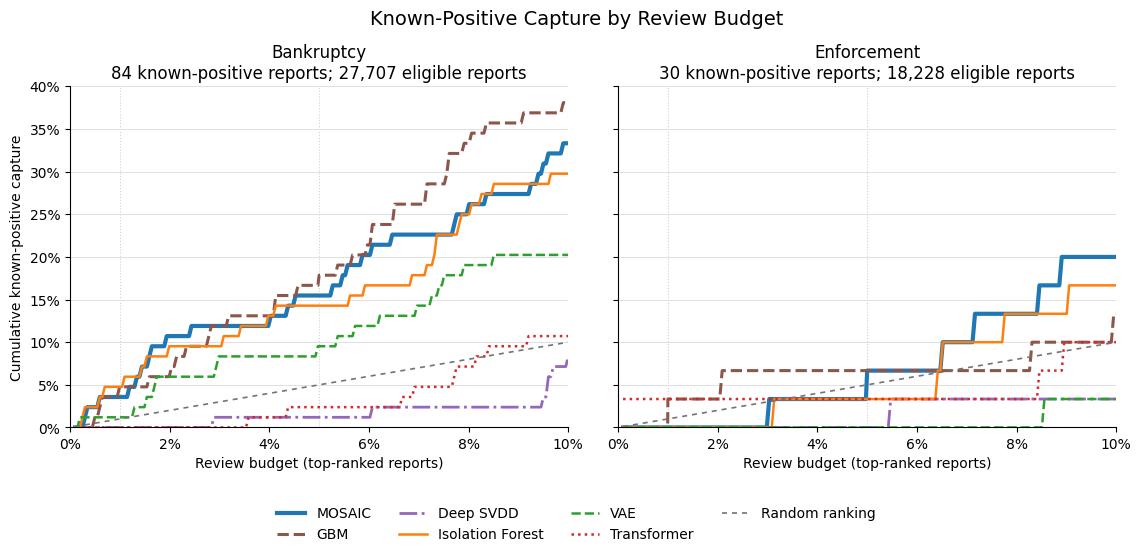

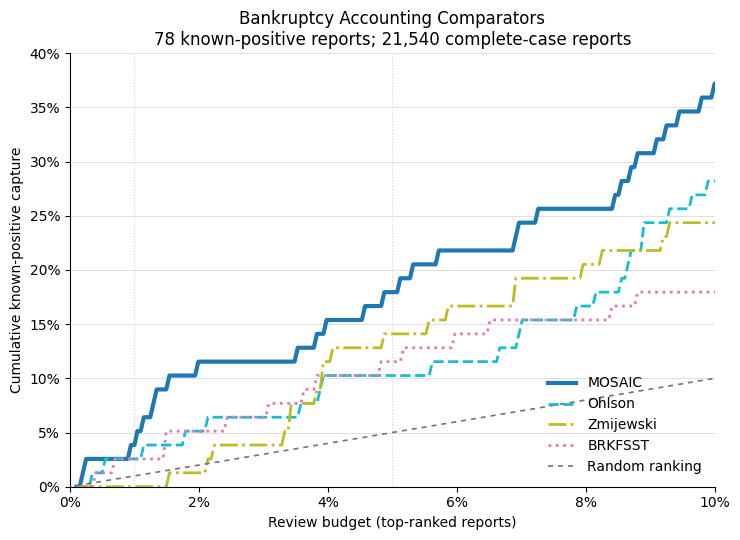


TOP-K CAPTURE CURVE AUDIT
Bankruptcy   eligible reports=27,707; positive reports=84
Enforcement  eligible reports=18,228; positive reports=30

Accounting complete-case reports: 21,540
Accounting eligible positive reports: 78
Accounting positive reports excluded: 6

Saved:
  C:\Users\lfult\OneDrive - bc.edu\Desktop\CMS Cost Reports\revision_results\revision_known_positive_capture_curves.png
  C:\Users\lfult\OneDrive - bc.edu\Desktop\CMS Cost Reports\revision_results\revision_known_positive_capture_curves.pdf
  C:\Users\lfult\OneDrive - bc.edu\Desktop\CMS Cost Reports\revision_results\revision_known_positive_capture_curve_data.csv
  C:\Users\lfult\OneDrive - bc.edu\Desktop\CMS Cost Reports\revision_results\revision_bankruptcy_accounting_capture_curves.png
  C:\Users\lfult\OneDrive - bc.edu\Desktop\CMS Cost Reports\revision_results\revision_bankruptcy_accounting_capture_curves.pdf
  C:\Users\lfult\OneDrive - bc.edu\Desktop\CMS Cost Reports\revision_results\revision_bankruptcy_accounting_

In [52]:
# =============================================================================
# TOP-K KNOWN-POSITIVE CAPTURE CURVES
#
# Main figure:
#   MOSAIC, GBM, DeepSVDD, Isolation Forest, VAE, and Transformer
#   for bankruptcy and enforcement.
#
# Supplemental figure:
#   MOSAIC, Ohlson, Zmijewski, and BRKFSST for bankruptcy using
#   one common complete-case risk set.
#
# Evaluation unit:
#   Distinct report record identified by _rpt_key_pk / RPT_REC_NUM.
# =============================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter


# =============================================================================
# 1. REQUIRED UPSTREAM OBJECTS
# =============================================================================

REQUIRED_GRAPH_OBJECTS = [
    "risk_panels",
    "positive_sets",
    "COMMON_SCORE_MAP",
    "BANKRUPTCY_ONLY_SCORE_MAP",
    "REV_DIR",
]

missing_graph_objects = [
    name
    for name in REQUIRED_GRAPH_OBJECTS
    if name not in globals()
]

if missing_graph_objects:
    raise RuntimeError(
        "Capture-curve block is missing required objects: "
        f"{missing_graph_objects}"
    )

REV_DIR = Path(REV_DIR)
REV_DIR.mkdir(parents=True, exist_ok=True)


# =============================================================================
# 2. MODEL SPECIFICATIONS
#
# First value: exact key in COMMON_SCORE_MAP
# Second value: manuscript display label
# Remaining values: plotting settings
# =============================================================================

COMMON_MODELS = [
    ("MOSAIC", "MOSAIC", "#1f77b4", "-", 3.0),
    ("GBM", "GBM", "#8c564b", "--", 2.2),
    ("DeepSVDD", "Deep SVDD", "#9467bd", "-.", 2.0),
    ("Standalone IF", "Isolation Forest", "#ff7f0e", "-", 1.8),
    ("Standalone VAE", "VAE", "#2ca02c", "--", 1.8),
    ("Standalone Transformer", "Transformer", "#d62728", ":", 1.8),
]

ACCOUNTING_MODELS = [
    ("MOSAIC", "MOSAIC", "#1f77b4", "-", 3.0),
    ("Ohlson", "Ohlson", "#17becf", "--", 2.0),
    ("Zmijewski", "Zmijewski", "#bcbd22", "-.", 2.0),
    ("BRKFSST", "BRKFSST", "#e377c2", ":", 2.0),
]

missing_common_keys = [
    key
    for key, _, _, _, _ in COMMON_MODELS
    if key not in COMMON_SCORE_MAP
]

if missing_common_keys:
    raise RuntimeError(
        "The following graph keys are absent from COMMON_SCORE_MAP: "
        f"{missing_common_keys}\n"
        f"Available keys: {list(COMMON_SCORE_MAP)}"
    )

missing_accounting_keys = [
    key
    for key, _, _, _, _ in ACCOUNTING_MODELS
    if (
        key != "MOSAIC"
        and key not in BANKRUPTCY_ONLY_SCORE_MAP
    )
]

if missing_accounting_keys:
    raise RuntimeError(
        "The following accounting-model keys are missing: "
        f"{missing_accounting_keys}"
    )


# =============================================================================
# 3. REVIEW-BUDGET GRID
# =============================================================================

REPORTED_BUDGETS = np.array(
    [0.01, 0.05, 0.10, .5, 1]
)

BUDGET_GRID = np.unique(
    np.concatenate(
        [
            np.linspace(
                0.001,
                0.10,
                200,
            ),
            REPORTED_BUDGETS,
        ]
    )
)


# =============================================================================
# 4. CURVE FUNCTION
# =============================================================================

def compute_capture_curve(
    panel,
    positive_ids,
    score_column,
    budget_grid,
):
    """
    Compute cumulative known-positive capture over top-ranked review budgets.

    Reports are ranked by descending model score. The report identifier is
    used as a deterministic tie breaker.
    """
    required_columns = [
        "_rpt_key_pk",
        score_column,
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in panel.columns
    ]

    if missing_columns:
        raise RuntimeError(
            f"{score_column}: missing columns {missing_columns}"
        )

    ranked = panel[
        ["_rpt_key_pk", score_column]
    ].copy()

    if ranked["_rpt_key_pk"].isna().any():
        raise RuntimeError(
            f"{score_column}: missing report identifiers."
        )

    if ranked["_rpt_key_pk"].duplicated().any():
        raise RuntimeError(
            f"{score_column}: duplicate report identifiers occur "
            "in the evaluation panel."
        )

    ranked["_score"] = pd.to_numeric(
        ranked[score_column],
        errors="coerce",
    )

    if ranked["_score"].isna().any():
        raise RuntimeError(
            f"{score_column}: missing scores occur in the evaluation panel."
        )

    if not np.isfinite(
        ranked["_score"].to_numpy()
    ).all():
        raise RuntimeError(
            f"{score_column}: nonfinite scores occur in the evaluation panel."
        )

    panel_ids = set(
        ranked["_rpt_key_pk"]
    )

    missing_positive_ids = (
        positive_ids - panel_ids
    )

    if missing_positive_ids:
        raise RuntimeError(
            f"{score_column}: {len(missing_positive_ids):,} positive "
            "report records are absent from the evaluation panel."
        )

    ranked = ranked.sort_values(
        by=["_score", "_rpt_key_pk"],
        ascending=[False, True],
        kind="mergesort",
    ).reset_index(drop=True)

    hit_indicator = (
        ranked["_rpt_key_pk"]
        .isin(positive_ids)
        .astype(int)
        .to_numpy()
    )

    cumulative_hits = np.cumsum(
        hit_indicator
    )

    risk_set_n = len(ranked)
    positive_n = len(positive_ids)

    k_values = np.ceil(
        budget_grid * risk_set_n
    ).astype(int)

    k_values = np.clip(
        k_values,
        1,
        risk_set_n,
    )

    hits = cumulative_hits[
        k_values - 1
    ]

    capture = (
        hits / positive_n
    )

    known_positive_yield = (
        hits / k_values
    )

    base_positive_rate = (
        positive_n / risk_set_n
    )

    lift = (
        known_positive_yield
        / base_positive_rate
    )

    return pd.DataFrame(
        {
            "budget_fraction": budget_grid,
            "k_n": k_values,
            "hits": hits,
            "capture": capture,
            "known_positive_yield": known_positive_yield,
            "lift": lift,
            "risk_set_n": risk_set_n,
            "positive_reports": positive_n,
        }
    )


def format_capture_axis(ax):
    """
    Apply consistent manuscript formatting.
    """
    ax.set_xlim(
        0.0,
        .1,
    )

    ax.set_ylim(
        0.0,
        .4,
    )

    ax.xaxis.set_major_formatter(
        PercentFormatter(
            xmax=1.0,
            decimals=0,
        )
    )

    ax.yaxis.set_major_formatter(
        PercentFormatter(
            xmax=1.0,
            decimals=0,
        )
    )

    for budget in REPORTED_BUDGETS:
        ax.axvline(
            budget,
            color="0.82",
            linestyle=":",
            linewidth=0.8,
            zorder=0,
        )

    ax.grid(
        axis="y",
        color="0.88",
        linewidth=0.7,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# =============================================================================
# 5. MAIN FIGURE: SIX COMMON MODELS
# =============================================================================

main_curve_frames = []

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13.5, 5.5),
    sharey=True,
)

for ax, outcome in zip(
    axes,
    ["bankruptcy", "enforcement"],
):
    panel = risk_panels[
        outcome
    ].copy()

    positive_ids = positive_sets[
        outcome
    ]

    for (
        model_key,
        display_label,
        color,
        linestyle,
        linewidth,
    ) in COMMON_MODELS:

        score_column = COMMON_SCORE_MAP[
            model_key
        ]

        curve = compute_capture_curve(
            panel=panel,
            positive_ids=positive_ids,
            score_column=score_column,
            budget_grid=BUDGET_GRID,
        )

        curve["outcome"] = outcome
        curve["model_key"] = model_key
        curve["model"] = display_label
        curve["score_column"] = score_column

        main_curve_frames.append(
            curve
        )

        ax.plot(
            curve["budget_fraction"],
            curve["capture"],
            label=display_label,
            color=color,
            linestyle=linestyle,
            linewidth=linewidth,
        )

    # Random-ranking expectation.
    ax.plot(
        BUDGET_GRID,
        BUDGET_GRID,
        label="Random ranking",
        color="0.45",
        linestyle=(0, (3, 3)),
        linewidth=1.2,
    )

    format_capture_axis(ax)

    ax.set_title(
        f"{outcome.capitalize()}\n"
        f"{len(positive_ids):,} known-positive reports; "
        f"{len(panel):,} eligible reports"
    )

    ax.set_xlabel(
        "Review budget (top-ranked reports)"
    )

axes[0].set_ylabel(
    "Cumulative known-positive capture"
)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, -0.01),
)

fig.suptitle(
    "Known-Positive Capture by Review Budget",
    fontsize=14,
    y=0.98,
)

fig.subplots_adjust(
    bottom=0.22,
    top=0.84,
    wspace=0.10,
)

main_png = (
    REV_DIR
    / "revision_known_positive_capture_curves.png"
)

main_pdf = (
    REV_DIR
    / "revision_known_positive_capture_curves.pdf"
)

fig.savefig(
    main_png,
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    main_pdf,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)


main_curve_data = pd.concat(
    main_curve_frames,
    ignore_index=True,
)

main_curve_csv = (
    REV_DIR
    / "revision_known_positive_capture_curve_data.csv"
)

main_curve_data.to_csv(
    main_curve_csv,
    index=False,
)


# =============================================================================
# 6. SUPPLEMENTAL BANKRUPTCY ACCOUNTING-MODEL FIGURE
# =============================================================================

accounting_score_map = {
    "MOSAIC": COMMON_SCORE_MAP["MOSAIC"],
    **BANKRUPTCY_ONLY_SCORE_MAP,
}

accounting_panel = risk_panels[
    "bankruptcy"
].copy()

accounting_columns = [
    accounting_score_map[key]
    for key, _, _, _, _ in ACCOUNTING_MODELS
]

for column in accounting_columns:
    accounting_panel[column] = pd.to_numeric(
        accounting_panel[column],
        errors="coerce",
    )

accounting_panel[
    accounting_columns
] = accounting_panel[
    accounting_columns
].replace(
    [np.inf, -np.inf],
    np.nan,
)

accounting_panel = (
    accounting_panel
    .dropna(
        subset=accounting_columns
    )
    .copy()
)

accounting_panel_ids = set(
    accounting_panel["_rpt_key_pk"]
)

accounting_positive_ids = (
    positive_sets["bankruptcy"]
    & accounting_panel_ids
)

excluded_accounting_positives = (
    positive_sets["bankruptcy"]
    - accounting_positive_ids
)

if accounting_panel.empty:
    raise RuntimeError(
        "The accounting-model complete-case panel is empty."
    )

if not accounting_positive_ids:
    raise RuntimeError(
        "No known-positive bankruptcy reports remain in the "
        "accounting-model complete-case panel."
    )

accounting_curve_frames = []

fig, ax = plt.subplots(
    figsize=(7.5, 5.5)
)

for (
    model_key,
    display_label,
    color,
    linestyle,
    linewidth,
) in ACCOUNTING_MODELS:

    score_column = accounting_score_map[
        model_key
    ]

    curve = compute_capture_curve(
        panel=accounting_panel,
        positive_ids=accounting_positive_ids,
        score_column=score_column,
        budget_grid=BUDGET_GRID,
    )

    curve["outcome"] = "bankruptcy"
    curve["model_key"] = model_key
    curve["model"] = display_label
    curve["score_column"] = score_column
    curve["analysis_sample"] = "common_complete_case"

    accounting_curve_frames.append(
        curve
    )

    ax.plot(
        curve["budget_fraction"],
        curve["capture"],
        label=display_label,
        color=color,
        linestyle=linestyle,
        linewidth=linewidth,
    )

ax.plot(
    BUDGET_GRID,
    BUDGET_GRID,
    label="Random ranking",
    color="0.45",
    linestyle=(0, (3, 3)),
    linewidth=1.2,
)

format_capture_axis(ax)

ax.set_title(
    "Bankruptcy Accounting Comparators\n"
    f"{len(accounting_positive_ids):,} known-positive reports; "
    f"{len(accounting_panel):,} complete-case reports"
)

ax.set_xlabel(
    "Review budget (top-ranked reports)"
)

ax.set_ylabel(
    "Cumulative known-positive capture"
)

ax.legend(
    loc="lower right",
    frameon=False,
)

fig.tight_layout()

accounting_png = (
    REV_DIR
    / "revision_bankruptcy_accounting_capture_curves.png"
)

accounting_pdf = (
    REV_DIR
    / "revision_bankruptcy_accounting_capture_curves.pdf"
)

fig.savefig(
    accounting_png,
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    accounting_pdf,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)


accounting_curve_data = pd.concat(
    accounting_curve_frames,
    ignore_index=True,
)

accounting_curve_csv = (
    REV_DIR
    / "revision_bankruptcy_accounting_capture_curve_data.csv"
)

accounting_curve_data.to_csv(
    accounting_curve_csv,
    index=False,
)


# =============================================================================
# 7. OUTPUT AUDIT
# =============================================================================

print("\n" + "=" * 88)
print("TOP-K CAPTURE CURVE AUDIT")
print("=" * 88)

for outcome in [
    "bankruptcy",
    "enforcement",
]:
    print(
        f"{outcome.capitalize():<12} "
        f"eligible reports={len(risk_panels[outcome]):,}; "
        f"positive reports={len(positive_sets[outcome]):,}"
    )

print(
    "\nAccounting complete-case reports: "
    f"{len(accounting_panel):,}"
)

print(
    "Accounting eligible positive reports: "
    f"{len(accounting_positive_ids):,}"
)

print(
    "Accounting positive reports excluded: "
    f"{len(excluded_accounting_positives):,}"
)

print("\nSaved:")
print(f"  {main_png}")
print(f"  {main_pdf}")
print(f"  {main_curve_csv}")
print(f"  {accounting_png}")
print(f"  {accounting_pdf}")
print(f"  {accounting_curve_csv}")

# 32. Coefficient Sensitivity Analysis

In [53]:
# %%
# =============================================================================
# MOSAIC COEFFICIENT AND OPERATING-THRESHOLD SENSITIVITY
# =============================================================================
#
# One-factor-at-a-time analysis around the primary specification:
#
#   Monotonicity penalty:       gamma_delta = 5.0
#   Cohort pooling penalty:     lambda_pool = 0.15
#   Shrinkage denominator:      kappa = 50
#   Internal FPR constraint:    alpha = 0.05
#
# The Kendall coefficient is not varied because its implemented term is
# constant with respect to candidate weights. Changing that coefficient
# shifts the objective value but cannot change the fitted weights or ranking.
#
# lambda_smooth is not varied because smoothness_ref=None in the current
# Baseline-only cohort fitting architecture, making that term inactive.
# =============================================================================

from __future__ import annotations

import gc
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from scipy.stats import spearmanr


# =============================================================================
# 0. REQUIRED OBJECTS
# =============================================================================

_REQUIRED_SENSITIVITY_OBJECTS = [
    "MOSAIC_RESULT",
    "MOSAIC_INPUT_DF",
    "SIGNAL_CATALOG",
    "run_mosaic_model",
    "bastian_auto_threshold",
    "MOSAIC_MONO_COEF",
    "SHRINKAGE_BASE",
    "REV_PANEL_INDEX",
]

_missing_sensitivity_objects = [
    name
    for name in _REQUIRED_SENSITIVITY_OBJECTS
    if name not in globals()
]

if _missing_sensitivity_objects:
    raise RuntimeError(
        "Run the primary MOSAIC and revision-helper cells first. "
        f"Missing objects: {_missing_sensitivity_objects}"
    )

if not MOSAIC_INPUT_DF.index.equals(REV_PANEL_INDEX):
    raise RuntimeError(
        "MOSAIC_INPUT_DF does not match the locked revision panel."
    )

if not MOSAIC_RESULT["df_out"].index.equals(REV_PANEL_INDEX):
    raise RuntimeError(
        "MOSAIC_RESULT does not match the locked revision panel."
    )

SENSITIVITY_DIR = (
    Path(globals().get("BASE_PATH", os.getcwd()))
    / "revision_results"
    / "coefficient_sensitivity"
)

SENSITIVITY_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

SENSITIVITY_RESTARTS = int(
    globals().get(
        "N_RESTARTS",
        10,
    )
)

SENSITIVITY_SEED = int(
    globals().get(
        "RANDOM_STATE_REV",
        2026,
    )
)


# =============================================================================
# 1. PRIMARY SETTINGS AND ONE-FACTOR-AT-A-TIME GRID
# =============================================================================

PRIMARY_MONO_COEF = 5.0
PRIMARY_LAMBDA_POOL = 0.15
PRIMARY_SHRINKAGE_BASE = 50.0
PRIMARY_ALPHA_FPR = 0.05

MONO_GRID = [
    0.0,
    2.5,
    5.0,
    10.0,
]

POOL_GRID = [
    0.00,
    0.05,
    0.15,
    0.30,
    0.50,
]

SHRINKAGE_GRID = [
    0.0,
    25.0,
    50.0,
    100.0,
]

FPR_GRID = [
    0.01,
    0.025,
    0.05,
    0.10,
]


def sensitivity_tag(
    parameter,
    value,
):
    """
    Construct a column-safe model tag.
    """
    value_text = (
        f"{float(value):g}"
        .replace("-", "neg")
        .replace(".", "p")
    )

    parameter_text = re.sub(
        r"[^A-Za-z0-9_]+",
        "_",
        str(parameter),
    )

    return (
        f"sens_{parameter_text}_{value_text}"
    )


# Baseline is reused rather than refitted.
SENSITIVITY_SPECS = [
    {
        "parameter": "primary",
        "value": np.nan,
        "mono_coef": PRIMARY_MONO_COEF,
        "lambda_pool": PRIMARY_LAMBDA_POOL,
        "shrinkage_base": PRIMARY_SHRINKAGE_BASE,
        "is_primary": True,
    },
]

for value in MONO_GRID:
    if not np.isclose(
        value,
        PRIMARY_MONO_COEF,
    ):
        SENSITIVITY_SPECS.append(
            {
                "parameter": "mono_coef",
                "value": float(value),
                "mono_coef": float(value),
                "lambda_pool": PRIMARY_LAMBDA_POOL,
                "shrinkage_base": PRIMARY_SHRINKAGE_BASE,
                "is_primary": False,
            }
        )

for value in POOL_GRID:
    if not np.isclose(
        value,
        PRIMARY_LAMBDA_POOL,
    ):
        SENSITIVITY_SPECS.append(
            {
                "parameter": "lambda_pool",
                "value": float(value),
                "mono_coef": PRIMARY_MONO_COEF,
                "lambda_pool": float(value),
                "shrinkage_base": PRIMARY_SHRINKAGE_BASE,
                "is_primary": False,
            }
        )

for value in SHRINKAGE_GRID:
    if not np.isclose(
        value,
        PRIMARY_SHRINKAGE_BASE,
    ):
        SENSITIVITY_SPECS.append(
            {
                "parameter": "shrinkage_base",
                "value": float(value),
                "mono_coef": PRIMARY_MONO_COEF,
                "lambda_pool": PRIMARY_LAMBDA_POOL,
                "shrinkage_base": float(value),
                "is_primary": False,
            }
        )


# =============================================================================
# 2. HELPERS
# =============================================================================

def sensitivity_score_column(
    result,
):
    """
    Resolve the actual score column for a primary or sensitivity result.
    """
    frame = result["df_out"]

    if (
        result is MOSAIC_RESULT
        and "mosaic_score" in frame.columns
    ):
        return "mosaic_score"

    model_tag = result.get(
        "model_tag"
    )

    candidate = (
        f"{model_tag}_score"
        if model_tag is not None
        else None
    )

    if (
        candidate is not None
        and candidate in frame.columns
    ):
        return candidate

    score_candidates = [
        column
        for column in frame.columns
        if column.endswith("_score")
    ]

    if len(score_candidates) == 1:
        return score_candidates[0]

    raise RuntimeError(
        "Could not uniquely identify the sensitivity score column. "
        f"Candidates: {score_candidates}"
    )


def scalar_public_values(
    values,
):
    """
    Retain public scalar outputs from an external-validation dictionary.
    """
    output = {}

    for key, value in values.items():
        if str(key).startswith("_"):
            continue

        if isinstance(
            value,
            (
                str,
                int,
                float,
                bool,
                np.integer,
                np.floating,
            ),
        ):
            output[key] = value

    return output


def dimension_weight_rows(
    result,
    parameter,
    value,
    mono_coef,
    lambda_pool,
    shrinkage_base,
):
    """
    Aggregate global weights by signal dimension.
    """
    signals = list(
        result["available_signals"]
    )

    weights = np.asarray(
        result["w_global"],
        dtype=float,
    )

    if len(signals) != len(weights):
        raise RuntimeError(
            "Signal and global-weight lengths differ."
        )

    catalog = result.get(
        "signal_catalog",
        globals().get(
            "MOSAIC_SIGNAL_CATALOG",
            {},
        ),
    )

    rows = []

    for signal, weight in zip(
        signals,
        weights,
    ):
        rows.append(
            {
                "parameter": parameter,
                "value": value,
                "mono_coef": mono_coef,
                "lambda_pool": lambda_pool,
                "shrinkage_base": shrinkage_base,
                "signal": signal,
                "dimension": (
                    catalog
                    .get(
                        signal,
                        {},
                    )
                    .get(
                        "dim",
                        "unknown",
                    )
                ),
                "weight": float(weight),
            }
        )

    return rows


def regime_rho(
    diagnostics,
    regime,
):
    """
    Extract a regime-specific Spearman coefficient from diagnostics.
    """
    regime_results = diagnostics.get(
        "regime_results",
        {},
    )

    value = regime_results.get(
        regime
    )

    if value is None:
        return np.nan

    if isinstance(
        value,
        (
            tuple,
            list,
        ),
    ):
        return float(value[0])

    return float(value)


def summarize_sensitivity_result(
    result,
    spec,
    primary_scores,
    primary_weights,
    primary_signals,
):
    """
    Construct the internal sensitivity summary row.
    """
    frame = result["df_out"]
    score_col = sensitivity_score_column(
        result
    )

    if not frame.index.equals(
        REV_PANEL_INDEX
    ):
        raise RuntimeError(
            f"{score_col}: fitted panel differs from the locked panel."
        )

    scores = pd.to_numeric(
        frame[score_col],
        errors="coerce",
    )

    anchor = pd.to_numeric(
        frame["_distress_anchor"],
        errors="coerce",
    )

    valid = (
        scores.notna()
        & anchor.notna()
    )

    rho_global = (
        float(
            spearmanr(
                scores.loc[valid],
                anchor.loc[valid],
            ).statistic
        )
        if int(valid.sum()) >= 3
        else np.nan
    )

    valid_rank = (
        scores.notna()
        & primary_scores.notna()
    )

    rank_stability = (
        float(
            spearmanr(
                scores.loc[valid_rank],
                primary_scores.loc[valid_rank],
            ).statistic
        )
        if int(valid_rank.sum()) >= 3
        else np.nan
    )

    signals = list(
        result["available_signals"]
    )

    weights = np.asarray(
        result["w_global"],
        dtype=float,
    )

    if signals != primary_signals:
        raise RuntimeError(
            "Sensitivity run changed the signal set or signal order."
        )

    weight_difference = (
        weights
        - primary_weights
    )

    diagnostics = result[
        "diagnostics"
    ]

    threshold = result[
        "threshold_result"
    ]

    return {
        "parameter": spec["parameter"],
        "value": spec["value"],
        "is_primary": bool(
            spec["is_primary"]
        ),
        "mono_coef": float(
            spec["mono_coef"]
        ),
        "lambda_pool": float(
            spec["lambda_pool"]
        ),
        "shrinkage_base": float(
            spec["shrinkage_base"]
        ),
        "n_reports": int(
            len(frame)
        ),
        "n_signals": int(
            len(signals)
        ),
        "rho_global": rho_global,
        "rho_peer_year_rank": float(
            diagnostics.get(
                "rho_peer_year_rank",
                np.nan,
            )
        ),
        "separation": float(
            diagnostics.get(
                "separation",
                np.nan,
            )
        ),
        "rho_baseline": regime_rho(
            diagnostics,
            "baseline",
        ),
        "rho_transition": regime_rho(
            diagnostics,
            "transition",
        ),
        "rho_covid_shock": regime_rho(
            diagnostics,
            "covid_shock",
        ),
        "rho_recovery": regime_rho(
            diagnostics,
            "recovery",
        ),
        "rank_correlation_with_primary": (
            rank_stability
        ),
        "global_weight_l1_distance": float(
            np.abs(
                weight_difference
            ).sum()
        ),
        "global_weight_l2_distance": float(
            np.sqrt(
                np.square(
                    weight_difference
                ).sum()
            )
        ),
        "global_weight_max_abs_change": float(
            np.abs(
                weight_difference
            ).max()
        ),
        "tau_star": float(
            threshold.get(
                "tau_star",
                np.nan,
            )
        ),
        "fpr": float(
            threshold.get(
                "fpr",
                np.nan,
            )
        ),
        "tpr": float(
            threshold.get(
                "tpr",
                np.nan,
            )
        ),
        "pct_flagged": float(
            threshold.get(
                "pct_flagged",
                np.nan,
            )
        ),
    }


# =============================================================================
# 3. LOAD EXTERNAL EVENTS WHEN AVAILABLE
# =============================================================================

_sensitivity_bankruptcy_events = globals().get(
    "bk_events"
)

_sensitivity_enforcement_events = globals().get(
    "enf_events"
)

if (
    _sensitivity_bankruptcy_events is None
    and "load_existing_matched_events" in globals()
):
    _sensitivity_bankruptcy_events = (
        load_existing_matched_events(
            "bankruptcy"
        )
    )

if (
    _sensitivity_enforcement_events is None
    and "load_existing_matched_events" in globals()
):
    try:
        _sensitivity_enforcement_events = (
            load_existing_matched_events(
                "enforcement"
            )
        )
    except Exception as exc:
        print(
            "Enforcement sensitivity validation skipped:",
            exc,
        )
        _sensitivity_enforcement_events = None

_HAVE_EXTERNAL_CAPTURE = (
    "external_capture" in globals()
    and _sensitivity_bankruptcy_events is not None
)


# =============================================================================
# 4. PRIMARY REFERENCE
# =============================================================================

PRIMARY_SENSITIVITY_RESULT = MOSAIC_RESULT

PRIMARY_SCORE_COLUMN = (
    sensitivity_score_column(
        PRIMARY_SENSITIVITY_RESULT
    )
)

PRIMARY_SCORES = pd.to_numeric(
    PRIMARY_SENSITIVITY_RESULT[
        "df_out"
    ][PRIMARY_SCORE_COLUMN],
    errors="coerce",
)

PRIMARY_WEIGHTS = np.asarray(
    PRIMARY_SENSITIVITY_RESULT[
        "w_global"
    ],
    dtype=float,
)

PRIMARY_SIGNALS = list(
    PRIMARY_SENSITIVITY_RESULT[
        "available_signals"
    ]
)


# =============================================================================
# 5. RUN COEFFICIENT SENSITIVITY
# =============================================================================

internal_rows = []
external_rows = []
signal_weight_rows = []

_original_mono_coef = float(
    MOSAIC_MONO_COEF
)

_original_shrinkage_base = float(
    SHRINKAGE_BASE
)

print(
    "\n"
    + "=" * 88
)
print(
    "MOSAIC COEFFICIENT SENSITIVITY"
)
print(
    "=" * 88
)
print(
    f"Specifications: {len(SENSITIVITY_SPECS)}"
)
print(
    f"Restarts per fitted variant: {SENSITIVITY_RESTARTS}"
)
print(
    f"Output directory: {SENSITIVITY_DIR}"
)

try:
    for run_number, spec in enumerate(
        SENSITIVITY_SPECS,
        start=1,
    ):
        print(
            "\n"
            f"[{run_number:02d}/"
            f"{len(SENSITIVITY_SPECS):02d}] "
            f"{spec['parameter']} = "
            f"{spec['value']}"
        )

        globals()[
            "MOSAIC_MONO_COEF"
        ] = float(
            spec["mono_coef"]
        )

        globals()[
            "SHRINKAGE_BASE"
        ] = float(
            spec["shrinkage_base"]
        )

        np.random.seed(
            SENSITIVITY_SEED
        )

        torch.manual_seed(
            SENSITIVITY_SEED
        )

        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(
                SENSITIVITY_SEED
            )

        if spec["is_primary"]:
            result = (
                PRIMARY_SENSITIVITY_RESULT
            )

            model_label = "MOSAIC primary"

        else:
            model_tag = sensitivity_tag(
                spec["parameter"],
                spec["value"],
            )

            result = run_mosaic_model(
                base_df=MOSAIC_INPUT_DF,
                base_catalog=SIGNAL_CATALOG,
                model_tag=model_tag,
                include_financial_signals=False,
                verbose=False,
                n_restarts=(
                    SENSITIVITY_RESTARTS
                ),
                lambda_smooth=0.0,
                lambda_pool=float(
                    spec["lambda_pool"]
                ),
                alpha_fpr=(
                    PRIMARY_ALPHA_FPR
                ),
                add_explicit_model_scores=True,
            )

            model_label = model_tag

        score_col = sensitivity_score_column(
            result
        )

        internal_rows.append(
            summarize_sensitivity_result(
                result=result,
                spec=spec,
                primary_scores=PRIMARY_SCORES,
                primary_weights=PRIMARY_WEIGHTS,
                primary_signals=PRIMARY_SIGNALS,
            )
        )

        signal_weight_rows.extend(
            dimension_weight_rows(
                result=result,
                parameter=spec["parameter"],
                value=spec["value"],
                mono_coef=spec["mono_coef"],
                lambda_pool=spec[
                    "lambda_pool"
                ],
                shrinkage_base=spec[
                    "shrinkage_base"
                ],
            )
        )

        if _HAVE_EXTERNAL_CAPTURE:
            bankruptcy_result = (
                external_capture(
                    result["df_out"],
                    score_col,
                    _sensitivity_bankruptcy_events,
                    model_label,
                    "bankruptcy",
                )
            )

            bankruptcy_row = {
                "parameter": spec[
                    "parameter"
                ],
                "value": spec["value"],
                "is_primary": bool(
                    spec["is_primary"]
                ),
                "mono_coef": float(
                    spec["mono_coef"]
                ),
                "lambda_pool": float(
                    spec["lambda_pool"]
                ),
                "shrinkage_base": float(
                    spec["shrinkage_base"]
                ),
                "outcome": "bankruptcy",
            }

            bankruptcy_row.update(
                scalar_public_values(
                    bankruptcy_result
                )
            )

            external_rows.append(
                bankruptcy_row
            )

            if (
                _sensitivity_enforcement_events
                is not None
            ):
                enforcement_result = (
                    external_capture(
                        result["df_out"],
                        score_col,
                        _sensitivity_enforcement_events,
                        model_label,
                        "enforcement",
                    )
                )

                enforcement_row = {
                    "parameter": spec[
                        "parameter"
                    ],
                    "value": spec["value"],
                    "is_primary": bool(
                        spec["is_primary"]
                    ),
                    "mono_coef": float(
                        spec["mono_coef"]
                    ),
                    "lambda_pool": float(
                        spec["lambda_pool"]
                    ),
                    "shrinkage_base": float(
                        spec["shrinkage_base"]
                    ),
                    "outcome": "enforcement",
                }

                enforcement_row.update(
                    scalar_public_values(
                        enforcement_result
                    )
                )

                external_rows.append(
                    enforcement_row
                )

        if not spec["is_primary"]:
            del result
            gc.collect()

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

finally:
    globals()[
        "MOSAIC_MONO_COEF"
    ] = _original_mono_coef

    globals()[
        "SHRINKAGE_BASE"
    ] = _original_shrinkage_base


# =============================================================================
# 6. OPERATING-THRESHOLD SENSITIVITY
# =============================================================================
#
# The operating threshold is an internal diagnostic only. Risk tiers and
# external review-budget rankings are calibrated separately and therefore
# do not change when alpha varies.
# =============================================================================

threshold_rows = []

_primary_frame = MOSAIC_RESULT[
    "df_out"
]

_primary_score = pd.to_numeric(
    _primary_frame[
        PRIMARY_SCORE_COLUMN
    ],
    errors="coerce",
)

_primary_anchor = pd.to_numeric(
    _primary_frame[
        "_distress_anchor"
    ],
    errors="coerce",
)

for alpha in FPR_GRID:
    threshold_result = (
        bastian_auto_threshold(
            F=_primary_score,
            distress=_primary_anchor,
            alpha=float(alpha),
            distress_cutoff=0.6,
        )
    )

    threshold_rows.append(
        {
            "alpha_fpr": float(alpha),
            "tau_star": float(
                threshold_result[
                    "tau_star"
                ]
            ),
            "realized_fpr": float(
                threshold_result[
                    "fpr"
                ]
            ),
            "tpr": float(
                threshold_result[
                    "tpr"
                ]
            ),
            "pct_flagged": float(
                threshold_result[
                    "pct_flagged"
                ]
            ),
            "score_separation": float(
                threshold_result[
                    "separation"
                ]
            ),
            "method": threshold_result[
                "method"
            ],
        }
    )


# =============================================================================
# 7. ASSEMBLE AND SAVE OUTPUTS
# =============================================================================

MOSAIC_COEFFICIENT_SENSITIVITY = (
    pd.DataFrame(
        internal_rows
    )
    .sort_values(
        [
            "is_primary",
            "parameter",
            "value",
        ],
        ascending=[
            False,
            True,
            True,
        ],
        na_position="first",
    )
    .reset_index(
        drop=True
    )
)

MOSAIC_SENSITIVITY_SIGNAL_WEIGHTS = (
    pd.DataFrame(
        signal_weight_rows
    )
)

MOSAIC_SENSITIVITY_DIMENSIONS = (
    MOSAIC_SENSITIVITY_SIGNAL_WEIGHTS
    .groupby(
        [
            "parameter",
            "value",
            "mono_coef",
            "lambda_pool",
            "shrinkage_base",
            "dimension",
        ],
        dropna=False,
        as_index=False,
    )["weight"]
    .sum()
    .rename(
        columns={
            "weight":
                "dimension_weight"
        }
    )
)

MOSAIC_THRESHOLD_SENSITIVITY = (
    pd.DataFrame(
        threshold_rows
    )
)

MOSAIC_EXTERNAL_SENSITIVITY = (
    pd.DataFrame(
        external_rows
    )
    if external_rows
    else pd.DataFrame()
)

_internal_path = (
    SENSITIVITY_DIR
    / "mosaic_coefficient_sensitivity_internal.csv"
)

_signal_path = (
    SENSITIVITY_DIR
    / "mosaic_coefficient_sensitivity_signal_weights.csv"
)

_dimension_path = (
    SENSITIVITY_DIR
    / "mosaic_coefficient_sensitivity_dimensions.csv"
)

_threshold_path = (
    SENSITIVITY_DIR
    / "mosaic_operating_threshold_sensitivity.csv"
)

_external_path = (
    SENSITIVITY_DIR
    / "mosaic_coefficient_sensitivity_external.csv"
)

MOSAIC_COEFFICIENT_SENSITIVITY.to_csv(
    _internal_path,
    index=False,
)

MOSAIC_SENSITIVITY_SIGNAL_WEIGHTS.to_csv(
    _signal_path,
    index=False,
)

MOSAIC_SENSITIVITY_DIMENSIONS.to_csv(
    _dimension_path,
    index=False,
)

MOSAIC_THRESHOLD_SENSITIVITY.to_csv(
    _threshold_path,
    index=False,
)

if not MOSAIC_EXTERNAL_SENSITIVITY.empty:
    MOSAIC_EXTERNAL_SENSITIVITY.to_csv(
        _external_path,
        index=False,
    )


# =============================================================================
# 8. MANUSCRIPT-FACING DISPLAY
# =============================================================================

_display_columns = [
    "parameter",
    "value",
    "rho_global",
    "rho_peer_year_rank",
    "separation",
    "rho_baseline",
    "rho_covid_shock",
    "rho_recovery",
    "rank_correlation_with_primary",
    "global_weight_l1_distance",
    "global_weight_max_abs_change",
]

print(
    "\n"
    + "=" * 88
)
print(
    "INTERNAL COEFFICIENT SENSITIVITY"
)
print(
    "=" * 88
)

print(
    MOSAIC_COEFFICIENT_SENSITIVITY[
        _display_columns
    ].to_string(
        index=False,
        float_format=lambda value:
            f"{value:.4f}",
    )
)

print(
    "\n"
    + "=" * 88
)
print(
    "OPERATING-THRESHOLD SENSITIVITY"
)
print(
    "=" * 88
)

print(
    MOSAIC_THRESHOLD_SENSITIVITY.to_string(
        index=False,
        float_format=lambda value:
            f"{value:.4f}",
    )
)

if not MOSAIC_EXTERNAL_SENSITIVITY.empty:
    print(
        "\n"
        + "=" * 88
    )
    print(
        "EXTERNAL COEFFICIENT SENSITIVITY"
    )
    print(
        "=" * 88
    )

    print(
        MOSAIC_EXTERNAL_SENSITIVITY.to_string(
            index=False,
            float_format=lambda value:
                f"{value:.4f}",
        )
    )

print(
    "\nSaved:"
)
print(
    f"  {_internal_path}"
)
print(
    f"  {_signal_path}"
)
print(
    f"  {_dimension_path}"
)
print(
    f"  {_threshold_path}"
)

if not MOSAIC_EXTERNAL_SENSITIVITY.empty:
    print(
        f"  {_external_path}"
    )

print(
    "\nGlobal settings restored:"
)
print(
    "  MOSAIC_MONO_COEF =",
    MOSAIC_MONO_COEF,
)
print(
    "  SHRINKAGE_BASE =",
    SHRINKAGE_BASE,
)


MOSAIC COEFFICIENT SENSITIVITY
Specifications: 11
Restarts per fitted variant: 10
Output directory: C:\Users\lfult\OneDrive - bc.edu\Desktop\CMS Cost Reports\revision_results\coefficient_sensitivity

[01/11] primary = nan

[02/11] mono_coef = 0.0

[03/11] mono_coef = 2.5

[04/11] mono_coef = 10.0

[05/11] lambda_pool = 0.0

[06/11] lambda_pool = 0.05

[07/11] lambda_pool = 0.3

[08/11] lambda_pool = 0.5

[09/11] shrinkage_base = 0.0

[10/11] shrinkage_base = 25.0

[11/11] shrinkage_base = 100.0

INTERNAL COEFFICIENT SENSITIVITY
     parameter    value  rho_global  rho_peer_year_rank  separation  rho_baseline  rho_covid_shock  rho_recovery  rank_correlation_with_primary  global_weight_l1_distance  global_weight_max_abs_change
       primary      NaN      0.5579              0.5364      0.4031        0.5992           0.5111        0.5117                         1.0000                     0.0000                        0.0000
   lambda_pool   0.0000      0.5188              0.5323      0.

In [42]:
print("REV_RUNS keys:", sorted(REV_RUNS.keys()))

REV_RUNS keys: ['deep_svdd', 'minus_analytical', 'minus_behavioral', 'minus_model_based', 'mosaic', 'mosaic_x']


---
# Appendix — Field Sniffers
*(Empirical worksheet address verification — run once, then lock LOCKED_NUMERIC_FIELDS)*

## A.  Cost Worksheets — E & G

In [ ]:
"""
E WORKSHEET MAPPING MATRIX — ALL YEARS (FY2011–2023)
============================================================
For each fiscal year, finds the correct worksheet/line/col
address for the five target fields:
  - ipps_payments
  - ime_payment_amt
  - final_settlement

Strategy per field:
  - Uses the anchor from 2011 sniffer results as the primary
    candidate line number, then searches all E worksheet codes
    for that line number and picks the highest-population hit.
  - Reports the winning address, hospital count, and median value.
  - Flags year/field combos where no populated address is found.

OUTPUT:
  1. Console summary table per year
  2. mapping_matrix.csv  — machine-readable, one row per year×field
  3. locked_numeric_fields_e_section.py — drop-in replacement code
     for your LOCKED_NUMERIC_FIELDS E-section (uses regex handler
     for years where worksheet codes vary)
============================================================
"""

import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import re

warnings.filterwarnings("ignore")

# ============================================================
# CONFIG
# ============================================================
BASE_DIR   = Path(r"c:/Users/lfult/OneDrive - bc.edu/Desktop/CMS Cost Reports")
OUTPUT_DIR = BASE_DIR / "processed_panel"
OUTPUT_DIR.mkdir(exist_ok=True)

YEARS = list(range(2011, 2025))

# Minimum absolute value to count a cell as populated
MIN_VAL = 1_000

# Target fields: name → (anchor_line, candidate_cols, description)
# anchor_line: the line number we expect from 2011 analysis
# candidate_cols: columns to try in priority order
TARGETS = {
    "ipps_payments": {
        "line": "00100",
        "cols": ["00200", "00100", "00400"],
        "desc": "IPPS base payment / total interim payments",
        "min_hospitals": 1000,  # expect broad population
    },
        "line": "00400",
        "cols": ["00200", "00100", "00400"],
        "desc": "Total interim payments received",
        "min_hospitals": 1000,
    },
    "ime_payment_amt": {
        "line": "02900",
        "cols": ["00100", "00200", "00300"],
        "desc": "Indirect Medical Education (IME) payment",
        "min_hospitals": 500,   # teaching hospitals only ~38%
    },
        "line": "06400",
        "cols": ["00100", "00200"],
        "desc": "HITECH / EHR incentive payment",
        "min_hospitals": 200,   # EHR era: expect 2011-2019 only
    },
    "final_settlement": {
        "line": "07400",
        "cols": ["00100", "00200"],
        "desc": "Final settlement amount",
        "min_hospitals": 100,   # sparse but real
    },
}

# ============================================================
# HELPERS
# ============================================================
def sniff_delimiter(filepath: Path) -> str:
    with open(filepath, "r", encoding="latin1", errors="replace") as f:
        line = f.readline()
    counts = {",": line.count(","), "\t": line.count("\t"), "|": line.count("|")}
    return max(counts, key=counts.get)


def load_nmrc(filepath: Path) -> pd.DataFrame:
    sep = sniff_delimiter(filepath)
    df = pd.read_csv(
        filepath, sep=sep, header=None,
        names=["RPT_REC_NUM", "WKSHT_CD", "LINE_NUM", "CLMN_NUM", "ITM_VAL_NUM"],
        encoding="latin1", low_memory=False, dtype=str,
    )
    df["RPT_REC_NUM"] = df["RPT_REC_NUM"].astype(str).str.strip()
    df["WKSHT_CD"]    = df["WKSHT_CD"].astype(str).str.strip()
    df["LINE_NUM"]    = df["LINE_NUM"].astype(str).str.strip().str.zfill(5)
    df["CLMN_NUM"]    = df["CLMN_NUM"].astype(str).str.strip().str.zfill(5)
    df["ITM_VAL_NUM"] = pd.to_numeric(df["ITM_VAL_NUM"], errors="coerce")
    return df


def find_best_address(nmrc: pd.DataFrame, line: str, cols: list,
                       min_hospitals: int) -> dict:
    """
    Across all E worksheets, find the (ws, col) combo for this line
    that has the most hospitals with |value| > MIN_VAL.
    Tries cols in priority order; returns first that clears min_hospitals,
    else returns the highest-count result regardless.
    """
    e_sub = nmrc[
        nmrc["WKSHT_CD"].str.startswith("E") &
        (nmrc["LINE_NUM"] == line) &
        (nmrc["ITM_VAL_NUM"].abs() > MIN_VAL)
    ].copy()

    if e_sub.empty:
        return {"ws": None, "col": None, "hosp_count": 0,
                "median": None, "max": None, "status": "NOT_FOUND"}

    # Score every ws×col combo
    grp = (
        e_sub.groupby(["WKSHT_CD", "CLMN_NUM"])
        .agg(
            hosp_count=("RPT_REC_NUM", "nunique"),
            median_val=("ITM_VAL_NUM", "median"),
            max_val=("ITM_VAL_NUM", "max"),
        )
        .reset_index()
        .sort_values("hosp_count", ascending=False)
    )

    # Try preferred cols first
    for preferred_col in cols:
        col_rows = grp[grp["CLMN_NUM"] == preferred_col]
        if not col_rows.empty:
            best = col_rows.iloc[0]
            if best["hosp_count"] >= min_hospitals:
                return {
                    "ws": best["WKSHT_CD"],
                    "col": best["CLMN_NUM"],
                    "hosp_count": int(best["hosp_count"]),
                    "median": best["median_val"],
                    "max": best["max_val"],
                    "status": "OK",
                }

    # Fall back to absolute best regardless of col preference
    best = grp.iloc[0]
    status = "OK" if best["hosp_count"] >= min_hospitals else "LOW_POP"
    return {
        "ws": best["WKSHT_CD"],
        "col": best["CLMN_NUM"],
        "hosp_count": int(best["hosp_count"]),
        "median": best["median_val"],
        "max": best["max_val"],
        "status": status,
    }


# ============================================================
# MAIN LOOP
# ============================================================
print("=" * 75)
print("E WORKSHEET MAPPING MATRIX — FY2011 through FY2023")
print("=" * 75)

all_results = []  # for CSV output

for year in YEARS:
    data_dir  = BASE_DIR / f"HOSP10FY{year}"
    nmrc_file = data_dir / f"hosp10_{year}_NMRC.CSV"

    if not nmrc_file.exists():
        print(f"\nFY{year}: FILE NOT FOUND — skipping ({nmrc_file})")
        for field in TARGETS:
            all_results.append({
                "year": year, "field": field,
                "ws": None, "line": TARGETS[field]["line"], "col": None,
                "hosp_count": 0, "median": None, "max": None,
                "status": "FILE_MISSING",
            })
        continue

    print(f"\nFY{year}: Loading {nmrc_file.name}...", end=" ", flush=True)
    nmrc = load_nmrc(nmrc_file)
    print(f"{len(nmrc):,} rows | {nmrc['RPT_REC_NUM'].nunique():,} reports")

    print(f"  {'Field':<22} {'Worksheet':<12} {'Line':<7} {'Col':<6} "
          f"{'Hospitals':>10} {'Median':>15} {'Status'}")
    print(f"  {'-'*22} {'-'*12} {'-'*7} {'-'*6} {'-'*10} {'-'*15} {'-'*10}")

    for field, cfg in TARGETS.items():
        result = find_best_address(
            nmrc, cfg["line"], cfg["cols"], cfg["min_hospitals"]
        )

        ws_str  = result["ws"]  or "---"
        col_str = result["col"] or "---"
        n_str   = f"{result['hosp_count']:,}" if result["hosp_count"] else "0"
        med_str = f"${result['median']:,.0f}" if result["median"] is not None else "---"
        status  = result["status"]

        flag = " ⚠" if status not in ("OK",) else ""
        print(f"  {field:<22} {ws_str:<12} {cfg['line']:<7} {col_str:<6} "
              f"{n_str:>10} {med_str:>15}  {status}{flag}")

        all_results.append({
            "year": year,
            "field": field,
            "ws": result["ws"],
            "line": cfg["line"],
            "col": result["col"],
            "hosp_count": result["hosp_count"],
            "median": result["median"],
            "max": result["max"],
            "status": result["status"],
        })

# ============================================================
# SAVE MAPPING MATRIX CSV
# ============================================================
matrix_df = pd.DataFrame(all_results)
csv_path = OUTPUT_DIR / "e_worksheet_mapping_matrix.csv"
matrix_df.to_csv(csv_path, index=False)
print(f"\n\nMapping matrix saved → {csv_path}")

# ============================================================
# PIVOT SUMMARY TABLE — one row per field, cols = years
# ============================================================
print("\n")
print("=" * 75)
print("PIVOT: WORKSHEET CODE BY FIELD × YEAR")
print("(Shows how worksheet codes change across years)")
print("=" * 75)

pivot = matrix_df.pivot(index="field", columns="year", values="ws")
print(pivot.to_string())

print("\n")
print("=" * 75)
print("PIVOT: HOSPITAL COUNT BY FIELD × YEAR")
print("=" * 75)
pivot_n = matrix_df.pivot(index="field", columns="year", values="hosp_count")
print(pivot_n.to_string())

# ============================================================
# GENERATE DROP-IN REPLACEMENT CODE
# ============================================================
print("\n")
print("=" * 75)
print("GENERATING DROP-IN LOCKED_NUMERIC_FIELDS E-SECTION...")
print("=" * 75)

# For each field, determine if worksheet codes are consistent
# across years or require regex handling
code_lines = []
code_lines.append('# ============================================================')
code_lines.append('# E WORKSHEET FIELDS — AUTO-MAPPED FROM SNIFFER')
code_lines.append('# Generated by e_worksheet_mapper_all_years.py')
code_lines.append('# Review LOW_POP and NOT_FOUND entries before using.')
code_lines.append('# ============================================================')
code_lines.append('')
code_lines.append('# --- STATIC ENTRIES (consistent worksheet code across years) ---')
code_lines.append('# Add to LOCKED_NUMERIC_FIELDS:')
code_lines.append('')

regex_fields = {}  # fields that need regex handler

for field, cfg in TARGETS.items():
    field_rows = matrix_df[
        (matrix_df["field"] == field) &
        (matrix_df["status"].isin(["OK", "LOW_POP"]))
    ]

    if field_rows.empty:
        code_lines.append(f'    # {field}: NOT FOUND in any year — omit or investigate')
        code_lines.append('')
        continue

    ws_values   = field_rows["ws"].dropna().unique()
    col_values  = field_rows["col"].dropna().unique()
    year_count  = len(field_rows)
    ok_count    = (field_rows["status"] == "OK").sum()

    # Check consistency
    ws_consistent  = len(ws_values) == 1
    col_consistent = len(col_values) == 1

    if ws_consistent and col_consistent:
        ws  = ws_values[0]
        col = col_values[0]
        line = cfg["line"]
        code_lines.append(
            f'    ("{field:<22}", "{ws}", "{line}", "{col}"),  '
            f'# {ok_count}/{year_count} years OK  |  {cfg["desc"]}'
        )
    else:
        # Build regex pattern from observed worksheet codes
        ws_set = sorted(set(ws_values))
        # Extract prefix patterns (first 4-5 chars tend to be stable)
        prefixes = sorted(set(w[:5] for w in ws_set))
        pattern = "^(" + "|".join(re.escape(p) for p in prefixes) + ")"

        col = col_values[0]  # use most common col
        line = cfg["line"]

        code_lines.append(
            f'    # {field}: worksheet varies across years → use REGEX_FIELDS handler'
        )
        regex_fields[field] = {
            "ws_pattern": pattern,
            "line": line,
            "col": col,
            "ws_observed": ws_set,
            "desc": cfg["desc"],
            "ok_count": ok_count,
            "year_count": year_count,
        }

code_lines.append('')
code_lines.append('# --- REGEX ENTRIES (add to REGEX_FIELDS dict) ---')
code_lines.append('')
code_lines.append('REGEX_FIELDS_E = {')

for field, info in regex_fields.items():
    code_lines.append(f'    # {info["desc"]}')
    code_lines.append(f'    # Observed worksheet codes: {info["ws_observed"]}')
    code_lines.append(
        f'    "{field}": dict(ws=r"{info["ws_pattern"]}", '
        f'line="{info["line"]}", col="{info["col"]}", agg="sum"),'
        f'  # {info["ok_count"]}/{info["year_count"]} years OK'
    )

code_lines.append('}')
code_lines.append('')

# Year-by-year detail block as comments
code_lines.append('# ============================================================')
code_lines.append('# YEAR-BY-YEAR ADDRESS DETAIL (for manual verification)')
code_lines.append('# ============================================================')
for field in TARGETS:
    code_lines.append(f'# {field}:')
    field_rows = matrix_df[matrix_df["field"] == field].sort_values("year")
    for _, row in field_rows.iterrows():
        if row["status"] == "FILE_MISSING":
            code_lines.append(f'#   FY{int(row["year"])}: FILE MISSING')
        elif row["status"] == "NOT_FOUND":
            code_lines.append(f'#   FY{int(row["year"])}: NOT FOUND')
        else:
            med_str = f'${row["median"]:,.0f}' if pd.notna(row["median"]) else 'N/A'
            code_lines.append(
                f'#   FY{int(row["year"])}: {row["ws"]} / line {row["line"]} '
                f'/ col {row["col"]}  →  {int(row["hosp_count"]):,} hospitals  '
                f'median {med_str}  [{row["status"]}]'
            )
    code_lines.append('#')

generated_code = "\n".join(code_lines)
print(generated_code)

# Save the generated code
code_path = OUTPUT_DIR / "locked_numeric_fields_e_section.py"
with open(code_path, "w") as f:
    f.write('"""\nAuto-generated E worksheet mappings.\n'
            'Paste the static entries into LOCKED_NUMERIC_FIELDS\n'
            'and the regex entries into REGEX_FIELDS.\n"""\n\n')
    f.write(generated_code)

print(f"\nDrop-in code saved → {code_path}")
print("\nSniffer complete.")

## B.  Revenue & Charges

In [59]:
"""
REVENUE & CHARGES WORKSHEET MAPPING MATRIX — ALL YEARS (FY2011–2023)
============================================================
Verifies and corrects the following fields across all 13 years:
  - gross_patient_revenue   (G worksheet)
  - contractual_allowances  (G worksheet)
  - net_patient_revenue     (G worksheet)
  - other_operating_rev     (G worksheet)
  - total_charges           (G worksheet)
  - medicare_charges        (D worksheet)
  - dsh_payment_amt         (E worksheet — known bad mapping)

Strategy:
  - For each field, searches all worksheets matching the expected
    prefix (G, D, or E) for the anchor line number.
  - Picks the highest-population (ws, col) combo that clears the
    minimum hospital threshold.
  - Flags LOW_POP and NOT_FOUND entries.

OUTPUT:
  1. Console summary per year
  2. revenue_mapping_matrix.csv
  3. locked_numeric_fields_revenue_section.py — drop-in replacement
============================================================
"""

import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import re

warnings.filterwarnings("ignore")

# ============================================================
# CONFIG
# ============================================================
BASE_DIR   = Path(r"c:/Users/lfult/OneDrive - bc.edu/Desktop/CMS Cost Reports")
OUTPUT_DIR = BASE_DIR / "processed_panel"
OUTPUT_DIR.mkdir(exist_ok=True)

YEARS   = list(range(2011, 2025))
MIN_VAL = 1_000  # minimum absolute value to count as populated

# Target fields:
#   ws_prefix   : first letter(s) to filter worksheets
#   line        : anchor line number (5-digit zero-padded)
#   cols        : preferred columns in priority order
#   min_hospitals: threshold to call a result OK vs LOW_POP
#   desc        : human label
TARGETS = {
    "gross_patient_revenue": {
        "ws_prefix": "G",
        "line": "00100",
        "cols": ["00100", "00200", "00300"],
        "min_hospitals": 3000,
        "desc": "Gross patient revenue (total charges before deductions)",
    },
    "contractual_allowances": {
        "ws_prefix": "G",
        "line": "00200",
        "cols": ["00100", "00200", "00300"],
        "min_hospitals": 3000,
        "desc": "Contractual allowances / deductions from revenue",
    },
    "net_patient_revenue": {
        "ws_prefix": "G",
        "line": "00300",
        "cols": ["00100", "00200", "00300"],
        "min_hospitals": 3000,
        "desc": "Net patient revenue after deductions",
    },
    "other_operating_rev": {
        "ws_prefix": "G",
        "line": "02500",
        "cols": ["00100", "00200", "00300"],
        "min_hospitals": 1000,
        "desc": "Other operating revenue",
    },
    "total_charges": {
        "ws_prefix": "G",
        "line": "02800",
        "cols": ["00300", "00100", "00200"],
        "min_hospitals": 3000,
        "desc": "Total charges (gross billed)",
    },
        "min_hospitals": 1000,
    "medicare_charges": {
        "ws_prefix": "D",
        "line": "20000",
        "cols": ["00200", "00100", "00300"],
        "min_hospitals": 3000,
        "desc": "Medicare charges / cost allocated to Medicare",
    },
    "dsh_payment_amt": {
        "ws_prefix": "E",
        "line": "03300",
        "cols": ["00100", "00200", "00300"],
        "min_hospitals": 1000,
        "desc": "Disproportionate Share Hospital (DSH) payment",
    },
}

# ============================================================
# HELPERS
# ============================================================
def sniff_delimiter(filepath: Path) -> str:
    with open(filepath, "r", encoding="latin1", errors="replace") as f:
        line = f.readline()
    counts = {",": line.count(","), "\t": line.count("\t"), "|": line.count("|")}
    return max(counts, key=counts.get)


def load_nmrc(filepath: Path) -> pd.DataFrame:
    sep = sniff_delimiter(filepath)
    df = pd.read_csv(
        filepath, sep=sep, header=None,
        names=["RPT_REC_NUM", "WKSHT_CD", "LINE_NUM", "CLMN_NUM", "ITM_VAL_NUM"],
        encoding="latin1", low_memory=False, dtype=str,
    )
    df["RPT_REC_NUM"] = df["RPT_REC_NUM"].astype(str).str.strip()
    df["WKSHT_CD"]    = df["WKSHT_CD"].astype(str).str.strip()
    df["LINE_NUM"]    = df["LINE_NUM"].astype(str).str.strip().str.zfill(5)
    df["CLMN_NUM"]    = df["CLMN_NUM"].astype(str).str.strip().str.zfill(5)
    df["ITM_VAL_NUM"] = pd.to_numeric(df["ITM_VAL_NUM"], errors="coerce")
    return df


def find_best_address(nmrc: pd.DataFrame, ws_prefix: str, line: str,
                      cols: list, min_hospitals: int) -> dict:
    """
    Search all worksheets starting with ws_prefix for the given line.
    Returns the (ws, col) with the highest hospital count, preferring
    cols in the given priority order.
    """
    sub = nmrc[
        nmrc["WKSHT_CD"].str.startswith(ws_prefix) &
        (nmrc["LINE_NUM"] == line) &
        (nmrc["ITM_VAL_NUM"].abs() > MIN_VAL)
    ].copy()

    if sub.empty:
        return {"ws": None, "col": None, "hosp_count": 0,
                "median": None, "max": None, "status": "NOT_FOUND"}

    grp = (
        sub.groupby(["WKSHT_CD", "CLMN_NUM"])
        .agg(
            hosp_count=("RPT_REC_NUM", "nunique"),
            median_val=("ITM_VAL_NUM", "median"),
            max_val=("ITM_VAL_NUM", "max"),
        )
        .reset_index()
        .sort_values("hosp_count", ascending=False)
    )

    # Try preferred columns first (in priority order)
    for preferred_col in cols:
        col_rows = grp[grp["CLMN_NUM"] == preferred_col]
        if not col_rows.empty:
            best = col_rows.iloc[0]
            if best["hosp_count"] >= min_hospitals:
                return {
                    "ws": best["WKSHT_CD"],
                    "col": best["CLMN_NUM"],
                    "hosp_count": int(best["hosp_count"]),
                    "median": best["median_val"],
                    "max": best["max_val"],
                    "status": "OK",
                }

    # Fall back to absolute best
    best = grp.iloc[0]
    status = "OK" if best["hosp_count"] >= min_hospitals else "LOW_POP"
    return {
        "ws": best["WKSHT_CD"],
        "col": best["CLMN_NUM"],
        "hosp_count": int(best["hosp_count"]),
        "median": best["median_val"],
        "max": best["max_val"],
        "status": status,
    }


# ============================================================
# ALSO: show all populated addresses per prefix/line for 2011
# so we can sanity-check the winner selections
# ============================================================
def show_all_candidates(nmrc: pd.DataFrame, ws_prefix: str,
                        line: str, field: str):
    sub = nmrc[
        nmrc["WKSHT_CD"].str.startswith(ws_prefix) &
        (nmrc["LINE_NUM"] == line) &
        (nmrc["ITM_VAL_NUM"].abs() > MIN_VAL)
    ]
    if sub.empty:
        return
    grp = (
        sub.groupby(["WKSHT_CD", "CLMN_NUM"])
        .agg(
            hosp_count=("RPT_REC_NUM", "nunique"),
            median_val=("ITM_VAL_NUM", "median"),
        )
        .reset_index()
        .sort_values("hosp_count", ascending=False)
        .head(8)
    )
    print(f"    All candidates for {field} (line {line}):")
    for _, r in grp.iterrows():
        print(f"      {r['WKSHT_CD']} / col {r['CLMN_NUM']} "
              f"→ {int(r['hosp_count']):,} hospitals  "
              f"median ${r['median_val']:,.0f}")


# ============================================================
# MAIN LOOP
# ============================================================
print("=" * 75)
print("REVENUE & CHARGES MAPPING MATRIX — FY2011 through FY2023")
print("=" * 75)

all_results = []
show_candidates_year = 2011  # show full candidate list for this year only

for year in YEARS:
    data_dir  = BASE_DIR / f"HOSP10FY{year}"
    nmrc_file = data_dir / f"hosp10_{year}_NMRC.CSV"

    if not nmrc_file.exists():
        print(f"\nFY{year}: FILE NOT FOUND — skipping")
        for field in TARGETS:
            all_results.append({
                "year": year, "field": field,
                "ws": None, "line": TARGETS[field]["line"], "col": None,
                "hosp_count": 0, "median": None, "max": None,
                "status": "FILE_MISSING",
            })
        continue

    print(f"\nFY{year}: Loading {nmrc_file.name}...", end=" ", flush=True)
    nmrc = load_nmrc(nmrc_file)
    print(f"{len(nmrc):,} rows | {nmrc['RPT_REC_NUM'].nunique():,} reports")

    if year == show_candidates_year:
        print(f"\n  --- FULL CANDIDATE SCAN FOR FY{year} ---")
        for field, cfg in TARGETS.items():
            show_all_candidates(nmrc, cfg["ws_prefix"],
                                cfg["line"], field)
        print()

    print(f"  {'Field':<24} {'Worksheet':<12} {'Line':<7} {'Col':<6}"
          f"{'Hospitals':>10} {'Median':>18}  Status")
    print(f"  {'-'*24} {'-'*12} {'-'*7} {'-'*6}"
          f"{'-'*10} {'-'*18}  {'-'*10}")

    for field, cfg in TARGETS.items():
        result = find_best_address(
            nmrc,
            cfg["ws_prefix"],
            cfg["line"],
            cfg["cols"],
            cfg["min_hospitals"],
        )

        ws_str  = result["ws"]  or "---"
        col_str = result["col"] or "---"
        n_str   = f"{result['hosp_count']:,}" if result["hosp_count"] else "0"
        med_str = (f"${result['median']:>15,.0f}"
                   if result["median"] is not None else "               ---")
        flag    = " ⚠" if result["status"] not in ("OK",) else ""

        print(f"  {field:<24} {ws_str:<12} {cfg['line']:<7} {col_str:<6}"
              f"{n_str:>10} {med_str}  {result['status']}{flag}")

        all_results.append({
            "year":       year,
            "field":      field,
            "ws":         result["ws"],
            "line":       cfg["line"],
            "col":        result["col"],
            "hosp_count": result["hosp_count"],
            "median":     result["median"],
            "max":        result["max"],
            "status":     result["status"],
        })

# ============================================================
# SAVE CSV
# ============================================================
matrix_df = pd.DataFrame(all_results)
csv_path  = OUTPUT_DIR / "revenue_mapping_matrix.csv"
matrix_df.to_csv(csv_path, index=False)
print(f"\n\nMapping matrix saved → {csv_path}")

# ============================================================
# PIVOT: worksheet code by field × year
# ============================================================
print("\n")
print("=" * 75)
print("PIVOT: WORKSHEET CODE BY FIELD × YEAR")
print("=" * 75)
pivot_ws = matrix_df.pivot(index="field", columns="year", values="ws")
print(pivot_ws.to_string())

print("\n")
print("=" * 75)
print("PIVOT: HOSPITAL COUNT BY FIELD × YEAR")
print("=" * 75)
pivot_n = matrix_df.pivot(index="field", columns="year", values="hosp_count")
print(pivot_n.to_string())

# ============================================================
# GENERATE DROP-IN CODE
# ============================================================
print("\n")
print("=" * 75)
print("DROP-IN LOCKED_NUMERIC_FIELDS REPLACEMENT")
print("=" * 75)

code_lines = [
    "# ============================================================",
    "# REVENUE, CHARGES & DSH FIELDS — VERIFIED FY2011–2023",
    "# Auto-mapped by revenue_worksheet_mapper_all_years.py",
    "# ============================================================",
    "",
]

regex_fields = {}

for field, cfg in TARGETS.items():
    field_rows = matrix_df[
        (matrix_df["field"] == field) &
        (matrix_df["status"].isin(["OK", "LOW_POP"]))
    ]
    if field_rows.empty:
        code_lines.append(
            f'    # {field}: NOT FOUND in any year — investigate'
        )
        continue

    ws_values  = field_rows["ws"].dropna().unique()
    col_values = field_rows["col"].dropna().unique()
    ok_count   = (field_rows["status"] == "OK").sum()
    yr_count   = len(field_rows)

    if len(ws_values) == 1 and len(col_values) == 1:
        ws   = ws_values[0]
        col  = col_values[0]
        line = cfg["line"]
        code_lines.append(
            f'    ("{field:<24}", "{ws}", "{line}", "{col}"),  '
            f'# {ok_count}/{yr_count} yrs OK | {cfg["desc"]}'
        )
    else:
        prefixes = sorted(set(w[:5] for w in ws_values))
        pattern  = "^(" + "|".join(re.escape(p) for p in prefixes) + ")"
        col      = col_values[0]
        regex_fields[field] = {
            "ws_pattern":   pattern,
            "line":         cfg["line"],
            "col":          col,
            "ws_observed":  sorted(ws_values),
            "desc":         cfg["desc"],
            "ok_count":     ok_count,
            "yr_count":     yr_count,
        }
        code_lines.append(
            f'    # {field}: worksheet varies → use REGEX_FIELDS (see below)'
        )

code_lines += [
    "",
    "# --- REGEX_FIELDS additions (paste into your REGEX_FIELDS dict) ---",
    "",
    "REGEX_FIELDS_REVENUE = {",
]
for field, info in regex_fields.items():
    code_lines.append(f'    # {info["desc"]}')
    code_lines.append(f'    # Observed codes: {info["ws_observed"]}')
    code_lines.append(
        f'    "{field}": dict(ws=r"{info["ws_pattern"]}", '
        f'line="{info["line"]}", col="{info["col"]}", agg="sum"),'
        f'  # {info["ok_count"]}/{info["yr_count"]} yrs OK'
    )
code_lines.append("}")
code_lines.append("")

# Year-by-year detail as comments
code_lines += [
    "# ============================================================",
    "# YEAR-BY-YEAR ADDRESS DETAIL",
    "# ============================================================",
]
for field in TARGETS:
    code_lines.append(f"# {field}:")
    rows = matrix_df[matrix_df["field"] == field].sort_values("year")
    for _, row in rows.iterrows():
        if row["status"] == "FILE_MISSING":
            code_lines.append(f"#   FY{int(row['year'])}: FILE MISSING")
        elif row["status"] == "NOT_FOUND":
            code_lines.append(f"#   FY{int(row['year'])}: NOT FOUND")
        else:
            med = (f"${row['median']:,.0f}"
                   if pd.notna(row["median"]) else "N/A")
            code_lines.append(
                f"#   FY{int(row['year'])}: {row['ws']} / "
                f"line {row['line']} / col {row['col']}  →  "
                f"{int(row['hosp_count']):,} hospitals  "
                f"median {med}  [{row['status']}]"
            )
    code_lines.append("#")

generated = "\n".join(code_lines)
print(generated)

code_path = OUTPUT_DIR / "locked_numeric_fields_revenue_section.py"
with open(code_path, "w") as f:
    f.write('"""\nAuto-generated revenue/charges/DSH worksheet mappings.\n'
            'Paste static entries into LOCKED_NUMERIC_FIELDS.\n'
            'Paste regex entries into REGEX_FIELDS.\n"""\n\n')
    f.write(generated)

print(f"\nDrop-in code saved → {code_path}")
print("\nSniffer complete.")

REVENUE & CHARGES MAPPING MATRIX — FY2011 through FY2023

FY2011: FILE NOT FOUND — skipping


TypeError: 'int' object is not subscriptable

## C.  Labor & Human Capital

In [50]:
"""
LABOR & HUMAN CAPITAL WORKSHEET MAPPING MATRIX — ALL YEARS (FY2011–2023)
============================================================
Verifies and corrects the following fields across all 13 years:
  - total_salaries        (A worksheet, line 20000, col 00100)
  - total_benefits        (A worksheet, line 20000, col 00200)
  - purchased_services    (A worksheet, line 20000, col 00700)
  - total_ftes            (S worksheet, line 02700, col 01000)
  - total_staff_ftes      (S worksheet, line 02700, col 01000)  -- same as total_ftes, likely redundant
  - intern_resident_ftes  (S worksheet, line 02700, col 00900)
  - total_paid_hours      (S worksheet, line 02700, col 01100)
  - overtime_hours        (S worksheet, line 02701, col 01100)
  - physician_comp_total  (A worksheet, line 20000, col 00400)

Strategy:
  - For each field, searches all worksheets matching the expected
    prefix (A or S) for the anchor line number.
  - Sorts candidates by hospital count (primary) and median magnitude
    (secondary) to find the most plausible real address.
  - For FY2011, prints full candidate scan for manual verification.
  - Flags LOW_POP and NOT_FOUND.

OUTPUT:
  1. Console summary per year
  2. labor_mapping_matrix.csv
  3. locked_numeric_fields_labor_section.py — drop-in replacement
============================================================
"""

import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import re

warnings.filterwarnings("ignore")

# ============================================================
# CONFIG
# ============================================================
BASE_DIR   = Path(r"c:/Users/lfult/OneDrive - bc.edu/Desktop/CMS Cost Reports")
OUTPUT_DIR = BASE_DIR / "processed_panel"
OUTPUT_DIR.mkdir(exist_ok=True)

YEARS   = list(range(2011, 2025))
MIN_VAL = 1  # lower threshold for FTE/hours (not dollar amounts)

# Target fields:
#   ws_prefix    : worksheet prefix to search
#   line         : anchor line number
#   cols         : preferred columns in priority order
#   min_hospitals: OK threshold
#   min_val_override: per-field minimum value filter
#   desc         : label
#   is_count     : True = FTE/hours (not dollars), affects magnitude sorting
TARGETS = {
    "total_salaries": {
        "ws_prefix": "A",
        "line": "20000",
        "cols": ["00100", "00200"],
        "min_hospitals": 3000,
        "min_val": 100_000,
        "desc": "Total salaries paid",
        "is_count": False,
    },
    "total_benefits": {
        "ws_prefix": "A",
        "line": "20000",
        "cols": ["00200", "00100"],
        "min_hospitals": 3000,
        "min_val": 10_000,
        "desc": "Total employee benefits",
        "is_count": False,
    },
    "purchased_services": {
        "ws_prefix": "A",
        "line": "20000",
        "cols": ["00700", "00600"],
        "min_hospitals": 2000,
        "min_val": 10_000,
        "desc": "Purchased / contract services",
        "is_count": False,
    },
    "total_ftes": {
        "ws_prefix": "S",
        "line": "02700",
        "cols": ["01000", "00900", "01100"],
        "min_hospitals": 3000,
        "min_val": 1,
        "desc": "Total FTEs (all staff)",
        "is_count": True,
    },
    "intern_resident_ftes": {
        "ws_prefix": "S",
        "line": "02700",
        "cols": ["00900", "01000"],
        "min_hospitals": 500,
        "min_val": 1,
        "desc": "Intern and resident FTEs",
        "is_count": True,
    },
    "total_paid_hours": {
        "ws_prefix": "S",
        "line": "02700",
        "cols": ["01100", "01000"],
        "min_hospitals": 2000,
        "min_val": 1,
        "desc": "Total paid hours",
        "is_count": True,
    },
    "overtime_hours": {
        "ws_prefix": "S",
        "line": "02701",
        "cols": ["01100", "01000"],
        "min_hospitals": 1000,
        "min_val": 1,
        "desc": "Overtime hours paid",
        "is_count": True,
    },
    "physician_comp_total": {
        "ws_prefix": "A",
        "line": "20000",
        "cols": ["00400", "00300", "00500"],
        "min_hospitals": 1000,
        "min_val": 10_000,
        "desc": "Total physician compensation",
        "is_count": False,
    },
        "ws_prefix": "A",
        "line": "20000",
        "cols": ["00900", "00800"],
        "min_hospitals": 500,
        "min_val": 10_000,
        "desc": "Physician RCE (reasonable compensation equivalent) limit",
        "is_count": False,
    },
}

# ============================================================
# HELPERS
# ============================================================
def sniff_delimiter(filepath: Path) -> str:
    with open(filepath, "r", encoding="latin1", errors="replace") as f:
        line = f.readline()
    counts = {",": line.count(","), "\t": line.count("\t"), "|": line.count("|")}
    return max(counts, key=counts.get)


def load_nmrc(filepath: Path) -> pd.DataFrame:
    sep = sniff_delimiter(filepath)
    df = pd.read_csv(
        filepath, sep=sep, header=None,
        names=["RPT_REC_NUM", "WKSHT_CD", "LINE_NUM", "CLMN_NUM", "ITM_VAL_NUM"],
        encoding="latin1", low_memory=False, dtype=str,
    )
    df["RPT_REC_NUM"] = df["RPT_REC_NUM"].astype(str).str.strip()
    df["WKSHT_CD"]    = df["WKSHT_CD"].astype(str).str.strip()
    df["LINE_NUM"]    = df["LINE_NUM"].astype(str).str.strip().str.zfill(5)
    df["CLMN_NUM"]    = df["CLMN_NUM"].astype(str).str.strip().str.zfill(5)
    df["ITM_VAL_NUM"] = pd.to_numeric(df["ITM_VAL_NUM"], errors="coerce")
    return df


def find_best_address(nmrc: pd.DataFrame, ws_prefix: str, line: str,
                      cols: list, min_hospitals: int,
                      min_val: float = 1.0) -> dict:
    sub = nmrc[
        nmrc["WKSHT_CD"].str.startswith(ws_prefix) &
        (nmrc["LINE_NUM"] == line) &
        (nmrc["ITM_VAL_NUM"].abs() >= min_val)
    ].copy()

    if sub.empty:
        return {"ws": None, "col": None, "hosp_count": 0,
                "median": None, "max": None, "status": "NOT_FOUND"}

    grp = (
        sub.groupby(["WKSHT_CD", "CLMN_NUM"])
        .agg(
            hosp_count=("RPT_REC_NUM", "nunique"),
            median_val=("ITM_VAL_NUM", "median"),
            max_val=("ITM_VAL_NUM", "max"),
        )
        .reset_index()
        .sort_values("hosp_count", ascending=False)
    )

    # Try preferred columns in priority order
    for preferred_col in cols:
        col_rows = grp[grp["CLMN_NUM"] == preferred_col]
        if not col_rows.empty:
            best = col_rows.iloc[0]
            if best["hosp_count"] >= min_hospitals:
                return {
                    "ws": best["WKSHT_CD"],
                    "col": best["CLMN_NUM"],
                    "hosp_count": int(best["hosp_count"]),
                    "median": best["median_val"],
                    "max": best["max_val"],
                    "status": "OK",
                }

    # Fall back to absolute best
    best = grp.iloc[0]
    status = "OK" if best["hosp_count"] >= min_hospitals else "LOW_POP"
    return {
        "ws": best["WKSHT_CD"],
        "col": best["CLMN_NUM"],
        "hosp_count": int(best["hosp_count"]),
        "median": best["median_val"],
        "max": best["max_val"],
        "status": status,
    }


def show_all_candidates(nmrc: pd.DataFrame, ws_prefix: str,
                        line: str, field: str, min_val: float = 1.0,
                        top_n: int = 10):
    sub = nmrc[
        nmrc["WKSHT_CD"].str.startswith(ws_prefix) &
        (nmrc["LINE_NUM"] == line) &
        (nmrc["ITM_VAL_NUM"].abs() >= min_val)
    ]
    if sub.empty:
        print(f"    {field}: NO CANDIDATES FOUND")
        return

    grp = (
        sub.groupby(["WKSHT_CD", "CLMN_NUM"])
        .agg(
            hosp_count=("RPT_REC_NUM", "nunique"),
            median_val=("ITM_VAL_NUM", "median"),
            max_val=("ITM_VAL_NUM", "max"),
            total=("ITM_VAL_NUM", "sum"),
        )
        .reset_index()
        .sort_values("hosp_count", ascending=False)
        .head(top_n)
    )
    print(f"    All candidates for {field} (line {line}):")
    for _, r in grp.iterrows():
        print(f"      {r['WKSHT_CD']} / col {r['CLMN_NUM']} "
              f"→ {int(r['hosp_count']):>5,} hospitals  "
              f"median {r['median_val']:>15,.1f}  "
              f"max {r['max_val']:>18,.1f}")


# ============================================================
# MAIN LOOP
# ============================================================
print("=" * 78)
print("LABOR & HUMAN CAPITAL MAPPING MATRIX — FY2011 through FY2023")
print("=" * 78)

all_results      = []
candidate_year   = 2011  # print full candidate scan for this year

for year in YEARS:
    data_dir  = BASE_DIR / f"HOSP10FY{year}"
    nmrc_file = data_dir / f"hosp10_{year}_NMRC.CSV"

    if not nmrc_file.exists():
        print(f"\nFY{year}: FILE NOT FOUND — skipping")
        for field in TARGETS:
            all_results.append({
                "year": year, "field": field,
                "ws": None, "line": TARGETS[field]["line"], "col": None,
                "hosp_count": 0, "median": None, "max": None,
                "status": "FILE_MISSING",
            })
        continue

    print(f"\nFY{year}: Loading {nmrc_file.name}...", end=" ", flush=True)
    nmrc = load_nmrc(nmrc_file)
    print(f"{len(nmrc):,} rows | {nmrc['RPT_REC_NUM'].nunique():,} reports")

    # Full candidate scan for verification year
    if year == candidate_year:
        print(f"\n  --- FULL CANDIDATE SCAN FOR FY{year} ---")
        for field, cfg in TARGETS.items():
            show_all_candidates(
                nmrc, cfg["ws_prefix"], cfg["line"], field,
                min_val=cfg["min_val"]
            )
        print()

    # Summary table header
    print(f"  {'Field':<24} {'Worksheet':<12} {'Line':<7} {'Col':<7}"
          f"{'Hospitals':>10} {'Median':>18}  Status")
    print(f"  {'-'*24} {'-'*12} {'-'*7} {'-'*7}"
          f"{'-'*10} {'-'*18}  {'-'*10}")

    for field, cfg in TARGETS.items():
        result = find_best_address(
            nmrc,
            cfg["ws_prefix"],
            cfg["line"],
            cfg["cols"],
            cfg["min_hospitals"],
            min_val=cfg["min_val"],
        )

        ws_str  = result["ws"]  or "---"
        col_str = result["col"] or "---"
        n_str   = f"{result['hosp_count']:,}" if result["hosp_count"] else "0"
        med_str = (f"{result['median']:>18,.1f}"
                   if result["median"] is not None else "               ---")
        flag    = " ⚠" if result["status"] not in ("OK",) else ""

        print(f"  {field:<24} {ws_str:<12} {cfg['line']:<7} {col_str:<7}"
              f"{n_str:>10} {med_str}  {result['status']}{flag}")

        all_results.append({
            "year":       year,
            "field":      field,
            "ws":         result["ws"],
            "line":       cfg["line"],
            "col":        result["col"],
            "hosp_count": result["hosp_count"],
            "median":     result["median"],
            "max":        result["max"],
            "status":     result["status"],
        })

# ============================================================
# SAVE CSV
# ============================================================
matrix_df = pd.DataFrame(all_results)
csv_path  = OUTPUT_DIR / "labor_mapping_matrix.csv"
matrix_df.to_csv(csv_path, index=False)
print(f"\n\nMapping matrix saved → {csv_path}")

# ============================================================
# PIVOT SUMMARIES
# ============================================================
print("\n")
print("=" * 78)
print("PIVOT: WORKSHEET CODE BY FIELD × YEAR")
print("=" * 78)
pivot_ws = matrix_df.pivot(index="field", columns="year", values="ws")
print(pivot_ws.to_string())

print("\n")
print("=" * 78)
print("PIVOT: HOSPITAL COUNT BY FIELD × YEAR")
print("=" * 78)
pivot_n = matrix_df.pivot(index="field", columns="year", values="hosp_count")
print(pivot_n.to_string())

print("\n")
print("=" * 78)
print("PIVOT: MEDIAN VALUE BY FIELD × YEAR")
print("=" * 78)
pivot_m = matrix_df.pivot(index="field", columns="year", values="median")
pd.options.display.float_format = '{:,.1f}'.format
print(pivot_m.to_string())

# ============================================================
# GENERATE DROP-IN CODE
# ============================================================
print("\n")
print("=" * 78)
print("DROP-IN LOCKED_NUMERIC_FIELDS REPLACEMENT")
print("=" * 78)

code_lines = [
    "# ============================================================",
    "# LABOR & HUMAN CAPITAL FIELDS — VERIFIED FY2011–2023",
    "# Auto-mapped by labor_worksheet_mapper_all_years.py",
    "# ============================================================",
    "",
    "# NOTE: total_ftes and total_staff_ftes map to identical addresses —",
    "# one is redundant. Review and keep only one.",
    "",
]

regex_fields = {}

for field, cfg in TARGETS.items():
    field_rows = matrix_df[
        (matrix_df["field"] == field) &
        (matrix_df["status"].isin(["OK", "LOW_POP"]))
    ]
    if field_rows.empty:
        code_lines.append(f'    # {field}: NOT FOUND in any year — investigate')
        continue

    ws_values  = field_rows["ws"].dropna().unique()
    col_values = field_rows["col"].dropna().unique()
    ok_count   = (field_rows["status"] == "OK").sum()
    yr_count   = len(field_rows)

    if len(ws_values) == 1 and len(col_values) == 1:
        ws   = ws_values[0]
        col  = col_values[0]
        line = cfg["line"]
        code_lines.append(
            f'    ("{field:<24}", "{ws}", "{line}", "{col}"),  '
            f'# {ok_count}/{yr_count} yrs OK | {cfg["desc"]}'
        )
    else:
        prefixes = sorted(set(w[:6] for w in ws_values))
        pattern  = "^(" + "|".join(re.escape(p) for p in prefixes) + ")"
        col      = col_values[0]
        regex_fields[field] = {
            "ws_pattern":  pattern,
            "line":        cfg["line"],
            "col":         col,
            "ws_observed": sorted(ws_values),
            "desc":        cfg["desc"],
            "ok_count":    ok_count,
            "yr_count":    yr_count,
        }
        code_lines.append(
            f'    # {field}: worksheet varies → use REGEX_FIELDS (see below)'
        )

if regex_fields:
    code_lines += [
        "",
        "# --- REGEX_FIELDS additions ---",
        "",
        "REGEX_FIELDS_LABOR = {",
    ]
    for field, info in regex_fields.items():
        code_lines.append(f'    # {info["desc"]}')
        code_lines.append(f'    # Observed codes: {info["ws_observed"]}')
        code_lines.append(
            f'    "{field}": dict(ws=r"{info["ws_pattern"]}", '
            f'line="{info["line"]}", col="{info["col"]}", agg="sum"),'
            f'  # {info["ok_count"]}/{info["yr_count"]} yrs OK'
        )
    code_lines.append("}")

# Year-by-year detail
code_lines += [
    "",
    "# ============================================================",
    "# YEAR-BY-YEAR ADDRESS DETAIL",
    "# ============================================================",
]
for field in TARGETS:
    code_lines.append(f"# {field}:")
    rows = matrix_df[matrix_df["field"] == field].sort_values("year")
    for _, row in rows.iterrows():
        if row["status"] == "FILE_MISSING":
            code_lines.append(f"#   FY{int(row['year'])}: FILE MISSING")
        elif row["status"] == "NOT_FOUND":
            code_lines.append(f"#   FY{int(row['year'])}: NOT FOUND")
        else:
            med = (f"{row['median']:,.1f}" if pd.notna(row["median"]) else "N/A")
            code_lines.append(
                f"#   FY{int(row['year'])}: {row['ws']} / "
                f"line {row['line']} / col {row['col']}  →  "
                f"{int(row['hosp_count']):,} hospitals  "
                f"median {med}  [{row['status']}]"
            )
    code_lines.append("#")

generated = "\n".join(code_lines)
print(generated)

code_path = OUTPUT_DIR / "locked_numeric_fields_labor_section.py"
with open(code_path, "w") as f:
    f.write('"""\nAuto-generated labor/human capital worksheet mappings.\n'
            'Paste static entries into LOCKED_NUMERIC_FIELDS.\n'
            'Paste regex entries into REGEX_FIELDS.\n"""\n\n')
    f.write(generated)

print(f"\nDrop-in code saved → {code_path}")
print("\nSniffer complete.")

SyntaxError: unmatched '}' (966108525.py, line 137)

## D.  Contract Labor & FTEs

In [ ]:
CONTRACT LABOR & BUDGETED/LICENSED FTE SNIFFER — FY2011–2023
============================================================
Finds verified addresses for:
  1. Contract / agency labor costs
  2. Budgeted / licensed FTEs

Strategy:
  - Phase 1: FY2011 broad scan to find candidates
  - Phase 2: Multi-year verification of winning addresses

OUTPUT:
  1. Console summary
  2. contract_budgeted_mapping_matrix.csv
============================================================

## E.  Clinical Volume & Utilization

In [ ]:
"""
CLINICAL VOLUME & UTILIZATION MAPPING MATRIX — FY2011–2023
============================================================
Verifies and corrects the following fields across all 13 years:
  - licensed_beds
  - total_patient_days
  - total_discharges
  - medicare_discharges
  - outpatient_visits       (current mapping may be wrong)
  - er_visits               (NEW — find the address)
  - snf_days
  - icu_days
  - icu_medicare_days

Also searches for:
  - er_visits               (not currently mapped)
  - outpatient_visits       (verify current mapping)

Strategy:
  - FY2011 full candidate scan for each field
  - Plausibility filters per field type:
      beds/days/discharges: 1–500,000
      visits: 1–10,000,000
  - Multi-year verification of winning addresses

OUTPUT:
  1. Console summary per year
  2. clinical_mapping_matrix.csv
  3. locked_numeric_fields_clinical_section.py — drop-in replacement
============================================================
"""

import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import re

warnings.filterwarnings("ignore")

BASE_DIR   = Path(r"c:/Users/lfult/OneDrive - bc.edu/Desktop/CMS Cost Reports")
OUTPUT_DIR = BASE_DIR / "processed_panel"
OUTPUT_DIR.mkdir(exist_ok=True)
YEARS = list(range(2011, 2025))

# ============================================================
# HELPERS
# ============================================================
def sniff_delimiter(filepath):
    with open(filepath, "r", encoding="latin1", errors="replace") as f:
        line = f.readline()
    counts = {",": line.count(","), "\t": line.count("\t"), "|": line.count("|")}
    return max(counts, key=counts.get)

def load_nmrc(filepath):
    sep = sniff_delimiter(filepath)
    df = pd.read_csv(
        filepath, sep=sep, header=None,
        names=["RPT_REC_NUM","WKSHT_CD","LINE_NUM","CLMN_NUM","ITM_VAL_NUM"],
        encoding="latin1", low_memory=False, dtype=str,
    )
    df["RPT_REC_NUM"] = df["RPT_REC_NUM"].astype(str).str.strip()
    df["WKSHT_CD"]    = df["WKSHT_CD"].astype(str).str.strip()
    df["LINE_NUM"]    = df["LINE_NUM"].astype(str).str.strip().str.zfill(5)
    df["CLMN_NUM"]    = df["CLMN_NUM"].astype(str).str.strip().str.zfill(5)
    df["ITM_VAL_NUM"] = pd.to_numeric(df["ITM_VAL_NUM"], errors="coerce")
    return df

def find_best_address(nmrc, ws_prefix, line, cols, min_hospitals, min_val, max_val):
    sub = nmrc[
        nmrc["WKSHT_CD"].str.startswith(ws_prefix) &
        (nmrc["LINE_NUM"]  == str(line).zfill(5)) &
        (nmrc["ITM_VAL_NUM"] >= min_val) &
        (nmrc["ITM_VAL_NUM"] <= max_val)
    ].copy()

    if sub.empty:
        return {"ws": None, "col": None, "hosp_count": 0,
                "median": None, "max": None, "status": "NOT_FOUND"}

    grp = (
        sub.groupby(["WKSHT_CD","CLMN_NUM"])
        .agg(
            hosp_count=("RPT_REC_NUM","nunique"),
            median_val=("ITM_VAL_NUM","median"),
            max_val_=("ITM_VAL_NUM","max"),
        )
        .reset_index()
        .sort_values("hosp_count", ascending=False)
    )

    for preferred_col in cols:
        col_rows = grp[grp["CLMN_NUM"] == preferred_col]
        if not col_rows.empty:
            best = col_rows.iloc[0]
            if best["hosp_count"] >= min_hospitals:
                return {
                    "ws":         best["WKSHT_CD"],
                    "col":        best["CLMN_NUM"],
                    "hosp_count": int(best["hosp_count"]),
                    "median":     best["median_val"],
                    "max":        best["max_val_"],
                    "status":     "OK",
                }

    best   = grp.iloc[0]
    status = "OK" if best["hosp_count"] >= min_hospitals else "LOW_POP"
    return {
        "ws":         best["WKSHT_CD"],
        "col":        best["CLMN_NUM"],
        "hosp_count": int(best["hosp_count"]),
        "median":     best["median_val"],
        "max":        best["max_val_"],
        "status":     status,
    }

def show_candidates(nmrc, ws_prefix, line, field,
                    min_val=1, max_val=50_000_000, top_n=10):
    sub = nmrc[
        nmrc["WKSHT_CD"].str.startswith(ws_prefix) &
        (nmrc["LINE_NUM"]  == str(line).zfill(5)) &
        (nmrc["ITM_VAL_NUM"] >= min_val) &
        (nmrc["ITM_VAL_NUM"] <= max_val)
    ]
    if sub.empty:
        print(f"    {field} (line {str(line).zfill(5)}): NO CANDIDATES")
        return
    grp = (
        sub.groupby(["WKSHT_CD","CLMN_NUM"])
        .agg(
            hosp_count=("RPT_REC_NUM","nunique"),
            median_val=("ITM_VAL_NUM","median"),
            max_val=("ITM_VAL_NUM","max"),
        )
        .reset_index()
        .sort_values("hosp_count", ascending=False)
        .head(top_n)
    )
    print(f"    Candidates for {field} (line {str(line).zfill(5)}):")
    for _, r in grp.iterrows():
        print(f"      {r['WKSHT_CD']} / col {r['CLMN_NUM']} "
              f"→ {int(r['hosp_count']):>5,} hospitals  "
              f"median {r['median_val']:>12,.1f}  "
              f"max {r['max_val']:>14,.1f}")

# ============================================================
# TARGET FIELD DEFINITIONS
# ============================================================
# min_val / max_val: plausibility bracket per field type
# beds:         1 – 5,000
# days:         1 – 5,000,000
# discharges:   1 – 500,000
# visits:       1 – 10,000,000

TARGETS = {
    "licensed_beds": {
        "ws_prefix": "S", "line": "01400",
        "cols": ["00200","00100","00300"],
        "min_hospitals": 3000, "min_val": 1, "max_val": 5_000,
        "desc": "Licensed beds",
    },
    "total_patient_days": {
        "ws_prefix": "S", "line": "01400",
        "cols": ["00800","00600","01000"],
        "min_hospitals": 3000, "min_val": 100, "max_val": 5_000_000,
        "desc": "Total inpatient days",
    },
    "total_discharges": {
        "ws_prefix": "S", "line": "01400",
        "cols": ["01500","01300","01400"],
        "min_hospitals": 3000, "min_val": 1, "max_val": 500_000,
        "desc": "Total inpatient discharges",
    },
    "medicare_discharges": {
        "ws_prefix": "S", "line": "00100",
        "cols": ["01300","01200","01400"],
        "min_hospitals": 3000, "min_val": 1, "max_val": 200_000,
        "desc": "Medicare inpatient discharges",
    },
    "outpatient_visits": {
        "ws_prefix": "S", "line": "00100",
        "cols": ["00300","00400","00500"],
        "min_hospitals": 3000, "min_val": 100, "max_val": 10_000_000,
        "desc": "Total outpatient visits",
    },
    "er_visits": {
        # ER visits on S-3 Part I — line 01200 is the standard ER line
        # Also checking 01300 and nearby lines
        "ws_prefix": "S", "line": "01200",
        "cols": ["00300","00400","00100","00200"],
        "min_hospitals": 2000, "min_val": 100, "max_val": 5_000_000,
        "desc": "Emergency room visits",
    },
        "ws_prefix": "S", "line": "00500",
        "cols": ["00600","00800","00400"],
        "min_hospitals": 500, "min_val": 1, "max_val": 500_000,
        "desc": "Swing bed days",
    },
    "snf_days": {
        "ws_prefix": "S", "line": "01900",
        "cols": ["00800","00600","01000"],
        "min_hospitals": 1000, "min_val": 1, "max_val": 500_000,
        "desc": "Skilled nursing facility days",
    },
    "icu_days": {
        "ws_prefix": "S", "line": "01500",
        "cols": ["00800","00600","01000"],
        "min_hospitals": 2000, "min_val": 1, "max_val": 500_000,
        "desc": "ICU total days",
    },
    "icu_medicare_days": {
        "ws_prefix": "S", "line": "01500",
        "cols": ["00600","00400","00800"],
        "min_hospitals": 1500, "min_val": 1, "max_val": 200_000,
        "desc": "ICU Medicare days",
    },
}

# ============================================================
# PHASE 1 — FY2011 FULL CANDIDATE SCAN
# ============================================================
print("=" * 72)
print("PHASE 1: FY2011 FULL CANDIDATE SCAN — CLINICAL VOLUME & UTILIZATION")
print("=" * 72)

nmrc_2011 = load_nmrc(BASE_DIR / "HOSP10FY2011" / "hosp10_2011_NMRC.CSV")
print(f"FY2011: {len(nmrc_2011):,} rows\n")

for field, cfg in TARGETS.items():
    show_candidates(
        nmrc_2011,
        ws_prefix=cfg["ws_prefix"],
        line=cfg["line"],
        field=field,
        min_val=cfg["min_val"],
        max_val=cfg["max_val"],
    )
print()

# Extra: ER visits — also probe line 01300 in case 01200 is wrong
print("    Extra probe: ER visits on line 01300 (alternate candidate)")
show_candidates(nmrc_2011, "S", "01300", "er_visits_alt",
                min_val=100, max_val=5_000_000)

# Extra: outpatient visits — also check line 00200 and 00300 on S300001
print()
print("    Extra probe: outpatient on S300001 line 00100 all columns")
sub_op = nmrc_2011[
    (nmrc_2011["WKSHT_CD"] == "S300001") &
    (nmrc_2011["LINE_NUM"]  == "00100") &
    (nmrc_2011["ITM_VAL_NUM"] >= 100) &
    (nmrc_2011["ITM_VAL_NUM"] <= 10_000_000)
]
grp_op = (
    sub_op.groupby("CLMN_NUM")["ITM_VAL_NUM"]
    .agg(hosp_count="nunique", median="median", max="max")
    .sort_values("hosp_count", ascending=False)
)
print(grp_op.to_string())

# ============================================================
# PHASE 2 — MULTI-YEAR VERIFICATION
# ============================================================
print("\n")
print("=" * 72)
print("PHASE 2: MULTI-YEAR VERIFICATION — ALL 13 YEARS")
print("=" * 72)

all_results = []

for year in YEARS:
    nmrc_file = BASE_DIR / f"HOSP10FY{year}" / f"hosp10_{year}_NMRC.CSV"
    if not nmrc_file.exists():
        print(f"\nFY{year}: FILE NOT FOUND — skipping")
        for field in TARGETS:
            all_results.append({
                "year": year, "field": field,
                "ws": None, "line": TARGETS[field]["line"], "col": None,
                "hosp_count": 0, "median": None, "status": "FILE_MISSING",
            })
        continue

    print(f"\nFY{year}: Loading...", end=" ", flush=True)
    nmrc = load_nmrc(nmrc_file)
    print(f"{len(nmrc):,} rows")

    print(f"  {'Field':<22} {'Worksheet':<12} {'Line':<7} {'Col':<7}"
          f"{'Hospitals':>10} {'Median':>15}  Status")
    print(f"  {'-'*22} {'-'*12} {'-'*7} {'-'*7}"
          f"{'-'*10} {'-'*15}  {'-'*8}")

    for field, cfg in TARGETS.items():
        result = find_best_address(
            nmrc,
            ws_prefix=cfg["ws_prefix"],
            line=cfg["line"],
            cols=cfg["cols"],
            min_hospitals=cfg["min_hospitals"],
            min_val=cfg["min_val"],
            max_val=cfg["max_val"],
        )

        ws_str  = result["ws"]  or "---"
        col_str = result["col"] or "---"
        n_str   = f"{result['hosp_count']:,}" if result["hosp_count"] else "0"
        med_str = (f"{result['median']:>15,.1f}"
                   if result["median"] is not None else "            ---")
        flag    = " ⚠" if result["status"] != "OK" else ""

        print(f"  {field:<22} {ws_str:<12} {cfg['line']:<7} {col_str:<7}"
              f"{n_str:>10} {med_str}  {result['status']}{flag}")

        all_results.append({
            "year":       year,
            "field":      field,
            "ws":         result["ws"],
            "line":       cfg["line"],
            "col":        result["col"],
            "hosp_count": result["hosp_count"],
            "median":     result["median"],
            "max":        result["max"],
            "status":     result["status"],
        })

# ============================================================
# SAVE & PIVOTS
# ============================================================
matrix_df = pd.DataFrame(all_results)
csv_path  = OUTPUT_DIR / "clinical_mapping_matrix.csv"
matrix_df.to_csv(csv_path, index=False)
print(f"\n\nMatrix saved → {csv_path}")

print("\n")
print("=" * 72)
print("PIVOT: WORKSHEET CODE BY FIELD × YEAR")
print("=" * 72)
print(matrix_df.pivot(index="field", columns="year", values="ws").to_string())

print("\n")
print("=" * 72)
print("PIVOT: HOSPITAL COUNT BY FIELD × YEAR")
print("=" * 72)
print(matrix_df.pivot(index="field", columns="year", values="hosp_count").to_string())

print("\n")
print("=" * 72)
print("PIVOT: MEDIAN VALUE BY FIELD × YEAR")
print("=" * 72)
pd.options.display.float_format = '{:,.1f}'.format
print(matrix_df.pivot(index="field", columns="year", values="median").to_string())

# ============================================================
# DROP-IN CODE
# ============================================================
print("\n")
print("=" * 72)
print("DROP-IN LOCKED_NUMERIC_FIELDS — CLINICAL SECTION")
print("=" * 72)

code_lines = [
    "# ============================================================",
    "# CLINICAL VOLUME & UTILIZATION — VERIFIED FY2011–2023",
    "# Auto-mapped by clinical_volume_mapper_all_years.py",
    "# ============================================================",
    "",
]

regex_fields = {}

for field, cfg in TARGETS.items():
    field_rows = matrix_df[
        (matrix_df["field"] == field) &
        (matrix_df["status"].isin(["OK","LOW_POP"]))
    ]
    if field_rows.empty:
        code_lines.append(f'    # {field}: NOT FOUND — investigate')
        continue

    ws_values  = field_rows["ws"].dropna().unique()
    col_values = field_rows["col"].dropna().unique()
    ok_count   = (field_rows["status"] == "OK").sum()
    yr_count   = len(field_rows)

    if len(ws_values) == 1 and len(col_values) == 1:
        code_lines.append(
            f'    ("{field:<22}", "{ws_values[0]}", "{cfg["line"]}", "{col_values[0]}"),  '
            f'# {ok_count}/{yr_count} yrs OK | {cfg["desc"]}'
        )
    else:
        prefixes = sorted(set(w[:6] for w in ws_values))
        pattern  = "^(" + "|".join(re.escape(p) for p in prefixes) + ")"
        regex_fields[field] = {
            "ws_pattern":  pattern,
            "line":        cfg["line"],
            "col":         col_values[0],
            "ws_observed": sorted(ws_values),
            "desc":        cfg["desc"],
            "ok_count":    ok_count,
            "yr_count":    yr_count,
        }
        code_lines.append(
            f'    # {field}: worksheet varies → use REGEX_FIELDS'
        )

if regex_fields:
    code_lines += ["", "# --- REGEX_FIELDS additions ---", "", "REGEX_FIELDS_CLINICAL = {"]
    for field, info in regex_fields.items():
        code_lines.append(f'    # {info["desc"]}')
        code_lines.append(
            f'    "{field}": dict(ws=r"{info["ws_pattern"]}", '
            f'line="{info["line"]}", col="{info["col"]}", agg="sum"),'
            f'  # {info["ok_count"]}/{info["yr_count"]} yrs OK'
        )
    code_lines.append("}")

# Year-by-year detail
code_lines += ["", "# YEAR-BY-YEAR DETAIL"]
for field in TARGETS:
    code_lines.append(f"# {field}:")
    rows = matrix_df[matrix_df["field"] == field].sort_values("year")
    for _, row in rows.iterrows():
        if row["status"] == "FILE_MISSING":
            code_lines.append(f"#   FY{int(row['year'])}: FILE MISSING")
        elif row["status"] == "NOT_FOUND":
            code_lines.append(f"#   FY{int(row['year'])}: NOT FOUND")
        else:
            med = f"{row['median']:,.1f}" if pd.notna(row["median"]) else "N/A"
            code_lines.append(
                f"#   FY{int(row['year'])}: {row['ws']} / line {row['line']} "
                f"/ col {row['col']}  →  {int(row['hosp_count']):,} hospitals  "
                f"median {med}  [{row['status']}]"
            )
    code_lines.append("#")

generated = "\n".join(code_lines)
print(generated)

code_path = OUTPUT_DIR / "locked_numeric_fields_clinical_section.py"
with open(code_path, "w") as f:
    f.write('"""\nAuto-generated clinical volume/utilization mappings.\n"""\n\n')
    f.write(generated)

print(f"\nDrop-in code saved → {code_path}")
print("\nSniffer complete.")

## F.  Uncompensated Care & Audit Signals

In [ ]:
"""
UNCOMPENSATED CARE & AUDIT SIGNALS MAPPING MATRIX — FY2011–2023
================================================================
Verifies and corrects the following Section F fields:

  - charity_care_cost        S100000, 02300, 00100  (S-10 — major redesign Oct 2022)
  - bad_debt_cost            S100000, 02900, 00100  (S-10 — same redesign risk)
  - total_uncomp_care        S100000, 03000, 00100  (S-10 — same redesign risk)
  - home_office_adj          A810001, 00500, 00400  (subscripted worksheet — sparse)
  - total_a8_adjustments     A800000, 10000, 00100  (A-8 total line — suspect)
  - overhead_stepdown_total  B000001, 20200, 00000  (col 00000 is a red flag)

Key risks:
  - S-10 split into S-10 Part I (S101) / Part II (S102) for cost reports
    beginning on or after October 1, 2022. Line/col mappings differ
    pre- vs post-split. FY2023 data will likely use the new structure.
  - A810001 is a subscripted worksheet; population is sparse by design
    (only hospitals with related-org transactions file it).
  - A800000 line 100 col 1: line 100 in A-8 context may be reserved.
  - B000001 col 00000: column zero typically flags/identifiers, not dollars.

Strategy:
  - FY2011 full candidate scan (show_candidates) for each field
  - Plausibility filters per field type
  - Multi-year verification across FY2011–2023
  - Extra probes for S-10 new structure (FY2022–2023)

OUTPUT:
  1. Console summary per year
  2. uncomp_care_audit_mapping_matrix.csv
  3. locked_numeric_fields_section_f.py  — drop-in replacement
================================================================
"""

import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import re

warnings.filterwarnings("ignore")

BASE_DIR   = Path(r"c:/Users/lfult/OneDrive - bc.edu/Desktop/CMS Cost Reports")
OUTPUT_DIR = BASE_DIR / "processed_panel"
OUTPUT_DIR.mkdir(exist_ok=True)
YEARS = list(range(2011, 2025))

# ============================================================
# HELPERS  (identical pattern to clinical sniffer)
# ============================================================
def sniff_delimiter(filepath):
    with open(filepath, "r", encoding="latin1", errors="replace") as f:
        line = f.readline()
    counts = {",": line.count(","), "\t": line.count("\t"), "|": line.count("|")}
    return max(counts, key=counts.get)

def load_nmrc(filepath):
    if Path(filepath).suffix.lower() == ".parquet":
        df = pd.read_parquet(filepath)
    else:
        sep = sniff_delimiter(filepath)
        df = pd.read_csv(
            filepath, sep=sep, header=None,
            names=["RPT_REC_NUM","WKSHT_CD","LINE_NUM","CLMN_NUM","ITM_VAL_NUM"],
            encoding="latin1", low_memory=False, dtype=str,
            on_bad_lines="skip",
        )

    df["RPT_REC_NUM"] = df["RPT_REC_NUM"].astype(str).str.strip()
    df["WKSHT_CD"]    = df["WKSHT_CD"].astype(str).str.strip()
    df["LINE_NUM"]    = df["LINE_NUM"].astype(str).str.strip().str.zfill(5)
    df["CLMN_NUM"]    = df["CLMN_NUM"].astype(str).str.strip().str.zfill(5)
    df["ITM_VAL_NUM"] = pd.to_numeric(df["ITM_VAL_NUM"], errors="coerce")
    return df
    
def find_best_address(nmrc, ws_prefix, line, cols, min_hospitals, min_val, max_val):
    sub = nmrc[
        nmrc["WKSHT_CD"].str.startswith(ws_prefix) &
        (nmrc["LINE_NUM"]    == str(line).zfill(5)) &
        (nmrc["ITM_VAL_NUM"] >= min_val) &
        (nmrc["ITM_VAL_NUM"] <= max_val)
    ].copy()

    if sub.empty:
        return {"ws": None, "col": None, "hosp_count": 0,
                "median": None, "max": None, "status": "NOT_FOUND"}

    grp = (
        sub.groupby(["WKSHT_CD","CLMN_NUM"])
        .agg(
            hosp_count=("RPT_REC_NUM","nunique"),
            median_val=("ITM_VAL_NUM","median"),
            max_val_  =("ITM_VAL_NUM","max"),
        )
        .reset_index()
        .sort_values("hosp_count", ascending=False)
    )

    for preferred_col in cols:
        col_rows = grp[grp["CLMN_NUM"] == preferred_col]
        if not col_rows.empty:
            best = col_rows.iloc[0]
            if best["hosp_count"] >= min_hospitals:
                return {
                    "ws":         best["WKSHT_CD"],
                    "col":        best["CLMN_NUM"],
                    "hosp_count": int(best["hosp_count"]),
                    "median":     best["median_val"],
                    "max":        best["max_val_"],
                    "status":     "OK",
                }

    best   = grp.iloc[0]
    status = "OK" if best["hosp_count"] >= min_hospitals else "LOW_POP"
    return {
        "ws":         best["WKSHT_CD"],
        "col":        best["CLMN_NUM"],
        "hosp_count": int(best["hosp_count"]),
        "median":     best["median_val"],
        "max":        best["max_val_"],
        "status":     status,
    }

def show_candidates(nmrc, ws_prefix, line, field,
                    min_val=1, max_val=50_000_000_000, top_n=12):
    """Show top candidate worksheet/column combinations for a given line."""
    sub = nmrc[
        nmrc["WKSHT_CD"].str.startswith(ws_prefix) &
        (nmrc["LINE_NUM"]    == str(line).zfill(5)) &
        (nmrc["ITM_VAL_NUM"] >= min_val) &
        (nmrc["ITM_VAL_NUM"] <= max_val)
    ]
    if sub.empty:
        print(f"    {field} (ws={ws_prefix}* line {str(line).zfill(5)}): NO CANDIDATES")
        return
    grp = (
        sub.groupby(["WKSHT_CD","CLMN_NUM"])
        .agg(
            hosp_count=("RPT_REC_NUM","nunique"),
            median_val=("ITM_VAL_NUM","median"),
            max_val   =("ITM_VAL_NUM","max"),
        )
        .reset_index()
        .sort_values("hosp_count", ascending=False)
        .head(top_n)
    )
    print(f"    Candidates for {field}  (ws={ws_prefix}* / line {str(line).zfill(5)}):")
    for _, r in grp.iterrows():
        print(f"      {r['WKSHT_CD']:<12} col {r['CLMN_NUM']}  "
              f"→ {int(r['hosp_count']):>5,} hospitals  "
              f"median {r['median_val']:>16,.0f}  "
              f"max {r['max_val']:>18,.0f}")

# ============================================================
# FIELD DEFINITIONS
# ============================================================
# min_val / max_val: plausibility brackets
# Dollar fields:   1 – 50,000,000,000  (up to $50B for large systems)
# Adjustment fields may be negative — we probe signed range separately

TARGETS = {
    "charity_care_cost": {
        "ws_prefix": "S1",          # catches S100000, S101xxx, S102xxx
        "line": "02300",
        "cols": ["00100","00200","00300"],
        "min_hospitals": 1000, "min_val": 1, "max_val": 50_000_000_000,
        "desc": "Charity care cost (S-10)",
    },
    "bad_debt_cost": {
        "ws_prefix": "S1",
        "line": "02900",
        "cols": ["00100","00200","00300"],
        "min_hospitals": 1000, "min_val": 1, "max_val": 50_000_000_000,
        "desc": "Bad debt cost (S-10)",
    },
    "total_uncomp_care": {
        "ws_prefix": "S1",
        "line": "03000",
        "cols": ["00100","00200","00300"],
        "min_hospitals": 1000, "min_val": 1, "max_val": 50_000_000_000,
        "desc": "Total uncompensated care cost (S-10)",
    },
    "home_office_adj": {
        "ws_prefix": "A81",         # catches A810001, A81A, A81B variants
        "line": "00500",
        "cols": ["00400","00300","00500","00100"],
        "min_hospitals": 100,       # sparse by design — only related-org filers
        "min_val": 1, "max_val": 50_000_000_000,
        "desc": "Home office / related-org cost adjustment (A-8-1)",
    },
    "total_a8_adjustments": {
        "ws_prefix": "A8",          # catches A800000, A800 variants
        "line": "10000",            # line 100 = suspect; also probe 00500, 05000
        "cols": ["00100","00200","00300"],
        "min_hospitals": 500,
        "min_val": 1, "max_val": 50_000_000_000,
        "desc": "Total A-8 expense adjustments",
    },
    "overhead_stepdown_total": {
        "ws_prefix": "B0",          # Worksheet B Part I
        "line": "20200",            # line 202 = statistical basis total in B-1, not B
        "cols": ["00000","00100","02600","02500"],
        "min_hospitals": 500,
        "min_val": 1, "max_val": 50_000_000_000,
        "desc": "Overhead stepdown total (Worksheet B)",
    },
}

# ============================================================
# PHASE 1 — FY2011 FULL CANDIDATE SCAN
# ============================================================
print("=" * 72)
print("PHASE 1: FY2011 FULL CANDIDATE SCAN — SECTION F UNCOMPENSATED & AUDIT")
print("=" * 72)

nmrc_2011 = load_nmrc(BASE_DIR / "HOSP10FY2011" / "hosp10_2011_NMRC.parquet")
print(f"FY2011: {len(nmrc_2011):,} rows\n")

for field, cfg in TARGETS.items():
    show_candidates(
        nmrc_2011,
        ws_prefix=cfg["ws_prefix"],
        line=cfg["line"],
        field=field,
        min_val=cfg["min_val"],
        max_val=cfg["max_val"],
    )

# -------------------------------------------------------
# Extra probes — alternative lines for high-risk fields
# -------------------------------------------------------
print()
print("  --- EXTRA PROBES ---")

# A-8 total: also probe line 00500 (line 5) and 05000 (line 50)
for alt_line in ["00500", "05000"]:
    print()
    show_candidates(nmrc_2011, "A8", alt_line,
                    f"total_a8_adjustments_alt_line{alt_line}",
                    min_val=1, max_val=50_000_000_000)

# B stepdown: col 00000 — show ALL columns on line 20200 regardless of value
print()
print("    B000001 line 20200 — all columns (including col 00000, no value filter):")
sub_b = nmrc_2011[
    (nmrc_2011["WKSHT_CD"] == "B000001") &
    (nmrc_2011["LINE_NUM"]  == "20200")
]
if sub_b.empty:
    print("      NO DATA on B000001 / line 20200")
else:
    grp_b = (
        sub_b.groupby("CLMN_NUM")["ITM_VAL_NUM"]
        .agg(hosp_count="nunique", median="median", max="max")
        .sort_values("hosp_count", ascending=False)
    )
    print(grp_b.to_string())

# B stepdown: also probe line 20000 (line 200) which is the standard total line on B
print()
print("    B000001 line 20000 (line 200) — all columns:")
sub_b2 = nmrc_2011[
    (nmrc_2011["WKSHT_CD"]  == "B000001") &
    (nmrc_2011["LINE_NUM"]   == "20000") &
    (nmrc_2011["ITM_VAL_NUM"] >= 1)
]
if sub_b2.empty:
    print("      NO DATA on B000001 / line 20000")
else:
    grp_b2 = (
        sub_b2.groupby("CLMN_NUM")["ITM_VAL_NUM"]
        .agg(hosp_count="nunique", median="median", max="max")
        .sort_values("hosp_count", ascending=False)
        .head(12)
    )
    print(grp_b2.to_string())

# S-10 structure probe for FY2023 (post-split)
print()
print("  --- S-10 STRUCTURE PROBE: FY2023 (post-Oct-2022 split) ---")
nmrc_2023_path = BASE_DIR / "HOSP10FY2023" / "hosp10_2023_NMRC.parquet"
if nmrc_2023_path.exists():
    nmrc_2023 = load_nmrc(nmrc_2023_path)
    print(f"  FY2023: {len(nmrc_2023):,} rows")
    for ws_code in ["S100000","S101000","S102000"]:
        sub_s = nmrc_2023[nmrc_2023["WKSHT_CD"].str.startswith(ws_code[:3])]
        ws_found = sub_s["WKSHT_CD"].unique()
        print(f"  Worksheets starting with {ws_code[:3]}: {sorted(ws_found)}")
    for field in ["charity_care_cost","bad_debt_cost","total_uncomp_care"]:
        cfg = TARGETS[field]
        print()
        show_candidates(nmrc_2023, "S1", cfg["line"], f"{field}_FY2023",
                        min_val=1, max_val=50_000_000_000)
else:
    print("  FY2023 file not found — skipping post-split probe")

# ============================================================
# PHASE 2 — MULTI-YEAR VERIFICATION
# ============================================================
print("\n")
print("=" * 72)
print("PHASE 2: MULTI-YEAR VERIFICATION — FY2011–2023")
print("=" * 72)

all_results = []

for year in YEARS:
    nmrc_file = BASE_DIR / f"HOSP10FY{year}" / f"hosp10_{year}_NMRC.parquet"
    if not nmrc_file.exists():
        print(f"\nFY{year}: FILE NOT FOUND — skipping")
        for field in TARGETS:
            all_results.append({
                "year": year, "field": field,
                "ws": None, "line": TARGETS[field]["line"], "col": None,
                "hosp_count": 0, "median": None, "max": None,
                "status": "FILE_MISSING",
            })
        continue

    print(f"\nFY{year}: Loading...", end=" ", flush=True)
    nmrc = load_nmrc(nmrc_file)
    print(f"{len(nmrc):,} rows")

    print(f"  {'Field':<26} {'Worksheet':<12} {'Line':<7} {'Col':<7}"
          f"{'Hospitals':>10} {'Median':>18}  Status")
    print(f"  {'-'*26} {'-'*12} {'-'*7} {'-'*7}"
          f"{'-'*10} {'-'*18}  {'-'*10}")

    for field, cfg in TARGETS.items():
        result = find_best_address(
            nmrc,
            ws_prefix=cfg["ws_prefix"],
            line=cfg["line"],
            cols=cfg["cols"],
            min_hospitals=cfg["min_hospitals"],
            min_val=cfg["min_val"],
            max_val=cfg["max_val"],
        )

        ws_str  = result["ws"]  or "---"
        col_str = result["col"] or "---"
        n_str   = f"{result['hosp_count']:,}" if result["hosp_count"] else "0"
        med_str = (f"{result['median']:>18,.0f}"
                   if result["median"] is not None else "               ---")
        flag    = " ⚠" if result["status"] != "OK" else ""

        print(f"  {field:<26} {ws_str:<12} {cfg['line']:<7} {col_str:<7}"
              f"{n_str:>10} {med_str}  {result['status']}{flag}")

        all_results.append({
            "year":       year,
            "field":      field,
            "ws":         result["ws"],
            "line":       cfg["line"],
            "col":        result["col"],
            "hosp_count": result["hosp_count"],
            "median":     result["median"],
            "max":        result["max"],
            "status":     result["status"],
        })

# ============================================================
# SAVE & PIVOTS
# ============================================================
matrix_df = pd.DataFrame(all_results)
parquet_path  = OUTPUT_DIR / "uncomp_care_audit_mapping_matrix.parquet"
matrix_df.to_parquet(
    parquet_path,
    engine="pyarrow",
    compression="snappy",
    index=False
)
print(f"\n\nMatrix saved → {parquet_path}")

print("\n")
print("=" * 72)
print("PIVOT: WORKSHEET CODE BY FIELD × YEAR")
print("=" * 72)
print(matrix_df.pivot(index="field", columns="year", values="ws").to_string())

print("\n")
print("=" * 72)
print("PIVOT: HOSPITAL COUNT BY FIELD × YEAR")
print("=" * 72)
print(matrix_df.pivot(index="field", columns="year", values="hosp_count").to_string())

print("\n")
print("=" * 72)
print("PIVOT: MEDIAN VALUE BY FIELD × YEAR")
print("=" * 72)
pd.options.display.float_format = '{:,.0f}'.format
print(matrix_df.pivot(index="field", columns="year", values="median").to_string())

# ============================================================
# DROP-IN CODE GENERATOR
# ============================================================
print("\n")
print("=" * 72)
print("DROP-IN LOCKED_NUMERIC_FIELDS — SECTION F")
print("=" * 72)

code_lines = [
    "# ============================================================",
    "# SECTION F: UNCOMPENSATED CARE & AUDIT SIGNALS — VERIFIED FY2011–2023",
    "# Auto-mapped by uncomp_care_audit_sniffer.py",
    "# NOTE: S-10 worksheets split (S100000 → S101/S102) for cost reports",
    "#       beginning on or after Oct 1, 2022. See REGEX_FIELDS below.",
    "# ============================================================",
    "",
]

regex_fields = {}

for field, cfg in TARGETS.items():
    field_rows = matrix_df[
        (matrix_df["field"] == field) &
        (matrix_df["status"].isin(["OK","LOW_POP"]))
    ]
    if field_rows.empty:
        code_lines.append(f'    # {field}: NOT FOUND — investigate manually')
        continue

    ws_values  = field_rows["ws"].dropna().unique()
    col_values = field_rows["col"].dropna().unique()
    ok_count   = (field_rows["status"] == "OK").sum()
    yr_count   = len(field_rows)

    if len(ws_values) == 1 and len(col_values) == 1:
        code_lines.append(
            f'    ("{field:<26}", "{ws_values[0]}", "{cfg["line"]}", "{col_values[0]}"),  '
            f'# {ok_count}/{yr_count} yrs OK | {cfg["desc"]}'
        )
    else:
        # Multiple worksheet codes observed — use regex approach
        prefixes = sorted(set(w[:6] for w in ws_values if w))
        pattern  = "^(" + "|".join(re.escape(p) for p in prefixes) + ")"
        # Most common col as default
        col_counts = field_rows["col"].dropna().value_counts()
        dominant_col = col_counts.index[0] if len(col_counts) else col_values[0]
        regex_fields[field] = {
            "ws_pattern":  pattern,
            "line":        cfg["line"],
            "col":         dominant_col,
            "ws_observed": sorted(w for w in ws_values if w),
            "desc":        cfg["desc"],
            "ok_count":    ok_count,
            "yr_count":    yr_count,
        }
        code_lines.append(
            f'    # {field}: worksheet varies across years → use REGEX_FIELDS_SECTION_F'
        )

if regex_fields:
    code_lines += [
        "",
        "# --- REGEX_FIELDS — for fields where worksheet code shifts across years ---",
        "",
        "REGEX_FIELDS_SECTION_F = {",
    ]
    for field, info in regex_fields.items():
        code_lines.append(f'    # {info["desc"]}')
        code_lines.append(
            f'    "{field}": dict(ws=r"{info["ws_pattern"]}", '
            f'line="{info["line"]}", col="{info["col"]}", agg="sum"),'
            f'  # {info["ok_count"]}/{info["yr_count"]} yrs OK'
        )
    code_lines.append("}")

# Year-by-year detail
code_lines += ["", "# YEAR-BY-YEAR DETAIL"]
for field in TARGETS:
    code_lines.append(f"# {field}:")
    rows = matrix_df[matrix_df["field"] == field].sort_values("year")
    for _, row in rows.iterrows():
        if row["status"] == "FILE_MISSING":
            code_lines.append(f"#   FY{int(row['year'])}: FILE MISSING")
        elif row["status"] == "NOT_FOUND":
            code_lines.append(f"#   FY{int(row['year'])}: NOT FOUND")
        else:
            med = f"{row['median']:,.0f}" if pd.notna(row["median"]) else "N/A"
            code_lines.append(
                f"#   FY{int(row['year'])}: {row['ws']} / line {row['line']} "
                f"/ col {row['col']}  →  {int(row['hosp_count']):,} hospitals  "
                f"median {med}  [{row['status']}]"
            )
    code_lines.append("#")

generated = "\n".join(code_lines)
print(generated)

code_path = OUTPUT_DIR / "locked_numeric_fields_section_f.py"
with open(code_path, "w") as f:
    f.write('"""\nAuto-generated Section F uncompensated care / audit signal mappings.\n"""\n\n')
    f.write(generated)

print(f"\nDrop-in code saved → {code_path}")
print("\nSniffer complete.")

## G.  Paper Trail & Settlement Risk

In [ ]:
"""
CLINICAL VOLUME & UTILIZATION + PAPER TRAIL & SETTLEMENT RISK — FY2011–2025
===========================================================================
Verifies and corrects the following fields across all years:

PAPER TRAIL & SETTLEMENT RISK (worksheet "G000000"):
  - accounts_receivable     (G000000 / 00400 / 00100)
  - accounts_payable        (G000000 / 03700 / 00100)
  - due_to_medicare         (G000000 / 04100 / 00100)
  - due_from_medicare       (G000000 / 00500 / 00100)

Strategy:
  - FY2011 full candidate scan for each field
  - Plausibility filters per field type:
      beds:                1–5,000
      days:                1–5,000,000
      discharges:          1–500,000
      visits:              1–10,000,000
      balance sheet $:     0–50,000,000,000   (wide to avoid false negatives)
  - Multi-year verification of winning addresses

OUTPUT:
  1. Console summary per year
  2. mapping_matrix_all_targets.parquet
  3. locked_numeric_fields_all_targets.py — drop-in replacement snippet
===========================================================================
"""

import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import re

warnings.filterwarnings("ignore")

BASE_DIR   = Path(r"c:/Users/lfult/OneDrive - bc.edu/Desktop/CMS Cost Reports")
OUTPUT_DIR = BASE_DIR / "processed_panel"
OUTPUT_DIR.mkdir(exist_ok=True)
YEARS = list(range(2011, 2025))

# ============================================================
# HELPERS
# ============================================================
def sniff_delimiter(filepath):
    with open(filepath, "r", encoding="latin1", errors="replace") as f:
        line = f.readline()
    counts = {",": line.count(","), "\t": line.count("\t"), "|": line.count("|")}
    return max(counts, key=counts.get)

def load_nmrc(filepath: Path):
    """
    Load NMRC data from either Parquet or CSV.
    Normalizes key fields for consistent downstream joins and filtering.
    """

    if filepath.suffix.lower() == ".parquet":
        df = pd.read_parquet(filepath)

    else:  # CSV fallback
        sep = sniff_delimiter(filepath)
        df = pd.read_csv(
            filepath,
            sep=sep,
            header=None,
            names=["RPT_REC_NUM","WKSHT_CD","LINE_NUM","CLMN_NUM","ITM_VAL_NUM"],
            encoding="latin1",
            low_memory=False,
            dtype=str,
            on_bad_lines="skip",
        )

    # Normalize key columns
    df["RPT_REC_NUM"] = df["RPT_REC_NUM"].astype(str).str.strip()
    df["WKSHT_CD"]    = df["WKSHT_CD"].astype(str).str.strip()
    df["LINE_NUM"]    = df["LINE_NUM"].astype(str).str.strip().str.zfill(5)
    df["CLMN_NUM"]    = df["CLMN_NUM"].astype(str).str.strip().str.zfill(5)

    # Ensure numeric value column
    df["ITM_VAL_NUM"] = pd.to_numeric(df["ITM_VAL_NUM"], errors="coerce")

    return df

def find_best_address(nmrc, ws_prefix, line, cols, min_hospitals, min_val, max_val):
    """
    Picks the best (WKSHT_CD, CLMN_NUM) for a given line within ws_prefix,
    using hospital coverage (nunique RPT_REC_NUM) as the primary criterion,
    preferring the provided cols in order.
    """
    sub = nmrc[
        nmrc["WKSHT_CD"].str.startswith(ws_prefix) &
        (nmrc["LINE_NUM"]  == str(line).zfill(5)) &
        (nmrc["ITM_VAL_NUM"] >= min_val) &
        (nmrc["ITM_VAL_NUM"] <= max_val)
    ].copy()

    if sub.empty:
        return {"ws": None, "col": None, "hosp_count": 0,
                "median": None, "max": None, "status": "NOT_FOUND"}

    grp = (
        sub.groupby(["WKSHT_CD","CLMN_NUM"])
        .agg(
            hosp_count=("RPT_REC_NUM","nunique"),
            median_val=("ITM_VAL_NUM","median"),
            max_val_=("ITM_VAL_NUM","max"),
        )
        .reset_index()
        .sort_values("hosp_count", ascending=False)
    )

    for preferred_col in cols:
        col_rows = grp[grp["CLMN_NUM"] == preferred_col]
        if not col_rows.empty:
            best = col_rows.iloc[0]
            if best["hosp_count"] >= min_hospitals:
                return {
                    "ws":         best["WKSHT_CD"],
                    "col":        best["CLMN_NUM"],
                    "hosp_count": int(best["hosp_count"]),
                    "median":     best["median_val"],
                    "max":        best["max_val_"],
                    "status":     "OK",
                }

    best   = grp.iloc[0]
    status = "OK" if best["hosp_count"] >= min_hospitals else "LOW_POP"
    return {
        "ws":         best["WKSHT_CD"],
        "col":        best["CLMN_NUM"],
        "hosp_count": int(best["hosp_count"]),
        "median":     best["median_val"],
        "max":        best["max_val_"],
        "status":     status,
    }

def show_candidates(nmrc, ws_prefix, line, field,
                    min_val=1, max_val=50_000_000, top_n=10):
    sub = nmrc[
        nmrc["WKSHT_CD"].str.startswith(ws_prefix) &
        (nmrc["LINE_NUM"]  == str(line).zfill(5)) &
        (nmrc["ITM_VAL_NUM"] >= min_val) &
        (nmrc["ITM_VAL_NUM"] <= max_val)
    ]
    if sub.empty:
        print(f"    {field} (line {str(line).zfill(5)}): NO CANDIDATES")
        return
    grp = (
        sub.groupby(["WKSHT_CD","CLMN_NUM"])
        .agg(
            hosp_count=("RPT_REC_NUM","nunique"),
            median_val=("ITM_VAL_NUM","median"),
            max_val=("ITM_VAL_NUM","max"),
        )
        .reset_index()
        .sort_values("hosp_count", ascending=False)
        .head(top_n)
    )
    print(f"    Candidates for {field} (line {str(line).zfill(5)}):")
    for _, r in grp.iterrows():
        print(f"      {r['WKSHT_CD']} / col {r['CLMN_NUM']} "
              f"→ {int(r['hosp_count']):>5,} hospitals  "
              f"median {r['median_val']:>12,.1f}  "
              f"max {r['max_val']:>14,.1f}")

# ============================================================
# TARGET FIELD DEFINITIONS
# ============================================================
TARGETS = {
    # ----------------------------------
    # G. THE PAPER TRAIL & SETTLEMENT RISK
    # ----------------------------------
    # Using a wide $ plausibility band to avoid false negatives across systems.
    # If you want tighter bands later, we can add per-field heuristics (e.g., payables often >= 0).
    "accounts_receivable": {
        "ws_prefix": "G000000", "line": "00400",
        "cols": ["00100"],  # target column
        "min_hospitals": 2500, "min_val": 0, "max_val": 50_000_000_000,
        "desc": "Accounts receivable ($)",
        "section": "SETTLEMENT_RISK",
    },
    "accounts_payable": {
        "ws_prefix": "G000000", "line": "03700",
        "cols": ["00100"],
        "min_hospitals": 2500, "min_val": 0, "max_val": 50_000_000_000,
        "desc": "Accounts payable ($)",
        "section": "SETTLEMENT_RISK",
    },
    "due_to_medicare": {
        "ws_prefix": "G000000", "line": "04100",
        "cols": ["00100"],
        "min_hospitals": 2500, "min_val": 0, "max_val": 50_000_000_000,
        "desc": "Due to Medicare ($)",
        "section": "SETTLEMENT_RISK",
    },
    "due_from_medicare": {
        "ws_prefix": "G000000", "line": "00500",
        "cols": ["00100"],
        "min_hospitals": 2500, "min_val": 0, "max_val": 50_000_000_000,
        "desc": "Due from Medicare ($)",
        "section": "SETTLEMENT_RISK",
    },
    "notes_receivable": {
        "ws_prefix": "G000000", "line": "00600",
        "cols": ["00100"],
        "min_hospitals": 2500, "min_val": 0, "max_val": 50_000_000_000,
        "desc": "Notes receivable ($)",
        "section": "SETTLEMENT_RISK",
    },
        "ws_prefix": "G000000", "line": "04200",
        "cols": ["00100"],
        "min_hospitals": 2500, "min_val": 0, "max_val": 50_000_000_000,
        "desc": "Other current liabilities ($)",
        "section": "SETTLEMENT_RISK",
    },
}

# ============================================================
# PHASE 1 — FY2011 FULL CANDIDATE SCAN
# ============================================================
print("=" * 72)
print("PHASE 1: FY2011 FULL CANDIDATE SCAN — ALL TARGETS")
print("=" * 72)

nmrc_path = BASE_DIR / "HOSP10FY2011" / "hosp10_2011_NMRC.parquet"

nmrc_2011 = load_nmrc(nmrc_path)
print(f"FY2011: {len(nmrc_2011):,} rows\n")

for field, cfg in TARGETS.items():
    show_candidates(
        nmrc_2011,
        ws_prefix=cfg["ws_prefix"],
        line=cfg["line"],
        field=field,
        min_val=cfg["min_val"],
        max_val=cfg["max_val"],
    )
print()

# ============================================================
# PHASE 2 — MULTI-YEAR VERIFICATION
# ============================================================
print("\n")
print("=" * 72)
print("PHASE 2: MULTI-YEAR VERIFICATION — ALL YEARS")
print("=" * 72)

all_results = []

for year in YEARS:
    nmrc_file = BASE_DIR / f"HOSP10FY{year}" / f"hosp10_{year}_NMRC.parquet"
    if not nmrc_file.exists():
        print(f"\nFY{year}: FILE NOT FOUND — skipping")
        for field in TARGETS:
            all_results.append({
                "year": year, "field": field,
                "section": TARGETS[field].get("section"),
                "ws": None, "line": TARGETS[field]["line"], "col": None,
                "hosp_count": 0, "median": None, "max": None, "status": "FILE_MISSING",
            })
        continue

    print(f"\nFY{year}: Loading...", end=" ", flush=True)
    nmrc = load_nmrc(nmrc_file)
    print(f"{len(nmrc):,} rows")

    print(f"  {'Field':<22} {'Section':<16} {'Worksheet':<12} {'Line':<7} {'Col':<7}"
          f"{'Hospitals':>10} {'Median':>15}  Status")
    print(f"  {'-'*22} {'-'*16} {'-'*12} {'-'*7} {'-'*7}"
          f"{'-'*10} {'-'*15}  {'-'*8}")

    for field, cfg in TARGETS.items():
        result = find_best_address(
            nmrc,
            ws_prefix=cfg["ws_prefix"],
            line=cfg["line"],
            cols=cfg["cols"],
            min_hospitals=cfg["min_hospitals"],
            min_val=cfg["min_val"],
            max_val=cfg["max_val"],
        )

        ws_str  = result["ws"]  or "---"
        col_str = result["col"] or "---"
        n_str   = f"{result['hosp_count']:,}" if result["hosp_count"] else "0"
        med_str = (f"{result['median']:>15,.1f}"
                   if result["median"] is not None else "            ---")
        flag    = " ⚠" if result["status"] != "OK" else ""

        sec = cfg.get("section", "---")

        print(f"  {field:<22} {sec:<16} {ws_str:<12} {cfg['line']:<7} {col_str:<7}"
              f"{n_str:>10} {med_str}  {result['status']}{flag}")

        all_results.append({
            "year":       year,
            "field":      field,
            "section":    sec,
            "ws":         result["ws"],
            "line":       cfg["line"],
            "col":        result["col"],
            "hosp_count": result["hosp_count"],
            "median":     result["median"],
            "max":        result["max"],
            "status":     result["status"],
        })

# ============================================================
# SAVE & PIVOTS
# ============================================================
matrix_df = pd.DataFrame(all_results)

# Canonical storage (Parquet)
parquet_path = OUTPUT_DIR / "mapping_matrix_all_targets.parquet"
matrix_df.to_parquet(
    parquet_path,
    engine="pyarrow",
    compression="snappy",
    index=False
)

# Optional human-readable export
csv_path = OUTPUT_DIR / "mapping_matrix_all_targets.csv"
matrix_df.to_csv(csv_path, index=False)

print(f"\n\nMatrix saved → {parquet_path}")
print(f"CSV copy saved → {csv_path}")

print("\n")
print("=" * 72)
print("PIVOT: WORKSHEET CODE BY FIELD × YEAR")
print("=" * 72)
print(matrix_df.pivot(index="field", columns="year", values="ws").to_string())

print("\n")
print("=" * 72)
print("PIVOT: HOSPITAL COUNT BY FIELD × YEAR")
print("=" * 72)
print(matrix_df.pivot(index="field", columns="year", values="hosp_count").to_string())

print("\n")
print("=" * 72)
print("PIVOT: MEDIAN VALUE BY FIELD × YEAR")
print("=" * 72)
pd.options.display.float_format = '{:,.1f}'.format
print(matrix_df.pivot(index="field", columns="year", values="median").to_string())

# ============================================================
# DROP-IN CODE
# ============================================================
print("\n")
print("=" * 72)
print("DROP-IN LOCKED_NUMERIC_FIELDS — ALL TARGETS")
print("=" * 72)

code_lines = [
    "# ============================================================",
    "# VERIFIED MAPPINGS — FY2011–FY2025",
    "# Auto-mapped by clinical_and_settlement_mapper_all_years.py",
    "# ============================================================",
    "",
]

regex_fields = {}

for field, cfg in TARGETS.items():
    field_rows = matrix_df[
        (matrix_df["field"] == field) &
        (matrix_df["status"].isin(["OK","LOW_POP"]))
    ]
    if field_rows.empty:
        code_lines.append(f'    # {field}: NOT FOUND — investigate')
        continue

    ws_values  = field_rows["ws"].dropna().unique()
    col_values = field_rows["col"].dropna().unique()
    ok_count   = (field_rows["status"] == "OK").sum()
    yr_count   = len(field_rows)

    if len(ws_values) == 1 and len(col_values) == 1:
        code_lines.append(
            f'    ("{field:<22}", "{ws_values[0]}", "{cfg["line"]}", "{col_values[0]}"),  '
            f'# {ok_count}/{yr_count} yrs OK | {cfg["desc"]}'
        )
    else:
        prefixes = sorted(set(w[:6] for w in ws_values))
        pattern  = "^(" + "|".join(re.escape(p) for p in prefixes) + ")"
        regex_fields[field] = {
            "ws_pattern":  pattern,
            "line":        cfg["line"],
            "col":         col_values[0] if len(col_values) else "00100",
            "ws_observed": sorted(ws_values),
            "desc":        cfg["desc"],
            "ok_count":    ok_count,
            "yr_count":    yr_count,
        }
        code_lines.append(f'    # {field}: worksheet varies → use REGEX_FIELDS')

if regex_fields:
    code_lines += ["", "# --- REGEX_FIELDS additions ---", "", "REGEX_FIELDS_VERIFIED = {"]
    for field, info in regex_fields.items():
        code_lines.append(f'    # {info["desc"]}')
        code_lines.append(
            f'    "{field}": dict(ws=r"{info["ws_pattern"]}", '
            f'line="{info["line"]}", col="{info["col"]}", agg="sum"),'
            f'  # {info["ok_count"]}/{info["yr_count"]} yrs OK'
        )
    code_lines.append("}")

# Year-by-year detail
code_lines += ["", "# YEAR-BY-YEAR DETAIL"]
for field in TARGETS:
    code_lines.append(f"# {field}:")
    rows = matrix_df[matrix_df["field"] == field].sort_values("year")
    for _, row in rows.iterrows():
        if row["status"] == "FILE_MISSING":
            code_lines.append(f"#   FY{int(row['year'])}: FILE MISSING")
        elif row["status"] == "NOT_FOUND":
            code_lines.append(f"#   FY{int(row['year'])}: NOT FOUND")
        else:
            med = f"{row['median']:,.1f}" if pd.notna(row["median"]) else "N/A"
            code_lines.append(
                f"#   FY{int(row['year'])}: {row['ws']} / line {row['line']} "
                f"/ col {row['col']}  →  {int(row['hosp_count']):,} hospitals  "
                f"median {med}  [{row['status']}]"
            )
    code_lines.append("#")

generated = "\n".join(code_lines)
print(generated)

code_path = OUTPUT_DIR / "locked_numeric_fields_all_targets.py"
with open(code_path, "w") as f:
    f.write('"""\nAuto-generated verified mappings (clinical + settlement risk).\n"""\n\n')
    f.write(generated)

print(f"\nDrop-in code saved → {code_path}")
print("\nSniffer complete.")

# End
All cells complete. Pipeline fully reproducible from raw HCRIS parquet files.